# Part F: Generate figures and make analysis: LSTM

## Introduction
Alongside the other notebooks, it covers all the analysis performed in: "Assessing the Impact of Geological Map Detail on Process-Based and Data-Driven Hydrological Models" paper by do Nascimento et al. (in review). To be able to run this notebook, please ensure that you have downloaded the acompanying data of the paper. All links can be found in the data section of the paper.

Author: Thiago Nascimento (thiago.nascimento@eawag.ch)

# Import the modules

In [2]:
import pandas as pd
import datetime as datetime
import matplotlib.pyplot as plt
import numpy as np
import time
import os
import tqdm as tqdm
from utils.functions import find_max_unique_rows
from utils.functions import find_iterative_immediate_downstream
import geopandas as gpd
#warnings.filterwarnings("ignore")

## Set the path to the data

In [3]:
# Path to where the EStreams dataset is stored
# Eawag
path_estreams = r'/Users/nascimth/Documents/data/EStreams'

## Mac
#path_estreams = r'/Users/thiagomedeirosdonascimento/Downloads/Python 2/Scripts/estreams_part_b/data/EStreams'

path_data = r"/Users/nascimth/Documents/data"

## Read the files

In [4]:
network_estreams_moselle_108_gauges = pd.read_csv('../data/network_estreams_moselle_108_gauges.csv', encoding='utf-8')
network_estreams_moselle_108_gauges.drop_duplicates("basin_id", inplace = True)
network_estreams_moselle_108_gauges.set_index("basin_id", inplace = True)
network_estreams_moselle_108_gauges.head()

,Unnamed: 0,gauge_id,gauge_name,gauge_country,gauge_provider,river,lon_snap,lat_snap,lon,lat,...,irri_1990,irri_2005,stations_num_p_mean,perm_high_regi,perm_medium_regi,perm_low_regi,perm_high_glob2,perm_medium_glob2,perm_low_glob2,group
basin_id,,,,,,,,,,,,,,,,,,,,,
LU000018,0,5,Schoenfels,LU,LU_CONTACTFORM,Mamer,6.100795,49.723112,6.100795,49.723112,...,0.015,0.015,17.0,39.0,61.0,0.0,0.0,100.0,0.0,Group_1
LU000010,1,6,Hunnebuer,LU,LU_CONTACTFORM,Eisch,6.079524,49.729184,6.079524,49.729184,...,0.026,0.026,16.0,42.0,58.0,0.0,1.0,99.0,0.0,Group_1
LU000001,2,17,Bigonville,LU,LU_CONTACTFORM,Sure,5.801399,49.869821,5.801399,49.869821,...,0.000,0.000,9.0,1.0,0.0,99.0,100.0,0.0,0.0,Group_1
DERP2028,3,2674030900,Eisenschmitt,DE,DE_RP,Salm,6.718000,50.048000,6.718000,50.048000,...,0.000,0.000,10.0,80.0,7.0,13.0,79.0,20.0,1.0,Group_1
FR000183,4,A900105050,A9001050,FR,FR_EAUFRANCE,La Sarre à Laneuveville-lès-Lorquin,7.008689,48.654579,7.008689,48.654579,...,0.000,0.000,4.0,66.0,29.0,5.0,64.0,30.0,6.0,Group_1


In [5]:
network_estreams_garonne_22_gauges = pd.read_csv('../data/network_estreams_garonne_22_gauges.csv', encoding='utf-8')
network_estreams_garonne_22_gauges.drop_duplicates("basin_id", inplace = True)
network_estreams_garonne_22_gauges.set_index("basin_id", inplace = True)
network_estreams_garonne_22_gauges.head()

,Unnamed: 0,gauge_id,gauge_name,gauge_country,gauge_provider,river,lon_snap,lat_snap,lon,lat,...,perm_medium_cont2,perm_low_cont2,lakes_depth_mean,lakes_depth_mean_norm,q_mean_yr,p_mean_yr,norm_ups_cap,NSE,NSElstm,group
basin_id,,,,,,,,,,,,,,,,,,,,,
FR004136,0,O149431003,Le Touyre Ã Lavelanet et Ã Saint-Quentin-la-...,FR,FR_EAUFRANCE,Le Touyre à Lavelanet et à Saint-Quentin-la-Tour,1.850824,42.940862,1.850824,42.940862,...,52.863,47.137,NaN,0.000000,846.800,888.775,0.000000,0.700021,0.815218,Group_1
FR001547,1,O062401001,O0624010,FR,FR_EAUFRANCE,Le Volp à Montberaud et à Sainte-Croix-Volvestre,1.141456,43.144783,1.141456,43.144783,...,100.000,0.000,NaN,0.000000,337.990,819.790,0.000000,0.823456,0.876788,Group_1
FR004091,2,O023402001,Le Ger Ã Aspet [2],FR,FR_EAUFRANCE,Le Ger à Aspet [2],0.795350,43.021419,0.795350,43.021419,...,49.849,50.151,NaN,0.000000,919.800,1040.250,0.000000,0.723698,0.848994,Group_1
FR001592,3,O221501001,O2215010,FR,FR_EAUFRANCE,La Saune à Quint-Fonsegrives,1.548308,43.574698,1.548308,43.574698,...,97.803,0.000,3.648649,12.385889,117.165,657.730,0.018831,0.809932,0.811849,Group_1
FR001577,4,O158461001,O1584610,FR,FR_EAUFRANCE,Le Douctouyre à Dun et à Vira [Engraviès],1.772643,43.043560,1.772643,43.043560,...,94.518,5.483,NaN,0.000000,380.330,832.930,0.000000,0.852887,0.849163,Group_1


In [6]:
geology_regional = pd.read_csv("../data/estreams_geology_garonne_regional_attributes.csv", encoding='utf-8')

geology_regional.set_index("basin_id", inplace = True)

# Create a dictionary to map permeability classes to corresponding columns
permeability_columns = {
    "high": [ "lit_fra_Alluvium",

             'lit_fra_Sand, gravel and pebbles'    
        ],
    
    "medium": ['lit_fra_Carbonate rocks', 
               'lit_fra_Limestones', 
               'lit_fra_Limestones, sandstones and gravels', 
               'lit_fra_Limestones, sandstones and marls', 
               'lit_fra_Molasses and clays',  
               'lit_fra_Sands and clays',
                'lit_fra_Sedimentary rocks',
               'lit_fra_Sediments mesosoics',
            'lit_fra_Schists, gneisses, granites', 
             ],
    
    "low": ['lit_fra_Impermeable', 
            'lit_fra_Inland water', 
            'lit_fra_Magmatic rocks', 
            'lit_fra_Massif', 
            'lit_fra_Plutonic rocks',
            'lit_fra_Shales',
            'lit_fra_Granitoids',

                   ]
}

# Iterate over the permeability columns and calculate the area for each class
for permeability_class, columns in permeability_columns.items():
    geology_regional[f'area_perm_{permeability_class}'] = geology_regional[columns].sum(axis=1)



# Drop unnecessary columns
geology_regional = geology_regional[["area_perm_high", "area_perm_medium", "area_perm_low"]]

# Rename the columns
geology_regional.columns = ["perm_high_regi", "perm_medium_regi", "perm_low_regi"]


# Concatenation
network_estreams_garonne_22_gauges[["perm_high_regi", "perm_medium_regi", "perm_low_regi"]] = geology_regional[["perm_high_regi", "perm_medium_regi", "perm_low_regi"]]

for basin_id in network_estreams_garonne_22_gauges.index.tolist():

    # Extract and divide by 100
    v1 = network_estreams_garonne_22_gauges.loc[basin_id, "perm_high_regi"] / 100
    v2 = network_estreams_garonne_22_gauges.loc[basin_id, "perm_medium_regi"] / 100
    v3 = network_estreams_garonne_22_gauges.loc[basin_id, "perm_low_regi"] / 100

    # Round all values to one decimal place
    v1 = round(v1, 2)
    v2 = round(v2, 2)
    v3 = round(v3, 2)

    # Ensure the sum is exactly 1 by adjusting the largest value
    diff = 1 - (v1 + v2 + v3)

    if diff != 0:
        # Adjust the value that was the largest before rounding
        if max(v1, v2, v3) == v1:
            v1 += diff
        elif max(v1, v2, v3) == v2:
            v2 += diff
        else:
            v3 += diff

    # Assign back
    network_estreams_garonne_22_gauges.loc[basin_id, "perm_high_regi"] = v1 * 100
    network_estreams_garonne_22_gauges.loc[basin_id, "perm_medium_regi"] = v2 * 100
    network_estreams_garonne_22_gauges.loc[basin_id, "perm_low_regi"] = v3 * 100

network_estreams_garonne_22_gauges

,Unnamed: 0,gauge_id,gauge_name,gauge_country,gauge_provider,river,lon_snap,lat_snap,lon,lat,...,lakes_depth_mean_norm,q_mean_yr,p_mean_yr,norm_ups_cap,NSE,NSElstm,group,perm_high_regi,perm_medium_regi,perm_low_regi
basin_id,,,,,,,,,,,,,,,,,,,,,
FR004136,0,O149431003,Le Touyre Ã Lavelanet et Ã Saint-Quentin-la-...,FR,FR_EAUFRANCE,Le Touyre à Lavelanet et à Saint-Quentin-la-Tour,1.850824,42.940862,1.850824,42.940862,...,0.000000,846.800,888.775,0.000000,0.700021,0.815218,Group_1,0.0,45.0,55.0
FR001547,1,O062401001,O0624010,FR,FR_EAUFRANCE,Le Volp à Montberaud et à Sainte-Croix-Volvestre,1.141456,43.144783,1.141456,43.144783,...,0.000000,337.990,819.790,0.000000,0.823456,0.876788,Group_1,0.0,58.0,42.0
FR004091,2,O023402001,Le Ger Ã Aspet [2],FR,FR_EAUFRANCE,Le Ger à Aspet [2],0.795350,43.021419,0.795350,43.021419,...,0.000000,919.800,1040.250,0.000000,0.723698,0.848994,Group_1,0.0,49.0,51.0
FR001592,3,O221501001,O2215010,FR,FR_EAUFRANCE,La Saune à Quint-Fonsegrives,1.548308,43.574698,1.548308,43.574698,...,12.385889,117.165,657.730,0.018831,0.809932,0.811849,Group_1,0.0,100.0,0.0
FR001577,4,O158461001,O1584610,FR,FR_EAUFRANCE,Le Douctouyre à Dun et à Vira [Engraviès],1.772643,43.043560,1.772643,43.043560,...,0.000000,380.330,832.930,0.000000,0.852887,0.849163,Group_1,0.0,95.0,5.0
FR004140,5,O163401001,La VixiÃ¨ge Ã Belpech,FR,FR_EAUFRANCE,La Vixiège à Belpech,1.749951,43.201718,1.749951,43.201718,...,0.000000,195.640,718.685,0.000000,0.822625,0.817920,Group_1,0.0,100.0,0.0
FR004149,6,O184402001,La LÃ¨ze Ã LÃ©zat-sur-LÃ¨ze,FR,FR_EAUFRANCE,La Lèze à Lézat-sur-Lèze,1.352878,43.280809,1.352878,43.280809,...,12.564601,178.485,775.260,0.016207,0.853714,0.893136,Group_1,0.0,94.0,6.0
FR004152,7,O187401001,La LÃ¨ze Ã Labarthe-sur-LÃ¨ze,FR,FR_EAUFRANCE,La Lèze à Labarthe-sur-Lèze,1.406594,43.451190,1.406594,43.451190,...,8.638464,161.330,740.220,0.011670,0.866051,0.889248,Group_1,5.0,91.0,4.0
FR001593,8,O222251001,O2222510,FR,FR_EAUFRANCE,L'Hers à Toulouse [Pont de Périole],1.480100,43.627770,1.480100,43.627770,...,9.651561,138.335,665.030,0.014513,0.820100,0.826636,Group_1,1.0,99.0,0.0


In [7]:
network_estreams_garonne_and_moselle = pd.concat([network_estreams_garonne_22_gauges, network_estreams_moselle_108_gauges])
network_estreams_garonne_and_moselle

,Unnamed: 0,gauge_id,gauge_name,gauge_country,gauge_provider,river,lon_snap,lat_snap,lon,lat,...,lakes_depth_mean_norm,q_mean_yr,p_mean_yr,norm_ups_cap,NSE,NSElstm,group,perm_high_regi,perm_medium_regi,perm_low_regi
basin_id,,,,,,,,,,,,,,,,,,,,,
FR004136,0,O149431003,Le Touyre Ã Lavelanet et Ã Saint-Quentin-la-...,FR,FR_EAUFRANCE,Le Touyre à Lavelanet et à Saint-Quentin-la-Tour,1.850824,42.940862,1.850824,42.940862,...,0.000000,846.800,888.775,0.000000,0.700021,0.815218,Group_1,0.0,45.0,55.0
FR001547,1,O062401001,O0624010,FR,FR_EAUFRANCE,Le Volp à Montberaud et à Sainte-Croix-Volvestre,1.141456,43.144783,1.141456,43.144783,...,0.000000,337.990,819.790,0.000000,0.823456,0.876788,Group_1,0.0,58.0,42.0
FR004091,2,O023402001,Le Ger Ã Aspet [2],FR,FR_EAUFRANCE,Le Ger à Aspet [2],0.795350,43.021419,0.795350,43.021419,...,0.000000,919.800,1040.250,0.000000,0.723698,0.848994,Group_1,0.0,49.0,51.0
FR001592,3,O221501001,O2215010,FR,FR_EAUFRANCE,La Saune à Quint-Fonsegrives,1.548308,43.574698,1.548308,43.574698,...,12.385889,117.165,657.730,0.018831,0.809932,0.811849,Group_1,0.0,100.0,0.0
FR001577,4,O158461001,O1584610,FR,FR_EAUFRANCE,Le Douctouyre à Dun et à Vira [Engraviès],1.772643,43.043560,1.772643,43.043560,...,0.000000,380.330,832.930,0.000000,0.852887,0.849163,Group_1,0.0,95.0,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
DERP2007,106,2628050400,Pruemzurlay,DE,DE_RP,Pruem,6.437000,49.868000,6.437000,49.868000,...,NaN,NaN,NaN,NaN,NaN,NaN,Group_7,16.0,19.0,65.0
FR003271,107,A782101001,La Seille Ã Nomeny,FR,FR_EAUFRANCE,La Seille à Nomeny,6.227788,48.888271,6.227788,48.888271,...,NaN,NaN,NaN,NaN,NaN,NaN,Group_7,8.0,92.0,0.0
FR003301,108,A930108040,La Sarre Ã Wittring,FR,FR_EAUFRANCE,La Sarre à Wittring,7.150066,49.053225,7.150066,49.053225,...,NaN,NaN,NaN,NaN,NaN,NaN,Group_7,17.0,83.0,0.0


In [8]:
import numpy as np

network_estreams_garonne_and_moselle = network_estreams_garonne_and_moselle.copy()

rng = np.random.default_rng(seed=42)

# Step 1: draw random proportions
perms = rng.dirichlet(alpha=[1, 1, 1], size=len(network_estreams_garonne_and_moselle))

# Step 2: convert to percentages
perms = perms * 100.0

# Step 3: round to 1 decimal, fix residual
perms_rounded = np.floor(perms * 10) / 10  # floor to 1 decimal

residual = 100.0 - perms_rounded.sum(axis=1)

# Step 4: distribute residual (0.1 steps) safely
for i in range(len(network_estreams_garonne_and_moselle)):
    n_steps = int(round(residual[i] * 10))
    if n_steps > 0:
        idx = np.argsort(perms[i] - perms_rounded[i])[-n_steps:]
        perms_rounded[i, idx] += 0.1

network_estreams_garonne_and_moselle["perm_high_rand"] = perms_rounded[:, 0]
network_estreams_garonne_and_moselle["perm_medium_rand"] = perms_rounded[:, 1]
network_estreams_garonne_and_moselle["perm_low_rand"] = perms_rounded[:, 2]


In [9]:
network_estreams_garonne_and_moselle["lakes_depth_mean"] = network_estreams_garonne_and_moselle.lakes_tot_vol / network_estreams_garonne_and_moselle.lakes_tot_area
network_estreams_garonne_and_moselle["lakes_depth_mean_norm"] = (network_estreams_garonne_and_moselle.lakes_tot_vol / network_estreams_garonne_and_moselle.area_estreams)*1000
network_estreams_garonne_and_moselle["q_mean_yr"]= network_estreams_garonne_and_moselle.q_mean*365
network_estreams_garonne_and_moselle["p_mean_yr"]= network_estreams_garonne_and_moselle.p_mean*365

network_estreams_garonne_and_moselle["norm_ups_cap"]= network_estreams_garonne_and_moselle["lakes_depth_mean_norm"]/network_estreams_garonne_and_moselle["p_mean_yr"]
#network_estreams_filtered3["lakes_tot_dra_area"]= hydrology_df["lakes_tot_dra_area"]

#network_estreams_filtered3["cont_area"]= (network_estreams_filtered3["lakes_tot_dra_area"]/network_estreams_filtered3["area_estreams"])*100

In [10]:
network_estreams_garonne_and_moselle["perm_high_glob2"] = network_estreams_garonne_and_moselle["perm_high_glob"]
network_estreams_garonne_and_moselle["perm_medium_glob2"] = network_estreams_garonne_and_moselle["perm_medium_glob"] + network_estreams_garonne_and_moselle["perm_low_glob"]
network_estreams_garonne_and_moselle["perm_low_glob2"] = network_estreams_garonne_and_moselle["perm_verylow_glob"]

network_estreams_garonne_and_moselle["perm_high_cont2"] = network_estreams_garonne_and_moselle["perm_high_cont"]
network_estreams_garonne_and_moselle["perm_medium_cont2"] = network_estreams_garonne_and_moselle["perm_medium_cont"] + network_estreams_garonne_and_moselle["perm_low_cont"]
network_estreams_garonne_and_moselle["perm_low_cont2"] = network_estreams_garonne_and_moselle["perm_verylow_cont"]

network_estreams_garonne_and_moselle

,Unnamed: 0,gauge_id,gauge_name,gauge_country,gauge_provider,river,lon_snap,lat_snap,lon,lat,...,norm_ups_cap,NSE,NSElstm,group,perm_high_regi,perm_medium_regi,perm_low_regi,perm_high_rand,perm_medium_rand,perm_low_rand
basin_id,,,,,,,,,,,,,,,,,,,,,
FR004136,0,O149431003,Le Touyre Ã Lavelanet et Ã Saint-Quentin-la-...,FR,FR_EAUFRANCE,Le Touyre à Lavelanet et à Saint-Quentin-la-Tour,1.850824,42.940862,1.850824,42.940862,...,0.000000,0.700021,0.815218,Group_1,0.0,45.0,55.0,33.7,32.8,33.5
FR001547,1,O062401001,O0624010,FR,FR_EAUFRANCE,Le Volp à Montberaud et à Sainte-Croix-Volvestre,1.141456,43.144783,1.141456,43.144783,...,0.000000,0.823456,0.876788,Group_1,0.0,58.0,42.0,15.4,4.7,79.9
FR004091,2,O023402001,Le Ger Ã Aspet [2],FR,FR_EAUFRANCE,Le Ger à Aspet [2],0.795350,43.021419,0.795350,43.021419,...,0.000000,0.723698,0.848994,Group_1,0.0,49.0,51.0,30.6,67.7,1.7
FR001592,3,O221501001,O2215010,FR,FR_EAUFRANCE,La Saune à Quint-Fonsegrives,1.548308,43.574698,1.548308,43.574698,...,0.018831,0.809932,0.811849,Group_1,0.0,100.0,0.0,47.4,3.2,49.4
FR001577,4,O158461001,O1584610,FR,FR_EAUFRANCE,Le Douctouyre à Dun et à Vira [Engraviès],1.772643,43.043560,1.772643,43.043560,...,0.000000,0.852887,0.849163,Group_1,0.0,95.0,5.0,51.7,11.5,36.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
DERP2007,106,2628050400,Pruemzurlay,DE,DE_RP,Pruem,6.437000,49.868000,6.437000,49.868000,...,0.003874,NaN,NaN,Group_7,16.0,19.0,65.0,26.1,14.3,59.6
FR003271,107,A782101001,La Seille Ã Nomeny,FR,FR_EAUFRANCE,La Seille à Nomeny,6.227788,48.888271,6.227788,48.888271,...,0.052949,NaN,NaN,Group_7,8.0,92.0,0.0,62.1,31.0,6.9
FR003301,108,A930108040,La Sarre Ã Wittring,FR,FR_EAUFRANCE,La Sarre à Wittring,7.150066,49.053225,7.150066,49.053225,...,0.066980,NaN,NaN,Group_7,17.0,83.0,0.0,26.4,43.7,29.9


In [930]:
cols = ["perm_high_glob2", "perm_medium_glob2", "perm_low_glob2"]

# Step 1: compute row-wise sum
row_sum = network_estreams_garonne_and_moselle[cols].sum(axis=1)

# Step 2: normalize to percentage
perc = network_estreams_garonne_and_moselle[cols].div(row_sum, axis=0) * 100

# Step 3: round to integers
perc_rounded = perc.round(0).astype(float)

# Step 4: fix rounding errors so rows sum to exactly 100
diff = 100 - perc_rounded.sum(axis=1)

# Add the difference to the largest component in each row
max_col_idx = perc.idxmax(axis=1)
for i, col in max_col_idx.items():
    perc_rounded.loc[i, col] += diff.loc[i]

# Step 5: assign back
network_estreams_garonne_and_moselle[cols] = perc_rounded
network_estreams_garonne_and_moselle[cols]

,perm_high_glob2,perm_medium_glob2,perm_low_glob2
basin_id,,,
FR004136,23.0,77.0,0.0
FR001547,13.0,87.0,0.0
FR004091,4.0,87.0,9.0
FR001592,11.0,89.0,0.0
FR001577,3.0,97.0,0.0
...,...,...,...
DERP2007,7.0,93.0,0.0
FR003271,0.0,100.0,0.0
FR003301,15.0,85.0,0.0


In [931]:
cols = ["perm_high_cont2", "perm_medium_cont2", "perm_low_cont2"]

# Step 1: compute row-wise sum
row_sum = network_estreams_garonne_and_moselle[cols].sum(axis=1)

# Step 2: normalize to percentage
perc = network_estreams_garonne_and_moselle[cols].div(row_sum, axis=0) * 100

# Step 3: round to integers
perc_rounded = perc.round(0).astype(float)

# Step 4: fix rounding errors so rows sum to exactly 100
diff = 100 - perc_rounded.sum(axis=1)

# Add the difference to the largest component in each row
max_col_idx = perc.idxmax(axis=1)
for i, col in max_col_idx.items():
    perc_rounded.loc[i, col] += diff.loc[i]

# Step 5: assign back
network_estreams_garonne_and_moselle[cols] = perc_rounded
network_estreams_garonne_and_moselle[cols]

,perm_high_cont2,perm_medium_cont2,perm_low_cont2
basin_id,,,
FR004136,0.0,53.0,47.0
FR001547,0.0,100.0,0.0
FR004091,0.0,50.0,50.0
FR001592,2.0,98.0,0.0
FR001577,0.0,95.0,5.0
...,...,...,...
DERP2007,13.0,15.0,72.0
FR003271,11.0,88.0,1.0
FR003301,16.0,83.0,1.0


In [932]:
cols = ["perm_high_regi", "perm_medium_regi", "perm_low_regi"]
network_estreams_garonne_and_moselle[cols]

,perm_high_regi,perm_medium_regi,perm_low_regi
basin_id,,,
FR004136,0.0,45.0,55.0
FR001547,0.0,58.0,42.0
FR004091,0.0,49.0,51.0
FR001592,0.0,100.0,0.0
FR001577,0.0,95.0,5.0
...,...,...,...
DERP2007,16.0,19.0,65.0
FR003271,8.0,92.0,0.0
FR003301,17.0,83.0,0.0


In [934]:
network_estreams_garonne_and_moselle.loc["FR001604", cols]

perm_high_regi      14.0
perm_medium_regi    47.0
perm_low_regi       39.0
Name: FR001604, dtype: object

In [935]:
network_estreams_garonne_and_moselle.to_csv('../data/estreams_garonne_and_moselle_130_gauges_with_permeability_variants_and_lakes.csv', encoding='utf-8')

In [ ]:
for basin_id in network_estreams_garonne_22_gauges.index.tolist():

    # Extract and divide by 100
    v1 = network_estreams_garonne_22_gauges.loc[basin_id, "perm_high_regi"] / 100
    v2 = network_estreams_garonne_22_gauges.loc[basin_id, "perm_medium_regi"] / 100
    v3 = network_estreams_garonne_22_gauges.loc[basin_id, "perm_low_regi"] / 100

    # Round all values to one decimal place
    v1 = round(v1, 2)
    v2 = round(v2, 2)
    v3 = round(v3, 2)

    # Ensure the sum is exactly 1 by adjusting the largest value
    diff = 1 - (v1 + v2 + v3)

    if diff != 0:
        # Adjust the value that was the largest before rounding
        if max(v1, v2, v3) == v1:
            v1 += diff
        elif max(v1, v2, v3) == v2:
            v2 += diff
        else:
            v3 += diff

    # Assign back
    network_estreams_garonne_22_gauges.loc[basin_id, "perm_high_regi"] = v1 * 100
    network_estreams_garonne_22_gauges.loc[basin_id, "perm_medium_regi"] = v2 * 100
    network_estreams_garonne_22_gauges.loc[basin_id, "perm_low_regi"] = v3 * 100

network_estreams_garonne_22_gauges

In [422]:
network_estreams_garonne_and_moselle.iloc[:, 120:150]

,perm_high_glob2,perm_medium_glob2,perm_low_glob2,perm_high_cont2,perm_medium_cont2,perm_low_cont2,lakes_depth_mean,lakes_depth_mean_norm,q_mean_yr,p_mean_yr,norm_ups_cap,NSE,NSElstm,group,perm_high_regi,perm_medium_regi,perm_low_regi,perm_high_rand,perm_medium_rand,perm_low_rand
basin_id,,,,,,,,,,,,,,,,,,,,
FR004136,22.949,77.052,0.000,0.000,52.863,47.137000,NaN,0.000000,846.800,888.775,0.000000,0.700021,0.815218,Group_1,0.0,45.0,55.0,33.7,32.8,33.5
FR001547,12.788,87.213,0.000,0.000,100.000,0.000000,NaN,0.000000,337.990,819.790,0.000000,0.823456,0.876788,Group_1,0.0,58.0,42.0,15.4,4.7,79.9
FR004091,3.918,87.254,8.827,0.000,49.849,50.151000,NaN,0.000000,919.800,1040.250,0.000000,0.723698,0.848994,Group_1,0.0,49.0,51.0,30.6,67.7,1.7
FR001592,10.821,89.179,0.000,2.197,97.803,0.000000,3.648649,12.385889,117.165,657.730,0.018831,0.809932,0.811849,Group_1,0.0,100.0,0.0,47.4,3.2,49.4
FR001577,2.994,97.007,0.000,0.000,94.518,5.483000,NaN,0.000000,380.330,832.930,0.000000,0.852887,0.849163,Group_1,0.0,95.0,5.0,51.7,11.5,36.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
DERP2007,6.786,93.172,0.000,12.740,15.379,71.882000,7.653846,3.454861,424.860,891.695,0.003874,NaN,NaN,Group_7,16.0,19.0,65.0,26.1,14.3,59.6
FR003271,0.000,100.000,0.000,11.118,88.045,0.837000,4.867097,40.701683,256.595,768.690,0.052949,NaN,NaN,Group_7,8.0,92.0,0.0,62.1,31.0,6.9
FR003301,15.107,84.643,0.250,15.629,83.284,1.086000,5.196457,56.401030,307.695,842.055,0.066980,NaN,NaN,Group_7,17.0,83.0,0.0,26.4,43.7,29.9


In [222]:
network_estreams_moselle_108_gauges

,Unnamed: 0,gauge_id,gauge_name,gauge_country,gauge_provider,river,lon_snap,lat_snap,lon,lat,...,irri_1990,irri_2005,stations_num_p_mean,perm_high_regi,perm_medium_regi,perm_low_regi,perm_high_glob2,perm_medium_glob2,perm_low_glob2,group
basin_id,,,,,,,,,,,,,,,,,,,,,
LU000018,0,5,Schoenfels,LU,LU_CONTACTFORM,Mamer,6.100795,49.723112,6.100795,49.723112,...,0.015,0.015,17.0,39.0,61.0,0.0,0.0,100.0,0.0,Group_1
LU000010,1,6,Hunnebuer,LU,LU_CONTACTFORM,Eisch,6.079524,49.729184,6.079524,49.729184,...,0.026,0.026,16.0,42.0,58.0,0.0,1.0,99.0,0.0,Group_1
LU000001,2,17,Bigonville,LU,LU_CONTACTFORM,Sure,5.801399,49.869821,5.801399,49.869821,...,0.000,0.000,9.0,1.0,0.0,99.0,100.0,0.0,0.0,Group_1
DERP2028,3,2674030900,Eisenschmitt,DE,DE_RP,Salm,6.718000,50.048000,6.718000,50.048000,...,0.000,0.000,10.0,80.0,7.0,13.0,79.0,20.0,1.0,Group_1
FR000183,4,A900105050,A9001050,FR,FR_EAUFRANCE,La Sarre à Laneuveville-lès-Lorquin,7.008689,48.654579,7.008689,48.654579,...,0.000,0.000,4.0,66.0,29.0,5.0,64.0,30.0,6.0,Group_1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
DERP2007,106,2628050400,Pruemzurlay,DE,DE_RP,Pruem,6.437000,49.868000,6.437000,49.868000,...,0.000,0.596,21.0,16.0,19.0,65.0,7.0,93.0,0.0,Group_7
FR003271,107,A782101001,La Seille Ã Nomeny,FR,FR_EAUFRANCE,La Seille à Nomeny,6.227788,48.888271,6.227788,48.888271,...,0.429,0.436,5.0,8.0,92.0,0.0,0.0,100.0,0.0,Group_7
FR003301,108,A930108040,La Sarre Ã Wittring,FR,FR_EAUFRANCE,La Sarre à Wittring,7.150066,49.053225,7.150066,49.053225,...,0.436,2.205,16.0,17.0,83.0,0.0,15.0,85.0,0.0,Group_7


In [423]:
# Export the missing basins to NetCDF files:
# === CONFIG ===
path_estreams = r"/Users/nascimth/Documents/"
input_dir = path_estreams+"data/EStreams/time_series_csv//"
output_dir = r"/Users/nascimth/Documents/data/EStreams/time_series//"
start_date = "1980-10-01"
end_date = "2020-09-30"

# Variables to keep (and interpolate if missing)
forcing_vars = ["p_mean", "t_min", "t_max", "swr_mean", "sp_mean", "t_mean", "pet_mean"]
target_var = "q_mean"

selected_basins = network_estreams_moselle_108_gauges.index.tolist()
  
# Loop through selected basin ids
for basin_id in tqdm.tqdm(selected_basins):
    file = f"estreams_timeseries_{basin_id}.csv"
    file_path = os.path.join(input_dir, file)

    area = network_estreams_garonne_and_moselle.loc[basin_id, "area_estreams"]

    if not os.path.isfile(file_path):
        print(f"File not found for {basin_id}, skipping.")
        continue

    try:
        df = pd.read_csv(file_path, parse_dates=["date"])
    except Exception as e:
        print(f"Error reading {file}: {e}")
        continue

    # Clip to date range
    df = df[(df["date"] >= start_date) & (df["date"] <= end_date)].copy()

    if df.empty:
        print(f"Skipping {basin_id} (no data in range)")
        continue

    df.set_index("date", inplace=True)

    # Interpolate meteorological variables
    # === Fill NaNs in forcing variables using daily climatology ===
    for var in forcing_vars:
        if var not in df.columns:
            continue

        # Ensure datetime index
        df.index = pd.to_datetime(df.index)

        # Compute long-term daily climatology (mean per day-of-year)
        climatology = df[var].groupby(df.index.dayofyear).mean()

        # Find where values are missing
        mask = df[var].isna()
        if mask.any():
            doys = df.index.dayofyear
            df.loc[mask, var] = [climatology.get(doy, np.nan) for doy in doys[mask]]

    # Replace invalid values with NaN (e.g., -999 or empty)
    df = df.replace(-999, np.nan)
    df = df.astype(float)

    # Convert from m3/s to mm/day
    df[target_var] = (df[target_var] * 86400 * 1000) / (area * 1000000)
    df[target_var] =  df[target_var].round(2)

    # Keep only desired columns
    columns = forcing_vars + [target_var]
    df = df[columns]

    # Convert to xarray
    ds = df.to_xarray()

    # Save one NetCDF per basin
    #os.makedirs(output_dir, exist_ok=True)
    out_path = os.path.join(output_dir, f"{basin_id}.nc")
    ds.to_netcdf(out_path)

100%|██████████| 108/108 [00:07<00:00, 14.45it/s]


In [425]:
garonne_clim = pd.read_csv("../results/precipitation_correction/garonne_clim_with_kpre.csv", encoding='utf-8')
garonne_clim.set_index("basin_id", inplace = True)
garonne_clim

,nse_nogeo,nse_g1comp,nse_c1comp,nse_r1comp,nse_rand,bfi_obs,bfi_r1comp,bfi_c1comp,bfi_g1comp,bfi_nogeo,...,qmean_c1comp,qmean_g1comp,qmean_nogeo,qmean_rand,p_mean,ele_mt_mean,gauge_name,gauge_id,t_mean,k_pre
basin_id,,,,,,,,,,,,,,,,,,,,,
FR001526,0.697635,0.711753,0.721948,0.708220,0.730121,0.539423,0.636402,0.574418,0.624012,0.624724,...,0.897051,0.891340,0.893654,0.888284,2.365,411.430,O0295310,O029531001,11.969463,1.118406
FR001544,0.685334,0.699813,0.702822,0.696487,0.716126,0.556167,0.558764,0.573878,0.623942,0.630287,...,1.291152,1.275334,1.260428,1.284879,2.599,671.291,O0554010,O055401001,10.735842,1.192231
FR001545,0.532401,0.571522,0.600773,0.594959,0.568257,0.665813,0.720151,0.726059,0.662893,0.606422,...,1.633660,1.604206,1.607367,1.592081,2.689,981.246,O0592510,O059251001,9.334658,1.286686
FR001547,0.690960,0.723777,0.735273,0.684688,0.728631,0.456656,0.625720,0.496957,0.592440,0.598371,...,0.827132,0.802795,0.799003,0.802478,2.246,475.752,O0624010,O062401001,11.858859,1.136243
FR001551,0.807297,0.804728,0.779917,0.797104,0.798207,0.522667,0.647090,0.660937,0.637372,0.633185,...,1.003261,0.996531,0.999466,1.003070,2.276,454.496,O0794010,O079401001,11.832177,1.130317
FR001577,0.730333,0.780502,0.776030,0.777302,0.721376,0.465276,0.508776,0.506442,0.546681,0.595770,...,1.298150,1.271059,1.274727,1.288056,2.282,559.939,O1584610,O158461001,11.554390,1.160018
FR001584,0.555362,0.658044,0.669173,0.720698,0.647477,0.727093,0.697358,0.674785,0.663347,0.609305,...,1.338965,1.400792,1.402904,1.402468,2.530,896.438,O1900010,O200001001,9.854757,1.260122
FR001592,0.599182,0.628271,0.581224,0.577934,0.606372,0.535970,0.501810,0.502028,0.579064,0.596078,...,0.535676,0.523991,0.516249,0.523112,1.802,210.916,O2215010,O221501001,13.181370,1.064581
FR001593,0.742057,0.774654,0.743754,0.716541,0.762697,0.561716,0.507700,0.520707,0.604190,0.597269,...,0.505555,0.543910,0.536345,0.543959,1.822,221.214,O2222510,O222251001,13.250151,1.067282


In [426]:
# Export the missing basins to NetCDF files:
# === CONFIG ===
path_estreams = r"/Users/nascimth/Documents/"
input_dir = path_estreams+"data/EStreams/time_series_csv//"
output_dir = r"/Users/nascimth/Documents/data/EStreams/time_series//"
start_date = "1980-10-01"
end_date = "2020-09-30"

# Variables to keep (and interpolate if missing)
forcing_vars = ["p_mean", "t_min", "t_max", "swr_mean", "sp_mean", "t_mean", "pet_mean"]
target_var = "q_mean"

selected_basins = garonne_clim.index.tolist()
  
# Loop through selected basin ids
for basin_id in tqdm.tqdm(selected_basins):
    file = f"estreams_timeseries_{basin_id}.csv"
    file_path = os.path.join(input_dir, file)
    k_p = garonne_clim.loc[basin_id, "k_pre"]

    area = network_estreams_garonne_and_moselle.loc[basin_id, "area_estreams"]

    if not os.path.isfile(file_path):
        print(f"File not found for {basin_id}, skipping.")
        continue

    try:
        df = pd.read_csv(file_path, parse_dates=["date"])
    except Exception as e:
        print(f"Error reading {file}: {e}")
        continue

    # Clip to date range
    df = df[(df["date"] >= start_date) & (df["date"] <= end_date)].copy()

    if df.empty:
        print(f"Skipping {basin_id} (no data in range)")
        continue

    df.set_index("date", inplace=True)

    # Interpolate meteorological variables
    # === Fill NaNs in forcing variables using daily climatology ===
    for var in forcing_vars:
        if var not in df.columns:
            continue

        # Ensure datetime index
        df.index = pd.to_datetime(df.index)

        # Compute long-term daily climatology (mean per day-of-year)
        climatology = df[var].groupby(df.index.dayofyear).mean()

        # Find where values are missing
        mask = df[var].isna()
        if mask.any():
            doys = df.index.dayofyear
            df.loc[mask, var] = [climatology.get(doy, np.nan) for doy in doys[mask]]

    # Replace invalid values with NaN (e.g., -999 or empty)
    df = df.replace(-999, np.nan)
    df = df.astype(float)

    # Convert from m3/s to mm/day
    df[target_var] = (df[target_var] * 86400 * 1000) / (area * 1000000)
    df[target_var] =  df[target_var].round(2)

    # Keep only desired columns
    columns = forcing_vars + [target_var]
    df = df[columns]

    df["p_mean"] = df["p_mean"] * k_p
    
    # Convert to xarray
    ds = df.to_xarray()

    # Save one NetCDF per basin
    #os.makedirs(output_dir, exist_ok=True)
    out_path = os.path.join(output_dir, f"{basin_id}.nc")
    ds.to_netcdf(out_path)

100%|██████████| 22/22 [00:01<00:00, 13.14it/s]


In [10]:
from pathlib import Path

# folder with NetCDFs
folder = Path("/Users/nascimth/Documents/data/EStreams/time_series_netcdfs")

# example: your basin list
basin_ids = network_estreams_garonne_and_moselle.index.tolist()

# get all netcdf files
nc_files = list(folder.glob("*.nc"))

# map basin_id → file
basin_to_file = {
    basin: f
    for basin in basin_ids
    for f in nc_files
    if f.name.startswith(basin)
}

# basins that exist as files
basins_found = list(basin_to_file.keys())

# basins missing files
basins_missing = [b for b in basin_ids if b not in basin_to_file]

print("Found:", len(basins_found))
print("Missing:", len(basins_missing))


Found: 94
Missing: 36


In [11]:
basins_missing

['LU000018',
 'LU000010',
 'LU000001',
 'FR000183',
 'FR000185',
 'FR003256',
 'FR003252',
 'LU000006',
 'LU000007',
 'LU000014',
 'BEWA0067',
 'FR000169',
 'FR000153',
 'LU000008',
 'LU000005',
 'BEWA0106',
 'FR003253',
 'LU000013',
 'LU000017',
 'FR000138',
 'LU000009',
 'LU000011',
 'BEWA0107',
 'FR000174',
 'FR003293',
 'BEWA0119',
 'FR000159',
 'LU000019',
 'LU000015',
 'FR003259',
 'FR003274',
 'BEWA0066',
 'LU000002',
 'LU000016',
 'FR003254',
 'FR003301']

In [37]:
file_path

'/Users/nascimth/Documents/data/EStreamsdata/EStreams/time_series_csv//estreams_timeseries_FR003301.csv'

In [38]:
# Export the missing basins to NetCDF files:
# === CONFIG ===
path_estreams = r"/Users/nascimth/Documents/"
input_dir = path_estreams+"data/EStreams/time_series_csv//"
output_dir = r"/Users/nascimth/Documents/data/EStreams/time_series_netcdfs2//"
start_date = "1980-10-01"
end_date = "2020-09-30"

# Variables to keep (and interpolate if missing)
forcing_vars = ["p_mean", "t_min", "t_max", "swr_mean", "sp_mean", "t_mean", "pet_mean"]
target_var = "q_mean"

selected_basins = basins_missing
  
# Loop through selected basin ids
for basin_id in tqdm.tqdm(selected_basins):
    file = f"estreams_timeseries_{basin_id}.csv"
    file_path = os.path.join(input_dir, file)

    area = network_estreams_garonne_and_moselle.loc[basin_id, "area_estreams"]

    if not os.path.isfile(file_path):
        print(f"File not found for {basin_id}, skipping.")
        continue

    try:
        df = pd.read_csv(file_path, parse_dates=["date"])
    except Exception as e:
        print(f"Error reading {file}: {e}")
        continue

    # Clip to date range
    df = df[(df["date"] >= start_date) & (df["date"] <= end_date)].copy()

    if df.empty:
        print(f"Skipping {basin_id} (no data in range)")
        continue

    df.set_index("date", inplace=True)

    # Interpolate meteorological variables
    # === Fill NaNs in forcing variables using daily climatology ===
    for var in forcing_vars:
        if var not in df.columns:
            continue

        # Ensure datetime index
        df.index = pd.to_datetime(df.index)

        # Compute long-term daily climatology (mean per day-of-year)
        climatology = df[var].groupby(df.index.dayofyear).mean()

        # Find where values are missing
        mask = df[var].isna()
        if mask.any():
            doys = df.index.dayofyear
            df.loc[mask, var] = [climatology.get(doy, np.nan) for doy in doys[mask]]

    # Replace invalid values with NaN (e.g., -999 or empty)
    df = df.replace(-999, np.nan)
    df = df.astype(float)

    # Convert from m3/s to mm/day
    df[target_var] = (df[target_var] * 86400 * 1000) / (area * 1000000)
    df[target_var] =  df[target_var].round(2)

    # Keep only desired columns
    columns = forcing_vars + [target_var]
    df = df[columns]

    # Convert to xarray
    ds = df.to_xarray()

    # Save one NetCDF per basin
    #os.makedirs(output_dir, exist_ok=True)
    out_path = os.path.join(output_dir, f"{basin_id}.nc")
    ds.to_netcdf(out_path)

100%|██████████| 36/36 [00:02<00:00, 15.08it/s]


In [104]:
import random


In [130]:
130/5

26.0

In [107]:
## Adjust the LSTM configuration file
df = network_estreams_garonne_and_moselle.copy()

random.seed(42)

basins = df.index.to_list()
random.shuffle(basins)

num_splits = 5
num_total = len(basins)
fold_size = num_total // num_splits

# Distribute extra basins across first (num_total % num_splits) folds
folds = []
start = 0
for i in range(num_splits):
    end = start + fold_size + (1 if i < (num_total % num_splits) else 0)
    folds.append(basins[start:end])
    start = end

splits = []

for i in range(num_splits):
    test = folds[i]
    val = folds[(i + 1) % num_splits]
    train = [b for j, fold in enumerate(folds) if j != i and j != (i + 1) % num_splits for b in fold]
    splits.append((train, val, test))

# Validation step
all_test = set(b for _, _, bset in splits for b in bset)
all_val = set(b for _, vset, _ in splits for b in vset)

assert len(all_test) == len(basins), "Test set does not cover all basins!"
assert len(all_val) == len(basins), "Validation set does not cover all basins!"

In [172]:
# MAKE SURE DEBU1958 AND DEBU1959 ARE NOT IN THE SAME SPLIT (BOTH CLOSE TO OUTLET)
import random

# =========================================================
# ADJUST THE LSTM CONFIGURATION FILE
# =========================================================
df = network_estreams_garonne_and_moselle.copy()

random.seed(42)

basins = df.index.to_list()

# --- Basins that must NOT be together ---
b1 = "DEBU1958"
b2 = "DEBU1959"

# Remove constrained basins before shuffling
basins.remove(b1)
basins.remove(b2)

random.shuffle(basins)

num_splits = 5
num_total = len(basins) + 2  # add back constrained basins
fold_size = num_total // num_splits

# ---------------------------------------------------------
# BUILD FOLDS
# ---------------------------------------------------------
folds = [[] for _ in range(num_splits)]

# Manually place constrained basins in different folds
folds[0].append(b1)
folds[1].append(b2)

# Fill remaining basins
idx = 0
for b in basins:
    folds[idx % num_splits].append(b)
    idx += 1

# ---------------------------------------------------------
# BUILD SPLITS
# ---------------------------------------------------------
splits = []

for i in range(num_splits):
    test = folds[i]
    val = folds[(i + 1) % num_splits]
    train = [
        b
        for j, fold in enumerate(folds)
        if j != i and j != (i + 1) % num_splits
        for b in fold
    ]
    splits.append((train, val, test))

# ---------------------------------------------------------
# VALIDATION
# ---------------------------------------------------------
all_test = set(b for _, _, bset in splits for b in bset)
all_val = set(b for _, vset, _ in splits for b in vset)

assert len(all_test) == len(df.index), "Test set does not cover all basins!"
assert len(all_val) == len(df.index), "Validation set does not cover all basins!"

# Safety check
for _, _, test in splits:
    assert not (b1 in test and b2 in test), "DEBU1958 and DEBU1959 are in the same test set!"


In [171]:
import random

random.seed(42)

# ---------------------------------------------------------
# INPUT LISTS (YOU ALREADY HAVE THESE)
# ---------------------------------------------------------


moselle_basins = network_estreams_moselle_108_gauges.index.tolist()
garonne_basins = network_estreams_garonne_22_gauges.index.tolist()

# Constrained basins
b1 = "DEBU1958"
b2 = "DEBU1959"

# Remove constrained basins from their lists
moselle_basins.remove(b1)
moselle_basins.remove(b2)

# Shuffle independently (key for spacing)
random.shuffle(moselle_basins)
random.shuffle(garonne_basins)

num_splits = 5

# ---------------------------------------------------------
# INITIALIZE FOLDS
# ---------------------------------------------------------
folds = [[] for _ in range(num_splits)]

# ---------------------------------------------------------
# PLACE CONSTRAINED BASINS IN DIFFERENT FOLDS
# ---------------------------------------------------------
fold_ids = list(range(num_splits))
random.shuffle(fold_ids)

folds[fold_ids[0]].append(b1)
folds[fold_ids[1]].append(b2)

# ---------------------------------------------------------
# DISTRIBUTE MOSSELLE BASINS (ROUND-ROBIN)
# ---------------------------------------------------------
for i, b in enumerate(moselle_basins):
    folds[i % num_splits].append(b)

# ---------------------------------------------------------
# DISTRIBUTE GARONNE BASINS (ROUND-ROBIN)
# ---------------------------------------------------------
for i, b in enumerate(garonne_basins):
    folds[i % num_splits].append(b)

# ---------------------------------------------------------
# BUILD SPLITS (TRAIN / VAL / TEST)
# ---------------------------------------------------------
splits = []

for i in range(num_splits):
    test = folds[i]
    val = folds[(i + 1) % num_splits]
    train = [
        b
        for j, fold in enumerate(folds)
        if j != i and j != (i + 1) % num_splits
        for b in fold
    ]
    splits.append((train, val, test))

# ---------------------------------------------------------
# VALIDATION
# ---------------------------------------------------------
all_test = set(b for _, _, t in splits for b in t)
all_val = set(b for _, v, _ in splits for b in v)

all_basins = set(moselle_basins + garonne_basins + [b1, b2])

assert all_test == all_basins, "Test coverage incomplete!"
assert all_val == all_basins, "Validation coverage incomplete!"

for _, _, test in splits:
    assert not (b1 in test and b2 in test), "DEBU1958 & DEBU1959 together!"
    assert any(b in moselle_basins for b in test), "Moselle missing in test!"
    assert any(b in garonne_basins for b in test), "Garonne missing in test!"


In [ ]:
# Here is a refined version that ensures DEBU1958 and DEBU1959 are placed in non-adjacent folds (train/test):

import random

random.seed(42)

# ---------------------------------------------------------
# INPUT LISTS
# ---------------------------------------------------------
moselle_basins = network_estreams_moselle_108_gauges.index.tolist()
garonne_basins = network_estreams_garonne_22_gauges.index.tolist()

# Constrained basins (close to outlet)
b1 = "DEBU1958"
b2 = "DEBU1959"

# Remove constrained basins from Moselle list
moselle_basins.remove(b1)
moselle_basins.remove(b2)

# Shuffle independently (important for spacing)
random.shuffle(moselle_basins)
random.shuffle(garonne_basins)

num_splits = 5

# ---------------------------------------------------------
# INITIALIZE FOLDS
# ---------------------------------------------------------
folds = [[] for _ in range(num_splits)]

# ---------------------------------------------------------
# PLACE CONSTRAINED BASINS IN NON-ADJACENT FOLDS
# (guarantees: if one is test, the other is train)
# ---------------------------------------------------------
fold_ids = list(range(num_splits))
random.shuffle(fold_ids)

f1 = fold_ids[0]

valid_f2 = [
    f for f in fold_ids[1:]
    if f not in {(f1 - 1) % num_splits, f1, (f1 + 1) % num_splits}
]

assert valid_f2, "No valid fold for constrained basin placement!"

f2 = valid_f2[0]

folds[f1].append(b1)
folds[f2].append(b2)

# ---------------------------------------------------------
# DISTRIBUTE MOSSELLE BASINS (ROUND-ROBIN)
# ---------------------------------------------------------
for i, b in enumerate(moselle_basins):
    folds[i % num_splits].append(b)

# ---------------------------------------------------------
# DISTRIBUTE GARONNE BASINS (ROUND-ROBIN)
# ---------------------------------------------------------
for i, b in enumerate(garonne_basins):
    folds[i % num_splits].append(b)

# ---------------------------------------------------------
# BUILD SPLITS (TRAIN / VAL / TEST)
# ---------------------------------------------------------
splits = []

for i in range(num_splits):
    test = folds[i]
    val = folds[(i + 1) % num_splits]
    train = [
        b
        for j, fold in enumerate(folds)
        if j != i and j != (i + 1) % num_splits
        for b in fold
    ]
    splits.append((train, val, test))

# ---------------------------------------------------------
# VALIDATION
# ---------------------------------------------------------
all_basins = set(moselle_basins + garonne_basins + [b1, b2])

all_test = set(b for _, _, t in splits for b in t)
all_val = set(b for _, v, _ in splits for b in v)

assert all_test == all_basins, "Test coverage incomplete!"
assert all_val == all_basins, "Validation coverage incomplete!"

for train, val, test in splits:

    # Critical constraint
    if b1 in test:
        assert b2 in train, "DEBU1959 must be in TRAIN when DEBU1958 is in TEST!"
    if b2 in test:
        assert b1 in train, "DEBU1958 must be in TRAIN when DEBU1959 is in TEST!"

    # Never together
    assert not (b1 in test and b2 in test), "DEBU1958 & DEBU1959 together!"

    # Spatial diversity
    assert any(b in moselle_basins or b in [b1, b2] for b in test), "Moselle missing in test!"
    assert any(b in garonne_basins for b in test), "Garonne missing in test!"

In [178]:
output_dir = "../data/"

# Save each split to text files
for i, (train, val, test) in enumerate(splits, 1):  # Start index at 1
    with open(f"{output_dir}/train{i}.txt", "w") as f:
        f.write("\n".join(train))
    with open(f"{output_dir}/val{i}.txt", "w") as f:
        f.write("\n".join(val))
    with open(f"{output_dir}/test{i}.txt", "w") as f:
        f.write("\n".join(test))

print(f"Saved {len(splits)} splits to folder '{output_dir}'")

Saved 5 splits to folder '../data/'


In [129]:
network_estreams_garonne_and_moselle.to_csv('../data/network_estreams_garonne_and_moselle_130_gauges.csv', encoding='utf-8')

In [69]:
network_estreams_garonne_22_gauges

,Unnamed: 0,gauge_id,gauge_name,gauge_country,gauge_provider,river,lon_snap,lat_snap,lon,lat,...,lakes_depth_mean_norm,q_mean_yr,p_mean_yr,norm_ups_cap,NSE,NSElstm,group,perm_high_regi,perm_medium_regi,perm_low_regi
basin_id,,,,,,,,,,,,,,,,,,,,,
FR004136,0,O149431003,Le Touyre Ã Lavelanet et Ã Saint-Quentin-la-...,FR,FR_EAUFRANCE,Le Touyre à Lavelanet et à Saint-Quentin-la-Tour,1.850824,42.940862,1.850824,42.940862,...,0.000000,846.800,888.775,0.000000,0.700021,0.815218,Group_1,0.0,45.0,55.0
FR001547,1,O062401001,O0624010,FR,FR_EAUFRANCE,Le Volp à Montberaud et à Sainte-Croix-Volvestre,1.141456,43.144783,1.141456,43.144783,...,0.000000,337.990,819.790,0.000000,0.823456,0.876788,Group_1,0.0,58.0,42.0
FR004091,2,O023402001,Le Ger Ã Aspet [2],FR,FR_EAUFRANCE,Le Ger à Aspet [2],0.795350,43.021419,0.795350,43.021419,...,0.000000,919.800,1040.250,0.000000,0.723698,0.848994,Group_1,0.0,49.0,51.0
FR001592,3,O221501001,O2215010,FR,FR_EAUFRANCE,La Saune à Quint-Fonsegrives,1.548308,43.574698,1.548308,43.574698,...,12.385889,117.165,657.730,0.018831,0.809932,0.811849,Group_1,0.0,100.0,0.0
FR001577,4,O158461001,O1584610,FR,FR_EAUFRANCE,Le Douctouyre à Dun et à Vira [Engraviès],1.772643,43.043560,1.772643,43.043560,...,0.000000,380.330,832.930,0.000000,0.852887,0.849163,Group_1,0.0,95.0,5.0
FR004140,5,O163401001,La VixiÃ¨ge Ã Belpech,FR,FR_EAUFRANCE,La Vixiège à Belpech,1.749951,43.201718,1.749951,43.201718,...,0.000000,195.640,718.685,0.000000,0.822625,0.817920,Group_1,0.0,100.0,0.0
FR004149,6,O184402001,La LÃ¨ze Ã LÃ©zat-sur-LÃ¨ze,FR,FR_EAUFRANCE,La Lèze à Lézat-sur-Lèze,1.352878,43.280809,1.352878,43.280809,...,12.564601,178.485,775.260,0.016207,0.853714,0.893136,Group_1,0.0,94.0,6.0
FR004152,7,O187401001,La LÃ¨ze Ã Labarthe-sur-LÃ¨ze,FR,FR_EAUFRANCE,La Lèze à Labarthe-sur-Lèze,1.406594,43.451190,1.406594,43.451190,...,8.638464,161.330,740.220,0.011670,0.866051,0.889248,Group_1,5.0,91.0,4.0
FR001593,8,O222251001,O2222510,FR,FR_EAUFRANCE,L'Hers à Toulouse [Pont de Périole],1.480100,43.627770,1.480100,43.627770,...,9.651561,138.335,665.030,0.014513,0.820100,0.826636,Group_1,1.0,99.0,0.0


In [233]:
import geopandas as gpd
moselle=gpd.read_file(r"/Users/nascimth/Documents/data/gis/paper_moselle_superflexpy/shps/moselle_delienation.shp")
rivers_moselle=gpd.read_file(r"/Users/nascimth/Documents/data/gis/paper_moselle_superflexpy/shps/rivers_moselle.shp")
rivers_garonne=gpd.read_file(path_data+"/gis/paper_moselle_superflexpy/shps/garonne/rivers_garonne.shp")
garonne=gpd.read_file(r"/Users/nascimth/Documents/data/gis/paper_moselle_superflexpy/shps/garonne.shp")

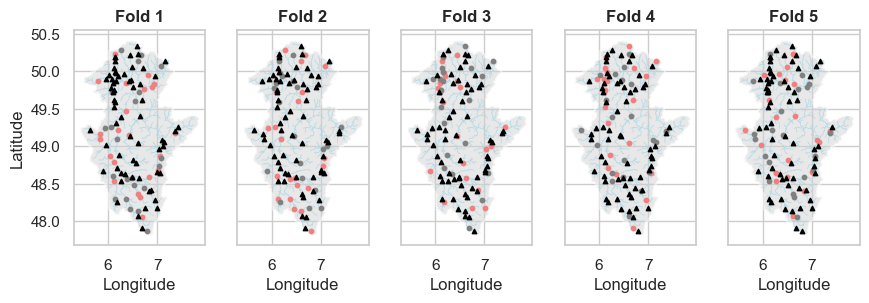

In [243]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import numpy as np

def read_basin_list(path):
    with open(path, "r") as f:
        return [line.strip() for line in f if line.strip()]
folds = [
    {
        "train": "../data/train1.txt",
        "val":   "../data/val1.txt",
        "test":  "../data/test1.txt",
    },
    {
        "train": "../data/train2.txt",
        "val":   "../data/val2.txt",
        "test":  "../data/test2.txt",
    },
    {
        "train": "../data/train3.txt",
        "val":   "../data/val3.txt",
        "test":  "../data/test3.txt",
    },
    {
        "train": "../data/train4.txt",
        "val":   "../data/val4.txt",
        "test":  "../data/test4.txt",
    },
    {
        "train": "../data/train5.txt",
        "val":   "../data/val5.txt",
        "test":  "../data/test5.txt",
    },]

def build_fold_coords(folds, network_estreams):
    fold_coords = []

    for fold in folds:
        train_ids = read_basin_list(fold["train"])
        val_ids   = read_basin_list(fold["val"])
        test_ids  = read_basin_list(fold["test"])

        fold_coords.append({
            "train": network_estreams.loc[
                [b for b in train_ids if b in network_estreams.index]
            ],
            "val": network_estreams.loc[
                [b for b in val_ids if b in network_estreams.index]
            ],
            "test": network_estreams.loc[
                [b for b in test_ids if b in network_estreams.index]
            ],
        })

    return fold_coords

def plot_basin_folds(
    basin_outline,
    basin_rivers,
    fold_coords,
    df_all,
    outfile,
    nrows,
    ncols,
    figsize,
    legend_on=True,
):
    sns.set_theme(style="whitegrid")

    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, sharex=True, sharey=True)
    axes = axes.flatten()

    for i, ax in enumerate(axes):
        if i < len(fold_coords):
            basin_outline.plot(ax=ax, color="lightgray", linewidth=1, alpha=0.5)
            basin_rivers.plot(ax=ax, color="lightblue", linewidth=0.5, alpha=0.75)

            # Evaluation (test) – coral circle
            # Validation – black circle
            ax.scatter(
                fold_coords[i]["val"]["lon"],
                fold_coords[i]["val"]["lat"],
                color="gray",
                s=10,
                marker="o",
                zorder=3,
            )

            # Calibration – black triangle
            ax.scatter(
                fold_coords[i]["train"]["lon"],
                fold_coords[i]["train"]["lat"],
                color="black",
                s=10,
                marker="^",
                zorder=4,
            )
            ax.scatter(
                fold_coords[i]["test"]["lon"],
                fold_coords[i]["test"]["lat"],
                color="lightcoral",
                s=10,
                marker="o",
                zorder=2,
            )
            ax.set_title(f"Fold {i+1}", fontweight="bold")

        else:
            ax.axis("off")
            continue

        # Axis labels
        if i < ncols * (nrows - 1):
            ax.set_xlabel("")
        else:
            ax.set_xlabel("Longitude")

        if i % ncols != 0:
            ax.set_ylabel("")
        else:
            ax.set_ylabel("Latitude")

        ax.grid(True)

    # Legend
    calibration_handle = mlines.Line2D(
        [], [], color="black", marker="^", linestyle="None",
        markersize=8, label="Calibration (train)"
    )
    validation_handle = mlines.Line2D(
        [], [], color="black", marker="o", linestyle="None",
        markersize=8, label="Validation"
    )
    test_handle = mlines.Line2D(
        [], [], color="lightcoral", marker="o", linestyle="None",
        markersize=8, label="Evaluation (test)"
    )

    if legend_on == True:
        fig.legend(
            handles=[calibration_handle, validation_handle, test_handle],
            loc="lower center",
            ncol=3,
            frameon=False,
        )

    plt.tight_layout(rect=[0, 0.05, 1, 1])
    plt.savefig(outfile, dpi=300)
    plt.show()


fold_coords = build_fold_coords(folds, network_estreams_moselle_108_gauges)

plot_basin_folds(
    basin_outline=moselle,
    basin_rivers=rivers_moselle,
    fold_coords=fold_coords,
    df_all=network_estreams_moselle_108_gauges,
    outfile="../results/figs/figures/FigSX_Moselle_LSTM.png",
    nrows=1,
    ncols=5,
    figsize=(9, 3),
    legend_on=False,

)

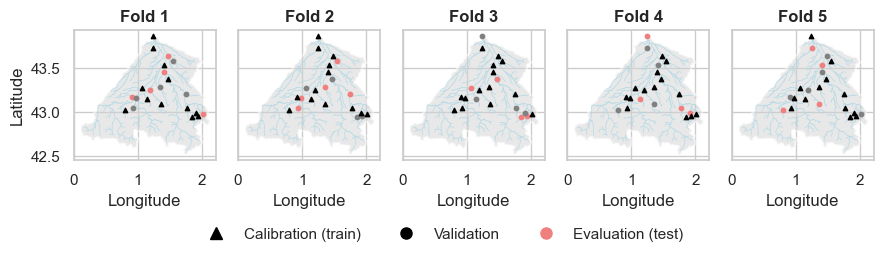

In [244]:
fold_coords = build_fold_coords(folds, network_estreams_garonne_22_gauges)
plot_basin_folds(
    basin_outline=garonne,
    basin_rivers=rivers_garonne,
    fold_coords=fold_coords,
    df_all=network_estreams_garonne_22_gauges,
    outfile="../results/figs/figures/FigSX_Garonne_LSTM.png",
    nrows=1,
    ncols=5,
    figsize=(9, 3),
)

## Adjust the results

In [578]:
# Space-time
import pickle
import numpy as np
import xarray as xr
from pathlib import Path
import re

# SEEDS TO PROCESS
seeds = {
    28: "03_seed28",
    33: "03_seed33",
    44: "03_seed44",
    55: "03_seed55",
    77: "03_seed77",
}

base_root = Path(
    "/Users/nascimth/Library/CloudStorage/OneDrive-Eawag/"
    "Eawag/Papers/Moselle_superflexpy/GitHub/"
    "estreams_superflexpy/results/LSTM/"
)

out_dir = Path("../results/sim_lstm/space-time/")

out_dir.mkdir(parents=True, exist_ok=True)

# LOOP OVER SEEDS
for seed, seed_folder in seeds.items():

    print(f"Processing seed {seed}")

    base_dir = base_root / seed_folder
    out_file = out_dir / f"simu_Seed_{seed}.nc"

    # COLLECT FILES BY SPLIT
    model_files = {}

    for subfolder in base_dir.iterdir():
        if not subfolder.is_dir():
            continue

        m = re.search(r"moselle_(glo|con|reg|nog|ran)_seed\d+_(\d+)_", subfolder.name)

        if not m:
            continue

        kind = m.group(1)
        split = int(m.group(2))

        tag = {
            "glo": "global",
            "con": "continental",
            "reg": "regional",
            "nog": "nogeology",
            "ran": "random",
        }[kind]

        pfile = next(subfolder.glob("test/model_epoch*/test_results.p"), None)
        if pfile is None:
            continue

        model_files.setdefault(split, {})[tag] = pfile

    # READ + CONCATENATE GAUGES
    obs_list, glo_list, reg_list, nog_list, con_list, ran_list = [], [], [], [], [], []
    gauge_ids = []
    time_index = None

    for split, files in sorted(model_files.items()):

        sim_glo = pickle.load(open(files["global"], "rb"))
        sim_reg = pickle.load(open(files["regional"], "rb"))
        sim_nog = pickle.load(open(files["nogeology"], "rb"))
        sim_con = pickle.load(open(files["continental"], "rb"))
        sim_ran = pickle.load(open(files["random"], "rb"))

        for g in sim_glo.keys():

            qobs_da = sim_glo[g]["1D"]["xr"]["q_mean_obs"]
            qobs = qobs_da.squeeze("time_step").values

            if time_index is None:
                time_index = qobs_da["date"].values

            obs_list.append(qobs)

            qsim_glo = (
                sim_glo[g]["1D"]["xr"]["q_mean_sim"]
                .squeeze("time_step")
                .values
            )
            glo_list.append(np.where(qsim_glo < 0, 0, qsim_glo))

            qsim_reg = (
                sim_reg[g]["1D"]["xr"]["q_mean_sim"]
                .squeeze("time_step")
                .values
            )
            reg_list.append(np.where(qsim_reg < 0, 0, qsim_reg))

            qsim_nog = (
                sim_nog[g]["1D"]["xr"]["q_mean_sim"]
                .squeeze("time_step")
                .values
            )
            nog_list.append(np.where(qsim_nog < 0, 0, qsim_nog))

            qsim_con = (
                sim_con[g]["1D"]["xr"]["q_mean_sim"]
                .squeeze("time_step")
                .values
            )
            con_list.append(np.where(qsim_con < 0, 0, qsim_con))
            qsim_ran = (
                sim_ran[g]["1D"]["xr"]["q_mean_sim"]
                .squeeze("time_step")
                .values
            )
            ran_list.append(np.where(qsim_ran < 0, 0, qsim_ran))

            gauge_ids.append(g)

    # SAVE NETCDF
    ds = xr.Dataset(
        data_vars={
            "observation": (["gauge_id", "date"], np.asarray(obs_list)),
            "global":      (["gauge_id", "date"], np.asarray(glo_list)),
            "continental": (["gauge_id", "date"], np.asarray(con_list)),
            "regional":    (["gauge_id", "date"], np.asarray(reg_list)),
            "nogeology":   (["gauge_id", "date"], np.asarray(nog_list)),
            "random":      (["gauge_id", "date"], np.asarray(ran_list)),
        },
        coords={
            "gauge_id": gauge_ids,
            "date": time_index,
        },
    )

    ds.to_netcdf(out_file, engine="scipy")

Processing seed 28
Processing seed 33
Processing seed 44
Processing seed 55
Processing seed 77


In [517]:
# Time
import pickle
import numpy as np
import xarray as xr
from pathlib import Path
import re

# SEEDS TO PROCESS
seeds = {
    28: "03_time_seed28",
    33: "03_time_seed33",
    44: "03_time_seed44",
    55: "03_time_seed55",
    77: "03_time_seed77",
}

base_root = Path(
    "/Users/nascimth/Library/CloudStorage/OneDrive-Eawag/"
    "Eawag/Papers/Moselle_superflexpy/GitHub/"
    "estreams_superflexpy/results/LSTM/"
)


out_dir = Path("../results/sim_lstm/time/")
out_dir.mkdir(parents=True, exist_ok=True)

# LOOP OVER SEEDS
for seed, seed_folder in seeds.items():

    print(f"Processing seed {seed}")

    base_dir = base_root / seed_folder
    out_file = out_dir / f"simu_Seed_{seed}.nc"

    # COLLECT FILES BY SPLIT
    model_files = {}

    for subfolder in base_dir.iterdir():
        if not subfolder.is_dir():
            continue

        m = re.search(r"moselle_(glo|con|reg|nog|ran)_seed\d+_(\d+)_", subfolder.name)

        if not m:
            continue

        kind = m.group(1)
        split = int(m.group(2))

        tag = {
            "glo": "global",
            "con": "continental",
            "reg": "regional",
            "nog": "nogeology",
            "ran": "random",
        }[kind]

        pfile = next(subfolder.glob("test/model_epoch*/test_results.p"), None)
        if pfile is None:
            continue

        model_files.setdefault(split, {})[tag] = pfile

    # READ + CONCATENATE GAUGES
    obs_list, glo_list, reg_list, nog_list, con_list, ran_list = [], [], [], [], [], []
    gauge_ids = []
    time_index = None

    for split, files in sorted(model_files.items()):

        sim_glo = pickle.load(open(files["global"], "rb"))
        sim_reg = pickle.load(open(files["regional"], "rb"))
        sim_nog = pickle.load(open(files["nogeology"], "rb"))
        sim_con = pickle.load(open(files["continental"], "rb"))
        sim_ran = pickle.load(open(files["random"], "rb"))

        for g in sim_glo.keys():

            qobs_da = sim_glo[g]["1D"]["xr"]["q_mean_obs"]
            qobs = qobs_da.squeeze("time_step").values

            if time_index is None:
                time_index = qobs_da["date"].values

            obs_list.append(qobs)

            qsim_glo = (
                sim_glo[g]["1D"]["xr"]["q_mean_sim"]
                .squeeze("time_step")
                .values
            )
            glo_list.append(np.where(qsim_glo < 0, 0, qsim_glo))

            qsim_reg = (
                sim_reg[g]["1D"]["xr"]["q_mean_sim"]
                .squeeze("time_step")
                .values
            )
            reg_list.append(np.where(qsim_reg < 0, 0, qsim_reg))

            qsim_nog = (
                sim_nog[g]["1D"]["xr"]["q_mean_sim"]
                .squeeze("time_step")
                .values
            )
            nog_list.append(np.where(qsim_nog < 0, 0, qsim_nog))

            qsim_con = (
                sim_con[g]["1D"]["xr"]["q_mean_sim"]
                .squeeze("time_step")
                .values
            )
            con_list.append(np.where(qsim_con < 0, 0, qsim_con))
            qsim_ran = (
                sim_ran[g]["1D"]["xr"]["q_mean_sim"]
                .squeeze("time_step")
                .values
            )
            ran_list.append(np.where(qsim_ran < 0, 0, qsim_ran))

            gauge_ids.append(g)

    # SAVE NETCDF
    ds = xr.Dataset(
        data_vars={
            "observation": (["gauge_id", "date"], np.asarray(obs_list)),
            "global":      (["gauge_id", "date"], np.asarray(glo_list)),
            "continental": (["gauge_id", "date"], np.asarray(con_list)),
            "regional":    (["gauge_id", "date"], np.asarray(reg_list)),
            "nogeology":   (["gauge_id", "date"], np.asarray(nog_list)),
            "random":      (["gauge_id", "date"], np.asarray(ran_list)),
        },
        coords={
            "gauge_id": gauge_ids,
            "date": time_index,
        },
    )

    ds.to_netcdf(out_file, engine="scipy")

Processing seed 28
Processing seed 33
Processing seed 44
Processing seed 55
Processing seed 77


In [579]:
# Space
import pickle
import numpy as np
import xarray as xr
from pathlib import Path
import re

# SEEDS TO PROCESS
seeds = {
    28: "03_seed28",
    33: "03_seed33",
    44: "03_seed44",
    55: "03_seed55",
    77: "03_seed77",
}

base_root = Path(
    "/Users/nascimth/Library/CloudStorage/OneDrive-Eawag/"
    "Eawag/Papers/Moselle_superflexpy/GitHub/"
    "estreams_superflexpy/results/LSTM/"
)

out_dir = Path("../results/sim_lstm/space/")
out_dir.mkdir(parents=True, exist_ok=True)

# LOOP OVER SEEDS
for seed, seed_folder in seeds.items():

    print(f"Processing seed {seed}")

    base_dir = base_root / seed_folder
    out_file = out_dir / f"simu_Seed_{seed}.nc"

    # COLLECT FILES BY SPLIT
    model_files = {}

    for subfolder in base_dir.iterdir():
        if not subfolder.is_dir():
            continue

        m = re.search(r"moselle_(glo|con|reg|nog|ran)_seed\d+_(\d+)_", subfolder.name)

        if not m:
            continue

        kind = m.group(1)
        split = int(m.group(2))

        tag = {
            "glo": "global",
            "con": "continental",
            "reg": "regional",
            "nog": "nogeology",
            "ran": "random",
        }[kind]

        pfile = next(subfolder.glob("test/model_epoch*/test_results.p"), None)
        if pfile is None:
            continue

        model_files.setdefault(split, {})[tag] = pfile

    # READ + CONCATENATE GAUGES
    obs_list, glo_list, reg_list, nog_list, con_list, ran_list = [], [], [], [], [], []
    gauge_ids = []
    time_index = None

    for split, files in sorted(model_files.items()):

        sim_glo = pickle.load(open(files["global"], "rb"))
        sim_reg = pickle.load(open(files["regional"], "rb"))
        sim_nog = pickle.load(open(files["nogeology"], "rb"))
        sim_con = pickle.load(open(files["continental"], "rb"))
        sim_ran = pickle.load(open(files["random"], "rb"))

        for g in sim_glo.keys():

            qobs_da = sim_glo[g]["1D"]["xr"]["q_mean_obs"]
            qobs = qobs_da.squeeze("time_step").values

            if time_index is None:
                time_index = qobs_da["date"].values

            obs_list.append(qobs)

            qsim_glo = (
                sim_glo[g]["1D"]["xr"]["q_mean_sim"]
                .squeeze("time_step")
                .values
            )
            glo_list.append(np.where(qsim_glo < 0, 0, qsim_glo))

            qsim_reg = (
                sim_reg[g]["1D"]["xr"]["q_mean_sim"]
                .squeeze("time_step")
                .values
            )
            reg_list.append(np.where(qsim_reg < 0, 0, qsim_reg))

            qsim_nog = (
                sim_nog[g]["1D"]["xr"]["q_mean_sim"]
                .squeeze("time_step")
                .values
            )
            nog_list.append(np.where(qsim_nog < 0, 0, qsim_nog))

            qsim_con = (
                sim_con[g]["1D"]["xr"]["q_mean_sim"]
                .squeeze("time_step")
                .values
            )
            con_list.append(np.where(qsim_con < 0, 0, qsim_con))
            qsim_ran = (
                sim_ran[g]["1D"]["xr"]["q_mean_sim"]
                .squeeze("time_step")
                .values
            )
            ran_list.append(np.where(qsim_ran < 0, 0, qsim_ran))

            gauge_ids.append(g)

    # SAVE NETCDF
    ds = xr.Dataset(
        data_vars={
            "observation": (["gauge_id", "date"], np.asarray(obs_list)),
            "global":      (["gauge_id", "date"], np.asarray(glo_list)),
            "continental": (["gauge_id", "date"], np.asarray(con_list)),
            "regional":    (["gauge_id", "date"], np.asarray(reg_list)),
            "nogeology":   (["gauge_id", "date"], np.asarray(nog_list)),
            "random":      (["gauge_id", "date"], np.asarray(ran_list)),
        },
        coords={
            "gauge_id": gauge_ids,
            "date": time_index,
        },
    )

    ds.to_netcdf(out_file, engine="scipy")

Processing seed 28
Processing seed 33
Processing seed 44
Processing seed 55
Processing seed 77


## Check the results

In [548]:
# Define the NSE adjusted function
def compute_nse(observations, simulation, expo=0.5):
    """
    Calculate the Normalized Squared Error Efficiency (NSEE) while ensuring that
    NaNs in simulation are NOT masked (only NaNs in observations are masked).

    Parameters:
        observations (array-like): Observed values (with fixed NaNs).
        simulation (array-like): Simulated values (can contain NaNs).
        expo (float, optional): Exponent applied to observations and simulations. Default is 1.0.

    Returns:
        float: NSEE score (higher values indicate worse performance).
    """
    observations = np.asarray(observations)
    simulation = np.asarray(simulation)

    # Mask only NaNs in observations
    mask = ~np.isnan(observations)
    obs = observations[mask]
    sim = simulation[mask]  # Keep all simulated values, even NaNs

    # If simulation contains NaNs after masking observations, return penalty
    if np.isnan(sim).any():
        return 10.0  # Large penalty if NaNs appear in the simulation

    metric = 1 - np.sum((sim**expo - obs**expo)**2) / np.sum((obs**expo - np.mean(obs**expo))**2)
    
    return float(metric)


def compute_kge(observations, simulation):
    """
    Calculate the KGE-2012 objective function, ensuring that NaNs in simulation are NOT masked.
    
    Parameters:
        observations (array-like): Observed values (with fixed NaNs).
        simulation (array-like): Simulated values (can contain NaNs).

    Returns:
        float: KGE-2012 score (higher values indicate worse performance).
    """
    observations = np.asarray(observations)
    simulation = np.asarray(simulation)

    # Mask only NaNs in observations
    mask = ~np.isnan(observations)
    obs = observations[mask]
    sim = simulation[mask]  # Keep all simulated values, even NaNs

    # Check if there are NaNs in the simulation after masking obs
    if np.isnan(sim).any():
        return 10.0  # Large penalty if the simulation contains NaNs
    
    obs_mean = np.mean(obs)
    sim_mean = np.mean(sim)

    r = np.corrcoef(obs, sim)[0, 1]
    alpha = np.std(sim) / np.std(obs)
    beta = sim_mean / obs_mean

    kge = np.sqrt((r - 1)**2 + (alpha - 1)**2 + (beta - 1)**2)  # KGE-2012

    return 1 - float(kge)

In [580]:
# Code for space-time validation
import numpy as np
import pandas as pd
import xarray as xr
import tqdm

from neuralhydrology.evaluation.signatures import (
    baseflow_index,
    hfd_mean,
    slope_fdc,
    q_mean,
)

# LOAD DATA
files = [
    "../results/sim_lstm/space-time/simu_Seed_28.nc",
    "../results/sim_lstm/space-time/simu_Seed_33.nc",
    "../results/sim_lstm/space-time/simu_Seed_44.nc",
    "../results/sim_lstm/space-time/simu_Seed_55.nc",
    "../results/sim_lstm/space-time/simu_Seed_77.nc",
]

# Open and tag each dataset with its seed
datasets = []
for seed, f in zip([28, 33, 44, 55, 77], files):
    ds_seed = xr.open_dataset(f).expand_dims(seed=[seed])
    datasets.append(ds_seed)

# Concatenate along seed dimension
ds_all = xr.concat(datasets, dim="seed")

# Take average over seed
ds = ds_all.mean(dim="seed")


# TIME RANGE
start_date = "2002-10-01"
end_date   = "2015-09-30"

selected_gauge_ids = network_estreams_garonne_and_moselle.index.unique().tolist()

ds_clipped = ds.sel(
    gauge_id=selected_gauge_ids,
    date=slice(start_date, end_date)
)

# NSE (UNCHANGED – NUMPY IS CORRECT HERE)
nse_results = {}

for gauge_id in ds_clipped.gauge_id.values:
    ts = ds_clipped.sel(gauge_id=gauge_id)

    obs_np = ts["observation"].values  # numpy arrays

    nse_results[gauge_id] = {
        # ---- NSE ----
        "nse_nogeo": compute_nse(obs_np, ts["nogeology"].values, expo=1.0),
        "nse_ran": compute_nse(obs_np, ts["random"].values, expo=1.0),
        "nse_g1comp": compute_nse(obs_np, ts["global"].values, expo=1.0),
        "nse_c1comp": compute_nse(obs_np, ts["continental"].values, expo=1.0),
        "nse_r1comp": compute_nse(obs_np, ts["regional"].values, expo=1.0),

        # ---- KGE ----
        "kge_nogeo": compute_kge(obs_np, ts["nogeology"].values),
        "kge_ran": compute_kge(obs_np, ts["random"].values),
        "kge_g1comp": compute_kge(obs_np, ts["global"].values),
        "kge_c1comp": compute_kge(obs_np, ts["continental"].values),
        "kge_r1comp": compute_kge(obs_np, ts["regional"].values),
    }

data_diff_val_complete_dict_plot_nse = pd.DataFrame.from_dict(
    nse_results, orient="index"
)

# SIGNATURE FUNCTIONS (UNCHANGED)
sources = ["observation", "regional", "continental", "global", "nogeology", "random"]

MIN_VALID_POINTS = 365

def safe_bfi(sim, obs):
    sim = sim.where(~np.isnan(obs))
    if sim.count() < MIN_VALID_POINTS:
        return np.nan
    return baseflow_index(sim, alpha=0.925, warmup=365, n_passes=3)[0]

def safe_hfd(sim, obs):
    sim = sim.where(~np.isnan(obs))
    if sim.count() < MIN_VALID_POINTS:
        return np.nan
    return hfd_mean(sim, datetime_coord="date")

def safe_slope(sim, obs):
    sim = sim.where(~np.isnan(obs))
    if sim.count() < MIN_VALID_POINTS:
        return np.nan
    return slope_fdc(sim)

def safe_qmean(sim, obs):
    sim = sim.where(~np.isnan(obs))
    if sim.count() < MIN_VALID_POINTS:
        return np.nan
    return q_mean(sim)

signature_funcs = {
    "bfi": safe_bfi,
    "hfd": safe_hfd,
    "slope": safe_slope,
    "qmean": safe_qmean,
}

# SIGNATURES (FIXED: KEEP XARRAY)
signature_results = []

for gauge in tqdm.tqdm(ds_clipped.gauge_id.values):
    obs = ds_clipped.sel(gauge_id=gauge)["observation"]  # xarray
    row = {"gauge_id": gauge}

    for sig_short, sig_func in signature_funcs.items():
        for source in sources:
            discharge = ds_clipped.sel(gauge_id=gauge)[source]  # xarray
            try:
                result = sig_func(discharge, obs)
            except Exception as e:
                print(f"{sig_short} failed for {gauge} [{source}]: {e}")
                result = np.nan

            source_map = {
                "observation": "obs",
                "regional": "r1comp",
                "continental": "c1comp",
                "global": "g1comp",
                "nogeology": "nogeo",
                "random": "ran",
            }

            col_name = f"{sig_short}_{source_map[source]}"
            row[col_name] = result

    signature_results.append(row)

signature_df = pd.DataFrame(signature_results)
signature_df.set_index("gauge_id", inplace=True)


# MERGE NSE + SIGNATURES
data_diff_val_complete_dict_plot_nse = (
    data_diff_val_complete_dict_plot_nse.join(signature_df, how="left")
)

100%|██████████| 130/130 [00:07<00:00, 18.40it/s]


In [560]:
data_diff_val_complete_dict_plot_nse.describe()

,nse_nogeo,nse_g1comp,nse_c1comp,nse_r1comp,kge_nogeo,kge_g1comp,kge_c1comp,kge_r1comp,bfi_obs,bfi_r1comp,...,slope_obs,slope_r1comp,slope_c1comp,slope_g1comp,slope_nogeo,qmean_obs,qmean_r1comp,qmean_c1comp,qmean_g1comp,qmean_nogeo
count,130.000000,130.000000,130.000000,130.000000,130.000000,130.000000,130.000000,130.000000,130.000000,130.000000,...,124.000000,124.000000,124.000000,124.000000,124.000000,130.000000,130.000000,130.000000,130.000000,130.000000
mean,0.691059,0.653172,0.583803,0.708508,0.634116,0.630379,0.617954,0.647718,0.573658,0.624216,...,2.788036,2.321624,2.264508,2.406706,2.286085,1.097993,0.958848,0.990173,0.967468,0.963788
std,0.250061,0.576680,1.475055,0.212289,0.169090,0.198756,0.253211,0.166671,0.078906,0.078214,...,0.885161,0.791334,0.884615,0.937153,0.854361,0.567213,0.538403,0.627924,0.569980,0.545692
min,-1.002941,-5.509149,-15.994974,-0.535654,-0.237813,-0.632878,-1.719649,-0.010982,0.360449,0.403545,...,0.902529,0.766561,0.558067,0.744710,0.917994,0.264454,0.207883,0.189732,0.207002,0.155424
25%,0.661944,0.646598,0.657066,0.670720,0.568209,0.531061,0.563206,0.566591,0.522578,0.569049,...,2.238554,1.813302,1.688719,1.891970,1.795450,0.782773,0.641067,0.655560,0.628001,0.656331
50%,0.744104,0.739278,0.752337,0.757794,0.658657,0.668271,0.661936,0.681719,0.578139,0.619677,...,2.580919,2.273599,2.148644,2.255318,2.160379,0.962306,0.831844,0.831743,0.820874,0.824500
75%,0.814153,0.816057,0.800718,0.833689,0.739429,0.774766,0.744529,0.765305,0.618796,0.677432,...,3.139521,2.635569,2.562424,2.705139,2.560599,1.236292,1.116742,1.094330,1.079995,1.111125
max,0.909190,0.911460,0.914153,0.911543,0.906154,0.924529,0.878003,0.912396,0.818959,0.802912,...,7.159544,6.560783,7.260665,7.018941,6.745122,3.618939,3.609955,4.888381,3.602792,3.460150


In [581]:
data_diff_val_complete_dict_plot_nse.describe()

,nse_nogeo,nse_ran,nse_g1comp,nse_c1comp,nse_r1comp,kge_nogeo,kge_ran,kge_g1comp,kge_c1comp,kge_r1comp,...,slope_c1comp,slope_g1comp,slope_nogeo,slope_ran,qmean_obs,qmean_r1comp,qmean_c1comp,qmean_g1comp,qmean_nogeo,qmean_ran
count,130.000000,130.000000,130.000000,130.000000,130.000000,130.000000,130.000000,130.000000,130.000000,130.000000,...,124.000000,124.000000,124.000000,124.000000,130.000000,130.000000,130.000000,130.000000,130.000000,130.000000
mean,0.701148,0.702314,0.682569,0.693119,0.714618,0.632917,0.633455,0.625419,0.641115,0.660204,...,2.346902,2.282302,2.681072,2.643056,1.097993,0.993277,0.982460,0.970804,0.976053,0.958917
std,0.203131,0.213865,0.311369,0.398628,0.259607,0.167555,0.157196,0.178849,0.168671,0.153624,...,1.191962,0.889878,4.279453,4.327611,0.567213,0.555403,0.533969,0.541277,0.545191,0.542277
min,-0.422664,-0.798170,-2.010504,-3.517215,-1.712207,-0.016561,0.020369,-0.107608,-0.354413,-0.054540,...,0.734685,0.690832,0.994655,1.053290,0.264454,0.181575,0.146222,0.188042,0.117373,0.194840
25%,0.662419,0.667403,0.664224,0.678989,0.688546,0.548924,0.553947,0.549818,0.576363,0.571492,...,1.874028,1.870645,1.804532,1.768710,0.782773,0.656859,0.670301,0.645819,0.657241,0.627968
50%,0.746795,0.748087,0.740927,0.751744,0.760719,0.666852,0.634310,0.654642,0.668867,0.678773,...,2.201279,2.107406,2.099847,2.127353,0.962306,0.820589,0.851755,0.842559,0.825860,0.819690
75%,0.815519,0.813974,0.815831,0.815683,0.829164,0.736227,0.768067,0.746018,0.750381,0.766316,...,2.537435,2.505111,2.473696,2.626224,1.236292,1.127157,1.095467,1.093064,1.091162,1.061482
max,0.909402,0.906553,0.908585,0.904773,0.905084,0.919359,0.911352,0.915162,0.929735,0.908611,...,11.386008,7.669191,46.197067,49.513023,3.618939,3.315327,3.150639,3.209339,3.369995,3.663948


In [582]:
data_diff_val_complete_dict_plot.corr()["bfi_obs"]

nse_nogeo      -0.382522
nse_g1comp     -0.268669
nse_c1comp     -0.209063
nse_r1comp     -0.352719
kge_nogeo      -0.153538
kge_g1comp     -0.158391
kge_c1comp     -0.229018
kge_r1comp     -0.242426
bfi_obs         1.000000
bfi_r1comp      0.677180
bfi_c1comp      0.639819
bfi_g1comp      0.569116
bfi_nogeo       0.541324
hfd_obs         0.318840
hfd_r1comp      0.202055
hfd_c1comp      0.194232
hfd_g1comp      0.180790
hfd_nogeo       0.141463
slope_obs      -0.660575
slope_r1comp   -0.487355
slope_c1comp   -0.445330
slope_g1comp   -0.349681
slope_nogeo    -0.286367
qmean_obs       0.230944
qmean_r1comp    0.148603
qmean_c1comp    0.216184
qmean_g1comp    0.212856
qmean_nogeo     0.185960
Name: bfi_obs, dtype: float64

In [561]:
data_diff_val_complete_dict_plot_nse.corr()["bfi_obs"]

nse_nogeo      -0.342377
nse_g1comp     -0.218684
nse_c1comp     -0.178135
nse_r1comp     -0.361461
kge_nogeo      -0.153538
kge_g1comp     -0.158391
kge_c1comp     -0.229018
kge_r1comp     -0.242426
bfi_obs         1.000000
bfi_r1comp      0.677180
bfi_c1comp      0.639819
bfi_g1comp      0.569116
bfi_nogeo       0.541324
hfd_obs         0.318840
hfd_r1comp      0.202055
hfd_c1comp      0.194232
hfd_g1comp      0.180790
hfd_nogeo       0.141463
slope_obs      -0.660575
slope_r1comp   -0.487355
slope_c1comp   -0.445330
slope_g1comp   -0.349681
slope_nogeo    -0.286367
qmean_obs       0.230944
qmean_r1comp    0.148603
qmean_c1comp    0.216184
qmean_g1comp    0.212856
qmean_nogeo     0.185960
Name: bfi_obs, dtype: float64

In [554]:
data_diff_val_complete_dict_plot_nse.loc["LU000019"]

nse_nogeo         0.734327
nse_g1comp        0.709823
nse_c1comp        0.763132
nse_r1comp        0.855261
kge_nogeo         0.551972
kge_g1comp        0.554362
kge_c1comp        0.645135
kge_r1comp        0.750028
bfi_obs           0.501414
bfi_r1comp        0.498117
bfi_c1comp        0.572905
bfi_g1comp        0.631763
bfi_nogeo         0.622937
hfd_obs         126.416667
hfd_r1comp      123.833333
hfd_c1comp      129.833333
hfd_g1comp      130.416667
hfd_nogeo       132.416667
slope_obs         3.445692
slope_r1comp      3.331912
slope_c1comp      2.295188
slope_g1comp      2.192686
slope_nogeo       1.974777
qmean_obs         1.155308
qmean_r1comp      0.960933
qmean_c1comp      0.924591
qmean_g1comp      0.882154
qmean_nogeo       0.916330
Name: LU000019, dtype: float64

In [583]:
# Code for space-time validation
import numpy as np
import pandas as pd
import xarray as xr
import tqdm

from neuralhydrology.evaluation.signatures import (
    baseflow_index,
    hfd_mean,
    slope_fdc,
    q_mean,
)

# LOAD DATA
files = [
    "../results/sim_lstm/space-time/simu_Seed_28.nc",
    "../results/sim_lstm/space-time/simu_Seed_33.nc",
    "../results/sim_lstm/space-time/simu_Seed_44.nc",
    "../results/sim_lstm/space-time/simu_Seed_55.nc",
    "../results/sim_lstm/space-time/simu_Seed_77.nc",
]

# Open and tag each dataset with its seed
datasets = []
for seed, f in zip([28, 33, 44, 55, 77], files):
    ds_seed = xr.open_dataset(f).expand_dims(seed=[seed])
    datasets.append(ds_seed)

# Concatenate along seed dimension
ds_all = xr.concat(datasets, dim="seed")

# Take median over seed
ds = ds_all.mean(dim="seed")


# TIME RANGE
start_date = "2002-10-01"
end_date   = "2015-09-30"

selected_gauge_ids = network_estreams_garonne_and_moselle.index.unique().tolist()

ds_clipped = ds.sel(
    gauge_id=selected_gauge_ids,
    date=slice(start_date, end_date)
)

# NSE (UNCHANGED – NUMPY IS CORRECT HERE)
nse_results = {}

for gauge_id in ds_clipped.gauge_id.values:
    ts = ds_clipped.sel(gauge_id=gauge_id)

    obs_np = ts["observation"].values  # numpy arrays

    nse_results[gauge_id] = {
        # ---- NSE ----
        "nse_nogeo": compute_nse(obs_np, ts["nogeology"].values, expo=0.5),
        "nse_ran": compute_nse(obs_np, ts["random"].values, expo=0.5),
        "nse_g1comp": compute_nse(obs_np, ts["global"].values, expo=0.5),
        "nse_c1comp": compute_nse(obs_np, ts["continental"].values, expo=0.5),
        "nse_r1comp": compute_nse(obs_np, ts["regional"].values, expo=0.5),

        # ---- KGE ----
        "kge_nogeo": compute_kge(obs_np, ts["nogeology"].values),
        "kge_ran": compute_kge(obs_np, ts["random"].values),
        "kge_g1comp": compute_kge(obs_np, ts["global"].values),
        "kge_c1comp": compute_kge(obs_np, ts["continental"].values),
        "kge_r1comp": compute_kge(obs_np, ts["regional"].values),
    }

data_diff_val_complete_dict_plot = pd.DataFrame.from_dict(
    nse_results, orient="index"
)

# SIGNATURE FUNCTIONS (UNCHANGED)
sources = ["observation", "regional", "continental", "global", "nogeology", "random"]

MIN_VALID_POINTS = 365

def safe_bfi(sim, obs):
    sim = sim.where(~np.isnan(obs))
    if sim.count() < MIN_VALID_POINTS:
        return np.nan
    return baseflow_index(sim, alpha=0.925, warmup=365, n_passes=3)[0]

def safe_hfd(sim, obs):
    sim = sim.where(~np.isnan(obs))
    if sim.count() < MIN_VALID_POINTS:
        return np.nan
    return hfd_mean(sim, datetime_coord="date")

def safe_slope(sim, obs):
    sim = sim.where(~np.isnan(obs))
    if sim.count() < MIN_VALID_POINTS:
        return np.nan
    return slope_fdc(sim)

def safe_qmean(sim, obs):
    sim = sim.where(~np.isnan(obs))
    if sim.count() < MIN_VALID_POINTS:
        return np.nan
    return q_mean(sim)

signature_funcs = {
    "bfi": safe_bfi,
    "hfd": safe_hfd,
    "slope": safe_slope,
    "qmean": safe_qmean,
}

# SIGNATURES (FIXED: KEEP XARRAY)
signature_results = []

for gauge in tqdm.tqdm(ds_clipped.gauge_id.values):
    obs = ds_clipped.sel(gauge_id=gauge)["observation"]  # xarray
    row = {"gauge_id": gauge}

    for sig_short, sig_func in signature_funcs.items():
        for source in sources:
            discharge = ds_clipped.sel(gauge_id=gauge)[source]  # xarray
            try:
                result = sig_func(discharge, obs)
            except Exception as e:
                print(f"{sig_short} failed for {gauge} [{source}]: {e}")
                result = np.nan

            source_map = {
                "observation": "obs",
                "regional": "r1comp",
                "continental": "c1comp",
                "global": "g1comp",
                "nogeology": "nogeo",
                "random": "ran",
            }

            col_name = f"{sig_short}_{source_map[source]}"
            row[col_name] = result

    signature_results.append(row)

signature_df = pd.DataFrame(signature_results)
signature_df.set_index("gauge_id", inplace=True)


# MERGE NSE + SIGNATURES
data_diff_val_complete_dict_plot = (
    data_diff_val_complete_dict_plot.join(signature_df, how="left")
)

100%|██████████| 130/130 [00:07<00:00, 18.06it/s]


In [564]:
data_diff_val_complete_dict_plot.describe()

,nse_nogeo,nse_g1comp,nse_c1comp,nse_r1comp,kge_nogeo,kge_g1comp,kge_c1comp,kge_r1comp,bfi_obs,bfi_r1comp,...,slope_obs,slope_r1comp,slope_c1comp,slope_g1comp,slope_nogeo,qmean_obs,qmean_r1comp,qmean_c1comp,qmean_g1comp,qmean_nogeo
count,130.000000,130.000000,130.000000,130.000000,130.000000,130.000000,130.000000,130.000000,130.000000,130.000000,...,124.000000,124.000000,124.000000,124.000000,124.000000,130.000000,130.000000,130.000000,130.000000,130.000000
mean,0.727369,0.702014,0.671663,0.744939,0.634116,0.630379,0.617954,0.647718,0.573658,0.624216,...,2.788036,2.321624,2.264508,2.406706,2.286085,1.097993,0.958848,0.990173,0.967468,0.963788
std,0.276548,0.500066,0.949943,0.271486,0.169090,0.198756,0.253211,0.166671,0.078906,0.078214,...,0.885161,0.791334,0.884615,0.937153,0.854361,0.567213,0.538403,0.627924,0.569980,0.545692
min,-0.929785,-4.316928,-9.808450,-1.170228,-0.237813,-0.632878,-1.719649,-0.010982,0.360449,0.403545,...,0.902529,0.766561,0.558067,0.744710,0.917994,0.264454,0.207883,0.189732,0.207002,0.155424
25%,0.699246,0.694414,0.731788,0.737992,0.568209,0.531061,0.563206,0.566591,0.522578,0.569049,...,2.238554,1.813302,1.688719,1.891970,1.795450,0.782773,0.641067,0.655560,0.628001,0.656331
50%,0.798713,0.803920,0.806691,0.809740,0.658657,0.668271,0.661936,0.681719,0.578139,0.619677,...,2.580919,2.273599,2.148644,2.255318,2.160379,0.962306,0.831844,0.831743,0.820874,0.824500
75%,0.859377,0.862432,0.853356,0.869234,0.739429,0.774766,0.744529,0.765305,0.618796,0.677432,...,3.139521,2.635569,2.562424,2.705139,2.560599,1.236292,1.116742,1.094330,1.079995,1.111125
max,0.934786,0.936318,0.935851,0.931241,0.906154,0.924529,0.878003,0.912396,0.818959,0.802912,...,7.159544,6.560783,7.260665,7.018941,6.745122,3.618939,3.609955,4.888381,3.602792,3.460150


In [406]:
data_diff_val_complete_dict_plot.describe()

,nse_nogeo,nse_ran,nse_g1comp,nse_c1comp,nse_r1comp,kge_nogeo,kge_ran,kge_g1comp,kge_c1comp,kge_r1comp,...,slope_c1comp,slope_g1comp,slope_nogeo,slope_ran,qmean_obs,qmean_r1comp,qmean_c1comp,qmean_g1comp,qmean_nogeo,qmean_ran
count,130.000000,130.000000,130.000000,130.000000,130.000000,130.000000,130.000000,130.000000,130.000000,130.000000,...,124.000000,124.000000,124.000000,124.000000,130.000000,130.000000,130.000000,130.000000,130.000000,130.000000
mean,0.735740,0.727730,0.725089,0.740572,0.752530,0.632917,0.633455,0.625419,0.641115,0.660204,...,2.346902,2.282302,2.681072,2.643056,1.097993,0.993277,0.982460,0.970804,0.976053,0.958917
std,0.261293,0.257590,0.335802,0.379741,0.307688,0.167555,0.157196,0.178849,0.168671,0.153624,...,1.191962,0.889878,4.279453,4.327611,0.567213,0.555403,0.533969,0.541277,0.545191,0.542277
min,-0.912504,-0.944766,-1.964885,-3.024324,-1.737815,-0.016561,0.020369,-0.107608,-0.354413,-0.054540,...,0.734685,0.690832,0.994655,1.053290,0.264454,0.181575,0.146222,0.188042,0.117373,0.194840
25%,0.719926,0.711212,0.714869,0.725486,0.734278,0.548924,0.553947,0.549818,0.576363,0.571492,...,1.874028,1.870645,1.804532,1.768710,0.782773,0.656859,0.670301,0.645819,0.657241,0.627968
50%,0.800096,0.794157,0.804084,0.815191,0.818618,0.666852,0.634310,0.654642,0.668867,0.678773,...,2.201279,2.107406,2.099847,2.127353,0.962306,0.820589,0.851755,0.842559,0.825860,0.819690
75%,0.872127,0.855701,0.865288,0.871543,0.876763,0.736227,0.768067,0.746018,0.750381,0.766316,...,2.537435,2.505111,2.473696,2.626224,1.236292,1.127157,1.095467,1.093064,1.091162,1.061482
max,0.933095,0.932881,0.936910,0.935497,0.933503,0.919359,0.911352,0.915162,0.929735,0.908611,...,11.386008,7.669191,46.197067,49.513023,3.618939,3.315327,3.150639,3.209339,3.369995,3.663948


In [566]:
data_diff_val_complete_dict_plot.corr(method="pearson")["bfi_obs"]

nse_nogeo      -0.382522
nse_g1comp     -0.268669
nse_c1comp     -0.209063
nse_r1comp     -0.352719
kge_nogeo      -0.153538
kge_g1comp     -0.158391
kge_c1comp     -0.229018
kge_r1comp     -0.242426
bfi_obs         1.000000
bfi_r1comp      0.677180
bfi_c1comp      0.639819
bfi_g1comp      0.569116
bfi_nogeo       0.541324
hfd_obs         0.318840
hfd_r1comp      0.202055
hfd_c1comp      0.194232
hfd_g1comp      0.180790
hfd_nogeo       0.141463
slope_obs      -0.660575
slope_r1comp   -0.487355
slope_c1comp   -0.445330
slope_g1comp   -0.349681
slope_nogeo    -0.286367
qmean_obs       0.230944
qmean_r1comp    0.148603
qmean_c1comp    0.216184
qmean_g1comp    0.212856
qmean_nogeo     0.185960
Name: bfi_obs, dtype: float64

In [567]:
data_diff_val_complete_dict_plot.corr(method="pearson")["bfi_obs"]

nse_nogeo      -0.382522
nse_g1comp     -0.268669
nse_c1comp     -0.209063
nse_r1comp     -0.352719
kge_nogeo      -0.153538
kge_g1comp     -0.158391
kge_c1comp     -0.229018
kge_r1comp     -0.242426
bfi_obs         1.000000
bfi_r1comp      0.677180
bfi_c1comp      0.639819
bfi_g1comp      0.569116
bfi_nogeo       0.541324
hfd_obs         0.318840
hfd_r1comp      0.202055
hfd_c1comp      0.194232
hfd_g1comp      0.180790
hfd_nogeo       0.141463
slope_obs      -0.660575
slope_r1comp   -0.487355
slope_c1comp   -0.445330
slope_g1comp   -0.349681
slope_nogeo    -0.286367
qmean_obs       0.230944
qmean_r1comp    0.148603
qmean_c1comp    0.216184
qmean_g1comp    0.212856
qmean_nogeo     0.185960
Name: bfi_obs, dtype: float64

In [520]:
# ============================================================
# FULL CODE — SPACE–TIME VALIDATION WITH PER-SEED SIGNATURES
# ============================================================

import numpy as np
import pandas as pd
import xarray as xr
import tqdm

from neuralhydrology.evaluation.signatures import (
    baseflow_index,
    hfd_mean,
    slope_fdc,
    q_mean,
)

# ============================================================
# LOAD DATA
# ============================================================

files = [
    "../results/sim_lstm/space-time/simu_Seed_28.nc",
    "../results/sim_lstm/space-time/simu_Seed_33.nc",
    "../results/sim_lstm/space-time/simu_Seed_44.nc",
    "../results/sim_lstm/space-time/simu_Seed_55.nc",
    "../results/sim_lstm/space-time/simu_Seed_77.nc",
]

seeds = [28, 33, 42, 55, 77]

datasets = []
for seed, f in zip(seeds, files):
    ds_seed = xr.open_dataset(f).expand_dims(seed=[seed])
    datasets.append(ds_seed)

# Concatenate along seed dimension
ds_all = xr.concat(datasets, dim="seed")

# ============================================================
# TIME RANGE + GAUGES
# ============================================================

start_date = "2003-10-01"
end_date   = "2015-09-30"

selected_gauge_ids = (
    network_estreams_garonne_and_moselle
    .index.unique()
    .tolist()
)

# ============================================================
# NSE / KGE COMPUTED ON ENSEMBLE-MEAN DISCHARGE (UNCHANGED)
# ============================================================

ds_mean = ds_all.mean(dim="seed")

ds_mean_clipped = ds_mean.sel(
    gauge_id=selected_gauge_ids,
    date=slice(start_date, end_date)
)

nse_results = {}

for gauge_id in ds_mean_clipped.gauge_id.values:
    ts = ds_mean_clipped.sel(gauge_id=gauge_id)

    obs_np = ts["observation"].values

    nse_results[gauge_id] = {
        # NSE
        "nse_nogeo": compute_nse(obs_np, ts["nogeology"].values),
        "nse_ran": compute_nse(obs_np, ts["random"].values),
        "nse_g1comp": compute_nse(obs_np, ts["global"].values),
        "nse_c1comp": compute_nse(obs_np, ts["continental"].values),
        "nse_r1comp": compute_nse(obs_np, ts["regional"].values),

        # KGE
        "kge_nogeo": compute_kge(obs_np, ts["nogeology"].values),
        "kge_ran": compute_kge(obs_np, ts["random"].values),
        "kge_g1comp": compute_kge(obs_np, ts["global"].values),
        "kge_c1comp": compute_kge(obs_np, ts["continental"].values),
        "kge_r1comp": compute_kge(obs_np, ts["regional"].values),
    }

data_diff_val_complete_dict_plot = pd.DataFrame.from_dict(
    nse_results, orient="index"
)

# ============================================================
# SIGNATURE FUNCTIONS (UNCHANGED)
# ============================================================

sources = ["observation", "regional", "continental", "global", "random", "nogeology"]

MIN_VALID_POINTS = 365

def safe_bfi(sim, obs):
    sim = sim.where(~np.isnan(obs))
    if sim.count() < MIN_VALID_POINTS:
        return np.nan
    return baseflow_index(sim, alpha=0.925, warmup=365, n_passes=3)[0]

def safe_hfd(sim, obs):
    sim = sim.where(~np.isnan(obs))
    if sim.count() < MIN_VALID_POINTS:
        return np.nan
    return hfd_mean(sim, datetime_coord="date")

def safe_slope(sim, obs):
    sim = sim.where(~np.isnan(obs))
    if sim.count() < MIN_VALID_POINTS:
        return np.nan
    return slope_fdc(sim)

def safe_qmean(sim, obs):
    sim = sim.where(~np.isnan(obs))
    if sim.count() < MIN_VALID_POINTS:
        return np.nan
    return q_mean(sim)

signature_funcs = {
    "bfi": safe_bfi,
    "hfd": safe_hfd,
    "slope": safe_slope,
    "qmean": safe_qmean,
}

source_map = {
    "observation": "obs",
    "regional": "r1comp",
    "continental": "c1comp",
    "global": "g1comp",
    "nogeology": "nogeo",
    "random": "ran",
}

# ============================================================
# COMPUTE SIGNATURES PER SEED
# ============================================================

signature_results = []

for seed in tqdm.tqdm(ds_all.seed.values, desc="Processing seeds"):
    ds_seed = ds_all.sel(seed=seed)

    ds_seed_clipped = ds_seed.sel(
        gauge_id=selected_gauge_ids,
        date=slice(start_date, end_date)
    )

    for gauge in ds_seed_clipped.gauge_id.values:
        obs = ds_seed_clipped.sel(gauge_id=gauge)["observation"]

        row = {
            "gauge_id": gauge,
            "seed": int(seed),
        }

        for sig_short, sig_func in signature_funcs.items():
            for source in sources:
                discharge = ds_seed_clipped.sel(gauge_id=gauge)[source]

                try:
                    value = sig_func(discharge, obs)
                except Exception as e:
                    print(f"{sig_short} failed | seed {seed} | {gauge} | {source}: {e}")
                    value = np.nan

                col = f"{sig_short}_{source_map[source]}"
                row[col] = value

        signature_results.append(row)

# ============================================================
# AGGREGATE SIGNATURES (MEDIAN ACROSS SEEDS)
# ============================================================

signature_df_all = pd.DataFrame(signature_results)

signature_df_median = (
    signature_df_all
    .groupby("gauge_id")
    .median(numeric_only=True)
)

# Optional uncertainty (recommended)
signature_df_q25 = (
    signature_df_all
    .groupby("gauge_id")
    .quantile(0.25, numeric_only=True)
)

signature_df_q75 = (
    signature_df_all
    .groupby("gauge_id")
    .quantile(0.75, numeric_only=True)
)

# ============================================================
# MERGE NSE/KGE + MEDIAN SIGNATURES
# ============================================================

data_diff_val_complete_dict_plot2 = (
    data_diff_val_complete_dict_plot2
    .join(signature_df_median, how="left")
)

# ============================================================
# DONE
# ============================================================

print("Final DataFrame shape:", data_diff_val_complete_dict_plot2.shape)

Processing seeds: 100%|██████████| 5/5 [00:36<00:00,  7.25s/it]


NameError: name 'data_diff_val_complete_dict_plot2' is not defined

In [524]:
data_diff_val_complete_dict_plot

,nse_nogeo,nse_ran,nse_g1comp,nse_c1comp,nse_r1comp,kge_nogeo,kge_ran,kge_g1comp,kge_c1comp,kge_r1comp
FR004136,0.774680,0.811413,0.813075,0.821919,0.821864,0.811560,0.870825,0.833983,0.864041,0.854699
FR001547,0.727990,0.839606,0.808417,0.809195,0.817222,0.419216,0.617741,0.585632,0.620626,0.546941
FR004091,0.527627,0.217185,0.476650,0.504323,0.599408,0.372820,0.141349,0.342914,0.384732,0.434386
FR001592,0.456159,0.658455,0.649878,0.599171,0.672802,0.182254,0.500337,0.334529,0.262734,0.303837
FR001577,0.807893,0.792938,0.880516,0.819302,0.839827,0.668306,0.603385,0.676548,0.680034,0.728608
...,...,...,...,...,...,...,...,...,...,...
DERP2007,0.782443,0.814285,0.789400,0.809545,0.794806,0.482002,0.557727,0.491476,0.518171,0.492089
FR003271,0.789653,0.779685,0.820112,0.793096,0.821125,0.551070,0.588030,0.562946,0.545872,0.591148
FR003301,0.906271,0.897172,0.902101,0.908165,0.893074,0.728736,0.697393,0.722195,0.754600,0.719282
DERP2003,0.828203,0.840878,0.755243,0.889423,0.885689,0.548700,0.598374,0.454942,0.718006,0.769054


In [571]:
data_diff_val_complete_dict_plot.corr(method="pearson")["slope_obs"][["slope_r1comp", "slope_c1comp", "slope_g1comp", "slope_nogeo"]]

slope_r1comp    0.730315
slope_c1comp    0.757523
slope_g1comp    0.490939
slope_nogeo     0.499293
Name: slope_obs, dtype: float64

In [569]:
data_diff_val_complete_dict_plot.corr(method="pearson")["bfi_obs"][["bfi_r1comp", "bfi_c1comp", "bfi_g1comp", "bfi_nogeo"]]

bfi_r1comp    0.677180
bfi_c1comp    0.639819
bfi_g1comp    0.569116
bfi_nogeo     0.541324
Name: bfi_obs, dtype: float64

In [270]:
data_diff_val_complete_dict_plot.describe()

,nse_nogeo,nse_g1comp,nse_c1comp,nse_r1comp,kge_nogeo,kge_g1comp,kge_c1comp,kge_r1comp,seed,bfi_obs,...,slope_obs,slope_r1comp,slope_c1comp,slope_g1comp,slope_nogeo,qmean_obs,qmean_r1comp,qmean_c1comp,qmean_g1comp,qmean_nogeo
count,130.000000,130.000000,130.000000,130.000000,130.000000,130.000000,130.000000,130.000000,130.0,130.000000,...,123.000000,123.000000,123.000000,123.000000,123.000000,130.000000,130.000000,130.000000,130.000000,130.000000
mean,0.675654,0.634825,0.665539,0.688776,0.619485,0.608426,0.610281,0.630999,27.0,0.574528,...,2.714418,2.970875,3.344091,2.829525,3.291818,1.089847,0.996141,0.986285,0.987630,1.012170
std,0.398520,0.475947,0.460912,0.465542,0.224548,0.200747,0.177619,0.196615,0.0,0.078844,...,0.790600,5.692014,7.538146,6.034752,7.578557,0.567417,0.577083,0.580989,0.610000,0.595569
min,-2.840316,-2.324076,-3.631430,-3.612606,-1.144399,-0.091167,-0.067831,-0.513109,27.0,0.360592,...,0.918746,0.901769,0.360649,0.000000,1.078611,0.262104,0.119181,0.089447,0.080254,0.122703
25%,0.663314,0.649533,0.667151,0.707074,0.541887,0.547224,0.543037,0.537492,27.0,0.527429,...,2.196654,1.845149,1.799694,1.659385,1.710429,0.774583,0.672259,0.638096,0.654541,0.695192
50%,0.766032,0.786392,0.768669,0.777542,0.671613,0.654099,0.635301,0.675454,27.0,0.579834,...,2.510066,2.152699,2.143495,1.992879,2.008518,0.959780,0.844823,0.833349,0.833675,0.822015
75%,0.832188,0.844047,0.833000,0.854252,0.748584,0.758831,0.730633,0.758929,27.0,0.619983,...,3.096116,2.471711,2.588825,2.387258,2.408248,1.240542,1.048730,1.092531,1.078693,1.094780
max,0.923407,0.923083,0.928169,0.919807,0.874042,0.898637,0.935846,0.915048,27.0,0.818696,...,6.065093,49.241241,56.678406,50.651699,53.046108,3.597879,3.672453,3.392955,3.578491,3.891021


In [ ]:
from neuralhydrology.evaluation.metrics import nse

In [529]:
# Code for time-validation:
import numpy as np
import pandas as pd
import xarray as xr
import tqdm
from neuralhydrology.evaluation.signatures import (
    baseflow_index,
    hfd_mean,
    slope_fdc,
    q_mean,
)

# =========================================================
# LOAD DATA
# =========================================================

files = [
    "../results/sim_lstm/time/simu_Seed_28.nc",
    "../results/sim_lstm/time/simu_Seed_33.nc",
    "../results/sim_lstm/time/simu_Seed_44.nc",
    "../results/sim_lstm/time/simu_Seed_55.nc",
    "../results/sim_lstm/time/simu_Seed_77.nc",
]

seeds = [28, 33, 44, 55, 77]

datasets = []

for seed, f in zip(seeds, files):
    ds_seed = xr.open_dataset(f)

    # -----------------------------------------------------
    # FIX 1: COLLAPSE DUPLICATE GAUGES *WITHIN EACH SEED*
    # -----------------------------------------------------
    if ds_seed.indexes["gauge_id"].duplicated().any():
        ds_seed = ds_seed.groupby("gauge_id").mean()

    # tag seed AFTER deduplication
    ds_seed = ds_seed.expand_dims(seed=[seed])
    datasets.append(ds_seed)

# ---------------------------------------------------------
# FIX 2: MEDIAN ACROSS SEEDS (UNCHANGED LOGIC)
# ---------------------------------------------------------

ds_all = xr.concat(datasets, dim="seed")
ds = ds_all.mean(dim="seed")

# =========================================================
# TIME RANGE (SIGNATURES + METRICS)
# =========================================================

start_date = "2001-10-01"
end_date   = "2015-09-30"

selected_gauge_ids = network_estreams_garonne_and_moselle.index.unique().tolist()

ds_clipped = ds.sel(
    gauge_id=selected_gauge_ids,
    date=slice(start_date, end_date),
)

# =========================================================
# NSE / KGE (NUMPY — UNCHANGED)
# =========================================================

nse_results = {}

for gauge_id in ds_clipped.gauge_id.values:
    ts = ds_clipped.sel(gauge_id=gauge_id)
    obs_np = ts["observation"].values

    nse_results[gauge_id] = {
        "nse_nogeo": compute_nse(obs_np, ts["nogeology"].values, expo=1),
        "nse_ran": compute_nse(obs_np, ts["random"].values, expo=1),
        "nse_g1comp": compute_nse(obs_np, ts["global"].values, expo=1),
        "nse_c1comp": compute_nse(obs_np, ts["continental"].values, expo=1),
        "nse_r1comp": compute_nse(obs_np, ts["regional"].values, expo=1),

        "kge_nogeo": compute_kge(obs_np, ts["nogeology"].values),
        "kge_ran": compute_kge(obs_np, ts["random"].values),
        "kge_g1comp": compute_kge(obs_np, ts["global"].values),
        "kge_c1comp": compute_kge(obs_np, ts["continental"].values),
        "kge_r1comp": compute_kge(obs_np, ts["regional"].values),
    }

data_diff_timeval_complete_dict_plot = pd.DataFrame.from_dict(
    nse_results, orient="index"
)

# =========================================================
# SIGNATURE FUNCTIONS (UNCHANGED)
# =========================================================

sources = ["observation", "regional", "continental", "global", "nogeology", "random"]
MIN_VALID_POINTS = 365

def _align_sim_to_obs(sim: xr.DataArray, obs: xr.DataArray) -> xr.DataArray:
    return sim.where(~np.isnan(obs))

def safe_bfi(sim, obs):
    sim = _align_sim_to_obs(sim, obs)
    if sim.count() < MIN_VALID_POINTS:
        return np.nan
    return baseflow_index(sim, alpha=0.925, warmup=365, n_passes=3)[0]

def safe_hfd(sim, obs):
    sim = _align_sim_to_obs(sim, obs)
    if sim.count() < MIN_VALID_POINTS:
        return np.nan
    return hfd_mean(sim, datetime_coord="date")

def safe_slope(sim, obs):
    sim = _align_sim_to_obs(sim, obs)
    if sim.count() < MIN_VALID_POINTS:
        return np.nan
    return slope_fdc(sim)

def safe_qmean(sim, obs):
    sim = _align_sim_to_obs(sim, obs)
    if sim.count() < MIN_VALID_POINTS:
        return np.nan
    return q_mean(sim)

signature_funcs = {
    "bfi": safe_bfi,
    "hfd": safe_hfd,
    "slope": safe_slope,
    "qmean": safe_qmean,
}

# =========================================================
# SIGNATURE COMPUTATION
# =========================================================

signature_results = []

for gauge in tqdm.tqdm(ds_clipped.gauge_id.values):
    obs = ds_clipped.sel(gauge_id=gauge)["observation"]
    row = {"gauge_id": gauge}

    for sig_short, sig_func in signature_funcs.items():
        for source in sources:
            discharge = ds_clipped.sel(gauge_id=gauge)[source]
            try:
                result = sig_func(discharge, obs)
            except Exception as e:
                print(f"{sig_short} failed for {gauge} [{source}]: {e}")
                result = np.nan

            source_map = {
                "observation": "obs",
                "regional": "r1comp",
                "continental": "c1comp",
                "global": "g1comp",
                "nogeology": "nogeo",
                "random": "ran",
            }

            col_name = f"{sig_short}_{source_map[source]}"
            row[col_name] = result

    signature_results.append(row)

signature_df = pd.DataFrame(signature_results).set_index("gauge_id")

# =========================================================
# MERGE NSE + SIGNATURES
# =========================================================

data_diff_timeval_complete_dict_plot = (
    data_diff_timeval_complete_dict_plot.join(signature_df, how="left")
)

100%|██████████| 130/130 [00:07<00:00, 17.30it/s]


In [533]:
data_diff_timeval_complete_dict_plot.describe()

,nse_nogeo,nse_ran,nse_g1comp,nse_c1comp,nse_r1comp,kge_nogeo,kge_ran,kge_g1comp,kge_c1comp,kge_r1comp,...,slope_c1comp,slope_g1comp,slope_nogeo,slope_ran,qmean_obs,qmean_r1comp,qmean_c1comp,qmean_g1comp,qmean_nogeo,qmean_ran
count,130.000000,130.000000,130.000000,130.000000,130.000000,130.000000,130.000000,130.000000,130.000000,130.000000,...,125.000000,125.000000,125.000000,125.000000,130.000000,130.000000,130.000000,130.000000,130.000000,130.000000
mean,0.769223,0.765958,0.757971,0.774087,0.776661,0.692134,0.692690,0.683271,0.703309,0.712054,...,2.384888,2.385628,2.316041,2.286191,1.113387,0.991691,0.982591,0.972953,0.973024,0.980408
std,0.114305,0.119393,0.119040,0.117721,0.110339,0.114198,0.121065,0.117118,0.115420,0.112102,...,0.800653,0.796111,0.753625,0.752395,0.561159,0.537825,0.528443,0.534170,0.532400,0.540653
min,0.161742,0.199967,0.247369,0.154505,0.265080,0.239160,0.244474,0.249159,0.239287,0.247156,...,0.541188,0.476305,0.518449,0.444141,0.253320,0.210940,0.206194,0.215179,0.210858,0.217258
25%,0.725368,0.725340,0.716365,0.728755,0.735507,0.618958,0.620671,0.618160,0.643043,0.661272,...,1.888619,1.919975,1.883758,1.865307,0.804317,0.725626,0.716553,0.695086,0.708536,0.672006
50%,0.791060,0.785576,0.779838,0.796101,0.797941,0.706400,0.713485,0.707624,0.722081,0.731647,...,2.301518,2.271914,2.196962,2.170501,0.978313,0.844562,0.832247,0.830484,0.822440,0.839620
75%,0.843020,0.844835,0.837873,0.846621,0.842749,0.771298,0.774041,0.768382,0.779034,0.783683,...,2.754034,2.700474,2.586203,2.583966,1.264618,1.091283,1.089724,1.085014,1.070979,1.083060
max,0.934088,0.940326,0.932623,0.934322,0.933903,0.885534,0.906667,0.875421,0.883547,0.902619,...,5.898672,5.929750,5.980618,6.039514,3.501853,3.444672,3.379800,3.406139,3.410914,3.396587


In [584]:
# Code for space validation
import numpy as np
import pandas as pd
import xarray as xr
import tqdm

from neuralhydrology.evaluation.signatures import (
    baseflow_index,
    hfd_mean,
    slope_fdc,
    q_mean,
)

# LOAD DATA
files = [
    "../results/sim_lstm/space/simu_Seed_28.nc",
    "../results/sim_lstm/space/simu_Seed_33.nc",
    "../results/sim_lstm/space/simu_Seed_44.nc",
    "../results/sim_lstm/space/simu_Seed_55.nc",
    "../results/sim_lstm/space/simu_Seed_77.nc",


]

# Open and tag each dataset with its seed
datasets = []
for seed, f in zip([28, 33, 44, 55, 77], files):
    ds_seed = xr.open_dataset(f).expand_dims(seed=[seed])
    datasets.append(ds_seed)

# Concatenate along seed dimension
ds_all = xr.concat(datasets, dim="seed")

# Take median over seed
ds = ds_all.mean(dim="seed")


# TIME RANGE
start_date = "1992-10-01"
end_date   = "2001-09-30"

selected_gauge_ids = network_estreams_garonne_and_moselle.index.unique().tolist()

ds_clipped = ds.sel(
    gauge_id=selected_gauge_ids,
    date=slice(start_date, end_date)
)

# NSE (UNCHANGED – NUMPY IS CORRECT HERE)
nse_results = {}

for gauge_id in ds_clipped.gauge_id.values:
    ts = ds_clipped.sel(gauge_id=gauge_id)

    obs_np = ts["observation"].values  # numpy arrays

    nse_results[gauge_id] = {
        # ---- NSE ----
        "nse_nogeo": compute_nse(obs_np, ts["nogeology"].values, expo=0.5),
        "nse_ran": compute_nse(obs_np, ts["random"].values, expo=0.5),
        "nse_g1comp": compute_nse(obs_np, ts["global"].values, expo=0.5),
        "nse_c1comp": compute_nse(obs_np, ts["continental"].values, expo=0.5),
        "nse_r1comp": compute_nse(obs_np, ts["regional"].values, expo=0.5),

        # ---- KGE ----
        "kge_nogeo": compute_kge(obs_np, ts["nogeology"].values),
        "kge_ran": compute_kge(obs_np, ts["random"].values),
        "kge_g1comp": compute_kge(obs_np, ts["global"].values),
        "kge_c1comp": compute_kge(obs_np, ts["continental"].values),
        "kge_r1comp": compute_kge(obs_np, ts["regional"].values),
    }

data_diff_cal_complete_dict_plot = pd.DataFrame.from_dict(
    nse_results, orient="index"
)

# SIGNATURE FUNCTIONS (UNCHANGED)
sources = ["observation", "regional", "continental", "global", "nogeology", "random"]

MIN_VALID_POINTS = 365

def safe_bfi(sim, obs):
    sim = sim.where(~np.isnan(obs))
    if sim.count() < MIN_VALID_POINTS:
        return np.nan
    return baseflow_index(sim, alpha=0.925, warmup=365, n_passes=3)[0]

def safe_hfd(sim, obs):
    sim = sim.where(~np.isnan(obs))
    if sim.count() < MIN_VALID_POINTS:
        return np.nan
    return hfd_mean(sim, datetime_coord="date")

def safe_slope(sim, obs):
    sim = sim.where(~np.isnan(obs))
    if sim.count() < MIN_VALID_POINTS:
        return np.nan
    return slope_fdc(sim)

def safe_qmean(sim, obs):
    sim = sim.where(~np.isnan(obs))
    if sim.count() < MIN_VALID_POINTS:
        return np.nan
    return q_mean(sim)

signature_funcs = {
    "bfi": safe_bfi,
    "hfd": safe_hfd,
    "slope": safe_slope,
    "qmean": safe_qmean,
}

# SIGNATURES (FIXED: KEEP XARRAY)
signature_results = []

for gauge in tqdm.tqdm(ds_clipped.gauge_id.values):
    obs = ds_clipped.sel(gauge_id=gauge)["observation"]  # xarray
    row = {"gauge_id": gauge}

    for sig_short, sig_func in signature_funcs.items():
        for source in sources:
            discharge = ds_clipped.sel(gauge_id=gauge)[source]  # xarray
            try:
                result = sig_func(discharge, obs)
            except Exception as e:
                print(f"{sig_short} failed for {gauge} [{source}]: {e}")
                result = np.nan

            source_map = {
                "observation": "obs",
                "regional": "r1comp",
                "continental": "c1comp",
                "global": "g1comp",
                "nogeology": "nogeo",
                "random": "ran",
            }

            col_name = f"{sig_short}_{source_map[source]}"
            row[col_name] = result

    signature_results.append(row)

signature_df = pd.DataFrame(signature_results)
signature_df.set_index("gauge_id", inplace=True)

# MERGE NSE + SIGNATURES
data_diff_cal_complete_dict_plot = (
    data_diff_cal_complete_dict_plot.join(signature_df, how="left")
)

/opt/miniconda3/envs/neuralhydrology2/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:3904: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/miniconda3/envs/neuralhydrology2/lib/python3.10/site-packages/numpy/_core/_methods.py:147: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)
/var/folders/sd/ytjf58757690_xfckxng56q00000gq/T/ipykernel_10241/2864894865.py:27: RuntimeWarning: invalid value encountered in scalar divide
  metric = 1 - np.sum((sim**expo - obs**expo)**2) / np.sum((obs**expo - np.mean(obs**expo))**2)
/opt/miniconda3/envs/neuralhydrology2/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:562: RuntimeWarning: Mean of empty slice.
  avg = a.mean(axis, **keepdims_kw)
/opt/miniconda3/envs/neuralhydrology2/lib/python3.10/site-packages/numpy/_core/_methods.py:139: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
/opt/miniconda3/envs/neuralhydrology2/l

In [357]:
data_diff_cal_complete_dict_plot.describe()

,nse_nogeo,nse_ran,nse_g1comp,nse_c1comp,nse_r1comp,kge_nogeo,kge_ran,kge_g1comp,kge_c1comp,kge_r1comp,...,slope_c1comp,slope_g1comp,slope_nogeo,slope_ran,qmean_obs,qmean_r1comp,qmean_c1comp,qmean_g1comp,qmean_nogeo,qmean_ran
count,114.000000,114.000000,114.000000,114.000000,114.000000,114.000000,114.000000,114.000000,114.000000,114.000000,...,107.000000,107.000000,107.000000,107.000000,114.000000,114.000000,114.000000,114.000000,114.000000,114.000000
mean,0.789832,0.780005,0.788914,0.790762,0.797645,0.739522,0.740780,0.740149,0.746048,0.758647,...,2.647832,2.588694,2.668994,2.723621,1.346614,1.385767,1.375030,1.359022,1.357228,1.359224
std,0.224817,0.226263,0.259083,0.280332,0.243031,0.195718,0.173988,0.200334,0.181003,0.164329,...,0.898378,0.804604,1.099730,1.304512,0.699588,0.742902,0.722664,0.723964,0.733093,0.734131
min,-0.363534,-0.235124,-0.770230,-1.492860,-0.551531,-0.402602,-0.283164,-0.444695,-0.058347,0.029406,...,0.842955,0.828289,1.493263,1.286136,0.423006,0.384813,0.370391,0.318794,0.334733,0.339610
25%,0.769784,0.754777,0.783030,0.760359,0.781632,0.669718,0.672739,0.669477,0.668793,0.693907,...,2.150476,2.193719,2.145660,2.176620,0.943591,0.928959,0.909129,0.936884,0.947776,0.914310
50%,0.861266,0.852462,0.867424,0.858601,0.863193,0.787101,0.775132,0.793705,0.786692,0.789045,...,2.595543,2.494809,2.529533,2.532349,1.162879,1.181967,1.199278,1.200401,1.181224,1.178818
75%,0.913487,0.907305,0.918620,0.920165,0.921597,0.869290,0.855567,0.870065,0.876719,0.870540,...,2.876551,2.836280,2.822193,2.913718,1.533255,1.575544,1.555280,1.545014,1.518079,1.458352
max,0.966942,0.966467,0.970039,0.968375,0.967075,0.963208,0.969420,0.958124,0.966962,0.967367,...,8.065823,7.649332,9.798974,13.382362,4.786377,4.560280,4.333866,4.458464,4.634025,4.998136


In [573]:
data_diff_cal_complete_dict_plot.describe()

,nse_nogeo,nse_g1comp,nse_c1comp,nse_r1comp,kge_nogeo,kge_g1comp,kge_c1comp,kge_r1comp,bfi_obs,bfi_r1comp,...,slope_obs,slope_r1comp,slope_c1comp,slope_g1comp,slope_nogeo,qmean_obs,qmean_r1comp,qmean_c1comp,qmean_g1comp,qmean_nogeo
count,114.000000,114.000000,114.000000,114.000000,114.000000,114.000000,114.000000,114.000000,113.000000,113.000000,...,107.000000,107.000000,107.000000,107.000000,107.000000,114.000000,114.000000,114.000000,114.000000,114.000000
mean,0.784067,0.766955,0.746157,0.802592,0.750355,0.733063,0.742553,0.770302,0.571989,0.601749,...,2.925609,2.592333,2.581647,2.719841,2.644068,1.346614,1.336689,1.370772,1.356429,1.337209
std,0.259145,0.369311,0.681494,0.233051,0.187716,0.219716,0.262511,0.185328,0.079793,0.067938,...,0.928098,0.683138,0.760783,0.848364,0.719382,0.699588,0.726174,0.806033,0.753310,0.719663
min,-0.579328,-2.166881,-6.077340,-0.544697,-0.498392,-0.427347,-1.290451,-0.428967,0.359905,0.438300,...,0.973348,1.180942,0.781249,1.194785,1.093331,0.423006,0.361416,0.409472,0.273984,0.284057
25%,0.784878,0.789377,0.779975,0.804421,0.701798,0.653945,0.693018,0.694200,0.514637,0.548085,...,2.294123,2.228614,2.111426,2.265322,2.203686,0.943591,0.923445,0.914861,0.925892,0.899864
50%,0.857269,0.854614,0.855821,0.861955,0.793209,0.803054,0.782382,0.821923,0.565447,0.594701,...,2.776638,2.550486,2.472005,2.608382,2.552003,1.162879,1.161918,1.167560,1.175557,1.169429
75%,0.904720,0.914586,0.923117,0.923850,0.860769,0.871450,0.874462,0.890973,0.613227,0.645920,...,3.417170,2.912796,2.843294,2.892085,2.887679,1.533255,1.519910,1.482651,1.501329,1.539061
max,0.967641,0.969570,0.970820,0.966124,0.963113,0.978606,0.962972,0.953182,0.844441,0.775865,...,6.724862,5.856570,6.377491,6.345132,5.747999,4.786377,4.903088,5.525209,4.738674,4.598510


In [585]:
# Code for space validation
import numpy as np
import pandas as pd
import xarray as xr
import tqdm

from neuralhydrology.evaluation.signatures import (
    baseflow_index,
    hfd_mean,
    slope_fdc,
    q_mean,
)

# LOAD DATA
files = [
    
    "../results/sim_lstm/space/simu_Seed_28.nc",
    "../results/sim_lstm/space/simu_Seed_33.nc",
    "../results/sim_lstm/space/simu_Seed_44.nc",
    "../results/sim_lstm/space/simu_Seed_55.nc",
    "../results/sim_lstm/space/simu_Seed_77.nc",


]

# Open and tag each dataset with its seed
datasets = []
for seed, f in zip([28, 33, 44, 55, 77], files):
    ds_seed = xr.open_dataset(f).expand_dims(seed=[seed])
    datasets.append(ds_seed)

# Concatenate along seed dimension
ds_all = xr.concat(datasets, dim="seed")

# Take median over seed
ds = ds_all.mean(dim="seed")


# TIME RANGE
start_date = "1991-10-01"
end_date   = "2001-09-30"

selected_gauge_ids = network_estreams_garonne_and_moselle.index.unique().tolist()

ds_clipped = ds.sel(
    gauge_id=selected_gauge_ids,
    date=slice(start_date, end_date)
)

# NSE (UNCHANGED – NUMPY IS CORRECT HERE)
nse_results = {}

for gauge_id in ds_clipped.gauge_id.values:
    ts = ds_clipped.sel(gauge_id=gauge_id)

    obs_np = ts["observation"].values  # numpy arrays

    nse_results[gauge_id] = {
        # ---- NSE ----
        "nse_nogeo": compute_nse(obs_np, ts["nogeology"].values, expo=1.0),
        "nse_ran": compute_nse(obs_np, ts["random"].values, expo=1.0),
        "nse_g1comp": compute_nse(obs_np, ts["global"].values, expo=1.0),
        "nse_c1comp": compute_nse(obs_np, ts["continental"].values, expo=1.0),
        "nse_r1comp": compute_nse(obs_np, ts["regional"].values, expo=1.0),

        # ---- KGE ----
        "kge_nogeo": compute_kge(obs_np, ts["nogeology"].values),
        "kge_ran": compute_kge(obs_np, ts["random"].values),
        "kge_g1comp": compute_kge(obs_np, ts["global"].values),
        "kge_c1comp": compute_kge(obs_np, ts["continental"].values),
        "kge_r1comp": compute_kge(obs_np, ts["regional"].values),
    }

data_diff_cal_complete_dict_plot_nse = pd.DataFrame.from_dict(
    nse_results, orient="index"
)

# SIGNATURE FUNCTIONS (UNCHANGED)
sources = ["observation", "regional", "continental", "global", "nogeology", "random"]

MIN_VALID_POINTS = 365

def safe_bfi(sim, obs):
    sim = sim.where(~np.isnan(obs))
    if sim.count() < MIN_VALID_POINTS:
        return np.nan
    return baseflow_index(sim, alpha=0.925, warmup=365, n_passes=3)[0]

def safe_hfd(sim, obs):
    sim = sim.where(~np.isnan(obs))
    if sim.count() < MIN_VALID_POINTS:
        return np.nan
    return hfd_mean(sim, datetime_coord="date")

def safe_slope(sim, obs):
    sim = sim.where(~np.isnan(obs))
    if sim.count() < MIN_VALID_POINTS:
        return np.nan
    return slope_fdc(sim)

def safe_qmean(sim, obs):
    sim = sim.where(~np.isnan(obs))
    if sim.count() < MIN_VALID_POINTS:
        return np.nan
    return q_mean(sim)

signature_funcs = {
    "bfi": safe_bfi,
    "hfd": safe_hfd,
    "slope": safe_slope,
    "qmean": safe_qmean,
}

# SIGNATURES (FIXED: KEEP XARRAY)
signature_results = []

for gauge in tqdm.tqdm(ds_clipped.gauge_id.values):
    obs = ds_clipped.sel(gauge_id=gauge)["observation"]  # xarray
    row = {"gauge_id": gauge}

    for sig_short, sig_func in signature_funcs.items():
        for source in sources:
            discharge = ds_clipped.sel(gauge_id=gauge)[source]  # xarray
            try:
                result = sig_func(discharge, obs)
            except Exception as e:
                print(f"{sig_short} failed for {gauge} [{source}]: {e}")
                result = np.nan

            source_map = {
                "observation": "obs",
                "regional": "r1comp",
                "continental": "c1comp",
                "global": "g1comp",
                "nogeology": "nogeo",
                "random": "ran",
            }

            col_name = f"{sig_short}_{source_map[source]}"
            row[col_name] = result

    signature_results.append(row)

signature_df = pd.DataFrame(signature_results)
signature_df.set_index("gauge_id", inplace=True)

# MERGE NSE + SIGNATURES
data_diff_cal_complete_dict_plot_nse = (
    data_diff_cal_complete_dict_plot_nse.join(signature_df, how="left")
)

/opt/miniconda3/envs/neuralhydrology2/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:3904: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/miniconda3/envs/neuralhydrology2/lib/python3.10/site-packages/numpy/_core/_methods.py:147: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)
/var/folders/sd/ytjf58757690_xfckxng56q00000gq/T/ipykernel_10241/2864894865.py:27: RuntimeWarning: invalid value encountered in scalar divide
  metric = 1 - np.sum((sim**expo - obs**expo)**2) / np.sum((obs**expo - np.mean(obs**expo))**2)
/opt/miniconda3/envs/neuralhydrology2/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:562: RuntimeWarning: Mean of empty slice.
  avg = a.mean(axis, **keepdims_kw)
/opt/miniconda3/envs/neuralhydrology2/lib/python3.10/site-packages/numpy/_core/_methods.py:139: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
/opt/miniconda3/envs/neuralhydrology2/l

In [362]:
data_diff_val_complete_dict_plot[["bfi_obs", "bfi_nogeo", 
                                  "bfi_ran", "bfi_g1comp", 
                                  "bfi_c1comp", "bfi_r1comp"]].corr(method="pearson")["bfi_obs"]

bfi_obs       1.000000
bfi_nogeo     0.552987
bfi_ran       0.466661
bfi_g1comp    0.607138
bfi_c1comp    0.628362
bfi_r1comp    0.670692
Name: bfi_obs, dtype: float64

In [363]:
data_diff_val_complete_dict_plot[["slope_obs", "slope_nogeo", 
                                  "slope_ran", "slope_g1comp", 
                                  "slope_c1comp", "slope_r1comp"]].corr(method="pearson")["slope_obs"]

slope_obs       1.000000
slope_nogeo     0.333059
slope_ran       0.442543
slope_g1comp    0.600011
slope_c1comp    0.713466
slope_r1comp    0.747946
Name: slope_obs, dtype: float64

In [364]:
data_diff_cal_complete_dict_plot[["bfi_obs", "bfi_nogeo", 
                                  "bfi_ran", "bfi_g1comp", 
                                  "bfi_c1comp", "bfi_r1comp"]].corr(method="pearson")["bfi_obs"]

bfi_obs       1.000000
bfi_nogeo     0.627344
bfi_ran       0.527058
bfi_g1comp    0.652069
bfi_c1comp    0.680114
bfi_r1comp    0.701381
Name: bfi_obs, dtype: float64

In [365]:
data_diff_cal_complete_dict_plot[["slope_obs", "slope_nogeo", 
                                  "slope_ran", "slope_g1comp", 
                                  "slope_c1comp", "slope_r1comp"]].corr(method="pearson")["slope_obs"]

slope_obs       1.000000
slope_nogeo     0.491454
slope_ran       0.483628
slope_g1comp    0.653073
slope_c1comp    0.672676
slope_r1comp    0.702543
Name: slope_obs, dtype: float64

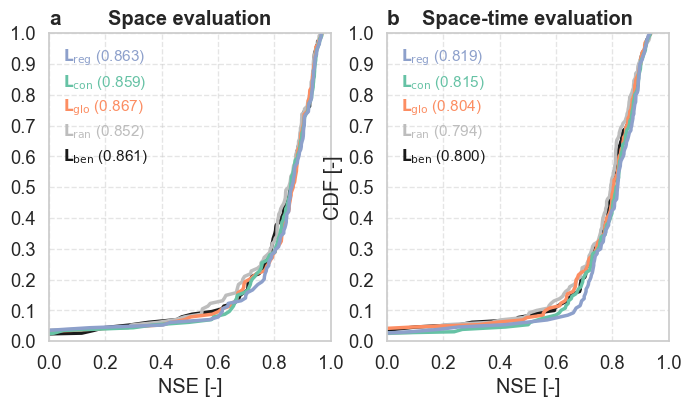

In [586]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

# -------------------------
# Color and label maps
# -------------------------
colors = {
    'nse_ran': '#bdbdbd',
    'nse_nogeo': 'k',
    'nse_g1comp': '#fc8d62',
    'nse_c1comp': '#66c2a5',
    'nse_r1comp': '#8da0cb',
}

labels_pretty = {
    'nse_ran': r"$\mathbf{L_{\mathrm{ran}}}$",
    'nse_nogeo': r"$\mathbf{L_{\mathrm{ben}}}$",
    'nse_g1comp': r"$\mathbf{L_{\mathrm{glo}}}$",
    'nse_c1comp': r"$\mathbf{L_{\mathrm{con}}}$",
    'nse_r1comp': r"$\mathbf{L_{\mathrm{reg}}}$",
}

model_order = [
    'nse_nogeo',
    'nse_ran',
    'nse_g1comp',
    'nse_c1comp',
    'nse_r1comp'
]

# -------------------------
# Plotting function
# -------------------------
def plot_cdf_mean(ax, data_input, title, label_letter):

    # Handle dict or DataFrame input
    if isinstance(data_input, dict):
        dfs = list(data_input.values())
        all_data = pd.concat(dfs, axis=0)
    elif isinstance(data_input, pd.DataFrame):
        all_data = data_input.copy()
    else:
        raise ValueError("data_input must be a dict of DataFrames or a single DataFrame.")

    # Mean over repetitions
    data_combined = all_data.groupby(all_data.index).mean()

    medians = {}

    # ---- Plot CDFs ----
    for model_type in model_order:
        if model_type not in data_combined.columns:
            continue

        nse_values = np.sort(data_combined[model_type].dropna())
        if len(nse_values) == 0:
            continue

        cumulative = np.arange(1, len(nse_values) + 1) / len(nse_values)

        ax.plot(
            nse_values,
            cumulative,
            color=colors[model_type],
            linewidth=2.5,
            label=labels_pretty[model_type]
        )

        medians[model_type] = np.median(nse_values)

    # ---- Median text inside plot ----
    y0 = 0.6        # starting vertical position (axes coords)
    dy = 0.08        # vertical spacing

    for i, model_type in enumerate(model_order):
        if model_type not in medians:
            continue

        ax.text(
            0.05,
            y0 + i * dy,
            f"{labels_pretty[model_type]} ({medians[model_type]:.3f})",
            transform=ax.transAxes,
            fontsize=11,
            color=colors[model_type],
            ha='left',
            va='center'
        )

    # ---- Axis formatting ----
    ax.set_title(title, fontweight="bold")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.0)
    ax.set_xlabel("NSE [-]")
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.yaxis.set_major_locator(ticker.MultipleLocator(0.1))

    # Subplot label
    ax.text(
        0,
        1.075,
        label_letter,
        transform=ax.transAxes,
        fontsize=15,
        fontweight='bold',
        va='top',
        ha='left'
    )

# -------------------------
# Figure layout
# -------------------------
sns.set(style="whitegrid", font_scale=1.2)
fig, axs = plt.subplots(1, 2, figsize=(8, 4), sharey=False)

# ---- Legend-only panel ----
#axs[0].axis("off")

#for model_type in model_order:
#    axs[0].plot(
#        [],
#        [],
#        color=colors[model_type],
#        linewidth=2.5,
#        label=labels_pretty[model_type]
#    )
#
#axs[0].legend(
#    title="Model experiment",
#    loc="center",
#    frameon=False,
#    fontsize=12,
#    title_fontsize=14
#)

# ---- Space evaluation ----
plot_cdf_mean(
    axs[0],
    data_diff_cal_complete_dict_plot,
    "Space evaluation",
    "a"
)

# ---- Space-time evaluation ----
plot_cdf_mean(
    axs[1],
    data_diff_val_complete_dict_plot,
    "Space-time evaluation",
    "b"
)

axs[1].set_ylabel("CDF [-]")

# ---- Save & show ----
#plt.tight_layout()
#plt.savefig(
#    "../results/figs/figures/two_cdfs_lstm_new.png",
#    dpi=300,
#    bbox_inches="tight"
#)

plt.show()

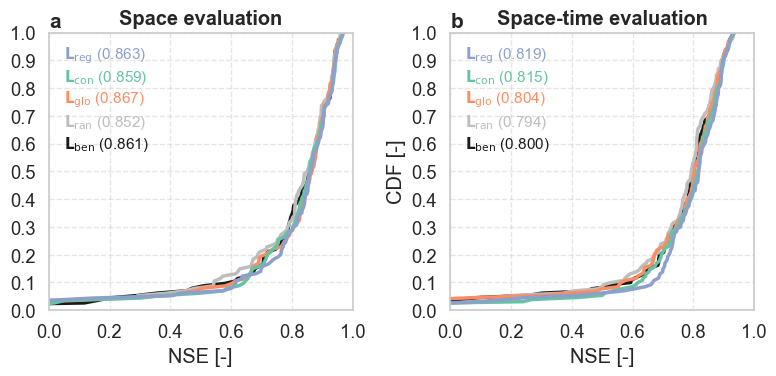

In [408]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

# -------------------------
# Color and label maps
# -------------------------
colors = {
    'nse_ran': '#bdbdbd',
    'nse_nogeo': 'k',
    'nse_g1comp': '#fc8d62',
    'nse_c1comp': '#66c2a5',
    'nse_r1comp': '#8da0cb',
}

labels_pretty = {
    'nse_ran': r"$\mathbf{L_{\mathrm{ran}}}$",
    'nse_nogeo': r"$\mathbf{L_{\mathrm{ben}}}$",
    'nse_g1comp': r"$\mathbf{L_{\mathrm{glo}}}$",
    'nse_c1comp': r"$\mathbf{L_{\mathrm{con}}}$",
    'nse_r1comp': r"$\mathbf{L_{\mathrm{reg}}}$",
}

model_order = [
    'nse_nogeo',
    'nse_ran',
    'nse_g1comp',
    'nse_c1comp',
    'nse_r1comp'
]

# -------------------------
# Plotting function
# -------------------------
def plot_cdf_mean(ax, data_input, title, label_letter):

    # Handle dict or DataFrame input
    if isinstance(data_input, dict):
        dfs = list(data_input.values())
        all_data = pd.concat(dfs, axis=0)
    elif isinstance(data_input, pd.DataFrame):
        all_data = data_input.copy()
    else:
        raise ValueError("data_input must be a dict of DataFrames or a single DataFrame.")

    # Mean over repetitions
    data_combined = all_data.groupby(all_data.index).mean()

    medians = {}

    # ---- Plot CDFs ----
    for model_type in model_order:
        if model_type not in data_combined.columns:
            continue

        nse_values = np.sort(data_combined[model_type].dropna())
        if len(nse_values) == 0:
            continue

        cumulative = np.arange(1, len(nse_values) + 1) / len(nse_values)

        ax.plot(
            nse_values,
            cumulative,
            color=colors[model_type],
            linewidth=2.5,
            label=labels_pretty[model_type]
        )

        medians[model_type] = np.median(nse_values)

    # ---- Median text inside plot ----
    y0 = 0.6        # starting vertical position (axes coords)
    dy = 0.08        # vertical spacing

    for i, model_type in enumerate(model_order):
        if model_type not in medians:
            continue

        ax.text(
            0.05,
            y0 + i * dy,
            f"{labels_pretty[model_type]} ({medians[model_type]:.3f})",
            transform=ax.transAxes,
            fontsize=11,
            color=colors[model_type],
            ha='left',
            va='center'
        )

    # ---- Axis formatting ----
    ax.set_title(title, fontweight="bold")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.0)
    ax.set_xlabel("NSE [-]")
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.yaxis.set_major_locator(ticker.MultipleLocator(0.1))

    # Subplot label
    ax.text(
        0,
        1.075,
        label_letter,
        transform=ax.transAxes,
        fontsize=15,
        fontweight='bold',
        va='top',
        ha='left'
    )

# -------------------------
# Figure layout
# -------------------------
sns.set(style="whitegrid", font_scale=1.2)
fig, axs = plt.subplots(1, 2, figsize=(8, 4), sharey=False)

# ---- Legend-only panel ----
#axs[0].axis("off")

#for model_type in model_order:
#    axs[0].plot(
#        [],
#        [],
#        color=colors[model_type],
#        linewidth=2.5,
#        label=labels_pretty[model_type]
#    )
#
#axs[0].legend(
#    title="Model experiment",
#    loc="center",
#    frameon=False,
#    fontsize=12,
#    title_fontsize=14
#)

# ---- Space evaluation ----
plot_cdf_mean(
    axs[0],
    data_diff_cal_complete_dict_plot,
    "Space evaluation",
    "a"
)

# ---- Space-time evaluation ----
plot_cdf_mean(
    axs[1],
    data_diff_val_complete_dict_plot,
    "Space-time evaluation",
    "b"
)

axs[1].set_ylabel("CDF [-]")

# ---- Save & show ----
plt.tight_layout()
plt.savefig(
    "../results/figs/figures/two_cdfs_lstm_new.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

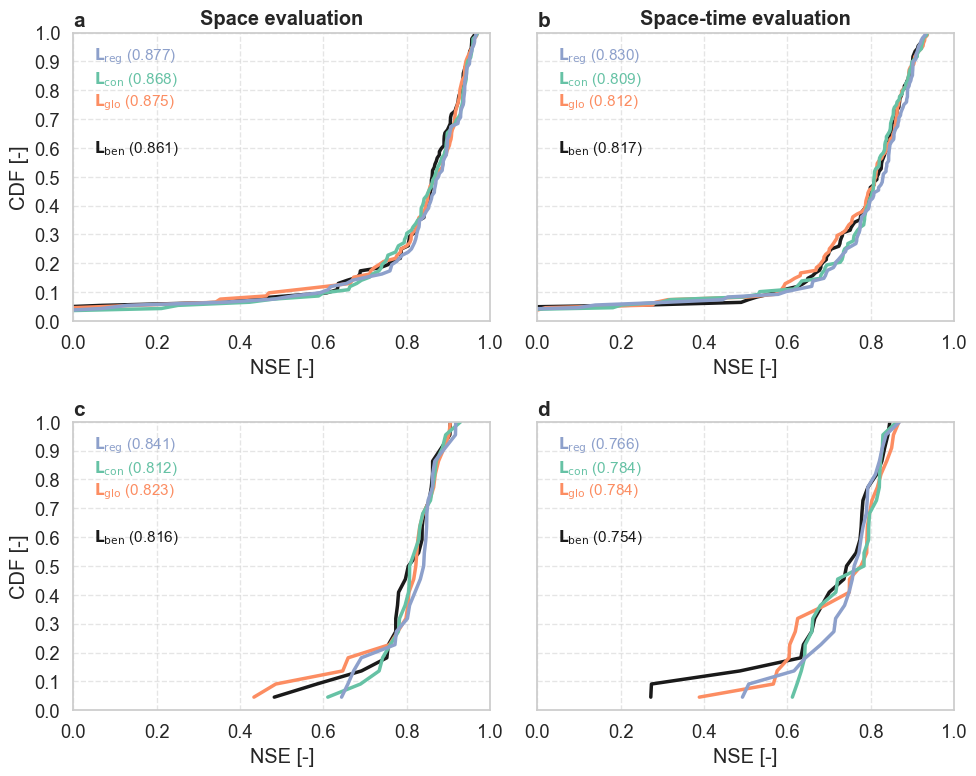

In [575]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

# -------------------------
# Color and label maps
# -------------------------
colors = {
    'nse_ran': '#bdbdbd',
    'nse_nogeo': 'k',
    'nse_g1comp': '#fc8d62',
    'nse_c1comp': '#66c2a5',
    'nse_r1comp': '#8da0cb',
}

labels_pretty = {
    'nse_ran': r"$\mathbf{L_{\mathrm{ran}}}$",
    'nse_nogeo': r"$\mathbf{L_{\mathrm{ben}}}$",
    'nse_g1comp': r"$\mathbf{L_{\mathrm{glo}}}$",
    'nse_c1comp': r"$\mathbf{L_{\mathrm{con}}}$",
    'nse_r1comp': r"$\mathbf{L_{\mathrm{reg}}}$",
}

model_order = [
    'nse_nogeo',
    'nse_ran',
    'nse_g1comp',
    'nse_c1comp',
    'nse_r1comp'
]

# -------------------------
# Plotting function (UNCHANGED)
# -------------------------
def plot_cdf_mean(ax, data_input, title, label_letter):

    if isinstance(data_input, dict):
        all_data = pd.concat(list(data_input.values()), axis=0)
    elif isinstance(data_input, pd.DataFrame):
        all_data = data_input.copy()
    else:
        raise ValueError("data_input must be a dict or DataFrame")

    data_combined = all_data.groupby(all_data.index).mean()
    medians = {}

    for model_type in model_order:
        if model_type not in data_combined.columns:
            continue

        nse_values = np.sort(data_combined[model_type].dropna())
        if len(nse_values) == 0:
            continue

        cumulative = np.arange(1, len(nse_values) + 1) / len(nse_values)

        ax.plot(
            nse_values,
            cumulative,
            color=colors[model_type],
            linewidth=2.5,
            label=labels_pretty[model_type]
        )

        medians[model_type] = np.median(nse_values)

    y0, dy = 0.6, 0.08
    for i, model_type in enumerate(model_order):
        if model_type in medians:
            ax.text(
                0.05, y0 + i * dy,
                f"{labels_pretty[model_type]} ({medians[model_type]:.3f})",
                transform=ax.transAxes,
                fontsize=11,
                color=colors[model_type],
                ha="left", va="center"
            )

    ax.set_title(title, fontweight="bold")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel("NSE [-]")
    ax.grid(True, linestyle="--", alpha=0.5)
    ax.yaxis.set_major_locator(ticker.MultipleLocator(0.1))

    ax.text(
        0, 1.075, label_letter,
        transform=ax.transAxes,
        fontsize=15, fontweight="bold",
        va="top", ha="left"
    )

# -------------------------
# Figure layout (2x2)
# -------------------------
sns.set(style="whitegrid", font_scale=1.2)
fig, axs = plt.subplots(2, 2, figsize=(10, 8), sharey=True)

basins = {
    "Moselle": network_estreams_moselle_108_gauges.index.tolist(),
    "Garonne": network_estreams_garonne_22_gauges.index.tolist(),
}

labels = ["a", "b", "c", "d"]
panel = 0

for i, (basin_name, basin_ids) in enumerate(basins.items()):

    # ---- Filter data ----
    df_space = data_diff_cal_complete_dict_plot.copy()
    df_space["basin_id"] = df_space.index
    df_space = df_space[df_space["basin_id"].isin(basin_ids)]

    df_space_time = data_diff_val_complete_dict_plot.copy()
    df_space_time["basin_id"] = df_space_time.index
    df_space_time = df_space_time[df_space_time["basin_id"].isin(basin_ids)]

    # ---- Space ----
    plot_cdf_mean(
        axs[i, 0],
        df_space.iloc[:, 0:5],
        f" ",
        labels[panel]
    )
    panel += 1

    # ---- Space-time ----
    plot_cdf_mean(
        axs[i, 1],
        df_space_time.iloc[:, 0:5],
        f" ",
        labels[panel]
    )
    panel += 1
axs[0, 0].set_title("Space evaluation", fontweight="bold")
axs[0, 1].set_title("Space-time evaluation", fontweight="bold")

# Shared y-label
axs[0, 0].set_ylabel("CDF [-]")
axs[1, 0].set_ylabel("CDF [-]")

# Legend (only once)
#axs[0, 1].legend(frameon=False, loc="lower right")

plt.tight_layout()
plt.savefig(
    "../results/figs/figures/SX_four_cdfs_lstm_moselle_garonne.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


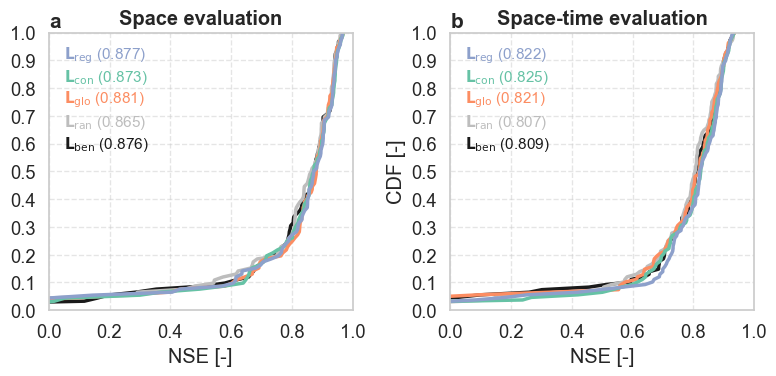

In [409]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

# -------------------------
# Color and label maps
# -------------------------
colors = {
    'nse_ran': '#bdbdbd',
    'nse_nogeo': 'k',
    'nse_g1comp': '#fc8d62',
    'nse_c1comp': '#66c2a5',
    'nse_r1comp': '#8da0cb',
}

labels_pretty = {
    'nse_ran': r"$\mathbf{L_{\mathrm{ran}}}$",
    'nse_nogeo': r"$\mathbf{L_{\mathrm{ben}}}$",
    'nse_g1comp': r"$\mathbf{L_{\mathrm{glo}}}$",
    'nse_c1comp': r"$\mathbf{L_{\mathrm{con}}}$",
    'nse_r1comp': r"$\mathbf{L_{\mathrm{reg}}}$",
}

model_order = [
    'nse_nogeo',
    'nse_ran',
    'nse_g1comp',
    'nse_c1comp',
    'nse_r1comp'
]

# -------------------------
# Plotting function
# -------------------------
def plot_cdf_mean(ax, data_input, title, label_letter):

    # Handle dict or DataFrame input
    if isinstance(data_input, dict):
        dfs = list(data_input.values())
        all_data = pd.concat(dfs, axis=0)
    elif isinstance(data_input, pd.DataFrame):
        all_data = data_input.copy()
    else:
        raise ValueError("data_input must be a dict of DataFrames or a single DataFrame.")

    # Mean over repetitions
    data_combined = all_data.groupby(all_data.index).mean()

    medians = {}

    # ---- Plot CDFs ----
    for model_type in model_order:
        if model_type not in data_combined.columns:
            continue

        nse_values = np.sort(data_combined[model_type].dropna())
        if len(nse_values) == 0:
            continue

        cumulative = np.arange(1, len(nse_values) + 1) / len(nse_values)

        ax.plot(
            nse_values,
            cumulative,
            color=colors[model_type],
            linewidth=2.5,
            label=labels_pretty[model_type]
        )

        medians[model_type] = np.median(nse_values)

    # ---- Median text inside plot ----
    y0 = 0.6        # starting vertical position (axes coords)
    dy = 0.08        # vertical spacing

    for i, model_type in enumerate(model_order):
        if model_type not in medians:
            continue

        ax.text(
            0.05,
            y0 + i * dy,
            f"{labels_pretty[model_type]} ({medians[model_type]:.3f})",
            transform=ax.transAxes,
            fontsize=11,
            color=colors[model_type],
            ha='left',
            va='center'
        )

    # ---- Axis formatting ----
    ax.set_title(title, fontweight="bold")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.0)
    ax.set_xlabel("NSE [-]")
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.yaxis.set_major_locator(ticker.MultipleLocator(0.1))

    # Subplot label
    ax.text(
        0,
        1.075,
        label_letter,
        transform=ax.transAxes,
        fontsize=15,
        fontweight='bold',
        va='top',
        ha='left'
    )

# -------------------------
# Figure layout
# -------------------------
sns.set(style="whitegrid", font_scale=1.2)
fig, axs = plt.subplots(1, 2, figsize=(8, 4), sharey=False)

# SELECT BASIN GROUP
BASIN = "moselle"  # "moselle" or "garonne"

if BASIN == "moselle":
    basin_ids = network_estreams_moselle_108_gauges.index.tolist()
elif BASIN == "garonne":
    basin_ids = network_estreams_garonne_22_gauges.index.tolist()
else:
    raise ValueError("Unknown BASIN")

# FILTER DATA
data_plot_moselle = data_diff_cal_complete_dict_plot.copy()
data_plot_moselle["basin_id"] = data_plot_moselle.index
data_plot_moselle = data_plot_moselle[
    data_plot_moselle["basin_id"].isin(basin_ids)
].copy()

data_plot_moselle_space_time = data_diff_val_complete_dict_plot.copy()
data_plot_moselle_space_time["basin_id"] = data_plot_moselle_space_time.index
data_plot_moselle_space_time = data_plot_moselle_space_time[
    data_plot_moselle_space_time["basin_id"].isin(basin_ids)
].copy()

# ---- Space evaluation ----
plot_cdf_mean(
    axs[0],
    data_plot_moselle.iloc[:, 0:5],
    "Space evaluation",
    "a"
)

# ---- Space-time evaluation ----
plot_cdf_mean(
    axs[1],
    data_plot_moselle_space_time.iloc[:, 0:5],
    "Space-time evaluation",
    "b"
)

axs[1].set_ylabel("CDF [-]")

# ---- Save & show ----
plt.tight_layout()
plt.savefig(
    "../results/figs/figures/two_cdfs_lstm_moselle.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

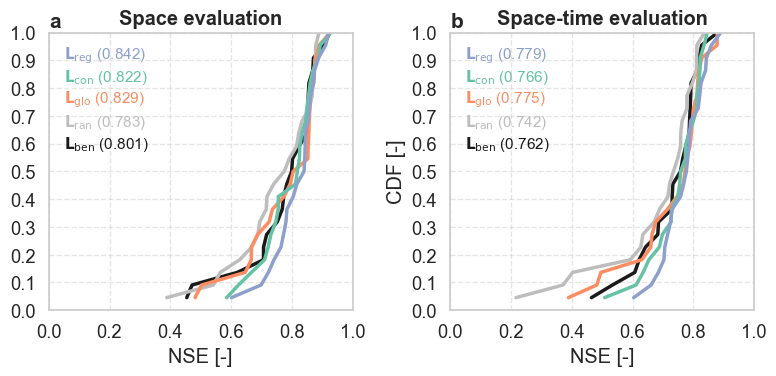

In [410]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

# -------------------------
# Color and label maps
# -------------------------
colors = {
    'nse_ran': '#bdbdbd',
    'nse_nogeo': 'k',
    'nse_g1comp': '#fc8d62',
    'nse_c1comp': '#66c2a5',
    'nse_r1comp': '#8da0cb',
}

labels_pretty = {
    'nse_ran': r"$\mathbf{L_{\mathrm{ran}}}$",
    'nse_nogeo': r"$\mathbf{L_{\mathrm{ben}}}$",
    'nse_g1comp': r"$\mathbf{L_{\mathrm{glo}}}$",
    'nse_c1comp': r"$\mathbf{L_{\mathrm{con}}}$",
    'nse_r1comp': r"$\mathbf{L_{\mathrm{reg}}}$",
}

model_order = [
    'nse_nogeo',
    'nse_ran',
    'nse_g1comp',
    'nse_c1comp',
    'nse_r1comp'
]

# -------------------------
# Plotting function
# -------------------------
def plot_cdf_mean(ax, data_input, title, label_letter):

    # Handle dict or DataFrame input
    if isinstance(data_input, dict):
        dfs = list(data_input.values())
        all_data = pd.concat(dfs, axis=0)
    elif isinstance(data_input, pd.DataFrame):
        all_data = data_input.copy()
    else:
        raise ValueError("data_input must be a dict of DataFrames or a single DataFrame.")

    # Mean over repetitions
    data_combined = all_data.groupby(all_data.index).mean()

    medians = {}

    # ---- Plot CDFs ----
    for model_type in model_order:
        if model_type not in data_combined.columns:
            continue

        nse_values = np.sort(data_combined[model_type].dropna())
        if len(nse_values) == 0:
            continue

        cumulative = np.arange(1, len(nse_values) + 1) / len(nse_values)

        ax.plot(
            nse_values,
            cumulative,
            color=colors[model_type],
            linewidth=2.5,
            label=labels_pretty[model_type]
        )

        medians[model_type] = np.median(nse_values)

    # ---- Median text inside plot ----
    y0 = 0.6        # starting vertical position (axes coords)
    dy = 0.08        # vertical spacing

    for i, model_type in enumerate(model_order):
        if model_type not in medians:
            continue

        ax.text(
            0.05,
            y0 + i * dy,
            f"{labels_pretty[model_type]} ({medians[model_type]:.3f})",
            transform=ax.transAxes,
            fontsize=11,
            color=colors[model_type],
            ha='left',
            va='center'
        )

    # ---- Axis formatting ----
    ax.set_title(title, fontweight="bold")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.0)
    ax.set_xlabel("NSE [-]")
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.yaxis.set_major_locator(ticker.MultipleLocator(0.1))

    # Subplot label
    ax.text(
        0,
        1.075,
        label_letter,
        transform=ax.transAxes,
        fontsize=15,
        fontweight='bold',
        va='top',
        ha='left'
    )

# -------------------------
# Figure layout
# -------------------------
sns.set(style="whitegrid", font_scale=1.2)
fig, axs = plt.subplots(1, 2, figsize=(8, 4), sharey=False)

# SELECT BASIN GROUP
BASIN = "garonne"  # "moselle" or "garonne"

if BASIN == "moselle":
    basin_ids = network_estreams_moselle_108_gauges.index.tolist()
elif BASIN == "garonne":
    basin_ids = network_estreams_garonne_22_gauges.index.tolist()
else:
    raise ValueError("Unknown BASIN")

# FILTER DATA
data_plot_moselle = data_diff_cal_complete_dict_plot.copy()
data_plot_moselle["basin_id"] = data_plot_moselle.index
data_plot_moselle = data_plot_moselle[
    data_plot_moselle["basin_id"].isin(basin_ids)
].copy()

data_plot_moselle_space_time = data_diff_val_complete_dict_plot.copy()
data_plot_moselle_space_time["basin_id"] = data_plot_moselle_space_time.index
data_plot_moselle_space_time = data_plot_moselle_space_time[
    data_plot_moselle_space_time["basin_id"].isin(basin_ids)
].copy()

# ---- Space evaluation ----
plot_cdf_mean(
    axs[0],
    data_plot_moselle.iloc[:, 0:5],
    "Space evaluation",
    "a"
)

# ---- Space-time evaluation ----
plot_cdf_mean(
    axs[1],
    data_plot_moselle_space_time.iloc[:, 0:5],
    "Space-time evaluation",
    "b"
)

axs[1].set_ylabel("CDF [-]")

# ---- Save & show ----
plt.tight_layout()
plt.savefig(
    "../results/figs/figures/two_cdfs_lstm_garonne.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

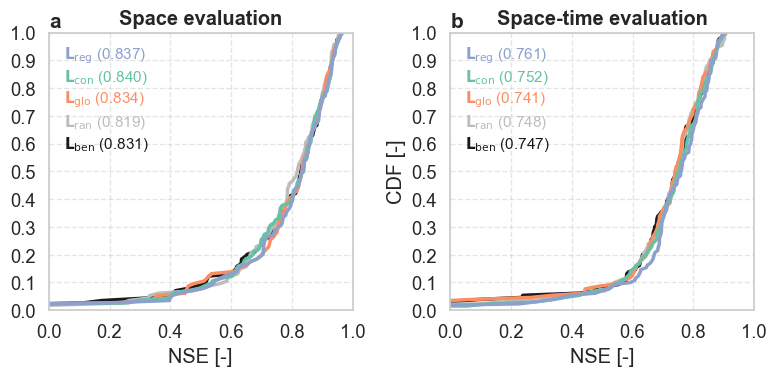

In [411]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

# -------------------------
# Color and label maps
# -------------------------
colors = {
    'nse_ran': '#bdbdbd',
    'nse_nogeo': 'k',
    'nse_g1comp': '#fc8d62',
    'nse_c1comp': '#66c2a5',
    'nse_r1comp': '#8da0cb',
}

labels_pretty = {
    'nse_ran': r"$\mathbf{L_{\mathrm{ran}}}$",
    'nse_nogeo': r"$\mathbf{L_{\mathrm{ben}}}$",
    'nse_g1comp': r"$\mathbf{L_{\mathrm{glo}}}$",
    'nse_c1comp': r"$\mathbf{L_{\mathrm{con}}}$",
    'nse_r1comp': r"$\mathbf{L_{\mathrm{reg}}}$",
}

model_order = [
    'nse_nogeo',
    'nse_ran',
    'nse_g1comp',
    'nse_c1comp',
    'nse_r1comp'
]

# -------------------------
# Plotting function
# -------------------------
def plot_cdf_mean(ax, data_input, title, label_letter):

    # Handle dict or DataFrame input
    if isinstance(data_input, dict):
        dfs = list(data_input.values())
        all_data = pd.concat(dfs, axis=0)
    elif isinstance(data_input, pd.DataFrame):
        all_data = data_input.copy()
    else:
        raise ValueError("data_input must be a dict of DataFrames or a single DataFrame.")

    # Mean over repetitions
    data_combined = all_data.groupby(all_data.index).mean()

    medians = {}

    # ---- Plot CDFs ----
    for model_type in model_order:
        if model_type not in data_combined.columns:
            continue

        nse_values = np.sort(data_combined[model_type].dropna())
        if len(nse_values) == 0:
            continue

        cumulative = np.arange(1, len(nse_values) + 1) / len(nse_values)

        ax.plot(
            nse_values,
            cumulative,
            color=colors[model_type],
            linewidth=2.5,
            label=labels_pretty[model_type]
        )

        medians[model_type] = np.median(nse_values)

    # ---- Median text inside plot ----
    y0 = 0.6        # starting vertical position (axes coords)
    dy = 0.08        # vertical spacing

    for i, model_type in enumerate(model_order):
        if model_type not in medians:
            continue

        ax.text(
            0.05,
            y0 + i * dy,
            f"{labels_pretty[model_type]} ({medians[model_type]:.3f})",
            transform=ax.transAxes,
            fontsize=11,
            color=colors[model_type],
            ha='left',
            va='center'
        )

    # ---- Axis formatting ----
    ax.set_title(title, fontweight="bold")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.0)
    ax.set_xlabel("NSE [-]")
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.yaxis.set_major_locator(ticker.MultipleLocator(0.1))

    # Subplot label
    ax.text(
        0,
        1.075,
        label_letter,
        transform=ax.transAxes,
        fontsize=15,
        fontweight='bold',
        va='top',
        ha='left'
    )

# -------------------------
# Figure layout
# -------------------------
sns.set(style="whitegrid", font_scale=1.2)
fig, axs = plt.subplots(1, 2, figsize=(8, 4), sharey=False)

# ---- Legend-only panel ----
#axs[0].axis("off")

#for model_type in model_order:
#    axs[0].plot(
#        [],
#        [],
#        color=colors[model_type],
#        linewidth=2.5,
#        label=labels_pretty[model_type]
#    )
#
#axs[0].legend(
#    title="Model experiment",
#    loc="center",
#    frameon=False,
#    fontsize=12,
#    title_fontsize=14
#)

# ---- Space evaluation ----
plot_cdf_mean(
    axs[0],
    data_diff_cal_complete_dict_plot_nse,
    "Space evaluation",
    "a"
)

# ---- Space-time evaluation ----
plot_cdf_mean(
    axs[1],
    data_diff_val_complete_dict_plot_nse,
    "Space-time evaluation",
    "b"
)

axs[1].set_ylabel("CDF [-]")

# ---- Save & show ----
plt.tight_layout()
plt.savefig(
    "../results/figs/figures/two_cdfs_lstm_nse.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [44]:
data_diff_val_complete_dict_plot.describe(percentiles=[0.1, 0.5, 0.75])

,nse_nogeo,nse_ran,nse_g1comp,nse_c1comp,nse_r1comp,kge_nogeo,kge_ran,kge_g1comp,kge_c1comp,kge_r1comp,...,slope_c1comp,slope_g1comp,slope_nogeo,slope_ran,qmean_obs,qmean_r1comp,qmean_c1comp,qmean_g1comp,qmean_nogeo,qmean_ran
count,130.000000,130.000000,130.000000,130.000000,130.000000,130.000000,130.000000,130.000000,130.000000,130.000000,...,124.000000,124.000000,124.000000,124.000000,130.000000,130.000000,130.000000,130.000000,130.000000,130.000000
mean,0.744625,0.738099,0.729276,0.746071,0.767626,0.649114,0.647405,0.628534,0.634083,0.655285,...,2.309299,2.232137,2.563897,2.297890,1.097993,0.974089,0.976531,0.976241,0.983741,0.975994
std,0.252641,0.244079,0.297616,0.265845,0.224208,0.171158,0.154699,0.174235,0.159392,0.147344,...,1.048874,0.686715,4.116105,0.909880,0.567213,0.544507,0.539699,0.554416,0.542339,0.536828
min,-0.626134,-0.751068,-1.288557,-1.195214,-0.939913,-0.129796,0.060009,-0.107687,0.095161,0.150734,...,0.645157,0.575910,0.703732,0.954103,0.264454,0.158411,0.149758,0.245517,0.154001,0.202980
10%,0.634166,0.619239,0.569096,0.587575,0.673408,0.471913,0.442626,0.428050,0.415381,0.476969,...,1.465997,1.570566,1.564056,1.507349,0.610847,0.548710,0.528746,0.520463,0.538511,0.542935
50%,0.812218,0.790756,0.803938,0.809831,0.814890,0.683655,0.658138,0.657775,0.656699,0.672414,...,2.195014,2.155957,2.115632,2.115397,0.962306,0.819703,0.826357,0.824993,0.826926,0.828740
75%,0.870163,0.862942,0.860374,0.868294,0.866657,0.758412,0.762904,0.743353,0.733075,0.754854,...,2.591142,2.495120,2.458025,2.503500,1.236292,1.080559,1.125792,1.107504,1.096083,1.089325
max,0.935711,0.945463,0.935300,0.938365,0.933993,0.938696,0.902790,0.920502,0.915386,0.928687,...,9.580139,5.979901,47.414585,7.000180,3.618939,3.443423,3.299633,3.337147,3.388625,3.609942


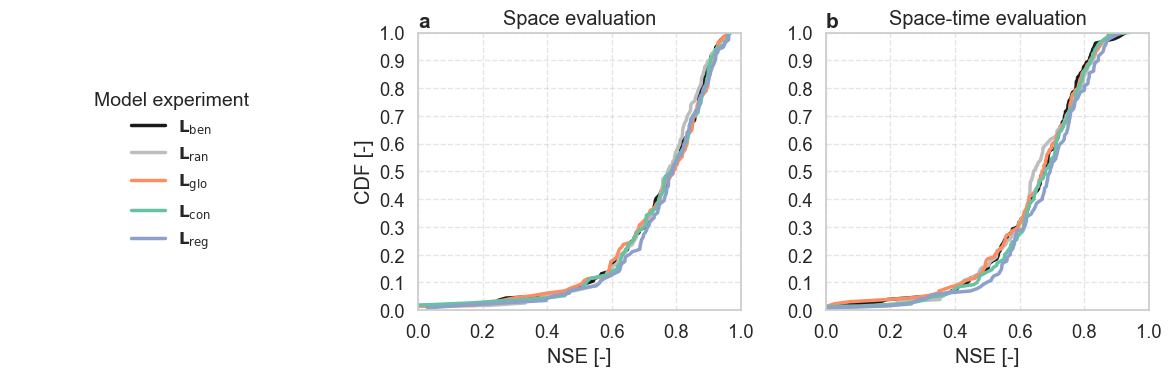

In [368]:
import matplotlib.ticker as ticker
import seaborn as sns

# Color and label maps
colors = {
    'kge_ran': '#bdbdbd',
    'kge_nogeo': 'k',
    'kge_g1comp': '#fc8d62',
    'kge_c1comp': '#66c2a5',
    'kge_r1comp': '#8da0cb',

}
labels_pretty = {
    'kge_ran': r"$\mathbf{L_{\mathrm{ran}}}$",
    'kge_nogeo': r"$\mathbf{L_{\mathrm{ben}}}$",
    'kge_g1comp': r"$\mathbf{L_{\mathrm{glo}}}$",
    'kge_c1comp': r"$\mathbf{L_{\mathrm{con}}}$",
    'kge_r1comp': r"$\mathbf{L_{\mathrm{reg}}}$",

}

# Plotting function
def plot_cdf_mean(ax, data_input, title, label_letter):
    # Check if input is a dict or DataFrame
    if isinstance(data_input, dict):
        dfs = list(data_input.values())
        all_data = pd.concat(dfs, axis=0)
    elif isinstance(data_input, pd.DataFrame):
        all_data = data_input.copy()
    else:
        raise ValueError("data_input must be a dict of DataFrames or a single DataFrame.")
    
    data_combined = all_data.groupby(all_data.index).mean()

    for model_type in ['kge_nogeo', "kge_ran", 'kge_g1comp', 'kge_c1comp', 'kge_r1comp']:
        if model_type not in data_combined.columns:
            continue
        nse_values = np.sort(data_combined[model_type].dropna())
        if len(nse_values) == 0:
            continue
        cumulative = np.arange(1, len(nse_values) + 1) / len(nse_values)
        ax.plot(
            nse_values, cumulative,
            color=colors[model_type],
            linewidth=2.5,
            label=labels_pretty[model_type]
        )
    ax.set_title(title)
    ax.set_xlim(-0.0, 0.95)
    ax.set_ylim(0, 1.0)
    ax.set_xlabel("NSE [-]")
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.yaxis.set_major_locator(ticker.MultipleLocator(0.1))

    # Subplot label (a, b, c)
    ax.text(0, 1.075, label_letter, transform=ax.transAxes,
            fontsize=15, fontweight='bold', va='top', ha='left')
    
fig, axs = plt.subplots(1, 3, figsize=(12, 4), sharey=False)
sns.set(style="whitegrid", font_scale=1.2)

# --- ax[0]: legend only (no plot) ---
axs[0].axis("off")

for model_type in ['kge_nogeo', 'kge_ran', 'kge_g1comp', 'kge_c1comp', 'kge_r1comp']:

    axs[0].plot([], [],
                color=colors[model_type],
                linewidth=2.5,
                label=labels_pretty[model_type])

axs[0].legend(
    title="Model experiment",
    loc="center",
    frameon=False,
    fontsize=12,
    title_fontsize=14
)

# --- Space evaluation ---
plot_cdf_mean(axs[1], data_diff_cal_complete_dict_plot, "Space evaluation", "a")

# --- Space-time evaluation ---
plot_cdf_mean(axs[2], data_diff_val_complete_dict_plot, "Space-time evaluation", "b")

axs[1].set_xlim(0, 1)
axs[2].set_xlim(0, 1)

axs[1].set_ylabel("CDF [-]")
# Final layout
plt.tight_layout()
plt.savefig(
    "../results/figs/figures/two_cdfs_lstm_kge.png",
    dpi=300,
    bbox_inches='tight'
)
plt.show()


In [412]:
moselle_ids = network_estreams_moselle_108_gauges.index.tolist()
garonne_ids = network_estreams_garonne_22_gauges.index.tolist()
is_moselle = data_diff_val_complete_dict_plot.index.isin(moselle_ids)
is_garonne = data_diff_val_complete_dict_plot.index.isin(garonne_ids)


data_diff_val_complete_dict_plot_garonne = data_diff_val_complete_dict_plot.loc[is_garonne]
data_diff_val_complete_dict_plot_moselle = data_diff_val_complete_dict_plot.loc[is_moselle]
data_diff_val_complete_dict_plot_garonne_nse = data_diff_val_complete_dict_plot_nse.loc[is_garonne]
data_diff_val_complete_dict_plot_moselle_nse = data_diff_val_complete_dict_plot_nse.loc[is_moselle]

data_diff_cal_complete_dict_plot_garonne = data_diff_cal_complete_dict_plot.loc[is_garonne]
data_diff_cal_complete_dict_plot_moselle = data_diff_cal_complete_dict_plot.loc[is_moselle]

In [375]:
data_diff_val_complete_dict_plot.describe()

,nse_nogeo,nse_ran,nse_g1comp,nse_c1comp,nse_r1comp,kge_nogeo,kge_ran,kge_g1comp,kge_c1comp,kge_r1comp,...,slope_c1comp,slope_g1comp,slope_nogeo,slope_ran,qmean_obs,qmean_r1comp,qmean_c1comp,qmean_g1comp,qmean_nogeo,qmean_ran
count,130.000000,130.000000,130.000000,130.000000,130.000000,130.000000,130.000000,130.000000,130.000000,130.000000,...,125.000000,125.000000,125.000000,125.000000,130.000000,130.000000,130.000000,130.000000,130.000000,130.000000
mean,0.738398,0.730104,0.728728,0.742784,0.754406,0.642575,0.644084,0.638080,0.653263,0.671092,...,2.384708,2.326945,2.714460,2.678176,1.113387,1.018553,1.007665,0.995708,1.000441,0.983922
std,0.253107,0.253721,0.326144,0.370786,0.299672,0.168032,0.159312,0.179166,0.168655,0.155446,...,1.183285,0.901600,4.223610,4.298727,0.561159,0.559732,0.538662,0.545137,0.549398,0.546921
min,-0.816039,-0.971490,-1.916667,-2.942201,-1.682266,0.009880,0.025915,-0.092223,-0.336538,-0.035215,...,0.747716,0.713360,1.005404,1.080153,0.253320,0.175839,0.141559,0.184009,0.112433,0.187384
25%,0.727051,0.717353,0.722640,0.724265,0.737341,0.555974,0.568535,0.555874,0.591180,0.585288,...,1.908695,1.903003,1.874935,1.790670,0.804317,0.676923,0.690997,0.673162,0.685929,0.646316
50%,0.800658,0.790566,0.807039,0.814291,0.822714,0.676408,0.645997,0.671818,0.680356,0.694575,...,2.243906,2.084246,2.139510,2.162392,0.978313,0.847235,0.867811,0.865135,0.841113,0.843496
75%,0.870916,0.856346,0.868795,0.873485,0.878430,0.752637,0.769727,0.758921,0.771368,0.770184,...,2.542329,2.573787,2.506553,2.656951,1.264618,1.161300,1.126785,1.137231,1.119091,1.101243
max,0.937849,0.936936,0.941168,0.939287,0.937942,0.929081,0.921731,0.911786,0.938355,0.905918,...,11.385911,7.472318,45.874809,49.381943,3.501853,3.329050,3.172571,3.192915,3.387806,3.680873


In [313]:
data_diff_val_complete_dict_plot_moselle_nse[["nse_nogeo","nse_ran", "nse_g1comp", "nse_c1comp", "nse_r1comp"]].describe()

,nse_nogeo,nse_ran,nse_g1comp,nse_c1comp,nse_r1comp
count,108.000000,108.000000,108.000000,108.000000,108.000000
mean,0.716202,0.722136,0.686328,0.702808,0.732717
std,0.209719,0.177882,0.287306,0.279501,0.176745
min,-0.477622,-0.283514,-0.866132,-1.631364,-0.209921
25%,0.680638,0.684819,0.679604,0.691174,0.689604
50%,0.757136,0.759525,0.739581,0.758803,0.771820
75%,0.830288,0.824019,0.821773,0.824898,0.828929
max,0.913564,0.921635,0.912668,0.913572,0.903095


In [314]:
data_diff_val_complete_dict_plot_garonne_nse[["nse_nogeo","nse_ran", "nse_g1comp", "nse_c1comp", "nse_r1comp"]].describe()

,nse_nogeo,nse_ran,nse_g1comp,nse_c1comp,nse_r1comp
count,22.000000,22.000000,22.000000,22.000000,22.000000
mean,0.680554,0.679773,0.688844,0.686401,0.692453
std,0.092456,0.113464,0.091032,0.099545,0.097008
min,0.507770,0.251558,0.475567,0.457380,0.466653
25%,0.636757,0.648134,0.634105,0.621885,0.636257
50%,0.697309,0.681998,0.697452,0.708059,0.705492
75%,0.724744,0.725009,0.733587,0.766379,0.759871
max,0.839229,0.828669,0.838207,0.828951,0.845089


In [315]:
data_diff_val_complete_dict_plot[["nse_nogeo","nse_ran", "nse_g1comp", "nse_c1comp", "nse_r1comp"]].describe()

,nse_nogeo,nse_ran,nse_g1comp,nse_c1comp,nse_r1comp
count,130.000000,130.000000,130.000000,130.000000,130.000000
mean,0.750057,0.745187,0.732833,0.745953,0.769917
std,0.226085,0.217984,0.278461,0.283140,0.221584
min,-0.468478,-0.666287,-0.990799,-1.575807,-0.784436
25%,0.725174,0.719104,0.717377,0.728415,0.748054
50%,0.807414,0.788304,0.804175,0.811897,0.817176
75%,0.870326,0.864380,0.861679,0.872316,0.873856
max,0.943191,0.947512,0.938097,0.943589,0.936916


In [57]:
data_diff_val_complete_dict_plot_nse[["nse_nogeo","nse_ran", "nse_g1comp", "nse_c1comp", "nse_r1comp"]].describe()

,nse_nogeo,nse_ran,nse_g1comp,nse_c1comp,nse_r1comp
count,130.000000,130.000000,130.000000,130.000000,130.000000
mean,0.709014,0.713299,0.686266,0.704071,0.725222
std,0.216417,0.174452,0.273659,0.226473,0.159180
min,-0.541889,-0.274558,-1.166234,-1.126255,-0.206613
25%,0.672687,0.667588,0.672646,0.673633,0.672914
50%,0.746704,0.740945,0.737691,0.751941,0.762182
75%,0.824651,0.818071,0.814187,0.814971,0.817888
max,0.911569,0.922954,0.913720,0.912469,0.905412


In [317]:
data_diff_val_complete_dict_plot_moselle[["kge_nogeo","kge_ran", "kge_g1comp", "kge_c1comp", "kge_r1comp"]].describe()

,kge_nogeo,kge_ran,kge_g1comp,kge_c1comp,kge_r1comp
count,108.000000,108.000000,108.000000,108.000000,108.000000
mean,0.663684,0.667107,0.643134,0.653227,0.683439
std,0.166874,0.150893,0.182339,0.163125,0.147557
min,-0.053872,0.098766,-0.123264,-0.002077,0.209737
25%,0.598964,0.593921,0.570016,0.581755,0.612966
50%,0.701327,0.688503,0.687256,0.677146,0.703241
75%,0.769755,0.772795,0.761433,0.758994,0.789476
max,0.942583,0.905275,0.886379,0.909914,0.903339


In [318]:
data_diff_val_complete_dict_plot_garonne[["kge_nogeo","kge_ran", "kge_g1comp", "kge_c1comp", "kge_r1comp"]].describe()

,kge_nogeo,kge_ran,kge_g1comp,kge_c1comp,kge_r1comp
count,22.000000,22.000000,22.000000,22.000000,22.000000
mean,0.611499,0.591325,0.619686,0.611775,0.623230
std,0.154161,0.141853,0.135230,0.150885,0.149438
min,0.285811,0.200055,0.402697,0.325178,0.268655
25%,0.488739,0.527009,0.514098,0.488754,0.524846
50%,0.641768,0.591899,0.605836,0.636889,0.629331
75%,0.682272,0.658430,0.696481,0.697348,0.711043
max,0.911298,0.826487,0.907831,0.907820,0.909324


In [571]:
data_diff_cal_complete_dict_plot[["kge_nogeo","kge_ran", "kge_g1comp", "kge_c1comp", "kge_r1comp"]].describe()

,kge_nogeo,kge_ran,kge_g1comp,kge_c1comp,kge_r1comp
count,114.000000,114.000000,114.000000,114.000000,114.000000
mean,0.744990,0.740228,0.743219,0.739745,0.757874
std,0.181262,0.180449,0.208126,0.177079,0.159233
min,-0.226854,-0.218232,-0.419937,-0.218258,-0.051987
25%,0.677229,0.666248,0.671200,0.642445,0.678263
50%,0.790144,0.781382,0.806866,0.772364,0.798970
75%,0.863810,0.851861,0.876910,0.865258,0.865866
max,0.962203,0.968768,0.961882,0.969964,0.971948


In [532]:
data_diff_cal_complete_dict_plot[["nse_nogeo","nse_ran", "nse_g1comp", "nse_c1comp", "nse_r1comp"]].describe()

,nse_nogeo,nse_ran,nse_g1comp,nse_c1comp,nse_r1comp
count,114.000000,114.000000,114.000000,114.000000,114.000000
mean,0.772796,0.753815,0.770398,0.781169,0.794360
std,0.256764,0.319022,0.272618,0.229021,0.212227
min,-0.750437,-1.788739,-0.617708,-0.353433,-0.400694
25%,0.748873,0.720387,0.766826,0.748336,0.761298
50%,0.850134,0.830271,0.853954,0.848262,0.844611
75%,0.909307,0.905245,0.904087,0.910994,0.908709
max,0.966466,0.959062,0.971837,0.955519,0.964140


In [361]:
data_diff_val_complete_dict_plot[["kge_nogeo","kge_ran", "kge_g1comp", "kge_c1comp", "kge_r1comp"]].describe()

,kge_nogeo,kge_ran,kge_g1comp,kge_c1comp,kge_r1comp
count,130.000000,130.000000,130.000000,130.000000,130.000000
mean,0.627382,0.632251,0.626355,0.623744,0.637714
std,0.217122,0.177924,0.209166,0.203377,0.190268
min,-0.506465,0.031655,-0.436065,-0.450336,-0.380303
25%,0.540530,0.536252,0.533487,0.535627,0.551481
50%,0.657645,0.648677,0.675853,0.665539,0.675679
75%,0.764369,0.759068,0.778824,0.752095,0.772640
max,0.930445,0.918324,0.885892,0.919611,0.879921


In [369]:
data_diff_val_complete_dict_plot[["nse_nogeo","nse_ran", "nse_g1comp", "nse_c1comp", "nse_r1comp"]].describe()

,nse_nogeo,nse_ran,nse_g1comp,nse_c1comp,nse_r1comp
count,130.000000,130.000000,130.000000,130.000000,130.000000
mean,0.667944,0.688860,0.661854,0.659189,0.676113
std,0.332581,0.200750,0.292001,0.390298,0.347257
min,-1.939681,-0.409595,-0.896484,-2.872514,-2.518773
25%,0.648017,0.656465,0.637201,0.643891,0.653990
50%,0.737936,0.727940,0.730663,0.732031,0.741691
75%,0.806510,0.804194,0.806317,0.813659,0.812041
max,0.920054,0.913530,0.910882,0.912640,0.917547


In [370]:
data_diff_cal_complete_dict_plot[["nse_nogeo","nse_ran", "nse_g1comp", "nse_c1comp", "nse_r1comp"]].describe()

,nse_nogeo,nse_ran,nse_g1comp,nse_c1comp,nse_r1comp
count,114.000000,114.000000,114.000000,114.000000,114.000000
mean,0.717663,0.734538,0.724046,0.720045,0.728894
std,0.361953,0.261541,0.296113,0.320861,0.312479
min,-2.349016,-1.226636,-1.488425,-1.332753,-1.523748
25%,0.696640,0.698193,0.704052,0.672634,0.703252
50%,0.812840,0.788481,0.804891,0.799417,0.807323
75%,0.882589,0.879484,0.880337,0.880189,0.883063
max,0.961060,0.949394,0.949959,0.951519,0.952416


In [580]:
data_diff_timeval_complete_dict_plot[["nse_nogeo","nse_ran", "nse_g1comp", "nse_c1comp", "nse_r1comp"]].describe()

,nse_nogeo,nse_ran,nse_g1comp,nse_c1comp,nse_r1comp
count,130.000000,130.000000,130.000000,130.000000,130.000000
mean,0.764887,0.765002,0.753615,0.752004,0.761911
std,0.120267,0.127810,0.128358,0.117404,0.108546
min,0.113565,0.191713,0.150473,0.259707,0.278195
25%,0.725370,0.722865,0.710067,0.703895,0.713647
50%,0.782179,0.787898,0.779592,0.781988,0.782124
75%,0.840091,0.842350,0.840036,0.830336,0.834492
max,0.942419,0.938634,0.935170,0.936591,0.927033


In [321]:
def compute_ccc(x, y):
    x = np.asarray(x)
    y = np.asarray(y)

    mask = ~np.isnan(x) & ~np.isnan(y)
    x = x[mask]
    y = y[mask]

    if len(x) == 0:
        return np.nan

    mean_x = np.mean(x)
    mean_y = np.mean(y)
    var_x = np.var(x)
    var_y = np.var(y)
    cov_xy = np.mean((x - mean_x) * (y - mean_y))

    return (2 * cov_xy) / (var_x + var_y + (mean_x - mean_y) ** 2)


In [414]:
data_diff_val_complete_dict_plot[data_diff_val_complete_dict_plot["slope_obs"] > 5][["slope_obs", "slope_ran", "slope_nogeo", "slope_c1comp", "slope_r1comp", "slope_g1comp"]]

,slope_obs,slope_ran,slope_nogeo,slope_c1comp,slope_r1comp,slope_g1comp
FR001592,5.256370,6.154612,46.197067,6.462117,4.142930,2.099771
FR004140,6.301340,49.513023,19.125015,11.386008,8.341786,7.669191
FR004119,7.159544,6.326258,7.398870,7.371253,7.160630,5.983373


In [416]:
cols = ["slope_c1comp", "slope_r1comp", "slope_g1comp", "slope_nogeo", "slope_ran"]

data_diff_val_complete_dict_plot[
    (data_diff_val_complete_dict_plot[cols] > 10).any(axis=1)
][["slope_obs"] + cols]


,slope_obs,slope_c1comp,slope_r1comp,slope_g1comp,slope_nogeo,slope_ran
FR001592,5.25637,6.462117,4.142930,2.099771,46.197067,6.154612
FR004140,6.30134,11.386008,8.341786,7.669191,19.125015,49.513023


In [588]:
letters = list(string.ascii_lowercase)
letters

['a',
 'b',
 'c',
 'd',
 'e',
 'f',
 'g',
 'h',
 'i',
 'j',
 'k',
 'l',
 'm',
 'n',
 'o',
 'p',
 'q',
 'r',
 's',
 't',
 'u',
 'v',
 'w',
 'x',
 'y',
 'z']

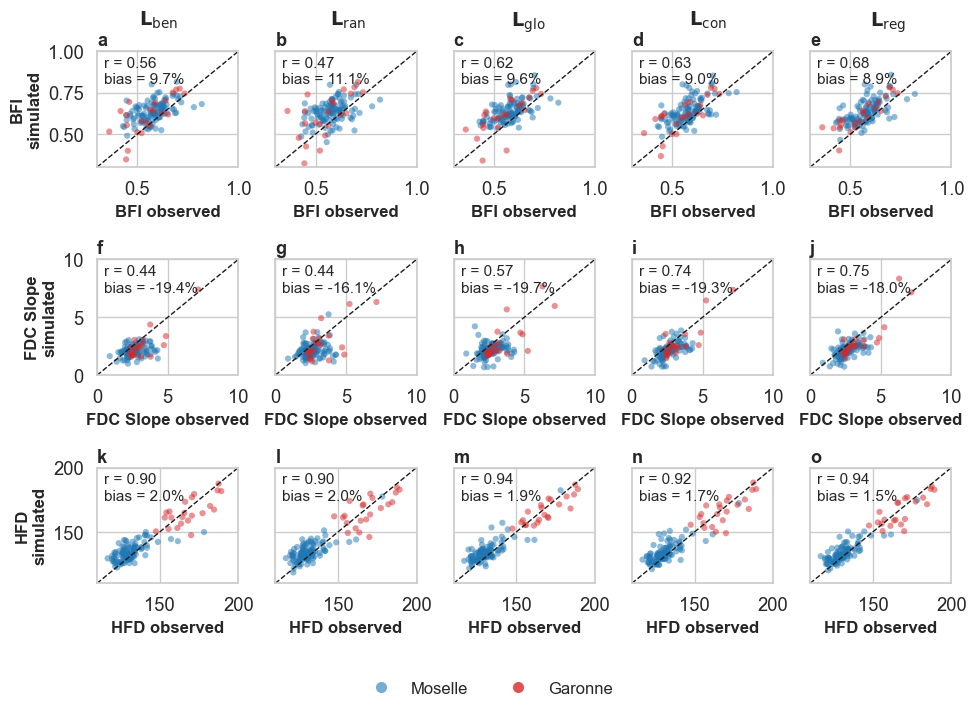

In [589]:
data_diff_complete_dict_plot_scatter = data_diff_val_complete_dict_plot.copy()
#data_diff_complete_dict_plot_scatter = (
#    data_diff_complete_dict_plot_scatter.drop(index="FR001592", errors="ignore")
#)
#
#data_diff_complete_dict_plot_scatter.loc[["FR001592"],
#    ["slope_c1comp", "slope_r1comp", "slope_g1comp", "slope_nogeo", "slope_ran"]
#] = np.nan, np.nan, np.nan, np.nan, np.nan

#data_diff_cal_complete_dict_plot_scatter = (
#    data_diff_cal_complete_dict_plot_scatter.drop("FR000144"))


import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import string

# Seaborn style
sns.set(style="whitegrid", font_scale=1.2)

# Define variables and pretty titles
metrics = ['bfi', 'slope', 'hfd']
metric_titles = ['BFI', 'FDC Slope', 'HFD']

# Define suffixes and scales
suffixes = ['nogeo', 'ran', 'g1comp', 'c1comp', 'r1comp']
scale_titles = [
    r"$\mathbf{L_{\mathrm{ben}}}$",
    r"$\mathbf{L_{\mathrm{ran}}}$",
    r"$\mathbf{L_{\mathrm{glo}}}$",
    r"$\mathbf{L_{\mathrm{con}}}$",
    r"$\mathbf{L_{\mathrm{reg}}}$"
]

# DEFINE BASIN COLORS
basin_colors = {
    "moselle": "#1f77b4",   # blue
    "garonne": "#d62728",  # red
}

def get_basin_color(gauge_id):
    if gauge_id in network_estreams_moselle_108_gauges.index.tolist():
        return basin_colors["moselle"]
    elif gauge_id in network_estreams_garonne_22_gauges.index.tolist():
        return basin_colors["garonne"]
    else:
        return "grey"  # fallback (should not happen)

# Precompute colors in dataframe order
point_colors = data_diff_complete_dict_plot_scatter.index.map(get_basin_color)

# CREATE SUBPLOTS
fig, axs = plt.subplots(3, 5, figsize=(10, 7), sharex=False, sharey=False)
letters = list(string.ascii_lowercase)

for row, (metric, row_title) in enumerate(zip(metrics, metric_titles)):
    for col, (suffix, scale_title) in enumerate(zip(suffixes, scale_titles)):
        ax = axs[row, col]

        var_obs  = f"{metric}_obs"
        var_pred = f"{metric}_{suffix}"

        # Moselle
        moselle_mask = data_diff_complete_dict_plot_scatter.index.isin(
            network_estreams_moselle_108_gauges.index
        )

        ax.scatter(
            data_diff_complete_dict_plot_scatter.loc[moselle_mask, var_obs],
            data_diff_complete_dict_plot_scatter.loc[moselle_mask, var_pred],
            c=basin_colors["moselle"],
            s=20,
            edgecolor='none',
            linewidth=0.1,
            alpha=0.5,
            zorder=1
        )

        # Garonne
        garonne_mask = data_diff_complete_dict_plot_scatter.index.isin(
            network_estreams_garonne_22_gauges.index
        )

        ax.scatter(
            data_diff_complete_dict_plot_scatter.loc[garonne_mask, var_obs],
            data_diff_complete_dict_plot_scatter.loc[garonne_mask, var_pred],
            c=basin_colors["garonne"],
            s=20,
            edgecolor='none',
            linewidth=0.1,
            alpha=0.5,
            zorder=2
        )


        # Labels
        if col == 0:
            ax.set_ylabel(f"{row_title}\nsimulated", fontsize=12, fontweight='bold')
        else:
            ax.set_ylabel("")
            ax.set_yticklabels([])

        ax.set_xlabel(f"{row_title} observed", fontsize=12, fontweight='bold')

        # Correlation & bias
        p = data_diff_complete_dict_plot_scatter[[var_obs, var_pred]].corr(method="pearson").iloc[0, 1]
        #bias_rel = (
        #    100
        #    * (data_diff_complete_dict_plot_scatter[var_pred].median()
        #       - data_diff_complete_dict_plot_scatter[var_obs].median())
        #    / data_diff_complete_dict_plot_scatter[var_obs].median()
        #)
        #x = data_diff_complete_dict_plot_scatter[var_obs].values
        #y = data_diff_complete_dict_plot_scatter[var_pred].values

        #R = np.corrcoef(x, y)[0, 1]
        #CCC = compute_ccc(x, y)

        #bias_rel = 100 * (np.nanmedian(y) - np.nanmedian(x)) / np.nanmedian(x)
        x = data_diff_complete_dict_plot_scatter[var_obs]
        y = data_diff_complete_dict_plot_scatter[var_pred]

        bias_rel = 100 * np.nanmedian((y - x) / x)

        ax.text(
            0.05, 0.72,
            f"r = {p:.2f}\nbias = {bias_rel:.1f}%",
            #f"rs = {p:.2f}\nCCC = {CCC:.2f}\nbias = {bias_rel:.1f}%",

            transform=ax.transAxes,
            fontsize=11,
            bbox=dict(facecolor='none', alpha=0.6, edgecolor='none')
        )


        # Subplot letter
        subplot_idx = row * 5 + col
        ax.text(
            0.00, 1.17, letters[subplot_idx],
            transform=ax.transAxes,
            fontsize=13,
            fontweight='bold',
            va='top',
            ha='left'
        )

        # Axis limits
        if metric == 'bfi':
            ax.set_xlim(0.3, 1)
            ax.set_ylim(0.3, 1)
            ax.plot([0.3, 1], [0.3, 1], 'k--', lw=1)
        elif metric == 'slope':
            ax.set_xlim(0, 10)
            ax.set_ylim(0, 10)
            ax.plot([0, 10], [0, 10], 'k--', lw=1)
        elif metric == 'hfd':
            ax.set_xlim(110, 200)
            ax.set_ylim(110, 200)
            ax.plot([110, 200], [110, 200], 'k--', lw=1)

# LEGEND (INSTEAD OF COLORBAR)
from matplotlib.lines import Line2D

legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Moselle',
           markerfacecolor=basin_colors["moselle"], markersize=8, markeredgecolor='none', alpha=0.6),
    Line2D([0], [0], marker='o', color='w', label='Garonne',
           markerfacecolor=basin_colors["garonne"], markersize=8, markeredgecolor='none', alpha=0.8),
]

fig.legend(
    handles=legend_elements,
    loc="lower center",
    ncol=2,
    frameon=False,
    fontsize=12
)

# Column titles
col_positions = [0.17, 0.36, 0.54, 0.72, 0.9]
for x, title in zip(col_positions, scale_titles):
    fig.text(x, 1, title, ha='center', va='top',
             fontsize=14, fontweight='bold')

# Layout
plt.tight_layout()
plt.subplots_adjust(top=0.94, bottom=0.18)

## Save
plt.savefig("../results/figs/figures/fig07.png", dpi=300)
plt.show()

In [536]:
data_diff_val_complete_dict_plot.to_csv("../results/precipitation_correction/moselle_garonne_sx_val_completelstm.csv")

In [535]:
data_diff_val_complete_dict_plot

,nse_nogeo,nse_ran,nse_g1comp,nse_c1comp,nse_r1comp,kge_nogeo,kge_ran,kge_g1comp,kge_c1comp,kge_r1comp,...,slope_c1comp,slope_g1comp,slope_nogeo,slope_ran,qmean_obs,qmean_r1comp,qmean_c1comp,qmean_g1comp,qmean_nogeo,qmean_ran
FR004136,0.775351,0.812020,0.814342,0.821939,0.821147,0.821396,0.870256,0.824001,0.856872,0.842743,...,2.802176,2.536333,3.052286,3.157465,2.166707,2.123215,2.060078,2.163052,2.317301,2.091050
FR001547,0.729678,0.837546,0.801212,0.811313,0.816351,0.412154,0.605635,0.573864,0.612339,0.539167,...,1.941669,3.763766,1.613031,3.175063,0.842004,0.645550,0.767495,0.623696,0.656759,0.652738
FR004091,0.533998,0.216511,0.482372,0.508291,0.603984,0.385558,0.144931,0.352691,0.393657,0.446760,...,2.007423,1.892820,1.744525,1.198109,2.564942,1.667060,1.522058,1.473463,1.579291,1.233865
FR001592,0.464844,0.671579,0.660253,0.611736,0.685088,0.185438,0.520804,0.335811,0.272291,0.309333,...,6.462117,2.099771,46.197067,6.154612,0.264454,0.181575,0.146222,0.208958,0.117373,0.195073
FR001577,0.813354,0.796718,0.879160,0.822986,0.843312,0.659935,0.590554,0.657668,0.668516,0.725886,...,2.604577,3.680226,2.600341,2.405281,0.988105,1.047871,0.971708,0.886520,1.014191,0.972065
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
DERP2007,0.796881,0.826878,0.802622,0.821837,0.808305,0.515870,0.592797,0.518329,0.548724,0.524168,...,2.332885,2.308954,1.782600,1.914561,1.040731,0.774757,0.769958,0.727615,0.769210,0.858933
FR003271,0.787464,0.782418,0.821171,0.798304,0.821013,0.539043,0.580716,0.553413,0.543808,0.578753,...,2.248059,2.192323,2.637527,2.370765,0.624199,0.479710,0.447601,0.497038,0.441947,0.438349
FR003301,0.905110,0.896444,0.900515,0.908468,0.893708,0.721253,0.686253,0.709992,0.743164,0.710545,...,2.093468,1.845995,2.106055,2.003049,0.788065,0.662018,0.679025,0.702483,0.695920,0.667897
DERP2003,0.839509,0.851834,0.767786,0.895105,0.890449,0.569379,0.621412,0.472140,0.727987,0.781115,...,2.217808,1.297436,1.752440,1.797834,0.931310,0.788044,0.780283,0.741589,0.742219,0.745398


In [379]:

# Containers
rows = []

for metric in metrics:
    var_obs = f"{metric}_obs"

    for suffix in suffixes:
        var_pred = f"{metric}_{suffix}"

        # Extract vectors
        x = data_diff_complete_dict_plot_scatter[var_obs].values
        y = data_diff_complete_dict_plot_scatter[var_pred].values

        # Spearman correlation
        r_spearman = (
            data_diff_complete_dict_plot_scatter[[var_obs, var_pred]]
            .corr(method="pearson")
            .iloc[0, 1]
        )

        # Relative bias (%)
        bias_rel = 100 * (np.nanmean(y) - np.nanmean(x)) / np.nanmean(x)

        rows.append({
            "metric": metric,
            "experiment": suffix,
            "r_spearman": r_spearman,
            "bias_%": bias_rel
        })

# Create dataframe
df_stats = pd.DataFrame(rows)

# Pivot for nice table layout (optional)
table_r = df_stats.pivot(index="metric", columns="experiment", values="r_spearman")
table_bias = df_stats.pivot(index="metric", columns="experiment", values="bias_%")

In [381]:
table_r

experiment,c1comp,g1comp,nogeo,r1comp,ran
metric,,,,,
bfi,0.628362,0.607138,0.552987,0.670692,0.466661
hfd,0.931487,0.947265,0.915793,0.948944,0.918123
slope,0.690349,0.524156,0.560644,0.698325,0.412661


In [382]:
table_bias

experiment,c1comp,g1comp,nogeo,r1comp,ran
metric,,,,,
bfi,10.260524,10.474060,10.340609,10.017953,9.753689
hfd,1.572687,1.696540,1.561021,1.306779,1.724926
slope,-18.271072,-17.995062,-19.980577,-17.883097,-18.588442


In [ ]:
data_diff_complete_dict_plot_scatter = data_diff_val_complete_dict_plot.copy()


data_diff_complete_dict_plot_scatter.loc[["FR001592"],
    ["slope_c1comp", "slope_r1comp", "slope_g1comp", "slope_nogeo", "slope_ran"]
] = np.nan, np.nan, np.nan, np.nan, np.nan


rows = []

basins = {
    "Garonne": is_garonne,
    "Moselle": is_moselle,
}

for basin_name, basin_idx in basins.items():

    # Subset once per basin
    df_basin = data_diff_complete_dict_plot_scatter.loc[basin_idx]

    for metric in metrics:
        var_obs = f"{metric}_obs"

        for suffix in suffixes:
            var_pred = f"{metric}_{suffix}"

            # Extract vectors
            x = df_basin[var_obs].values
            y = df_basin[var_pred].values

            # Spearman correlation
            r_spearman = (
                df_basin[[var_obs, var_pred]]
                .corr(method="pearson")
                .iloc[0, 1]
            )

            # Relative bias (%)
            bias_rel = 100 * (np.nanmean(y) - np.nanmean(x)) / np.nanmean(x)

            rows.append({
                "basin": basin_name,
                "metric": metric,
                "experiment": suffix,
                "r_spearman": r_spearman,
                "bias_%": bias_rel
            })

# Single tidy dataframe
df_stats = pd.DataFrame(rows)
table_r = df_stats.pivot_table(
    index=["basin", "metric"],
    columns="experiment",
    values="r_spearman"
)


table_r[["nogeo", "ran", "g1comp", "c1comp", "r1comp"]]

experiment         nogeo       ran    g1comp    c1comp    r1comp
basin   metric                                                  
Garonne bfi     0.701918  0.624998  0.732838  0.762234  0.863822
        hfd     0.690966  0.634612  0.855528  0.718093  0.780363
        slope   0.715200  0.558453  0.845961  0.818063  0.882045
Moselle bfi     0.479915  0.382245  0.553177  0.570503  0.603611
        hfd     0.639792  0.702119  0.762909  0.741222  0.809311
        slope   0.281228  0.205659  0.238795  0.556653  0.545884

In [425]:
table_bias = df_stats.pivot_table(
    index=["basin", "metric"],
    columns="experiment",
    values="bias_%"
)
table_bias[["nogeo", "ran", "g1comp", "c1comp", "r1comp"]]

experiment          nogeo        ran     g1comp     c1comp     r1comp
basin   metric                                                       
Garonne bfi     10.638194  11.269440  11.004209  10.644831  11.227383
        hfd     -1.595036  -1.279180  -1.166267  -1.073611  -1.282556
        slope   -2.462718  39.411987 -16.134806 -10.876686 -15.344750
Moselle bfi     10.310280   9.532905  10.442739  10.242669   9.816237
        hfd      2.451943   2.572911   2.497259   2.327151   1.995094
        slope  -20.131643 -18.380705 -18.405249 -18.478207 -17.887112

In [383]:
data_diff_val_complete_dict_plot_nse.describe()

,nse_nogeo,nse_ran,nse_g1comp,nse_c1comp,nse_r1comp,kge_nogeo,kge_ran,kge_g1comp,kge_c1comp,kge_r1comp,...,slope_c1comp,slope_g1comp,slope_nogeo,slope_ran,qmean_obs,qmean_r1comp,qmean_c1comp,qmean_g1comp,qmean_nogeo,qmean_ran
count,130.000000,130.000000,130.000000,130.000000,130.000000,130.000000,130.000000,130.000000,130.000000,130.000000,...,124.000000,124.000000,124.000000,124.000000,130.000000,130.000000,130.000000,130.000000,130.000000,130.000000
mean,0.701148,0.702314,0.682569,0.693119,0.714618,0.632917,0.633455,0.625419,0.641115,0.660204,...,2.346902,2.282302,2.681072,2.643056,1.097993,0.993277,0.982460,0.970804,0.976053,0.958917
std,0.203131,0.213865,0.311369,0.398628,0.259607,0.167555,0.157196,0.178849,0.168671,0.153624,...,1.191962,0.889878,4.279453,4.327611,0.567213,0.555403,0.533969,0.541277,0.545191,0.542277
min,-0.422664,-0.798170,-2.010504,-3.517215,-1.712207,-0.016561,0.020369,-0.107608,-0.354413,-0.054540,...,0.734685,0.690832,0.994655,1.053290,0.264454,0.181575,0.146222,0.188042,0.117373,0.194840
25%,0.662419,0.667403,0.664224,0.678989,0.688546,0.548924,0.553947,0.549818,0.576363,0.571492,...,1.874028,1.870645,1.804532,1.768710,0.782773,0.656859,0.670301,0.645819,0.657241,0.627968
50%,0.746795,0.748087,0.740927,0.751744,0.760719,0.666852,0.634310,0.654642,0.668867,0.678773,...,2.201279,2.107406,2.099847,2.127353,0.962306,0.820589,0.851755,0.842559,0.825860,0.819690
75%,0.815519,0.813974,0.815831,0.815683,0.829164,0.736227,0.768067,0.746018,0.750381,0.766316,...,2.537435,2.505111,2.473696,2.626224,1.236292,1.127157,1.095467,1.093064,1.091162,1.061482
max,0.909402,0.906553,0.908585,0.904773,0.905084,0.919359,0.911352,0.915162,0.929735,0.908611,...,11.386008,7.669191,46.197067,49.513023,3.618939,3.315327,3.150639,3.209339,3.369995,3.663948


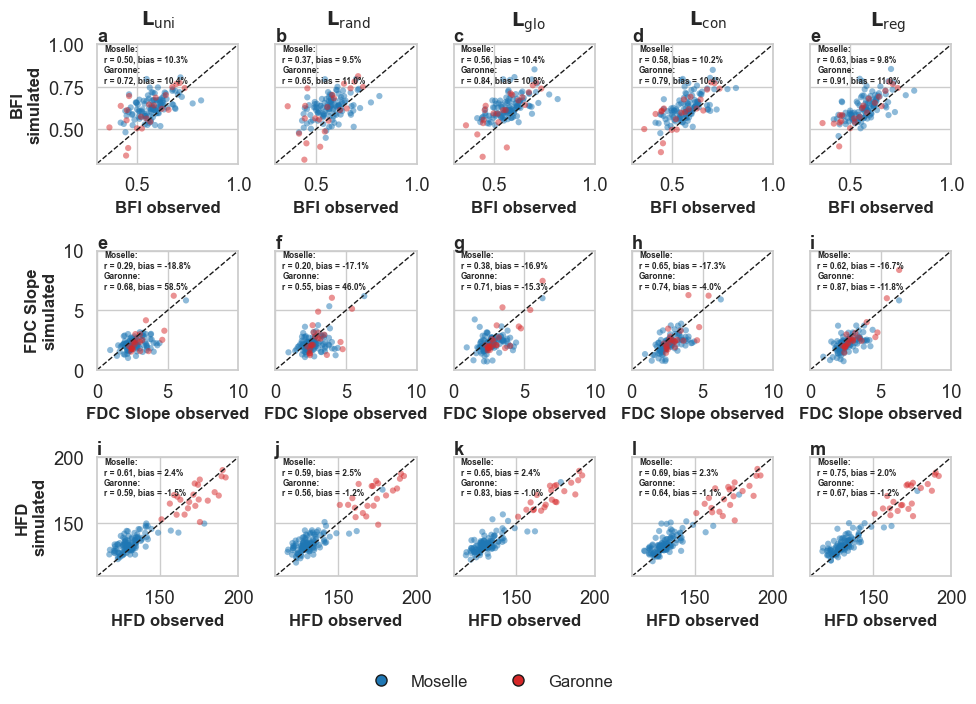

In [384]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import string
from matplotlib.lines import Line2D

# =========================================================
# SEABORN STYLE
# =========================================================
sns.set(style="whitegrid", font_scale=1.2)

# =========================================================
# METRICS AND TITLES
# =========================================================
metrics = ['bfi', 'slope', 'hfd']
metric_titles = ['BFI', 'FDC Slope', 'HFD']

suffixes = ['nogeo', 'ran', 'g1comp', 'c1comp', 'r1comp']
scale_titles = [
    r"$\mathbf{L_{\mathrm{uni}}}$",
    r"$\mathbf{L_{\mathrm{rand}}}$",
    r"$\mathbf{L_{\mathrm{glo}}}$",
    r"$\mathbf{L_{\mathrm{con}}}$",
    r"$\mathbf{L_{\mathrm{reg}}}$"
]

# =========================================================
# BASIN COLORS
# =========================================================
basin_colors = {
    "moselle": "#1f77b4",
    "garonne": "#d62728",
}

moselle_ids = network_estreams_moselle_108_gauges.index.tolist()
garonne_ids = network_estreams_garonne_22_gauges.index.tolist()

def get_basin_color(gauge_id):
    if gauge_id in moselle_ids:
        return basin_colors["moselle"]
    elif gauge_id in garonne_ids:
        return basin_colors["garonne"]
    else:
        return "grey"

point_colors = data_diff_val_complete_dict_plot.index.map(get_basin_color)

# Boolean masks (USED FOR STATS)
is_moselle = data_diff_val_complete_dict_plot.index.isin(moselle_ids)
is_garonne = data_diff_val_complete_dict_plot.index.isin(garonne_ids)

# CREATE FIGURE
fig, axs = plt.subplots(3, 5, figsize=(10, 7), sharex=False, sharey=False)
letters = list(string.ascii_lowercase)

# LOOP OVER METRICS AND MODELS
for row, (metric, row_title) in enumerate(zip(metrics, metric_titles)):
    for col, suffix in enumerate(suffixes):
        ax = axs[row, col]

        var_obs  = f"{metric}_obs"
        var_pred = f"{metric}_{suffix}"

        # Moselle
        moselle_mask = data_diff_val_complete_dict_plot.index.isin(
            network_estreams_moselle_108_gauges.index
        )

        ax.scatter(
            data_diff_val_complete_dict_plot.loc[moselle_mask, var_obs],
            data_diff_val_complete_dict_plot.loc[moselle_mask, var_pred],
            c=basin_colors["moselle"],
            s=20,
            edgecolor='none',
            linewidth=0.1,
            alpha=0.5,
            zorder=1
        )

        # Garonne
        garonne_mask = data_diff_val_complete_dict_plot.index.isin(
            network_estreams_garonne_22_gauges.index
        )

        ax.scatter(
            data_diff_val_complete_dict_plot.loc[garonne_mask, var_obs],
            data_diff_val_complete_dict_plot.loc[garonne_mask, var_pred],
            c=basin_colors["garonne"],
            s=20,
            edgecolor='none',
            linewidth=0.1,
            alpha=0.5,
            zorder=2
        )

        # Labels
        if col == 0:
            ax.set_ylabel(f"{row_title}\nsimulated", fontsize=12, fontweight='bold')
        else:
            ax.set_ylabel("")
            ax.set_yticklabels([])

        ax.set_xlabel(f"{row_title} observed", fontsize=12, fontweight='bold')

        # -------------------------------
        # PER-BASIN STATS
        # -------------------------------
        # Moselle
        x_m = data_diff_val_complete_dict_plot.loc[is_moselle, var_obs].values
        y_m = data_diff_val_complete_dict_plot.loc[is_moselle, var_pred].values
        mask_m = ~np.isnan(x_m) & ~np.isnan(y_m)
        x_m, y_m = x_m[mask_m], y_m[mask_m]

        from scipy.stats import spearmanr
        from scipy.stats import pearsonr

        r_m = spearmanr(x_m, y_m)[0] if len(x_m) > 1 else np.nan
        bias_m = 100 * (np.mean(y_m) - np.mean(x_m)) / np.mean(x_m)

        CCC_m = compute_ccc(x_m, y_m)

        # Garonne
        x_g = data_diff_val_complete_dict_plot.loc[is_garonne, var_obs].values
        y_g = data_diff_val_complete_dict_plot.loc[is_garonne, var_pred].values
        mask_g = ~np.isnan(x_g) & ~np.isnan(y_g)
        x_g, y_g = x_g[mask_g], y_g[mask_g]

        r_g = spearmanr(x_g, y_g)[0] if len(x_g) > 1 else np.nan
        bias_g = 100 * (np.mean(y_g) - np.mean(x_g)) / np.mean(x_g)

        CCC_g = compute_ccc(x_g, y_g)


        # Annotation
        ax.text(
            0.05, 0.68,
            f"Moselle:\n"
            f"r = {r_m:.2f}, bias = {bias_m:.1f}%\n"

            #f"r = {r_m:.2f}, CCC = {CCC_m:.2f}, bias = {bias_m:.1f}%\n"
            f"Garonne:\n"

            f"r = {r_g:.2f}, bias = {bias_g:.1f}%",

            #f"r = {r_g:.2f}, CCC = {CCC_g:.2f}, bias = {bias_g:.1f}%",
            transform=ax.transAxes,
            fontsize=6,
            fontweight="bold",

            bbox=dict(facecolor='none', alpha=0.6, edgecolor='none')
        )

        # Subplot letter
        subplot_idx = row * 4 + col
        ax.text(
            0.00, 1.14, letters[subplot_idx],
            transform=ax.transAxes,
            fontsize=13,
            fontweight='bold',
            va='top',
            ha='left'
        )

        # Axis limits
        if metric == 'bfi':
            ax.set_xlim(0.3, 1)
            ax.set_ylim(0.3, 1)
            ax.plot([0.3, 1], [0.3, 1], 'k--', lw=1)
        elif metric == 'slope':
            ax.set_xlim(0, 10)
            ax.set_ylim(0, 10)
            ax.plot([0, 10], [0, 10], 'k--', lw=1)
        elif metric == 'hfd':
            ax.set_xlim(110, 200)
            ax.set_ylim(110, 200)
            ax.plot([110, 200], [110, 200], 'k--', lw=1)

# =========================================================
# LEGEND
# =========================================================
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Moselle',
           markerfacecolor=basin_colors["moselle"], markersize=8, markeredgecolor='k'),
    Line2D([0], [0], marker='o', color='w', label='Garonne',
           markerfacecolor=basin_colors["garonne"], markersize=8, markeredgecolor='k'),
]

fig.legend(
    handles=legend_elements,
    loc="lower center",
    ncol=2,
    frameon=False,
    fontsize=12
)

# Column titles
col_positions = [0.17, 0.36, 0.54, 0.72, 0.9]
for x, title in zip(col_positions, scale_titles):
    fig.text(x, 0.99, title, ha='center', va='top',
             fontsize=14, fontweight='bold')

# =========================================================
# FINAL LAYOUT
# =========================================================
plt.tight_layout()
plt.subplots_adjust(top=0.94, bottom=0.18)

plt.savefig("../results/figs/figures/SX_signaturesByBasin.png", dpi=300)
plt.show()


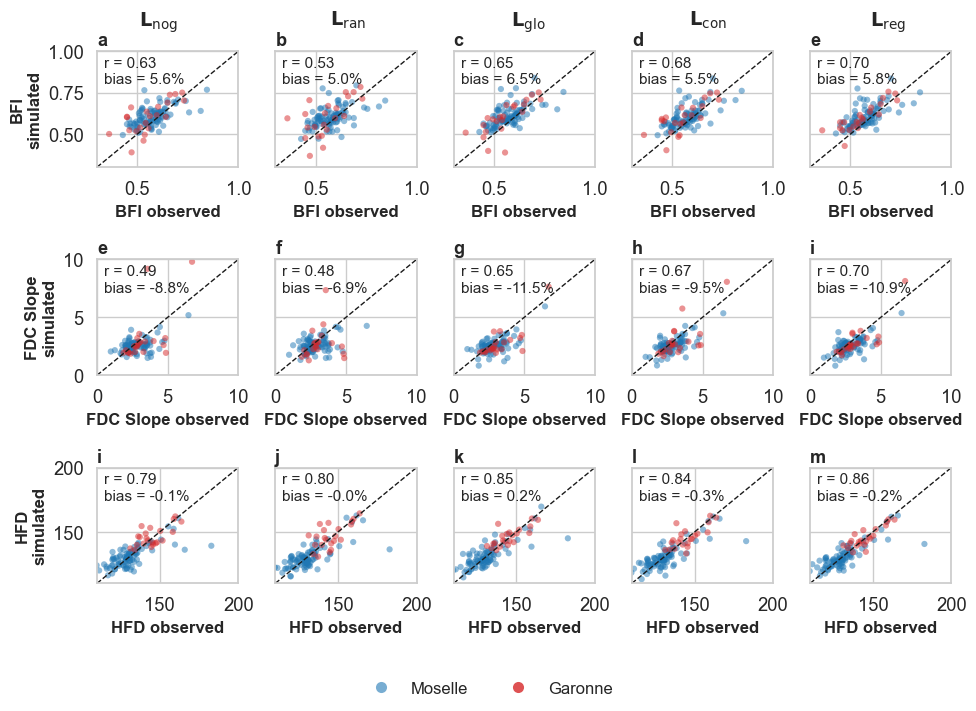

In [389]:
data_diff_cal_complete_dict_plot_scatter = data_diff_cal_complete_dict_plot.copy()

#data_diff_cal_complete_dict_plot_scatter.loc[
#    data_diff_cal_complete_dict_plot_scatter["slope_c1comp"] > 10,
#    "slope_c1comp"
#] = np.nan

#data_diff_cal_complete_dict_plot_scatter = (
#    data_diff_cal_complete_dict_plot_scatter.drop("FR000144"))


import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import string

# Seaborn style
sns.set(style="whitegrid", font_scale=1.2)

# Define variables and pretty titles
metrics = ['bfi', 'slope', 'hfd']
metric_titles = ['BFI', 'FDC Slope', 'HFD']

# Define suffixes and scales
suffixes = ['nogeo', 'ran', 'g1comp', 'c1comp', 'r1comp']
scale_titles = [
    r"$\mathbf{L_{\mathrm{nog}}}$",
    r"$\mathbf{L_{\mathrm{ran}}}$",
    r"$\mathbf{L_{\mathrm{glo}}}$",
    r"$\mathbf{L_{\mathrm{con}}}$",
    r"$\mathbf{L_{\mathrm{reg}}}$"
]

# DEFINE BASIN COLORS
basin_colors = {
    "moselle": "#1f77b4",   # blue
    "garonne": "#d62728",  # red
}

def get_basin_color(gauge_id):
    if gauge_id in network_estreams_moselle_108_gauges.index.tolist():
        return basin_colors["moselle"]
    elif gauge_id in network_estreams_garonne_22_gauges.index.tolist():
        return basin_colors["garonne"]
    else:
        return "grey"  # fallback (should not happen)

# Precompute colors in dataframe order
point_colors = data_diff_cal_complete_dict_plot_scatter.index.map(get_basin_color)

# CREATE SUBPLOTS
fig, axs = plt.subplots(3, 5, figsize=(10, 7), sharex=False, sharey=False)
letters = list(string.ascii_lowercase)

for row, (metric, row_title) in enumerate(zip(metrics, metric_titles)):
    for col, (suffix, scale_title) in enumerate(zip(suffixes, scale_titles)):
        ax = axs[row, col]

        var_obs  = f"{metric}_obs"
        var_pred = f"{metric}_{suffix}"

        # Moselle
        moselle_mask = data_diff_cal_complete_dict_plot_scatter.index.isin(
            network_estreams_moselle_108_gauges.index
        )

        ax.scatter(
            data_diff_cal_complete_dict_plot_scatter.loc[moselle_mask, var_obs],
            data_diff_cal_complete_dict_plot_scatter.loc[moselle_mask, var_pred],
            c=basin_colors["moselle"],
            s=20,
            edgecolor='none',
            linewidth=0.1,
            alpha=0.5,
            zorder=1
        )

        # Garonne
        garonne_mask = data_diff_cal_complete_dict_plot_scatter.index.isin(
            network_estreams_garonne_22_gauges.index
        )

        ax.scatter(
            data_diff_cal_complete_dict_plot_scatter.loc[garonne_mask, var_obs],
            data_diff_cal_complete_dict_plot_scatter.loc[garonne_mask, var_pred],
            c=basin_colors["garonne"],
            s=20,
            edgecolor='none',
            linewidth=0.1,
            alpha=0.5,
            zorder=2
        )


        # Labels
        if col == 0:
            ax.set_ylabel(f"{row_title}\nsimulated", fontsize=12, fontweight='bold')
        else:
            ax.set_ylabel("")
            ax.set_yticklabels([])

        ax.set_xlabel(f"{row_title} observed", fontsize=12, fontweight='bold')

        # Correlation & bias
        p = data_diff_cal_complete_dict_plot_scatter[[var_obs, var_pred]].corr(method="pearson").iloc[0, 1]
        bias_rel = (
            100
            * (data_diff_cal_complete_dict_plot_scatter[var_pred].mean()
               - data_diff_cal_complete_dict_plot_scatter[var_obs].mean())
            / data_diff_cal_complete_dict_plot_scatter[var_obs].mean()
        )
        x = data_diff_cal_complete_dict_plot_scatter[var_obs].values
        y = data_diff_cal_complete_dict_plot_scatter[var_pred].values

        R = np.corrcoef(x, y)[0, 1]
        CCC = compute_ccc(x, y)

        bias_rel = 100 * (np.nanmean(y) - np.nanmean(x)) / np.nanmean(x)

        ax.text(
            0.05, 0.72,
            f"r = {p:.2f}\nbias = {bias_rel:.1f}%",
            #f"rs = {p:.2f}\nCCC = {CCC:.2f}\nbias = {bias_rel:.1f}%",

            transform=ax.transAxes,
            fontsize=11,
            bbox=dict(facecolor='none', alpha=0.6, edgecolor='none')
        )


        # Subplot letter
        subplot_idx = row * 4 + col
        ax.text(
            0.00, 1.17, letters[subplot_idx],
            transform=ax.transAxes,
            fontsize=13,
            fontweight='bold',
            va='top',
            ha='left'
        )

        # Axis limits
        if metric == 'bfi':
            ax.set_xlim(0.3, 1)
            ax.set_ylim(0.3, 1)
            ax.plot([0.3, 1], [0.3, 1], 'k--', lw=1)
        elif metric == 'slope':
            ax.set_xlim(0, 10)
            ax.set_ylim(0, 10)
            ax.plot([0, 10], [0, 10], 'k--', lw=1)
        elif metric == 'hfd':
            ax.set_xlim(110, 200)
            ax.set_ylim(110, 200)
            ax.plot([110, 200], [110, 200], 'k--', lw=1)

# LEGEND (INSTEAD OF COLORBAR)
from matplotlib.lines import Line2D

legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Moselle',
           markerfacecolor=basin_colors["moselle"], markersize=8, markeredgecolor='none', alpha=0.6),
    Line2D([0], [0], marker='o', color='w', label='Garonne',
           markerfacecolor=basin_colors["garonne"], markersize=8, markeredgecolor='none', alpha=0.8),
]

fig.legend(
    handles=legend_elements,
    loc="lower center",
    ncol=2,
    frameon=False,
    fontsize=12
)

# Column titles
col_positions = [0.17, 0.36, 0.54, 0.72, 0.9]
for x, title in zip(col_positions, scale_titles):
    fig.text(x, 1, title, ha='center', va='top',
             fontsize=14, fontweight='bold')

# Layout
plt.tight_layout()
plt.subplots_adjust(top=0.94, bottom=0.18)

# Save
plt.savefig("../results/figs/figures/figSX_spacesignatures.png", dpi=300)
plt.show()

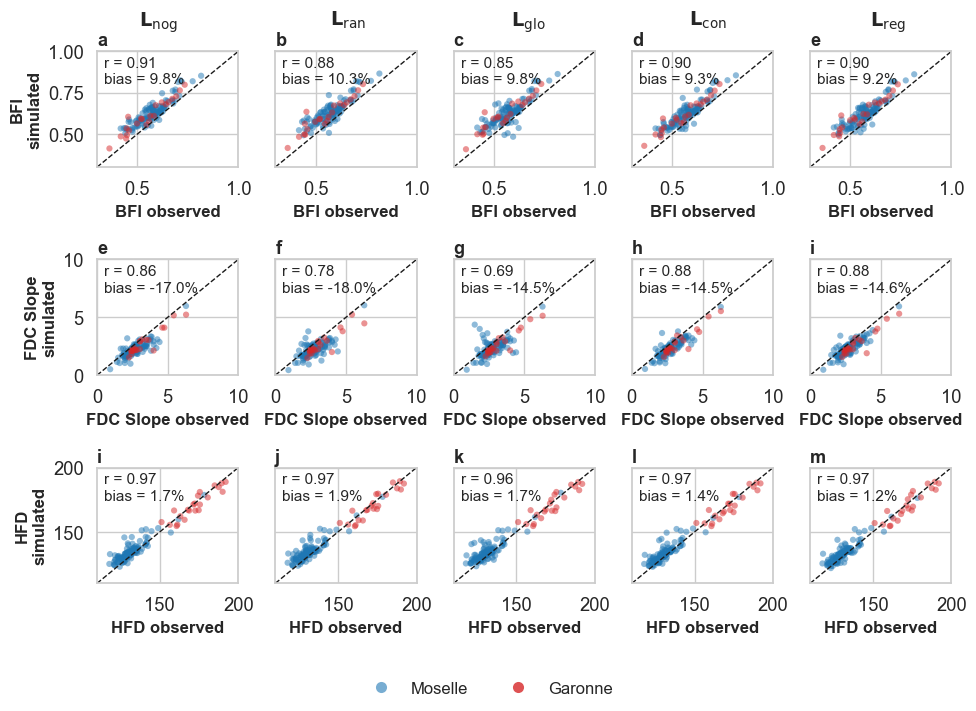

In [534]:
data_diff_cal_complete_dict_plot_scatter = data_diff_timeval_complete_dict_plot.copy()

#data_diff_cal_complete_dict_plot_scatter.loc[
#    data_diff_cal_complete_dict_plot_scatter["slope_c1comp"] > 10,
#    "slope_c1comp"
#] = np.nan

#data_diff_cal_complete_dict_plot_scatter = (
#    data_diff_cal_complete_dict_plot_scatter.drop("FR000144"))


import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import string

# Seaborn style
sns.set(style="whitegrid", font_scale=1.2)

# Define variables and pretty titles
metrics = ['bfi', 'slope', 'hfd']
metric_titles = ['BFI', 'FDC Slope', 'HFD']

# Define suffixes and scales
suffixes = ['nogeo', 'ran', 'g1comp', 'c1comp', 'r1comp']
scale_titles = [
    r"$\mathbf{L_{\mathrm{nog}}}$",
    r"$\mathbf{L_{\mathrm{ran}}}$",
    r"$\mathbf{L_{\mathrm{glo}}}$",
    r"$\mathbf{L_{\mathrm{con}}}$",
    r"$\mathbf{L_{\mathrm{reg}}}$"
]

# DEFINE BASIN COLORS
basin_colors = {
    "moselle": "#1f77b4",   # blue
    "garonne": "#d62728",  # red
}

def get_basin_color(gauge_id):
    if gauge_id in network_estreams_moselle_108_gauges.index.tolist():
        return basin_colors["moselle"]
    elif gauge_id in network_estreams_garonne_22_gauges.index.tolist():
        return basin_colors["garonne"]
    else:
        return "grey"  # fallback (should not happen)

# Precompute colors in dataframe order
point_colors = data_diff_cal_complete_dict_plot_scatter.index.map(get_basin_color)

# CREATE SUBPLOTS
fig, axs = plt.subplots(3, 5, figsize=(10, 7), sharex=False, sharey=False)
letters = list(string.ascii_lowercase)

for row, (metric, row_title) in enumerate(zip(metrics, metric_titles)):
    for col, (suffix, scale_title) in enumerate(zip(suffixes, scale_titles)):
        ax = axs[row, col]

        var_obs  = f"{metric}_obs"
        var_pred = f"{metric}_{suffix}"

        # Moselle
        moselle_mask = data_diff_cal_complete_dict_plot_scatter.index.isin(
            network_estreams_moselle_108_gauges.index
        )

        ax.scatter(
            data_diff_cal_complete_dict_plot_scatter.loc[moselle_mask, var_obs],
            data_diff_cal_complete_dict_plot_scatter.loc[moselle_mask, var_pred],
            c=basin_colors["moselle"],
            s=20,
            edgecolor='none',
            linewidth=0.1,
            alpha=0.5,
            zorder=1
        )

        # Garonne
        garonne_mask = data_diff_cal_complete_dict_plot_scatter.index.isin(
            network_estreams_garonne_22_gauges.index
        )

        ax.scatter(
            data_diff_cal_complete_dict_plot_scatter.loc[garonne_mask, var_obs],
            data_diff_cal_complete_dict_plot_scatter.loc[garonne_mask, var_pred],
            c=basin_colors["garonne"],
            s=20,
            edgecolor='none',
            linewidth=0.1,
            alpha=0.5,
            zorder=2
        )


        # Labels
        if col == 0:
            ax.set_ylabel(f"{row_title}\nsimulated", fontsize=12, fontweight='bold')
        else:
            ax.set_ylabel("")
            ax.set_yticklabels([])

        ax.set_xlabel(f"{row_title} observed", fontsize=12, fontweight='bold')

        # Correlation & bias
        p = data_diff_cal_complete_dict_plot_scatter[[var_obs, var_pred]].corr(method="pearson").iloc[0, 1]
        bias_rel = (
            100
            * (data_diff_cal_complete_dict_plot_scatter[var_pred].mean()
               - data_diff_cal_complete_dict_plot_scatter[var_obs].mean())
            / data_diff_cal_complete_dict_plot_scatter[var_obs].mean()
        )
        x = data_diff_cal_complete_dict_plot_scatter[var_obs].values
        y = data_diff_cal_complete_dict_plot_scatter[var_pred].values

        R = np.corrcoef(x, y)[0, 1]
        CCC = compute_ccc(x, y)

        bias_rel = 100 * (np.nanmean(y) - np.nanmean(x)) / np.nanmean(x)

        ax.text(
            0.05, 0.72,
            f"r = {p:.2f}\nbias = {bias_rel:.1f}%",
            #f"rs = {p:.2f}\nCCC = {CCC:.2f}\nbias = {bias_rel:.1f}%",

            transform=ax.transAxes,
            fontsize=11,
            bbox=dict(facecolor='none', alpha=0.6, edgecolor='none')
        )


        # Subplot letter
        subplot_idx = row * 4 + col
        ax.text(
            0.00, 1.17, letters[subplot_idx],
            transform=ax.transAxes,
            fontsize=13,
            fontweight='bold',
            va='top',
            ha='left'
        )

        # Axis limits
        if metric == 'bfi':
            ax.set_xlim(0.3, 1)
            ax.set_ylim(0.3, 1)
            ax.plot([0.3, 1], [0.3, 1], 'k--', lw=1)
        elif metric == 'slope':
            ax.set_xlim(0, 10)
            ax.set_ylim(0, 10)
            ax.plot([0, 10], [0, 10], 'k--', lw=1)
        elif metric == 'hfd':
            ax.set_xlim(110, 200)
            ax.set_ylim(110, 200)
            ax.plot([110, 200], [110, 200], 'k--', lw=1)

# LEGEND (INSTEAD OF COLORBAR)
from matplotlib.lines import Line2D

legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Moselle',
           markerfacecolor=basin_colors["moselle"], markersize=8, markeredgecolor='none', alpha=0.6),
    Line2D([0], [0], marker='o', color='w', label='Garonne',
           markerfacecolor=basin_colors["garonne"], markersize=8, markeredgecolor='none', alpha=0.8),
]

fig.legend(
    handles=legend_elements,
    loc="lower center",
    ncol=2,
    frameon=False,
    fontsize=12
)

# Column titles
col_positions = [0.17, 0.36, 0.54, 0.72, 0.9]
for x, title in zip(col_positions, scale_titles):
    fig.text(x, 1, title, ha='center', va='top',
             fontsize=14, fontweight='bold')

# Layout
plt.tight_layout()
plt.subplots_adjust(top=0.94, bottom=0.18)

# Save
plt.savefig("../results/figs/figures/FigSX_signatures_lstm_time.png", dpi=300)
plt.show()

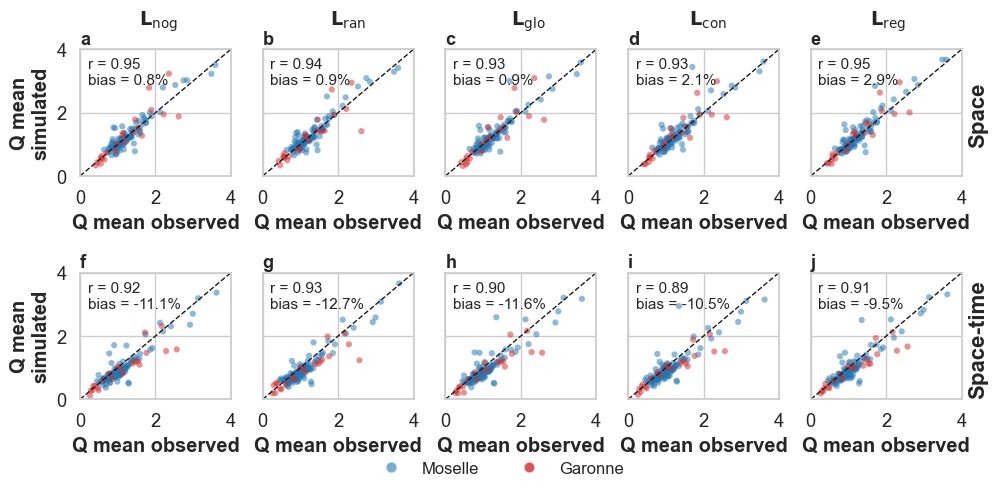

In [443]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import string
from matplotlib.lines import Line2D

sns.set(style="whitegrid", font_scale=1.2)

# =========================
# CONFIG
# =========================
metrics = ["qmean"]
metric_titles = ["Q mean"]

suffixes = ["nogeo", "ran", "g1comp", "c1comp", "r1comp"]
scale_titles = [
    r"$\mathbf{L_{\mathrm{nog}}}$",
    r"$\mathbf{L_{\mathrm{ran}}}$",
    r"$\mathbf{L_{\mathrm{glo}}}$",
    r"$\mathbf{L_{\mathrm{con}}}$",
    r"$\mathbf{L_{\mathrm{reg}}}$",
]

basin_colors = {
    "moselle": "#1f77b4",
    "garonne": "#d62728",
}

letters = list(string.ascii_lowercase)

# =========================
# FIGURE SETUP
# =========================
fig, axs = plt.subplots(
    2, 5,
    figsize=(10, 5),
    sharex=False,
    sharey=False
)

# =========================
# LOOP OVER ROWS
# =========================
for row_idx, (df, row_title) in enumerate([
    (data_diff_cal_complete_dict_plot, "Space evaluation"),
    (data_diff_val_complete_dict_plot, "Space–time evaluation"),
]):

    for col, (suffix, scale_title) in enumerate(zip(suffixes, scale_titles)):
        ax = axs[row_idx, col]

        var_obs  = "qmean_obs"
        var_pred = f"qmean_{suffix}"

        # Moselle
        moselle_mask = df.index.isin(
            network_estreams_moselle_108_gauges.index
        )

        ax.scatter(
            df.loc[moselle_mask, var_obs],
            df.loc[moselle_mask, var_pred],
            c=basin_colors["moselle"],
            s=20,
            alpha=0.5,
            edgecolor="none",
            zorder=1,
        )

        # Garonne
        garonne_mask = df.index.isin(
            network_estreams_garonne_22_gauges.index
        )

        ax.scatter(
            df.loc[garonne_mask, var_obs],
            df.loc[garonne_mask, var_pred],
            c=basin_colors["garonne"],
            s=20,
            alpha=0.5,
            edgecolor="none",
            zorder=2,
        )

        # Labels
        if col == 0:
            ax.set_ylabel("Q mean\nsimulated", fontweight="bold")
        else:
            ax.set_yticklabels([])

        ax.set_xlabel("Q mean observed", fontweight="bold")

        # Stats
        p = df[[var_obs, var_pred]].corr(method="pearson").iloc[0, 1]
        bias = 100 * (np.nanmean(df[var_pred]) - np.nanmean(df[var_obs])) / np.nanmean(df[var_obs])

        ax.text(
            0.05, 0.72,
            f"r = {p:.2f}\nbias = {bias:.1f}%",
            transform=ax.transAxes,
            fontsize=11,
        )

        # 1:1 line
        ax.set_xlim(0, 4)
        ax.set_ylim(0, 4)
        ax.plot([0, 4], [0, 4], "k--", lw=1)

        # Subplot letter
        ax.text(
            0.00, 1.15,
            letters[row_idx * 5 + col],
            transform=ax.transAxes,
            fontweight="bold",
            fontsize=13,
            va="top",
            ha="left",
        )

# =========================
# COLUMN TITLES
# =========================
col_positions = [0.17, 0.36, 0.54, 0.72, 0.9]
for x, title in zip(col_positions, scale_titles):
    fig.text(x, 0.96, title, ha="center", va="top",
             fontsize=14, fontweight="bold")

# =========================
# ROW TITLES
# =========================
# =========================
# ROW TITLES (VERTICAL, RIGHT SIDE)
# =========================
fig.text(
    1, 0.75, "Space",
    rotation=90,
    va="center",
    ha="right",
    fontsize=16,
    fontweight="bold"
)

fig.text(
    1, 0.3, "Space-time",
    rotation=90,
    va="center",
    ha="right",
    fontsize=16,
    fontweight="bold"
)

# =========================
# LEGEND
# =========================
legend_elements = [
    Line2D([0], [0], marker="o", color="w", label="Moselle",
           markerfacecolor=basin_colors["moselle"], markersize=8, alpha=0.6),
    Line2D([0], [0], marker="o", color="w", label="Garonne",
           markerfacecolor=basin_colors["garonne"], markersize=8, alpha=0.8),
]

fig.legend(
    handles=legend_elements,
    loc="lower center",
    ncol=2,
    frameon=False,
    fontsize=12,
)

# =========================
# FINALIZE
# =========================
plt.tight_layout()
plt.subplots_adjust(top=0.88, bottom=0.18)

plt.savefig(
    "../results/figs/figures/SI_qmean_space_vs_spacetime.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()


In [ ]:
# Code for space validation
import numpy as np
import pandas as pd
import xarray as xr
import tqdm


# LOAD DATA
files = [
    
    "../results/sim_lstm/space-time/simu_Seed_28.nc",
    "../results/sim_lstm/space-time/simu_Seed_33.nc",
    "../results/sim_lstm/space-time/simu_Seed_44.nc",
    "../results/sim_lstm/space-time/simu_Seed_55.nc",
    "../results/sim_lstm/space-time/simu_Seed_77.nc",


]

# Open and tag each dataset with its seed
datasets = []
for seed, f in zip([28, 33, 44, 55, 77], files):
    ds_seed = xr.open_dataset(f).expand_dims(seed=[seed])
    datasets.append(ds_seed)

# Concatenate along seed dimension
ds_all = xr.concat(datasets, dim="seed")

# Take median over seed
ds = ds_all.mean(dim="seed")


# TIME RANGE
start_date = "2002-10-01"
end_date   = "2015-09-30"

selected_gauge_ids = network_estreams_garonne_and_moselle.index.unique().tolist()

ds_clipped = ds.sel(
    gauge_id=selected_gauge_ids,
    date=slice(start_date, end_date)
)

FileNotFoundError: [Errno 2] No such file or directory: '/Users/nascimth/Library/CloudStorage/OneDrive-Eawag/Eawag/Papers/Moselle_superflexpy/GitHub/estreams_superflexpy/results/sim/lstm/space-time/simu_Seed_28.nc'

In [108]:
ds_clipped

<xarray.Dataset> Size: 15MB
Dimensions:      (gauge_id: 130, date: 4748)
Coordinates:
  * date         (date) datetime64[ns] 38kB 2002-10-01 2002-10-02 ... 2015-09-30
  * gauge_id     (gauge_id) object 1kB 'FR004136' 'FR001547' ... 'DEBU1958'
Data variables:
    observation  (gauge_id, date) float32 2MB 0.67 0.58 0.55 ... 0.27 0.26 0.24
    global       (gauge_id, date) float32 2MB 1.038 1.023 ... 0.3572 0.3411
    continental  (gauge_id, date) float32 2MB 0.8307 0.8198 ... 0.3901 0.3738
    regional     (gauge_id, date) float32 2MB 0.9199 0.913 ... 0.3964 0.3784
    nogeology    (gauge_id, date) float32 2MB 0.8011 0.7923 ... 0.3535 0.3399
    random       (gauge_id, date) float32 2MB 0.9287 0.9118 ... 0.3511 0.3338

In [111]:
data_diff_val_complete_dict_plot.index.tolist()

['FR004136',
 'FR001547',
 'FR004091',
 'FR001592',
 'FR001577',
 'FR004140',
 'FR004149',
 'FR004152',
 'FR001593',
 'FR001545',
 'FR001584',
 'FR004133',
 'FR001544',
 'FR004137',
 'FR001526',
 'FR004132',
 'FR004114',
 'FR004119',
 'FR001551',
 'FR004162',
 'FR004143',
 'FR001604',
 'LU000018',
 'LU000010',
 'LU000001',
 'DERP2028',
 'FR000183',
 'DERP2008',
 'FR000137',
 'FR003294',
 'FR000185',
 'FR000154',
 'FR003307',
 'FR003256',
 'DERP2004',
 'FR003252',
 'FR003302',
 'FR003249',
 'FR000144',
 'LU000006',
 'LU000007',
 'LU000014',
 'DERP2006',
 'FR000124',
 'BEWA0067',
 'FR000169',
 'DERP2029',
 'FR000153',
 'FR000142',
 'DERP2023',
 'FR000128',
 'FR003246',
 'FR003241',
 'FR003265',
 'LU000008',
 'LU000005',
 'BEWA0106',
 'FR003280',
 'DERP2017',
 'DERP2031',
 'FR000125',
 'DERP2018',
 'DERP2022',
 'DERP2033',
 'FR003261',
 'FR003295',
 'FR003253',
 'FR003262',
 'DEBU1957',
 'DEBU1959',
 'FR000184',
 'LU000013',
 'LU000017',
 'DERP2027',
 'DERP2016',
 'FR003239',
 'DERP2005',

In [401]:
import numpy as np
import pandas as pd
import xarray as xr
import tqdm

# ===============================
# NeuralHydrology signature imports
# ===============================
from neuralhydrology.evaluation.signatures import (
    baseflow_index,
    hfd_mean,
    slope_fdc,
    q_mean,
    q5,
    q95,
    high_q_dur,
    high_q_freq,
    low_q_dur,
    low_q_freq,
    zero_q_freq,
)

# ===============================
# LOAD SIMULATIONS (MULTI-SEED)
# ===============================
files = [
    "../results/sim_lstm/space-time/simu_Seed_28.nc",
    "../results/sim_lstm/space-time/simu_Seed_33.nc",
    "../results/sim_lstm/space-time/simu_Seed_44.nc",
    "../results/sim_lstm/space-time/simu_Seed_55.nc",
    "../results/sim_lstm/space-time/simu_Seed_77.nc",
]

seeds = [28, 33, 44, 55, 77]

datasets = []
for seed, f in zip(seeds, files):
    ds_seed = xr.open_dataset(f).expand_dims(seed=[seed])
    datasets.append(ds_seed)

ds_all = xr.concat(datasets, dim="seed")
ds = ds_all.mean(dim="seed")

# ===============================
# TIME WINDOW + GAUGES
# ===============================
start_date = "2002-10-01"
end_date   = "2015-09-30"

selected_gauge_ids = network_estreams_garonne_and_moselle.index.unique().tolist()

ds_clipped = ds.sel(
    gauge_id=selected_gauge_ids,
    date=slice(start_date, end_date)
)

# ===============================
# SOURCES
# ===============================
sources = [
    "observation",
    "regional",
    "continental",
    "global",
    "nogeology",
    "random",
]

source_map = {
    "observation": "obs",
    "regional": "r1comp",
    "continental": "c1comp",
    "global": "g1comp",
    "nogeology": "nogeo",
    "random": "ran",
}

# ===============================
# SAFETY MASK
# ===============================
MIN_VALID_POINTS = 365

def mask_sim(sim, obs):
    sim = sim.where(~np.isnan(obs))
    if sim.count() < MIN_VALID_POINTS:
        return None
    return sim

# ===============================
# SIGNATURE COMPUTATION
# ===============================
signature_results = []

for gauge in tqdm.tqdm(ds_clipped.gauge_id.values):
    obs = ds_clipped.sel(gauge_id=gauge)["observation"]
    row = {"gauge_id": gauge}

    for src in sources:
        sim = ds_clipped.sel(gauge_id=gauge)[src]
        sim = mask_sim(sim, obs)

        if sim is None:
            for key in [
                "qmean", "q5", "q95", "slope",
                "hfd", "bfi",
                "hqd", "hqf",
                "lqd", "lqf",
                "zeroq",
            ]:
                row[f"{key}_{source_map[src]}"] = np.nan
            continue

        try:
            row[f"qmean_{source_map[src]}"] = q_mean(sim)
        except:
            row[f"qmean_{source_map[src]}"] = np.nan

        try:
            row[f"q5_{source_map[src]}"] = q5(sim)
        except:
            row[f"q5_{source_map[src]}"] = np.nan

        try:
            row[f"q95_{source_map[src]}"] = q95(sim)
        except:
            row[f"q95_{source_map[src]}"] = np.nan

        try:
            row[f"slope_{source_map[src]}"] = slope_fdc(sim)
        except:
            row[f"slope_{source_map[src]}"] = np.nan

        try:
            row[f"hfd_{source_map[src]}"] = hfd_mean(sim, datetime_coord="date")
        except:
            row[f"hfd_{source_map[src]}"] = np.nan

        try:
            row[f"bfi_{source_map[src]}"] = baseflow_index(
                sim, alpha=0.925, warmup=365, n_passes=3
            )[0]
        except:
            row[f"bfi_{source_map[src]}"] = np.nan

        try:
            row[f"hqd_{source_map[src]}"] = high_q_dur(sim)
        except:
            row[f"hqd_{source_map[src]}"] = np.nan

        try:
            row[f"hqf_{source_map[src]}"] = high_q_freq(sim)
        except:
            row[f"hqf_{source_map[src]}"] = np.nan

        try:
            row[f"lqd_{source_map[src]}"] = low_q_dur(sim)
        except:
            row[f"lqd_{source_map[src]}"] = np.nan

        try:
            row[f"lqf_{source_map[src]}"] = low_q_freq(sim)
        except:
            row[f"lqf_{source_map[src]}"] = np.nan

        try:
            row[f"zeroq_{source_map[src]}"] = zero_q_freq(sim)
        except:
            row[f"zeroq_{source_map[src]}"] = np.nan

    signature_results.append(row)

# ===============================
# FINAL DATAFRAME
# ===============================
signature_df = pd.DataFrame(signature_results)
signature_df.set_index("gauge_id", inplace=True)

# ===============================
# MERGE WITH NSE / KGE RESULTS
# ===============================
signature_df

100%|██████████| 130/130 [00:18<00:00,  6.90it/s]


,qmean_obs,q5_obs,q95_obs,slope_obs,hfd_obs,bfi_obs,hqd_obs,hqf_obs,lqd_obs,lqf_obs,...,q5_ran,q95_ran,slope_ran,hfd_ran,bfi_ran,hqd_ran,hqf_ran,lqd_ran,lqf_ran,zeroq_ran
gauge_id,,,,,,,,,,,,,,,,,,,,,
FR004136,2.166707,0.28,6.5195,2.652936,182.000000,0.623818,1.647059,1.833333,7.237500,46.416667,...,0.241890,6.266807,3.157465,171.416667,0.617653,1.565217,2.750000,14.288136,67.916667,0.000000
FR001547,0.842004,0.07,3.2765,3.108645,156.166667,0.416481,2.769231,21.500000,16.586207,113.500000,...,0.071745,2.301427,3.175063,149.166667,0.476888,2.540230,16.500000,8.237762,91.583333,0.000000
FR004091,2.564942,0.58,7.1930,2.594268,171.833333,0.639218,1.380952,1.916667,3.473684,5.500000,...,0.541897,2.549205,1.198109,176.416667,0.769512,1.500000,0.500000,NaN,0.000000,0.000000
FR001592,0.264454,0.01,0.8600,5.256370,157.333333,0.452710,5.344828,22.583333,21.060000,165.750000,...,0.000000,0.965803,6.154612,174.083333,0.424741,13.313433,69.916667,13.994624,200.583333,0.137742
FR001577,0.988105,0.05,3.9385,4.731017,153.166667,0.446811,3.554348,25.000000,21.178571,136.333333,...,0.221524,2.788973,2.405281,161.166667,0.638311,2.040000,3.916667,3.826087,6.916667,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
DERP2007,1.040731,0.12,3.6565,2.881746,125.833333,0.501335,3.044444,10.166667,9.139535,58.833333,...,0.252051,2.614428,1.914561,133.083333,0.638059,2.285714,3.500000,NaN,0.000000,0.000000
FR003271,0.624199,0.10,2.5665,2.505086,123.833333,0.546936,5.451613,13.750000,13.320755,51.916667,...,0.079110,1.649026,2.370765,125.750000,0.537708,3.897959,14.666667,2.114286,26.166667,0.000000
FR003301,0.788065,0.14,2.7775,2.822904,128.500000,0.552426,2.672414,12.500000,5.293333,27.666667,...,0.172034,2.173418,2.003049,130.666667,0.597759,2.333333,7.500000,2.242424,5.250000,0.000000


In [404]:
signature_df[["q5_obs", "q5_nogeo", "q5_g1comp", "q5_c1comp", "q5_r1comp"]].corr()[["q5_obs"]]

,q5_obs
q5_obs,1.000000
q5_nogeo,0.634355
q5_g1comp,0.614289
q5_c1comp,0.645482
q5_r1comp,0.667358


In [395]:
signature_df[["q95_obs", "q95_nogeo", "q95_g1comp", "q95_c1comp", "q95_r1comp"]].corr()[["q95_obs"]]

,q95_obs
q95_obs,1.000000
q95_nogeo,0.893151
q95_g1comp,0.884855
q95_c1comp,0.905893
q95_r1comp,0.925743


In [403]:
signature_df[["bfi_obs", "bfi_nogeo", "bfi_g1comp", "bfi_c1comp", "bfi_r1comp"]].corr()[["bfi_obs"]]

,bfi_obs
bfi_obs,1.000000
bfi_nogeo,0.560503
bfi_g1comp,0.616767
bfi_c1comp,0.633193
bfi_r1comp,0.679378


In [397]:
signature_df[["hqd_obs", "hqd_nogeo", "hqd_g1comp", "hqd_c1comp", "hqd_r1comp"]].corr()[["hqd_obs"]]

,hqd_obs
hqd_obs,1.000000
hqd_nogeo,0.493953
hqd_g1comp,0.451494
hqd_c1comp,0.605170
hqd_r1comp,0.638420


In [398]:
signature_df[["lqd_obs", "lqd_nogeo", "lqd_g1comp", "lqd_c1comp", "lqd_r1comp"]].corr()[["lqd_obs"]]

,lqd_obs
lqd_obs,1.000000
lqd_nogeo,0.361297
lqd_g1comp,0.393629
lqd_c1comp,0.332145
lqd_r1comp,0.406915


In [399]:
signature_df[["lqf_obs", "lqf_nogeo", "lqf_g1comp", "lqf_c1comp", "lqf_r1comp"]].corr()[["lqf_obs"]]

,lqf_obs
lqf_obs,1.000000
lqf_nogeo,0.445951
lqf_g1comp,0.413082
lqf_c1comp,0.566270
lqf_r1comp,0.601323


In [400]:
signature_df[["hqf_obs", "hqf_nogeo", "hqf_g1comp", "hqf_c1comp", "hqf_r1comp"]].corr()[["hqf_obs"]]

,hqf_obs
hqf_obs,1.000000
hqf_nogeo,0.500538
hqf_g1comp,0.551223
hqf_c1comp,0.569345
hqf_r1comp,0.599493


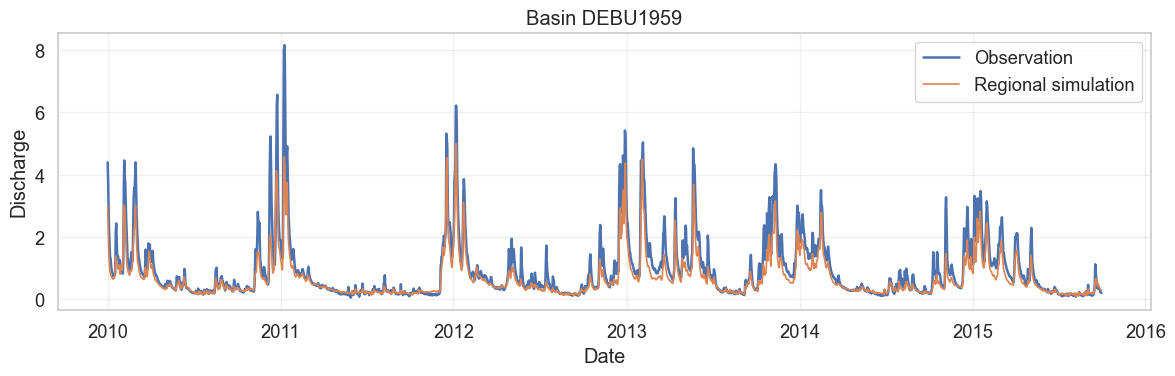

0.8837206363677979


In [114]:
import matplotlib.pyplot as plt

def plot_timeseries(ds, basin_id, start=None, end=None):
    """
    Plot observation vs regional simulation for one basin.
    """
    da = ds.sel(gauge_id=basin_id)

    if start or end:
        da = da.sel(date=slice(start, end))

    plt.figure(figsize=(12, 4))
    plt.plot(da.date, da["observation"], label="Observation", linewidth=1.8)
    plt.plot(da.date, da["regional"], label="Regional simulation", linewidth=1.2)

    plt.title(f"Basin {basin_id}")
    plt.xlabel("Date")
    plt.ylabel("Discharge")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
import numpy as np
import pandas as pd

def basin_timeseries_df(ds, basin_id, start=None, end=None):
    da = ds.sel(gauge_id=basin_id)

    if start or end:
        da = da.sel(date=slice(start, end))

    df = pd.DataFrame(
        {
            "date": da.date.values,
            "obs": da["observation"].values,
            "sim": da["regional"].values,
        }
    ).set_index("date")

    # Drop rows where either obs or sim is NaN
    df = df.dropna(subset=["obs", "sim"])

    return df



df = basin_timeseries_df(
    ds_clipped,
    basin_id="DEBU1958",
    start="2001-01-01",
    end="2015-12-31",
)

plot_timeseries(
    ds_clipped,
    basin_id="DEBU1959",
    start="2010-01-01",
    end="2020-12-31",
)
print(compute_nse(df.obs, df.sim, expo=1))

In [115]:
import matplotlib.pyplot as plt

def plot_timeseries_multi(
    ds,
    basin_id,
    sim_vars,
    labels=None,
    start=None,
    end=None,
    figsize=(12, 4),
):
    """
    Plot observation vs multiple simulations for one basin.

    Parameters
    ----------
    ds : xarray.Dataset
    basin_id : str
    sim_vars : list of str
        Variable names in ds for simulations (e.g. ["regional", "global"])
    labels : list of str, optional
        Labels for legend (same length as sim_vars)
    start, end : str or None
        Date range
    """
    da = ds.sel(gauge_id=basin_id)

    if start or end:
        da = da.sel(date=slice(start, end))

    if labels is None:
        labels = sim_vars

    plt.figure(figsize=figsize)

    # Observation
    plt.plot(
        da.date,
        da["observation"],
        label="Observation",
        linewidth=2.0,
    )

    # Simulations
    for var, lab in zip(sim_vars, labels):
        plt.plot(
            da.date,
            da[var],
            label=lab,
            linewidth=1.3,
        )

    plt.title(f"Basin {basin_id}")
    plt.xlabel("Date")
    plt.ylabel("Discharge")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


In [132]:
data_diff_val_complete_dict_plot.iloc[20:40]

,nse_nogeo,nse_ran,nse_g1comp,nse_c1comp,nse_r1comp,kge_nogeo,kge_ran,kge_g1comp,kge_c1comp,kge_r1comp,...,slope_c1comp,slope_g1comp,slope_nogeo,slope_ran,qmean_obs,qmean_r1comp,qmean_c1comp,qmean_g1comp,qmean_nogeo,qmean_ran
FR004143,0.764657,0.737968,0.783515,0.767067,0.777226,0.748251,0.715342,0.798545,0.711857,0.744920,...,1.905518,2.131983,2.044606,2.004057,1.361640,1.172385,1.142916,1.182740,1.147022,1.119662
FR001604,0.696415,0.731656,0.681463,0.743120,0.736190,0.448086,0.490324,0.447374,0.488994,0.448426,...,1.484185,1.405498,1.639066,1.753348,1.125220,0.888177,0.922629,0.830099,0.839060,0.861464
LU000018,0.734649,0.678278,0.654852,0.592413,0.740874,0.583159,0.492264,0.649404,0.308498,0.588805,...,0.926435,2.848018,1.907819,1.868495,0.895366,0.786901,0.721150,0.722175,0.748590,0.686632
LU000010,-0.456054,0.619910,-0.285612,0.209713,0.348592,-0.123631,0.453124,-0.097185,0.353910,0.403458,...,1.561509,3.496908,1.742180,1.631566,0.926466,1.411489,1.500261,1.688525,1.889999,0.621671
LU000001,0.860644,0.805286,0.841962,0.869620,0.861651,0.788806,0.804282,0.746375,0.724585,0.778036,...,3.082768,3.424144,3.876877,5.847762,1.192124,0.958100,0.938835,0.961518,0.964556,0.971120
DERP2028,0.702502,0.808668,0.800005,0.800478,0.788309,0.623812,0.638480,0.748292,0.558431,0.539643,...,1.363857,2.363596,2.309914,1.300314,0.982784,0.786259,0.773601,0.811075,0.705577,0.829182
FR000183,0.410820,-0.546880,0.577109,0.427791,0.392512,0.677172,0.487334,0.725467,0.646996,0.701909,...,2.658018,2.206136,2.256193,4.648703,1.116936,0.839389,0.762390,0.855033,0.827764,0.577903
DERP2008,0.802588,0.721079,0.797380,0.805886,0.811879,0.546874,0.455044,0.513239,0.548313,0.562439,...,2.638532,2.383521,2.387437,2.102407,0.964844,0.731240,0.726745,0.701288,0.731028,0.683956
FR000137,0.870995,0.855900,0.878425,0.869231,0.866732,0.823213,0.796459,0.818450,0.863913,0.853285,...,2.612672,2.636204,2.518432,3.511234,0.984974,0.909534,0.920694,0.908867,0.906491,0.849526
FR003294,0.795331,0.780121,0.816229,0.769662,0.806428,0.610286,0.611380,0.627972,0.498302,0.571988,...,2.479739,2.141016,2.025559,2.040050,0.833805,0.737890,0.707828,0.772119,0.792592,0.787922


In [185]:
data_diff_val_complete_dict_plot.index.tolist()[90:120]

['FR003288',
 'FR000174',
 'DERP2021',
 'FR003293',
 'FR003236',
 'BEWA0119',
 'DERP2013',
 'DERP2024',
 'FR003283',
 'FR000159',
 'FR003284',
 'LU000019',
 'LU000015',
 'FR003259',
 'DERP2015',
 'FR003274',
 'DERP2036',
 'DERP2011',
 'BEWA0066',
 'FR003275',
 'FR003257',
 'FR003296',
 'FR000171',
 'FR000140',
 'DEBU1956',
 'LU000002',
 'LU000016',
 'FR003250',
 'FR000132',
 'FR003254']

In [ ]:
BASIN_ID = "BEWA0106"
BASIN_ID = "LU000017"
BASIN_ID = "BEWA0107"
BASIN_ID = "BEWA0119"
BASIN_ID = "DERP2024"
BASIN_ID = "BEWA0066"
BASIN_ID = "LU000002"
BASIN_ID = "DERP2013"

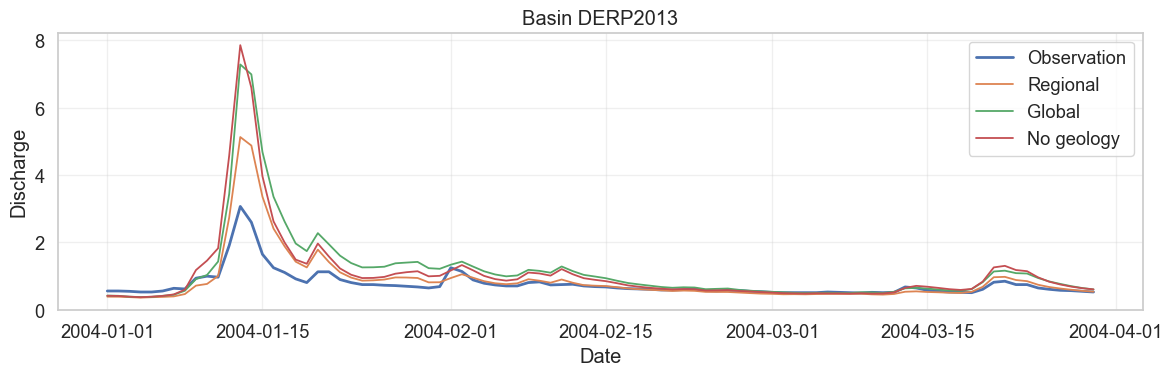

In [220]:
plot_timeseries_multi(
    ds_clipped,
    basin_id=BASIN_ID,
    sim_vars=["regional", "global", "nogeology"],
    labels=["Regional", "Global", "No geology"],
    start="2004-01-01",
    end="2004-03-30",
)

In [221]:
data_diff_val_complete_dict_plot.loc[BASIN_ID][["bfi_obs", "bfi_r1comp", "bfi_c1comp", "bfi_g1comp", "bfi_nogeo"]]

bfi_obs       0.815621
bfi_r1comp    0.750197
bfi_c1comp    0.712668
bfi_g1comp    0.655827
bfi_nogeo     0.661168
Name: DERP2013, dtype: float64

## Technical validation with CAMELS-DE

In [475]:
# German basins only
network_DE = network_estreams_moselle_108_gauges[network_estreams_moselle_108_gauges.gauge_country == "DE"]

In [476]:
import pandas as pd
from rapidfuzz import process, fuzz
import unicodedata, re

# 1. Normalization helpers
def normalize_text(s):
    """Remove accents, punctuation, lowercase."""
    if pd.isna(s):
        return ""
    s = str(s).lower().strip()
    s = unicodedata.normalize("NFKD", s).encode("ascii", "ignore").decode("utf-8")
    s = re.sub(r"[^a-z0-9]+", "", s)
    return s

def normalize_id(s):
    """Digits only, strip trailing zeros (e.g., 5717000000 → 5717)."""
    if pd.isna(s):
        return ""
    s = re.sub(r"\D", "", str(s))
    return s.rstrip("0")

# 2. Prepare data
network_estreams_de = network_DE[network_DE.gauge_country=="DE"]
camels = pd.read_csv("/Users/nascimth/Downloads/camels_de/CAMELS_DE_topographic_attributes.csv", index_col=0)
camels["gauge_id"] = camels.index
camels.index.name = "index"

estreams = network_estreams_de[["gauge_id", "gauge_name", "river"]].copy()

# The index here is basin_id — DO NOT overwrite it.
estreams["combined_name"] = (
    estreams["gauge_name"].fillna("") + " " + estreams["river"].fillna("")
).str.strip()

# Normalized columns
estreams["norm_id"] = estreams["gauge_id"].apply(normalize_id)
estreams["norm_name"] = estreams["gauge_name"].apply(normalize_text)
estreams["norm_combined"] = estreams["combined_name"].apply(normalize_text)

camels = camels[["gauge_id", "provider_id", "gauge_name", "water_body_name"]].copy()
camels["combined_name"] = (camels["gauge_name"].fillna("") + " " +
                           camels["water_body_name"].fillna("")).str.strip()

camels["norm_id"] = camels["provider_id"].apply(normalize_id)
camels["norm_name"] = camels["gauge_name"].apply(normalize_text)
camels["norm_combined"] = camels["combined_name"].apply(normalize_text)

# 3. Exact matches (ID, name, combined)
def exact_match(left, right, left_on, right_on, match_type):
    m = pd.merge(
        left, right,
        left_on=left_on,
        right_on=right_on,
        how="inner",
        suffixes=("_camels", "_estreams")
    )
    if "gauge_id_camels" in m.columns:
        m.rename(columns={"gauge_id_camels": "gauge_id"}, inplace=True)
    if "gauge_id" not in m.columns:
        m["gauge_id"] = None
    if not m.empty:
        m["match_type"] = match_type
    return m

matches = []
matches.append(exact_match(camels, estreams, "norm_id", "norm_id", "ID (normalized)"))
matches.append(exact_match(camels, estreams, "norm_name", "norm_name", "Name (normalized)"))
matches.append(exact_match(camels, estreams, "norm_combined", "norm_combined", "Combined name (normalized)"))

exact_matches = pd.concat(matches, ignore_index=True)
exact_matches = exact_matches.drop_duplicates(subset=["gauge_id"])
matched_camels_ids = set(exact_matches["gauge_id"].dropna().unique())

# 4. Fuzzy fallback for unmatched ones
unmatched_camels = camels[~camels["gauge_id"].isin(matched_camels_ids)].copy()
fuzzy_matches = []

for _, row in unmatched_camels.iterrows():
    name = row["norm_combined"]
    if not name:
        continue
    best = process.extractOne(name, estreams["norm_combined"], scorer=fuzz.token_sort_ratio)
    if best and best[1] >= 85:
        matched_row = estreams.loc[estreams["norm_combined"] == best[0]].iloc[0]
        fuzzy_matches.append({
            "gauge_id": row["gauge_id"],
            "estreams_id": matched_row.name,
            "camels_name": row["combined_name"],
            "estreams_name": matched_row["combined_name"],
            "similarity": best[1],
            "match_type": "Fuzzy (normalized)"
        })

fuzzy_matches = pd.DataFrame(fuzzy_matches)

# 5. Combine all matches & build rename dictionary (corrected)

# Preserve the EStreams index as 'basin_id' without duplicating 'gauge_id'
estreams_reset = estreams.copy()
estreams_reset["basin_id"] = estreams_reset.index  # keep basin_id explicitly

# Re-run the exact_match function with this updated estreams
def exact_match(left, right, left_on, right_on, match_type):
    m = pd.merge(
        left,
        right,
        left_on=left_on,
        right_on=right_on,
        how="inner",
        suffixes=("_camels", "_estreams")
    )
    if "gauge_id_camels" in m.columns:
        m.rename(columns={"gauge_id_camels": "gauge_id"}, inplace=True)
    if not m.empty:
        m["match_type"] = match_type
    return m

# Redo exact matches
matches = []
matches.append(exact_match(camels, estreams_reset, "norm_id", "norm_id", "ID (normalized)"))
matches.append(exact_match(camels, estreams_reset, "norm_name", "norm_name", "Name (normalized)"))
matches.append(exact_match(camels, estreams_reset, "norm_combined", "norm_combined", "Combined name (normalized)"))

exact_matches = pd.concat(matches, ignore_index=True)
exact_matches = exact_matches.drop_duplicates(subset=["gauge_id"])
matched_camels_ids = set(exact_matches["gauge_id"].dropna().unique())

# Fuzzy matches (same logic)
unmatched_camels = camels[~camels["gauge_id"].isin(matched_camels_ids)].copy()
fuzzy_matches = []
for _, row in unmatched_camels.iterrows():
    name = row["norm_combined"]
    if not name:
        continue
    best = process.extractOne(name, estreams["norm_combined"], scorer=fuzz.token_sort_ratio)
    if best and best[1] >= 85:
        matched_row = estreams.loc[estreams["norm_combined"] == best[0]].iloc[0]
        fuzzy_matches.append({
            "gauge_id": row["gauge_id"],
            "estreams_id": matched_row.name,  # index = basin_id
            "camels_name": row["combined_name"],
            "estreams_name": matched_row["combined_name"],
            "similarity": best[1],
            "match_type": "Fuzzy (normalized)"
        })
fuzzy_matches = pd.DataFrame(fuzzy_matches)

# Build final mapping
exact_matches["estreams_id"] = exact_matches["basin_id"]

mapping = pd.concat([exact_matches[["gauge_id", "estreams_id", "match_type"]], fuzzy_matches], ignore_index=True)
mapping = mapping.dropna(subset=["estreams_id"])
mapping = mapping.drop_duplicates(subset=["gauge_id"])

rename_dict = mapping.set_index("gauge_id")["estreams_id"].to_dict()

# Print summary
print("=== Match summary ===")
print(mapping["match_type"].value_counts())
print(f"\nMatched: {len(rename_dict)}/{len(camels)} ({len(rename_dict)/len(camels):.1%})")

# Check a few mappings
print("\nExample rename_dict entries:")
for k, v in list(rename_dict.items())[:10]:
    print(f"{k} → {v}")

=== Match summary ===
match_type
ID (normalized)    16
Name: count, dtype: int64

Matched: 16/1582 (1.0%)

Example rename_dict entries:
DEB10130 → DERP2013
DEB10340 → DERP2036
DEB10900 → DERP2005
DEB10910 → DERP2006
DEB10940 → DERP2007
DEB10950 → DERP2008
DEB10970 → DERP2010
DEB10980 → DERP2011
DEB11010 → DERP2017
DEB11020 → DERP2018


In [477]:
rename_dict

{'DEB10130': 'DERP2013',
 'DEB10340': 'DERP2036',
 'DEB10900': 'DERP2005',
 'DEB10910': 'DERP2006',
 'DEB10940': 'DERP2007',
 'DEB10950': 'DERP2008',
 'DEB10970': 'DERP2010',
 'DEB10980': 'DERP2011',
 'DEB11010': 'DERP2017',
 'DEB11020': 'DERP2018',
 'DEB11110': 'DERP2027',
 'DEB11120': 'DERP2028',
 'DEB11130': 'DERP2029',
 'DEB11140': 'DERP2030',
 'DEB11150': 'DERP2031',
 'DEB11180': 'DERP2033'}

In [478]:
data_diff_timeval_complete_dict_plot

,nse_nogeo,nse_ran,nse_g1comp,nse_c1comp,nse_r1comp,kge_nogeo,kge_ran,kge_g1comp,kge_c1comp,kge_r1comp,...,slope_c1comp,slope_g1comp,slope_nogeo,slope_ran,qmean_obs,qmean_r1comp,qmean_c1comp,qmean_g1comp,qmean_nogeo,qmean_ran
FR004136,0.669755,0.678249,0.683081,0.680154,0.676096,0.563582,0.594021,0.597832,0.596808,0.583273,...,2.351846,2.269471,2.153699,2.232011,2.164676,1.702373,1.711115,1.738528,1.667284,1.693179
FR001547,0.818005,0.829254,0.819462,0.821860,0.822863,0.772873,0.830559,0.779140,0.789951,0.787768,...,2.830713,2.648390,2.851773,2.895733,0.834606,0.806548,0.825703,0.808343,0.803193,0.837438
FR004091,0.714085,0.718700,0.713530,0.709313,0.720225,0.746219,0.774726,0.746116,0.740150,0.732633,...,2.047963,2.138593,2.138954,2.162572,2.553183,2.332357,2.331494,2.317246,2.303061,2.350829
FR001592,0.599082,0.589886,0.567664,0.589826,0.568468,0.446223,0.458726,0.425571,0.448692,0.445003,...,2.074900,2.126999,2.187754,1.974919,0.253320,0.210900,0.205424,0.213876,0.205789,0.220506
FR001577,0.856133,0.867215,0.855435,0.858854,0.857571,0.785998,0.826322,0.766259,0.797793,0.780208,...,3.932925,3.938186,4.097544,4.074210,0.956345,0.922150,0.943610,0.897389,0.906473,0.940976
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
DERP2007,0.766721,0.759205,0.778492,0.777963,0.777536,0.593710,0.589819,0.615879,0.602996,0.620672,...,2.354709,2.465091,2.552640,2.381128,1.074993,0.841905,0.824339,0.836241,0.816111,0.813806
FR003271,0.790847,0.820841,0.785545,0.818318,0.793568,0.628214,0.652309,0.617996,0.672702,0.637304,...,2.000472,1.765935,1.777982,1.949539,0.654911,0.584033,0.587196,0.565186,0.575291,0.567479
FR003301,0.849893,0.876918,0.833035,0.840418,0.842579,0.688758,0.785601,0.657937,0.689177,0.683138,...,2.126257,2.048522,2.089328,1.998726,0.816842,0.726655,0.726464,0.692257,0.708515,0.766610
DERP2003,0.883538,0.878983,0.869133,0.883136,0.884355,0.768248,0.765198,0.752982,0.775918,0.792265,...,2.072312,2.110338,2.051967,1.972571,0.958075,0.857947,0.845491,0.831279,0.832525,0.838283


In [479]:
data_diff_timeval_complete_dict_plot.loc[exact_matches.estreams_id.tolist()][["nse_nogeo", "nse_r1comp"]]

,nse_nogeo,nse_r1comp
DERP2013,0.703634,0.673021
DERP2036,0.735381,0.751616
DERP2005,0.730264,0.746484
DERP2006,0.740957,0.762337
DERP2007,0.766721,0.777536
DERP2008,0.708570,0.721647
DERP2010,0.751243,0.754295
DERP2011,0.798282,0.800717
DERP2017,0.859313,0.854806
DERP2018,0.872045,0.877697


In [501]:
import os
import pandas as pd
import numpy as np
import tqdm
from pandas.errors import EmptyDataError
import xarray as xr

from neuralhydrology.evaluation.signatures import (
    baseflow_index,
    hfd_mean,
    slope_fdc,
    q_mean,
)

# =========================================================
# USER INPUT
# =========================================================

base_dir = "/Users/nascimth/Downloads/camels_de/timeseries_simulated/"

SELECTED_BASINS = ['DEB10130',
 'DEB10340',
 'DEB10900',
 'DEB10910',
 'DEB10940',
 'DEB10950',
 'DEB10970',
 'DEB10980',
 'DEB11010',
 'DEB11020',
 'DEB11110',
 'DEB11120',
 'DEB11130',
 'DEB11140',
 'DEB11150',
 'DEB11180']



# Signature evaluation period ONLY
SIG_START = "2001-10-01"
SIG_END   = "2015-09-30"

MIN_VALID_POINTS = 365

# =========================================================
# SIGNATURE HELPERS (UNCHANGED LOGIC)
# =========================================================

def _align_sim_to_obs(sim: xr.DataArray, obs: xr.DataArray) -> xr.DataArray:
    return sim.where(~np.isnan(obs))

def safe_bfi(sim, obs):
    sim = _align_sim_to_obs(sim, obs)
    if sim.count() < MIN_VALID_POINTS:
        return np.nan
    return baseflow_index(sim, alpha=0.925, warmup=365, n_passes=3)[0]

def safe_hfd(sim, obs):
    sim = _align_sim_to_obs(sim, obs)
    if sim.count() < MIN_VALID_POINTS:
        return np.nan
    return hfd_mean(sim, datetime_coord="date")

def safe_slope(sim, obs):
    sim = _align_sim_to_obs(sim, obs)
    if sim.count() < MIN_VALID_POINTS:
        return np.nan
    return slope_fdc(sim)

def safe_qmean(sim, obs):
    sim = _align_sim_to_obs(sim, obs)
    if sim.count() < MIN_VALID_POINTS:
        return np.nan
    return q_mean(sim)

signature_funcs = {
    "bfi": safe_bfi,
    "hfd": safe_hfd,
    "slope": safe_slope,
    "qmean": safe_qmean,
}

# =========================================================
# MAIN LOOP
# =========================================================

results = []

for basin_id in tqdm.tqdm(SELECTED_BASINS, desc="Processing selected basins"):

    file_name = f"CAMELS_DE_discharge_sim_{basin_id}.csv"
    file_path = os.path.join(base_dir, file_name)

    if not os.path.exists(file_path):
        print(f"Missing file for basin {basin_id}")
        continue

    try:
        df = pd.read_csv(file_path)
    except EmptyDataError:
        print(f"Empty file: {basin_id}")
        continue

    required_cols = {
        "date",
        "discharge_spec_obs",
        "discharge_spec_sim_lstm",
        "discharge_spec_sim_hbv",
    }
    if not required_cols.issubset(df.columns):
        print(f"Missing columns for {basin_id}")
        continue

    # -----------------------------------------------------
    # PREPARE DATA
    # -----------------------------------------------------
    df["date"] = pd.to_datetime(df["date"])
    df = df.set_index("date").sort_index()

    for col in required_cols - {"date"}:
        neg = df[col] < 0
        if neg.any():
            df.loc[neg, col] = 0

    # -----------------------------------------------------
    # NSE / KGE (UNCHANGED PERIODS)
    # -----------------------------------------------------
    try:
        nse_lstm = compute_nse(
            df.loc["2001-10-01":"2015-09-30", "discharge_spec_obs"].values,
            df.loc["2001-10-01":"2015-09-30", "discharge_spec_sim_lstm"].values,
            expo=1,
        )
        kge_lstm = compute_kge(
            df.loc["2001-10-01":"2015-09-30", "discharge_spec_obs"].values,
            df.loc["2001-10-01":"2015-09-30", "discharge_spec_sim_lstm"].values,
        )

        nse_hbv = compute_nse(
            df.loc["2001-10-01":"2015-09-30", "discharge_spec_obs"].values,
            df.loc["2001-10-01":"2015-09-30", "discharge_spec_sim_hbv"].values,
            expo=1,
        )
        kge_hbv = compute_kge(
            df.loc["2001-10-01":"2015-09-30", "discharge_spec_obs"].values,
            df.loc["2001-10-01":"2015-09-30", "discharge_spec_sim_hbv"].values,
        )

    except Exception as e:
        print(f"NSE/KGE failed for {basin_id}: {e}")
        continue

    # -----------------------------------------------------
    # SIGNATURE PERIOD ONLY (2001–2015)
    # -----------------------------------------------------
    df_sig = df.loc[SIG_START:SIG_END].copy()

    dates = df_sig.index.values
    obs_da  = xr.DataArray(df_sig["discharge_spec_obs"].values, dims=["date"], coords={"date": dates})
    lstm_da = xr.DataArray(df_sig["discharge_spec_sim_lstm"].values, dims=["date"], coords={"date": dates})
    hbv_da  = xr.DataArray(df_sig["discharge_spec_sim_hbv"].values, dims=["date"], coords={"date": dates})

    row = {
        "basin_id": basin_id,
        "NSE_lstm": nse_lstm,
        "KGE_lstm": kge_lstm,
        "NSE_hbv": nse_hbv,
        "KGE_hbv": kge_hbv,
    }

    for sig_name, sig_func in signature_funcs.items():
        try:
            row[f"{sig_name}_obs"] = sig_func(obs_da, obs_da)
        except Exception:
            row[f"{sig_name}_obs"] = np.nan

        try:
            row[f"{sig_name}_lstm"] = sig_func(lstm_da, obs_da)
        except Exception:
            row[f"{sig_name}_lstm"] = np.nan

        try:
            row[f"{sig_name}_hbv"] = sig_func(hbv_da, obs_da)
        except Exception:
            row[f"{sig_name}_hbv"] = np.nan

    results.append(row)

# =========================================================
# FINAL DATAFRAME
# =========================================================

df_metrics_and_signatures = (
    pd.DataFrame(results)
    .set_index("basin_id")
    .sort_index()
)

Processing selected basins: 100%|██████████| 16/16 [00:01<00:00,  8.62it/s]


In [502]:
df_metrics_and_signatures.describe()

,NSE_lstm,KGE_lstm,NSE_hbv,KGE_hbv,bfi_obs,bfi_lstm,bfi_hbv,hfd_obs,hfd_lstm,hfd_hbv,slope_obs,slope_lstm,slope_hbv,qmean_obs,qmean_lstm,qmean_hbv
count,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000
mean,0.878109,0.796404,0.796856,0.781507,0.559014,0.598989,0.583162,132.860577,134.663462,134.091346,2.609873,2.490069,2.418110,0.948340,0.882632,0.903174
std,0.042016,0.089368,0.052731,0.079255,0.091058,0.090617,0.093714,9.475442,9.966566,11.154331,0.755559,0.709012,0.712292,0.206180,0.153279,0.171173
min,0.773258,0.641799,0.673537,0.645252,0.439976,0.478172,0.469600,121.230769,121.615385,118.307692,0.931772,0.638075,0.845974,0.678210,0.707694,0.684354
25%,0.861867,0.737114,0.762384,0.741392,0.492060,0.549944,0.523326,129.173077,130.288462,129.134615,2.070733,2.162768,1.990265,0.767020,0.734390,0.787003
50%,0.886489,0.800572,0.801501,0.779285,0.570401,0.601271,0.581235,132.192308,135.076923,132.769231,2.702418,2.584174,2.410614,0.968049,0.856293,0.863106
75%,0.904640,0.867526,0.837172,0.837813,0.596515,0.627967,0.630484,134.769231,136.903846,136.923077,3.008498,2.797872,2.859695,1.065473,0.969460,0.973455
max,0.928655,0.927112,0.872537,0.909854,0.815618,0.861286,0.849576,161.846154,165.692308,167.846154,3.762767,3.718878,3.675826,1.430583,1.180808,1.293489


In [503]:
df_metrics_and_signatures

,NSE_lstm,KGE_lstm,NSE_hbv,KGE_hbv,bfi_obs,bfi_lstm,bfi_hbv,hfd_obs,hfd_lstm,hfd_hbv,slope_obs,slope_lstm,slope_hbv,qmean_obs,qmean_lstm,qmean_hbv
basin_id,,,,,,,,,,,,,,,,
DEB10130,0.773258,0.755627,0.673537,0.808375,0.815618,0.861286,0.849576,161.846154,165.692308,167.846154,0.931772,0.638075,0.845974,0.678210,0.794565,0.753409
DEB10340,0.914429,0.872219,0.863366,0.838175,0.466658,0.543620,0.476221,130.153846,131.923077,129.923077,3.492968,2.673907,3.163043,0.709773,0.708054,0.738183
DEB10900,0.863517,0.742275,0.761490,0.679681,0.446361,0.512913,0.469600,123.076923,125.230769,118.307692,3.762767,3.104558,3.675826,1.082247,0.917633,0.847428
DEB10910,0.856918,0.685117,0.762683,0.732293,0.439976,0.478172,0.491285,121.230769,122.923077,126.000000,3.648402,3.362612,2.813519,1.430583,1.123399,1.293489
DEB10940,0.840432,0.641799,0.784728,0.655410,0.498208,0.558440,0.633380,126.461538,129.307692,130.846154,2.862005,2.755667,1.485474,1.074739,0.847113,0.928117
DEB10950,0.818772,0.659826,0.733318,0.645252,0.473617,0.481811,0.534007,121.923077,121.615385,121.769231,3.447979,3.718878,2.998221,0.961400,0.736088,0.824843
DEB10970,0.892492,0.815111,0.779993,0.751681,0.573982,0.608946,0.603998,133.076923,137.307692,144.846154,1.981595,1.822970,1.931111,0.908467,0.858445,0.878783
DEB10980,0.901377,0.786033,0.810827,0.744425,0.558289,0.617852,0.636968,131.076923,135.769231,136.153846,1.954963,2.193693,1.843175,0.769578,0.729296,0.798201
DEB11010,0.899306,0.898982,0.842688,0.898910,0.626141,0.640879,0.633918,134.769231,136.230769,131.538462,2.703024,2.550204,2.355243,1.226270,1.180808,1.220119


In [489]:
import os
import pandas as pd
import numpy as np
import tqdm
from pandas.errors import EmptyDataError
import xarray as xr

from neuralhydrology.evaluation.signatures import (
    baseflow_index,
    hfd_mean,
    slope_fdc,
    q_mean,
)

# =========================================================
# USER INPUT
# =========================================================

base_dir = "/Users/nascimth/Downloads/camels_de/timeseries_simulated/"

SELECTED_BASINS = [
    'DEB10130','DEB10340','DEB10900','DEB10910','DEB10940','DEB10950',
    'DEB10970','DEB10980','DEB11010','DEB11020','DEB11110','DEB11120',
    'DEB11130','DEB11140','DEB11150','DEB11180'
]

RENAME_DICT = {
    'DEB10130': 'DERP2013',
    'DEB10340': 'DERP2036',
    'DEB10900': 'DERP2005',
    'DEB10910': 'DERP2006',
    'DEB10940': 'DERP2007',
    'DEB10950': 'DERP2008',
    'DEB10970': 'DERP2010',
    'DEB10980': 'DERP2011',
    'DEB11010': 'DERP2017',
    'DEB11020': 'DERP2018',
    'DEB11110': 'DERP2027',
    'DEB11120': 'DERP2028',
    'DEB11130': 'DERP2029',
    'DEB11140': 'DERP2030',
    'DEB11150': 'DERP2031',
    'DEB11180': 'DERP2033',
}

SIG_START = "2001-10-01"
SIG_END   = "2005-09-30"

MIN_VALID_POINTS = 365

# =========================================================
# LOAD OBSERVATIONS FROM NC (AUTHORITATIVE SOURCE)
# =========================================================

nc_obs_file = "../results/sim_lstm/time/simu_Seed_28.nc"  # any seed works
ds_obs = xr.open_dataset(nc_obs_file)

# Rename gauges
ds_obs = ds_obs.assign_coords(
    gauge_id=[RENAME_DICT.get(g, g) for g in ds_obs.gauge_id.values]
)

# Collapse duplicates created by renaming
if not ds_obs.indexes["gauge_id"].is_unique:
    ds_obs = ds_obs.groupby("gauge_id").mean()

# Keep only basins of interest
ds_obs = ds_obs.sel(gauge_id=list(RENAME_DICT.values()))


# =========================================================
# SIGNATURE HELPERS
# =========================================================

def _align_sim_to_obs(sim: xr.DataArray, obs: xr.DataArray) -> xr.DataArray:
    return sim.where(~np.isnan(obs))


def safe_bfi(sim, obs):
    sim = _align_sim_to_obs(sim, obs)
    if sim.count() < MIN_VALID_POINTS:
        return np.nan
    return baseflow_index(sim, alpha=0.925, warmup=365, n_passes=3)[0]


def safe_hfd(sim, obs):
    sim = _align_sim_to_obs(sim, obs)
    if sim.count() < MIN_VALID_POINTS:
        return np.nan
    return hfd_mean(sim, datetime_coord="date")


def safe_slope(sim, obs):
    sim = _align_sim_to_obs(sim, obs)
    if sim.count() < MIN_VALID_POINTS:
        return np.nan
    return slope_fdc(sim)


def safe_qmean(sim, obs):
    sim = _align_sim_to_obs(sim, obs)
    if sim.count() < MIN_VALID_POINTS:
        return np.nan
    return q_mean(sim)


signature_funcs = {
    "bfi": safe_bfi,
    "hfd": safe_hfd,
    "slope": safe_slope,
    "qmean": safe_qmean,
}

# =========================================================
# MAIN LOOP
# =========================================================

results = []

for basin_id in tqdm.tqdm(SELECTED_BASINS, desc="Processing selected basins"):

    file_name = f"CAMELS_DE_discharge_sim_{basin_id}.csv"
    file_path = os.path.join(base_dir, file_name)

    if not os.path.exists(file_path):
        print(f"Missing file for basin {basin_id}")
        continue

    try:
        df = pd.read_csv(file_path)
    except EmptyDataError:
        print(f"Empty file: {basin_id}")
        continue

    if "date" not in df.columns:
        print(f"Missing date column for {basin_id}")
        continue

    # -----------------------------------------------------
    # PREPARE CSV SIMULATIONS (OBS IGNORED)
    # -----------------------------------------------------
    df["date"] = pd.to_datetime(df["date"])
    df = df.set_index("date").sort_index()

    for col in ["discharge_spec_sim_lstm", "discharge_spec_sim_hbv"]:
        neg = df[col] < 0
        if neg.any():
            df.loc[neg, col] = 0.0

    # -----------------------------------------------------
    # GET OBSERVATIONS FROM NC
    # -----------------------------------------------------
    gauge_nc = RENAME_DICT[basin_id]

    obs_da = (
        ds_obs["observation"]
        .sel(gauge_id=gauge_nc, date=slice(SIG_START, SIG_END))
        .dropna("date", how="all")
    )

    # -----------------------------------------------------
    # ALIGN SIMULATIONS TO OBS DATES
    # -----------------------------------------------------
    df_sig = df.loc[obs_da.date.values]

    lstm_da = xr.DataArray(
        df_sig["discharge_spec_sim_lstm"].values,
        dims=["date"],
        coords={"date": df_sig.index.values},
    )

    hbv_da = xr.DataArray(
        df_sig["discharge_spec_sim_hbv"].values,
        dims=["date"],
        coords={"date": df_sig.index.values},
    )

    # -----------------------------------------------------
    # NSE / KGE (UNCHANGED IMPLEMENTATION)
    # -----------------------------------------------------
    try:
        nse_lstm = compute_nse(obs_da.values, lstm_da.values, expo=1)
        kge_lstm = compute_kge(obs_da.values, lstm_da.values)

        nse_hbv = compute_nse(obs_da.values, hbv_da.values, expo=1)
        kge_hbv = compute_kge(obs_da.values, hbv_da.values)

    except Exception as e:
        print(f"NSE/KGE failed for {basin_id}: {e}")
        continue

    # -----------------------------------------------------
    # SIGNATURES
    # -----------------------------------------------------
    row = {
        "basin_id": basin_id,
        "NSE_lstm": nse_lstm,
        "KGE_lstm": kge_lstm,
        "NSE_hbv": nse_hbv,
        "KGE_hbv": kge_hbv,
    }

    for sig_name, sig_func in signature_funcs.items():
        try:
            row[f"{sig_name}_obs"] = sig_func(obs_da, obs_da)
        except Exception:
            row[f"{sig_name}_obs"] = np.nan

        try:
            row[f"{sig_name}_lstm"] = sig_func(lstm_da, obs_da)
        except Exception:
            row[f"{sig_name}_lstm"] = np.nan

        try:
            row[f"{sig_name}_hbv"] = sig_func(hbv_da, obs_da)
        except Exception:
            row[f"{sig_name}_hbv"] = np.nan

    results.append(row)

# =========================================================
# FINAL DATAFRAME
# =========================================================

df_metrics_and_signatures = (
    pd.DataFrame(results)
    .set_index("basin_id")
    .sort_index()
)

Processing selected basins: 100%|██████████| 16/16 [00:00<00:00, 19.17it/s]


In [482]:
import numpy as np
import pandas as pd
import xarray as xr
import tqdm

from neuralhydrology.evaluation.signatures import (
    baseflow_index,
    hfd_mean,
    slope_fdc,
    q_mean,
)

# =========================================================
# USER INPUT
# =========================================================

SEED_FILES = [
    "../results/sim_lstm/time/simu_Seed_28.nc",
    #"../results/sim_lstm/time/simu_Seed_33.nc",
    "../results/sim_lstm/time/simu_Seed_44.nc",
    "../results/sim_lstm/time/simu_Seed_55.nc",
    "../results/sim_lstm/time/simu_Seed_77.nc",
]

SEEDS = [55]

SELECTED_BASINS = [
    'DEB10130','DEB10340','DEB10900','DEB10910','DEB10940','DEB10950',
    'DEB10970','DEB10980','DEB11010','DEB11020','DEB11110','DEB11120',
    'DEB11130','DEB11140','DEB11150','DEB11180'
]

RENAME_DICT = {
    'DEB10130': 'DERP2013',
    'DEB10340': 'DERP2036',
    'DEB10900': 'DERP2005',
    'DEB10910': 'DERP2006',
    'DEB10940': 'DERP2007',
    'DEB10950': 'DERP2008',
    'DEB10970': 'DERP2010',
    'DEB10980': 'DERP2011',
    'DEB11010': 'DERP2017',
    'DEB11020': 'DERP2018',
    'DEB11110': 'DERP2027',
    'DEB11120': 'DERP2028',
    'DEB11130': 'DERP2029',
    'DEB11140': 'DERP2030',
    'DEB11150': 'DERP2031',
    'DEB11180': 'DERP2033',
}

SIG_START = "2001-10-01"
SIG_END   = "2015-09-30"

MIN_VALID_POINTS = 365

# =========================================================
# LOAD + PREPARE SEED DATA
# =========================================================

datasets = []

for seed, f in zip(SEEDS, SEED_FILES):
    ds = xr.open_dataset(f)

    # Rename gauges
    ds = ds.assign_coords(
        gauge_id=[RENAME_DICT.get(g, g) for g in ds.gauge_id.values]
    )

    # Collapse duplicates caused by renaming
    if not ds.indexes["gauge_id"].is_unique:
        ds = ds.groupby("gauge_id").mean()

    ds = ds.expand_dims(seed=[seed])
    datasets.append(ds)

ds_all = xr.concat(datasets, dim="seed")

# Mean across seeds (same spirit as CAMELS single run)
ds = ds_all.mean(dim="seed")

# Restrict basins and period
ds = ds.sel(
    gauge_id=list(RENAME_DICT.values()),
    date=slice(SIG_START, SIG_END),
)

# =========================================================
# SIGNATURE HELPERS (IDENTICAL)
# =========================================================

def _align_sim_to_obs(sim: xr.DataArray, obs: xr.DataArray) -> xr.DataArray:
    return sim.where(~np.isnan(obs))


def safe_bfi(sim, obs):
    sim = _align_sim_to_obs(sim, obs)
    if sim.count() < MIN_VALID_POINTS:
        return np.nan
    return baseflow_index(sim, alpha=0.925, warmup=365, n_passes=3)[0]


def safe_hfd(sim, obs):
    sim = _align_sim_to_obs(sim, obs)
    if sim.count() < MIN_VALID_POINTS:
        return np.nan
    return hfd_mean(sim, datetime_coord="date")


def safe_slope(sim, obs):
    sim = _align_sim_to_obs(sim, obs)
    if sim.count() < MIN_VALID_POINTS:
        return np.nan
    return slope_fdc(sim)


def safe_qmean(sim, obs):
    sim = _align_sim_to_obs(sim, obs)
    if sim.count() < MIN_VALID_POINTS:
        return np.nan
    return q_mean(sim)


signature_funcs = {
    "bfi": safe_bfi,
    "hfd": safe_hfd,
    "slope": safe_slope,
    "qmean": safe_qmean,
}

# =========================================================
# METRIC COMPUTATION (SAME EQUATIONS)
# =========================================================

results = []

for basin in tqdm.tqdm(ds.gauge_id.values, desc="Processing seed basins"):

    obs_da = ds.sel(gauge_id=basin)["observation"]
    sim_da = ds.sel(gauge_id=basin)["regional"]

    ## Drop NaNs jointly
    #da_pair = xr.Dataset(
    #    {"obs": obs_da, "sim": sim_da}
    #).dropna(dim="date", how="any")

    #obs = da_pair.obs.values
    #sim = da_pair.sim.values
    obs = obs_da.values
    sim = sim_da.values

    if len(obs) < MIN_VALID_POINTS:
        continue

    try:
        nse_val = compute_nse(obs, sim, expo=1)
        kge_val = compute_kge(obs, sim)
    except Exception:
        continue

    row = {
        "basin_id": basin,
        "NSE": nse_val,
        "KGE": kge_val,
    }

    for sig, fn in signature_funcs.items():
        try:
            row[f"{sig}_obs"] = fn(obs_da, obs_da)
        except Exception:
            row[f"{sig}_obs"] = np.nan

        try:
            row[f"{sig}_sim"] = fn(sim_da, obs_da)
        except Exception:
            row[f"{sig}_sim"] = np.nan

    results.append(row)

# =========================================================
# FINAL DATAFRAME
# =========================================================

df_seed_metrics_and_signatures = (
    pd.DataFrame(results)
    .set_index("basin_id")
    .sort_index()
)


Processing seed basins: 100%|██████████| 16/16 [00:00<00:00, 19.33it/s]


In [483]:
df_seed_metrics_and_signatures

,NSE,KGE,bfi_obs,bfi_sim,hfd_obs,hfd_sim,slope_obs,slope_sim,qmean_obs,qmean_sim
basin_id,,,,,,,,,,
DERP2005,0.747557,0.631121,0.446366,0.531250,123.076923,124.846154,3.762767,3.240430,1.080588,0.834222
DERP2006,0.776796,0.707423,0.440146,0.492665,121.230769,123.076923,3.796252,3.257715,1.416212,1.179943
DERP2007,0.784713,0.641077,0.498234,0.560791,126.461538,128.000000,2.828146,2.527217,1.074993,0.851712
DERP2008,0.723418,0.613024,0.473465,0.557048,121.923077,125.923077,3.486582,2.705579,0.964844,0.773069
DERP2010,0.761919,0.703639,0.574114,0.675443,133.000000,136.923077,1.981595,1.625394,0.905834,0.839271
DERP2011,0.800979,0.713536,0.558243,0.668784,131.076923,136.769231,1.954964,1.533157,0.767888,0.745337
DERP2013,0.637653,0.726163,0.815621,0.849111,161.846154,160.769231,0.931772,0.606774,0.677523,0.822726
DERP2017,0.857811,0.868379,0.625862,0.632463,134.846154,132.615385,2.678084,2.492056,1.222016,1.119393
DERP2018,0.886020,0.835166,0.583362,0.633829,134.076923,134.384615,2.708539,2.821260,0.973843,0.899349


In [730]:
import matplotlib.pyplot as plt

def plot_timeseries(ds, basin_id, start=None, end=None):
    """
    Plot observation vs regional simulation for one basin.
    """
    da = ds.sel(gauge_id=basin_id)

    if start or end:
        da = da.sel(date=slice(start, end))

    plt.figure(figsize=(12, 4))
    plt.plot(da.date, da["observation"], label="Observation", linewidth=1.8)
    plt.plot(da.date, da["regional"], label="Regional simulation", linewidth=1.2)

    plt.title(f"Basin {basin_id}")
    plt.xlabel("Date")
    plt.ylabel("Discharge")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
import numpy as np
import pandas as pd

def basin_timeseries_df(ds, basin_id, start=None, end=None):
    da = ds.sel(gauge_id=basin_id)

    if start or end:
        da = da.sel(date=slice(start, end))

    df = pd.DataFrame(
        {
            "date": da.date.values,
            "obs": da["observation"].values,
            "sim": da["regional"].values,
        }
    ).set_index("date")

    # Drop rows where either obs or sim is NaN
    df = df.dropna(subset=["obs", "sim"])

    return df


In [ ]:
import matplotlib.pyplot as plt

def plot_timeseries(ds, basin_id, start=None, end=None):
    """
    Plot observation vs regional simulation for one basin.
    """
    da = ds.sel(gauge_id=basin_id)

    if start or end:
        da = da.sel(date=slice(start, end))

    plt.figure(figsize=(12, 4))
    plt.plot(da.date, da["observation"], label="Observation", linewidth=1.8)
    plt.plot(da.date, da["regional"], label="Regional simulation", linewidth=1.2)

    plt.title(f"Basin {basin_id}")
    plt.xlabel("Date")
    plt.ylabel("Discharge")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
import numpy as np
import pandas as pd

def basin_timeseries_df(ds, basin_id, start=None, end=None):
    da = ds.sel(gauge_id=basin_id)

    if start or end:
        da = da.sel(date=slice(start, end))

    df = pd.DataFrame(
        {
            "date": da.date.values,
            "obs": da["observation"].values,
            "sim": da["regional"].values,
        }
    ).set_index("date")

    # Drop rows where either obs or sim is NaN
    df = df.dropna(subset=["obs", "sim"])

    return df



df = basin_timeseries_df(
    ds,
    basin_id="DERP2036",
    start="2001-01-01",
    end="2015-12-31",
)

plot_timeseries(
    ds,
    basin_id="DERP2036",
    start="2001-01-01",
    end="2015-12-31",
)
print(compute_nse(df.obs, df.sim, expo=1))

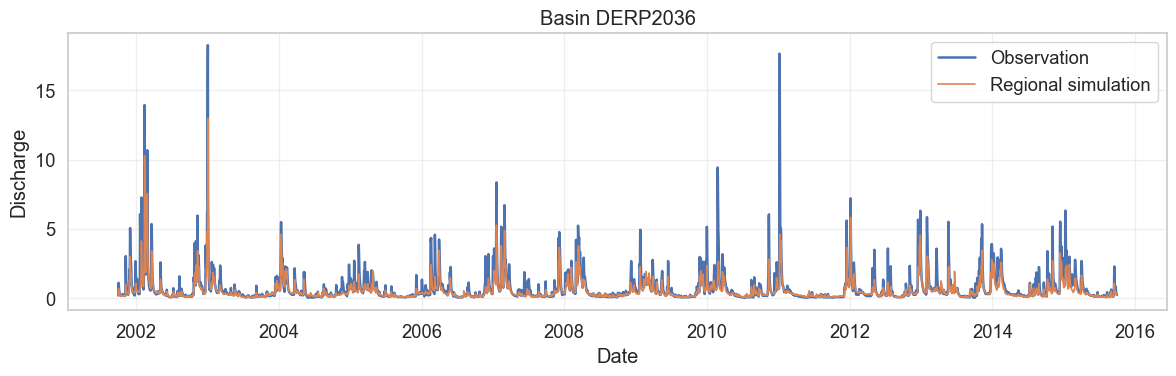

0.7106360197067261


In [740]:
df = basin_timeseries_df(
    ds,
    basin_id="DERP2036",
    start="2001-01-01",
    end="2015-12-31",
)

plot_timeseries(
    ds,
    basin_id="DERP2036",
    start="2001-01-01",
    end="2015-12-31",
)
print(compute_nse(df.obs, df.sim, expo=1))

In [ ]:
df_sig = basin_timeseries_df(
    ds,
    basin_id="DERP2033",
    start=SIG_START,
    end=SIG_END,
)

nse_df = compute_nse(df_sig.obs.values, df_sig.sim.values, expo=1)
nse_df

0.8271479606628418

In [695]:
compute_nse(df.obs, df.sim, expo=1)

0.8271479606628418

In [485]:
df_seed_metrics_and_signatures

,NSE,KGE,bfi_obs,bfi_sim,hfd_obs,hfd_sim,slope_obs,slope_sim,qmean_obs,qmean_sim
basin_id,,,,,,,,,,
DERP2005,0.747557,0.631121,0.446366,0.531250,123.076923,124.846154,3.762767,3.240430,1.080588,0.834222
DERP2006,0.776796,0.707423,0.440146,0.492665,121.230769,123.076923,3.796252,3.257715,1.416212,1.179943
DERP2007,0.784713,0.641077,0.498234,0.560791,126.461538,128.000000,2.828146,2.527217,1.074993,0.851712
DERP2008,0.723418,0.613024,0.473465,0.557048,121.923077,125.923077,3.486582,2.705579,0.964844,0.773069
DERP2010,0.761919,0.703639,0.574114,0.675443,133.000000,136.923077,1.981595,1.625394,0.905834,0.839271
DERP2011,0.800979,0.713536,0.558243,0.668784,131.076923,136.769231,1.954964,1.533157,0.767888,0.745337
DERP2013,0.637653,0.726163,0.815621,0.849111,161.846154,160.769231,0.931772,0.606774,0.677523,0.822726
DERP2017,0.857811,0.868379,0.625862,0.632463,134.846154,132.615385,2.678084,2.492056,1.222016,1.119393
DERP2018,0.886020,0.835166,0.583362,0.633829,134.076923,134.384615,2.708539,2.821260,0.973843,0.899349


In [691]:
df_seed_metrics_and_signatures

,NSE,KGE,bfi_obs,bfi_sim,hfd_obs,hfd_sim,slope_obs,slope_sim,qmean_obs,qmean_sim
basin_id,,,,,,,,,,
DERP2005,0.746685,0.651427,0.446366,0.520332,123.076923,126.000000,3.762767,3.182752,1.080588,0.838242
DERP2006,0.753616,0.634109,0.440146,0.502926,121.230769,126.153846,3.796252,3.149219,1.416212,1.100160
DERP2007,0.776588,0.607807,0.498234,0.581583,126.461538,130.461538,2.828146,2.400644,1.074993,0.844751
DERP2008,0.716136,0.607938,0.473465,0.533966,121.923077,127.538462,3.486582,2.701300,0.964844,0.747735
DERP2010,0.756684,0.669506,0.574114,0.673324,133.000000,137.230769,1.981595,1.425972,0.905834,0.798632
DERP2011,0.805480,0.700705,0.558243,0.670483,131.076923,138.307692,1.954964,1.468473,0.767888,0.730952
DERP2013,0.640304,0.701034,0.815621,0.859069,161.846154,162.076923,0.931772,0.498695,0.677523,0.827247
DERP2017,0.855101,0.846378,0.625862,0.653996,134.846154,136.384615,2.678084,2.406283,1.222016,1.134906
DERP2018,0.869199,0.776267,0.583362,0.652045,134.076923,136.923077,2.708539,2.453381,0.973843,0.870554


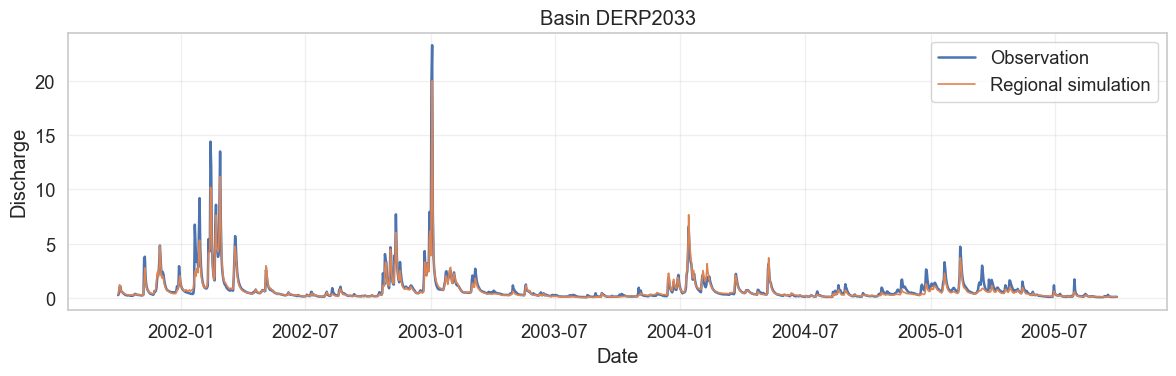

In [486]:
df_seed_metrics_and_signatures

,NSE,KGE,bfi_obs,bfi_sim,hfd_obs,hfd_sim,slope_obs,slope_sim,qmean_obs,qmean_sim
basin_id,,,,,,,,,,
DERP2005,0.747557,0.631121,0.446366,0.531250,123.076923,124.846154,3.762767,3.240430,1.080588,0.834222
DERP2006,0.776796,0.707423,0.440146,0.492665,121.230769,123.076923,3.796252,3.257715,1.416212,1.179943
DERP2007,0.784713,0.641077,0.498234,0.560791,126.461538,128.000000,2.828146,2.527217,1.074993,0.851712
DERP2008,0.723418,0.613024,0.473465,0.557048,121.923077,125.923077,3.486582,2.705579,0.964844,0.773069
DERP2010,0.761919,0.703639,0.574114,0.675443,133.000000,136.923077,1.981595,1.625394,0.905834,0.839271
DERP2011,0.800979,0.713536,0.558243,0.668784,131.076923,136.769231,1.954964,1.533157,0.767888,0.745337
DERP2013,0.637653,0.726163,0.815621,0.849111,161.846154,160.769231,0.931772,0.606774,0.677523,0.822726
DERP2017,0.857811,0.868379,0.625862,0.632463,134.846154,132.615385,2.678084,2.492056,1.222016,1.119393
DERP2018,0.886020,0.835166,0.583362,0.633829,134.076923,134.384615,2.708539,2.821260,0.973843,0.899349


In [509]:
df_seed_metrics_and_signatures

,NSE,KGE,bfi_obs,bfi_sim,hfd_obs,hfd_sim,slope_obs,slope_sim,qmean_obs,qmean_sim
basin_id,,,,,,,,,,
DERP2005,0.747557,0.631121,0.446366,0.531250,123.076923,124.846154,3.762767,3.240430,1.080588,0.834222
DERP2006,0.776796,0.707423,0.440146,0.492665,121.230769,123.076923,3.796252,3.257715,1.416212,1.179943
DERP2007,0.784713,0.641077,0.498234,0.560791,126.461538,128.000000,2.828146,2.527217,1.074993,0.851712
DERP2008,0.723418,0.613024,0.473465,0.557048,121.923077,125.923077,3.486582,2.705579,0.964844,0.773069
DERP2010,0.761919,0.703639,0.574114,0.675443,133.000000,136.923077,1.981595,1.625394,0.905834,0.839271
DERP2011,0.800979,0.713536,0.558243,0.668784,131.076923,136.769231,1.954964,1.533157,0.767888,0.745337
DERP2013,0.637653,0.726163,0.815621,0.849111,161.846154,160.769231,0.931772,0.606774,0.677523,0.822726
DERP2017,0.857811,0.868379,0.625862,0.632463,134.846154,132.615385,2.678084,2.492056,1.222016,1.119393
DERP2018,0.886020,0.835166,0.583362,0.633829,134.076923,134.384615,2.708539,2.821260,0.973843,0.899349


In [508]:
df_metrics_and_signatures

,NSE_lstm,KGE_lstm,NSE_hbv,KGE_hbv,bfi_obs,bfi_lstm,bfi_hbv,hfd_obs,hfd_lstm,hfd_hbv,slope_obs,slope_lstm,slope_hbv,qmean_obs,qmean_lstm,qmean_hbv
basin_id,,,,,,,,,,,,,,,,
DEB10130,0.773258,0.755627,0.673537,0.808375,0.815618,0.861286,0.849576,161.846154,165.692308,167.846154,0.931772,0.638075,0.845974,0.678210,0.794565,0.753409
DEB10340,0.914429,0.872219,0.863366,0.838175,0.466658,0.543620,0.476221,130.153846,131.923077,129.923077,3.492968,2.673907,3.163043,0.709773,0.708054,0.738183
DEB10900,0.863517,0.742275,0.761490,0.679681,0.446361,0.512913,0.469600,123.076923,125.230769,118.307692,3.762767,3.104558,3.675826,1.082247,0.917633,0.847428
DEB10910,0.856918,0.685117,0.762683,0.732293,0.439976,0.478172,0.491285,121.230769,122.923077,126.000000,3.648402,3.362612,2.813519,1.430583,1.123399,1.293489
DEB10940,0.840432,0.641799,0.784728,0.655410,0.498208,0.558440,0.633380,126.461538,129.307692,130.846154,2.862005,2.755667,1.485474,1.074739,0.847113,0.928117
DEB10950,0.818772,0.659826,0.733318,0.645252,0.473617,0.481811,0.534007,121.923077,121.615385,121.769231,3.447979,3.718878,2.998221,0.961400,0.736088,0.824843
DEB10970,0.892492,0.815111,0.779993,0.751681,0.573982,0.608946,0.603998,133.076923,137.307692,144.846154,1.981595,1.822970,1.931111,0.908467,0.858445,0.878783
DEB10980,0.901377,0.786033,0.810827,0.744425,0.558289,0.617852,0.636968,131.076923,135.769231,136.153846,1.954963,2.193693,1.843175,0.769578,0.729296,0.798201
DEB11010,0.899306,0.898982,0.842688,0.898910,0.626141,0.640879,0.633918,134.769231,136.230769,131.538462,2.703024,2.550204,2.355243,1.226270,1.180808,1.220119


In [505]:
df_metrics_and_signatures.describe()

,NSE_lstm,KGE_lstm,NSE_hbv,KGE_hbv,bfi_obs,bfi_lstm,bfi_hbv,hfd_obs,hfd_lstm,hfd_hbv,slope_obs,slope_lstm,slope_hbv,qmean_obs,qmean_lstm,qmean_hbv
count,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000
mean,0.878109,0.796404,0.796856,0.781507,0.559014,0.598989,0.583162,132.860577,134.663462,134.091346,2.609873,2.490069,2.418110,0.948340,0.882632,0.903174
std,0.042016,0.089368,0.052731,0.079255,0.091058,0.090617,0.093714,9.475442,9.966566,11.154331,0.755559,0.709012,0.712292,0.206180,0.153279,0.171173
min,0.773258,0.641799,0.673537,0.645252,0.439976,0.478172,0.469600,121.230769,121.615385,118.307692,0.931772,0.638075,0.845974,0.678210,0.707694,0.684354
25%,0.861867,0.737114,0.762384,0.741392,0.492060,0.549944,0.523326,129.173077,130.288462,129.134615,2.070733,2.162768,1.990265,0.767020,0.734390,0.787003
50%,0.886489,0.800572,0.801501,0.779285,0.570401,0.601271,0.581235,132.192308,135.076923,132.769231,2.702418,2.584174,2.410614,0.968049,0.856293,0.863106
75%,0.904640,0.867526,0.837172,0.837813,0.596515,0.627967,0.630484,134.769231,136.903846,136.923077,3.008498,2.797872,2.859695,1.065473,0.969460,0.973455
max,0.928655,0.927112,0.872537,0.909854,0.815618,0.861286,0.849576,161.846154,165.692308,167.846154,3.762767,3.718878,3.675826,1.430583,1.180808,1.293489


In [506]:
df_seed_metrics_and_signatures.describe()

,NSE,KGE,bfi_obs,bfi_sim,hfd_obs,hfd_sim,slope_obs,slope_sim,qmean_obs,qmean_sim
count,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000
mean,0.793356,0.732878,0.559018,0.620252,132.860577,134.125000,2.622836,2.268689,0.946392,0.844602
std,0.068167,0.095672,0.091021,0.081998,9.476399,8.471829,0.769685,0.714872,0.203778,0.161623
min,0.637653,0.577742,0.440146,0.492665,121.230769,123.076923,0.931772,0.606774,0.677523,0.524933
25%,0.750068,0.687998,0.492042,0.559855,129.173077,130.423077,2.073547,1.716882,0.765782,0.766136
50%,0.786164,0.724668,0.570509,0.633146,132.153846,134.500000,2.693311,2.509637,0.969344,0.836746
75%,0.849145,0.783959,0.596518,0.652119,134.788462,136.423077,2.992755,2.719969,1.063192,0.911433
max,0.886020,0.932236,0.815621,0.849111,161.846154,160.769231,3.796252,3.257715,1.416212,1.179943


In [490]:
df_metrics_and_signatures.describe()

,NSE_lstm,KGE_lstm,NSE_hbv,KGE_hbv,bfi_obs,bfi_lstm,bfi_hbv,hfd_obs,hfd_lstm,hfd_hbv,slope_obs,slope_lstm,slope_hbv,qmean_obs,qmean_lstm,qmean_hbv
count,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000
mean,0.910888,0.839808,0.840049,0.833418,0.562374,0.593446,0.579115,124.729167,125.166667,127.750000,2.495764,2.626160,2.480959,0.975998,0.944586,1.000333
std,0.035819,0.057070,0.058223,0.055875,0.091693,0.089610,0.093098,8.648887,10.271139,10.093269,0.788332,0.741073,0.739886,0.198569,0.181528,0.226275
min,0.835367,0.724381,0.734747,0.738516,0.441753,0.481512,0.468662,114.333333,113.666667,118.000000,0.773778,0.638075,0.965011,0.722457,0.711417,0.760322
25%,0.889832,0.811855,0.794056,0.793547,0.499283,0.541187,0.513934,120.333333,120.166667,121.250000,1.958305,2.270540,2.079689,0.814437,0.803664,0.833364
50%,0.916679,0.832932,0.855280,0.841802,0.579749,0.590523,0.585210,123.833333,123.000000,124.000000,2.690372,2.694704,2.549561,0.972156,0.934422,0.942745
75%,0.940056,0.872592,0.878509,0.868134,0.587945,0.624725,0.628832,125.166667,126.583333,130.666667,2.815167,2.875483,2.897589,1.074568,1.012772,1.091463
max,0.960303,0.937298,0.922789,0.923746,0.825523,0.859103,0.844286,152.000000,157.666667,158.000000,3.832113,3.843974,4.200892,1.474606,1.319979,1.570151


In [491]:
df_metrics_and_signatures

,NSE_lstm,KGE_lstm,NSE_hbv,KGE_hbv,bfi_obs,bfi_lstm,bfi_hbv,hfd_obs,hfd_lstm,hfd_hbv,slope_obs,slope_lstm,slope_hbv,qmean_obs,qmean_lstm,qmean_hbv
basin_id,,,,,,,,,,,,,,,,
DEB10130,0.868938,0.803746,0.787528,0.883045,0.825523,0.859103,0.844286,152.000000,157.666667,158.000000,0.773778,0.638075,0.965011,0.746414,0.803915,0.760322
DEB10340,0.936365,0.872293,0.875587,0.819804,0.458994,0.541745,0.481878,117.666667,123.000000,122.333333,3.220891,2.802875,2.929827,0.722457,0.711417,0.761294
DEB10900,0.919011,0.832592,0.834323,0.819509,0.457812,0.515174,0.468662,120.333333,119.666667,121.000000,3.832113,3.403042,4.200892,1.056757,0.968138,0.924292
DEB10910,0.894296,0.823152,0.754040,0.852647,0.441753,0.481512,0.482532,114.333333,114.333333,118.333333,3.692641,3.600680,2.886844,1.474606,1.319979,1.570151
DEB10940,0.893315,0.724381,0.850111,0.771888,0.506526,0.546268,0.606724,120.333333,119.000000,121.333333,2.792974,2.972210,1.583399,1.147987,0.961417,1.072930
DEB10950,0.835367,0.747280,0.773630,0.752155,0.477553,0.486041,0.527265,117.333333,113.666667,118.000000,2.755668,3.843974,3.036824,0.958193,0.806427,0.910034
DEB10970,0.894733,0.808425,0.804038,0.839166,0.582088,0.603661,0.588899,123.333333,126.333333,136.333333,2.100446,1.914479,2.100446,0.992535,0.930513,1.022991
DEB10980,0.926470,0.833271,0.860449,0.772878,0.571602,0.612856,0.637778,121.333333,123.666667,128.000000,1.760696,2.414982,1.795466,0.794305,0.787892,0.891588
DEB11010,0.960303,0.926329,0.915261,0.880248,0.617668,0.630695,0.636038,124.333333,123.000000,123.000000,2.750172,2.627577,2.498434,1.205299,1.284620,1.341608


In [647]:
df_seed_metrics_and_signatures

,NSE,KGE,bfi_obs,bfi_sim,hfd_obs,hfd_sim,slope_obs,slope_sim,qmean_obs,qmean_sim
basin_id,,,,,,,,,,
DERP2005,0.746685,0.651427,0.446366,0.520332,123.076923,126.000000,3.762767,3.182752,1.080588,0.838242
DERP2006,0.753616,0.634109,0.440146,0.502926,121.230769,126.153846,3.796252,3.149219,1.416212,1.100160
DERP2007,0.776588,0.607807,0.498234,0.581583,126.461538,130.461538,2.828146,2.400644,1.074993,0.844751
DERP2008,0.716136,0.607938,0.473465,0.533966,121.923077,127.538462,3.486582,2.701300,0.964844,0.747735
DERP2010,0.756684,0.669506,0.574114,0.673324,133.000000,137.230769,1.981595,1.425972,0.905834,0.798632
DERP2011,0.805480,0.700705,0.558243,0.670483,131.076923,138.307692,1.954964,1.468473,0.767888,0.730952
DERP2013,0.640304,0.701034,0.815621,0.859069,161.846154,162.076923,0.931772,0.498695,0.677523,0.827247
DERP2017,0.855101,0.846378,0.625862,0.653996,134.846154,136.384615,2.678084,2.406283,1.222016,1.134906
DERP2018,0.869199,0.776267,0.583362,0.652045,134.076923,136.923077,2.708539,2.453381,0.973843,0.870554


In [650]:
data_diff_timeval_complete_dict_plot.loc[exact_matches.estreams_id.tolist()].describe()

,nse_nogeo,nse_ran,nse_g1comp,nse_c1comp,nse_r1comp,kge_nogeo,kge_ran,kge_g1comp,kge_c1comp,kge_r1comp,...,slope_c1comp,slope_g1comp,slope_nogeo,slope_ran,qmean_obs,qmean_r1comp,qmean_c1comp,qmean_g1comp,qmean_nogeo,qmean_ran
count,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,...,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000
mean,0.800599,0.796069,0.793245,0.784624,0.779142,0.712632,0.717761,0.709021,0.691288,0.684825,...,2.232791,2.240614,2.180610,2.213953,0.946392,0.807486,0.808831,0.812374,0.818682,0.823823
std,0.066530,0.071047,0.063413,0.064633,0.066438,0.093265,0.095724,0.090381,0.086075,0.080991,...,0.769987,0.713329,0.689973,0.729768,0.203778,0.157013,0.164348,0.161260,0.156179,0.163123
min,0.675041,0.629455,0.678560,0.661702,0.630111,0.573076,0.568915,0.561991,0.567047,0.543583,...,0.472823,0.486810,0.479410,0.518876,0.677523,0.528566,0.530064,0.527561,0.540625,0.533682
25%,0.759626,0.756873,0.752015,0.741238,0.740550,0.648789,0.653475,0.650402,0.629724,0.636415,...,1.666924,1.792321,1.708095,1.763239,0.765782,0.721317,0.704850,0.712643,0.722011,0.719690
50%,0.787565,0.790223,0.787202,0.781259,0.776944,0.711943,0.718524,0.706606,0.675398,0.683567,...,2.392464,2.534381,2.453792,2.380401,0.969344,0.815533,0.803369,0.811213,0.812997,0.828202
75%,0.860418,0.861520,0.848553,0.838681,0.831465,0.753873,0.758511,0.749104,0.724155,0.707537,...,2.773108,2.714357,2.603453,2.554843,1.063192,0.856285,0.864368,0.874992,0.889652,0.887008
max,0.898441,0.896161,0.891918,0.886177,0.879988,0.894840,0.909496,0.881633,0.865398,0.851938,...,3.365488,3.198022,3.190540,3.478586,1.416212,1.121371,1.152881,1.130648,1.118072,1.134743


In [633]:
data_diff_timeval_complete_dict_plot.loc[exact_matches.estreams_id.tolist()][["nse_r1comp", "kge_r1comp"]]

,nse_r1comp,kge_r1comp
DERP2013,0.630111,0.679145
DERP2036,0.725862,0.543583
DERP2005,0.741902,0.629080
DERP2006,0.748110,0.638860
DERP2007,0.775207,0.608307
DERP2008,0.704388,0.581768
DERP2010,0.750580,0.656926
DERP2011,0.794404,0.687988
DERP2017,0.847233,0.823119
DERP2018,0.858639,0.753934


In [492]:
df_metrics_and_signatures

,NSE_lstm,KGE_lstm,NSE_hbv,KGE_hbv,bfi_obs,bfi_lstm,bfi_hbv,hfd_obs,hfd_lstm,hfd_hbv,slope_obs,slope_lstm,slope_hbv,qmean_obs,qmean_lstm,qmean_hbv
basin_id,,,,,,,,,,,,,,,,
DEB10130,0.868938,0.803746,0.787528,0.883045,0.825523,0.859103,0.844286,152.000000,157.666667,158.000000,0.773778,0.638075,0.965011,0.746414,0.803915,0.760322
DEB10340,0.936365,0.872293,0.875587,0.819804,0.458994,0.541745,0.481878,117.666667,123.000000,122.333333,3.220891,2.802875,2.929827,0.722457,0.711417,0.761294
DEB10900,0.919011,0.832592,0.834323,0.819509,0.457812,0.515174,0.468662,120.333333,119.666667,121.000000,3.832113,3.403042,4.200892,1.056757,0.968138,0.924292
DEB10910,0.894296,0.823152,0.754040,0.852647,0.441753,0.481512,0.482532,114.333333,114.333333,118.333333,3.692641,3.600680,2.886844,1.474606,1.319979,1.570151
DEB10940,0.893315,0.724381,0.850111,0.771888,0.506526,0.546268,0.606724,120.333333,119.000000,121.333333,2.792974,2.972210,1.583399,1.147987,0.961417,1.072930
DEB10950,0.835367,0.747280,0.773630,0.752155,0.477553,0.486041,0.527265,117.333333,113.666667,118.000000,2.755668,3.843974,3.036824,0.958193,0.806427,0.910034
DEB10970,0.894733,0.808425,0.804038,0.839166,0.582088,0.603661,0.588899,123.333333,126.333333,136.333333,2.100446,1.914479,2.100446,0.992535,0.930513,1.022991
DEB10980,0.926470,0.833271,0.860449,0.772878,0.571602,0.612856,0.637778,121.333333,123.666667,128.000000,1.760696,2.414982,1.795466,0.794305,0.787892,0.891588
DEB11010,0.960303,0.926329,0.915261,0.880248,0.617668,0.630695,0.636038,124.333333,123.000000,123.000000,2.750172,2.627577,2.498434,1.205299,1.284620,1.341608


In [634]:
df_seed_metrics_and_signatures

,NSE,KGE,bfi_obs,bfi_sim,hfd_obs,hfd_sim,slope_obs,slope_sim,qmean_obs,qmean_sim
basin_id,,,,,,,,,,
DERP2005,0.741902,0.629080,0.446366,0.510062,123.076923,125.692308,3.762767,3.345059,1.080588,0.811757
DERP2006,0.748110,0.638860,0.440146,0.519702,121.230769,126.076923,3.796252,2.954273,1.416212,1.121371
DERP2007,0.775207,0.608307,0.498234,0.573499,126.461538,129.692308,2.828146,2.373622,1.074993,0.833573
DERP2008,0.704388,0.581768,0.473465,0.531190,121.923077,127.769231,3.486582,2.664826,0.964844,0.724699
DERP2010,0.750580,0.656926,0.574114,0.674323,133.000000,137.692308,1.981595,1.460046,0.905834,0.784359
DERP2011,0.794404,0.687988,0.558243,0.667924,131.076923,137.923077,1.954964,1.518163,0.767888,0.711170
DERP2013,0.630111,0.679145,0.815621,0.863340,161.846154,163.076923,0.931772,0.489210,0.677523,0.819310
DERP2017,0.847233,0.823119,0.625862,0.648016,134.846154,136.230769,2.678084,2.334784,1.222016,1.103406
DERP2018,0.858639,0.753934,0.583362,0.641156,134.076923,136.384615,2.708539,2.498057,0.973843,0.843564


In [635]:
df_metrics_and_signatures

,NSE_lstm,KGE_lstm,NSE_hbv,KGE_hbv,bfi_obs,bfi_lstm,bfi_hbv,hfd_obs,hfd_lstm,hfd_hbv,slope_obs,slope_lstm,slope_hbv,qmean_obs,qmean_lstm,qmean_hbv
basin_id,,,,,,,,,,,,,,,,
DEB10130,0.772249,0.755404,0.672616,0.808008,0.815621,0.861286,0.849576,161.846154,165.692308,167.846154,0.931772,0.638075,0.845974,0.677523,0.794565,0.753409
DEB10340,0.914734,0.874006,0.863557,0.839217,0.466863,0.543620,0.476221,130.153846,131.923077,129.923077,3.492967,2.673907,3.163043,0.708328,0.708054,0.738183
DEB10900,0.864061,0.743901,0.761965,0.681206,0.446366,0.512913,0.469600,123.076923,125.230769,118.307692,3.762767,3.104558,3.675826,1.080588,0.917633,0.847428
DEB10910,0.861057,0.696252,0.764915,0.742073,0.440146,0.478172,0.491285,121.230769,122.923077,126.000000,3.796252,3.362612,2.813519,1.416212,1.123399,1.293489
DEB10940,0.840351,0.641590,0.784670,0.655224,0.498234,0.558440,0.633380,126.461538,129.307692,130.846154,2.828146,2.755667,1.485474,1.074993,0.847113,0.928117
DEB10950,0.817335,0.655990,0.732070,0.641842,0.473465,0.481811,0.534007,121.923077,121.615385,121.769231,3.486582,3.718878,2.998221,0.964844,0.736088,0.824843
DEB10970,0.893220,0.818179,0.780517,0.754065,0.574114,0.608946,0.603998,133.000000,137.307692,144.846154,1.981595,1.822970,1.931111,0.905834,0.858445,0.878783
DEB10980,0.902080,0.788136,0.811273,0.745580,0.558243,0.617852,0.636968,131.076923,135.769231,136.153846,1.954964,2.193693,1.843175,0.767888,0.729296,0.798201
DEB11010,0.899664,0.902444,0.842581,0.900734,0.625862,0.640879,0.633918,134.846154,136.230769,131.538462,2.678084,2.550204,2.355243,1.222016,1.180808,1.220119


In [247]:
df_metrics_and_signatures

,NSE_lstm,KGE_lstm,NSE_hbv,KGE_hbv,bfi_obs,bfi_lstm,bfi_hbv,hfd_obs,hfd_lstm,hfd_hbv,slope_obs,slope_lstm,slope_hbv,qmean_obs,qmean_lstm,qmean_hbv
basin_id,,,,,,,,,,,,,,,,
DEB10130,0.689185,0.736200,0.577875,0.772595,0.818652,0.867098,0.857723,164.454545,168.636364,171.818182,0.918746,0.560371,0.778925,0.638321,0.772108,0.722343
DEB10340,0.900442,0.871933,0.847735,0.838082,0.478156,0.554747,0.484661,133.000000,134.909091,132.454545,3.492968,2.673907,3.044192,0.679128,0.685350,0.711040
DEB10900,0.841323,0.706702,0.725953,0.610691,0.449680,0.521042,0.480502,124.818182,127.363636,119.363636,3.762767,3.025845,3.634597,1.058245,0.874880,0.790735
DEB10910,0.835392,0.626713,0.756759,0.625956,0.443083,0.486817,0.506143,123.636364,125.636364,128.454545,3.648402,3.398002,2.739304,1.392268,1.047520,1.192932
DEB10940,0.809535,0.598276,0.743332,0.582510,0.504481,0.572073,0.658249,128.727273,132.181818,133.909091,2.881746,2.670301,1.369652,1.022487,0.784522,0.856861
DEB10950,0.812645,0.622604,0.713046,0.590061,0.482548,0.488987,0.548781,123.363636,123.090909,123.272727,3.486582,3.612540,2.816776,0.926112,0.680413,0.768072
DEB10970,0.892954,0.825996,0.759311,0.680222,0.577399,0.619574,0.621022,135.818182,141.454545,149.818182,1.975036,1.781172,1.923185,0.855508,0.818590,0.810979
DEB10980,0.887958,0.765350,0.777313,0.706730,0.563850,0.629774,0.647907,133.909091,139.454545,139.363636,2.049515,2.196654,1.836775,0.727746,0.687725,0.748665
DEB11010,0.871893,0.848305,0.805074,0.855195,0.636240,0.652677,0.643046,138.181818,139.909091,134.545455,2.627577,2.443866,2.281028,1.179085,1.113546,1.149450


In [345]:
df_seed_metrics_and_signatures

,NSE,KGE,bfi_obs,bfi_sim,hfd_obs,hfd_sim,slope_obs,slope_sim,qmean_obs,qmean_sim
basin_id,,,,,,,,,,
DERP2005,0.809075,0.593560,0.446366,0.511828,123.076923,126.076923,3.762767,3.410101,1.080588,0.787949
DERP2006,0.840208,0.659015,0.440146,0.494179,121.230769,123.538462,3.796252,3.180885,1.416212,1.118559
DERP2007,0.850053,0.613940,0.498234,0.577461,126.461538,128.769231,2.828146,2.448308,1.074993,0.843178
DERP2008,0.820136,0.582881,0.473465,0.533681,121.923077,127.230769,3.486582,2.790845,0.964844,0.734072
DERP2010,0.856514,0.704093,0.574114,0.659025,133.000000,138.461538,1.981595,1.646700,0.905834,0.823284
DERP2011,0.868366,0.716608,0.558243,0.656398,131.076923,137.461538,1.954964,1.711798,0.767888,0.738702
DERP2013,0.486360,0.686698,0.815621,0.861818,161.846154,163.538462,0.931772,0.463404,0.677523,0.818611
DERP2017,0.897640,0.838977,0.625862,0.623872,134.846154,134.076923,2.678084,2.511387,1.222016,1.081224
DERP2018,0.917598,0.796644,0.583362,0.630836,134.076923,134.769231,2.708539,2.569787,0.973843,0.864819


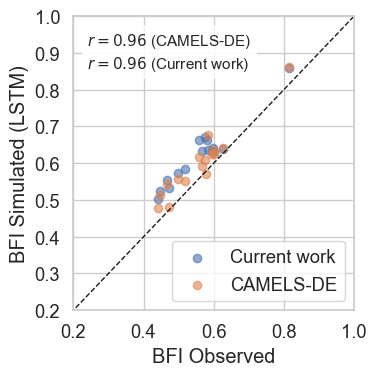

In [504]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

df = df_metrics_and_signatures
df2 = data_diff_timeval_complete_dict_plot.loc[
    exact_matches.estreams_id.tolist()
]

# ------------------------------------------------------------
# Extract data and drop NaNs (CRITICAL)
# ------------------------------------------------------------

x1 = df["bfi_obs"]
y1 = df["bfi_lstm"]
mask1 = (~x1.isna()) & (~y1.isna())
x1, y1 = x1[mask1], y1[mask1]

x2 = df2["bfi_obs"]
y2 = df2["bfi_r1comp"]
mask2 = (~x2.isna()) & (~y2.isna())
x2, y2 = x2[mask2], y2[mask2]

x3 = df2["bfi_obs"]
y3 = df2["bfi_nogeo"]
mask3 = (~x3.isna()) & (~y3.isna())
x3, y3 = x3[mask3], y3[mask3]

# Pearson correlations
r1, p1 = pearsonr(x1, y1)
r2, p2 = pearsonr(x2, y2)
r3, p3 = pearsonr(x3, y3)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

plt.figure(figsize=(4, 4))
plt.scatter(x2, y2, alpha=0.6)
plt.scatter(x1, y1, alpha=0.6)
#plt.scatter(x3, y3, alpha=0.6)

# 1:1 line
lims = [0, 1]
plt.plot(lims, lims, "k--", linewidth=1)

plt.xlabel("BFI Observed")
plt.ylabel("BFI Simulated (LSTM)")
plt.xlim(0.2, 1)
plt.ylim(0.2, 1)
plt.grid(True)

# ------------------------------------------------------------
# Add Pearson r annotations
# ------------------------------------------------------------

plt.text(
    0.05, 0.95,
    rf"$r = {r1:.2f}$ (CAMELS-DE)",
    transform=plt.gca().transAxes,
    ha="left", va="top",
    fontsize=11,
    bbox=dict(facecolor="white", edgecolor="none", alpha=0.7)
)

plt.text(
    0.05, 0.87,
    rf"$r = {r2:.2f}$ (Current work)",
    transform=plt.gca().transAxes,
    ha="left", va="top",
    fontsize=11,
    bbox=dict(facecolor="white", edgecolor="none", alpha=0.7)
)

plt.legend(["Current work", "CAMELS-DE"])
plt.tight_layout()
plt.savefig("../results/figs/figures/SX_comparisonCAMELS.png", dpi=300)
# plt.show()


In [494]:
data_diff_val_complete_dict_plot_nse.describe()

,nse_nogeo,nse_ran,nse_g1comp,nse_c1comp,nse_r1comp,kge_nogeo,kge_ran,kge_g1comp,kge_c1comp,kge_r1comp,...,slope_c1comp,slope_g1comp,slope_nogeo,slope_ran,qmean_obs,qmean_r1comp,qmean_c1comp,qmean_g1comp,qmean_nogeo,qmean_ran
count,130.000000,130.000000,130.000000,130.000000,130.000000,130.000000,130.000000,130.000000,130.000000,130.000000,...,124.000000,124.000000,124.000000,124.000000,130.000000,130.000000,130.000000,130.000000,130.000000,130.000000
mean,0.701148,0.702314,0.682569,0.693119,0.714618,0.632917,0.633455,0.625419,0.641115,0.660204,...,2.346902,2.282302,2.681072,2.643056,1.097993,0.993277,0.982460,0.970804,0.976053,0.958917
std,0.203131,0.213865,0.311369,0.398628,0.259607,0.167555,0.157196,0.178849,0.168671,0.153624,...,1.191962,0.889878,4.279453,4.327611,0.567213,0.555403,0.533969,0.541277,0.545191,0.542277
min,-0.422664,-0.798170,-2.010504,-3.517215,-1.712207,-0.016561,0.020369,-0.107608,-0.354413,-0.054540,...,0.734685,0.690832,0.994655,1.053290,0.264454,0.181575,0.146222,0.188042,0.117373,0.194840
25%,0.662419,0.667403,0.664224,0.678989,0.688546,0.548924,0.553947,0.549818,0.576363,0.571492,...,1.874028,1.870645,1.804532,1.768710,0.782773,0.656859,0.670301,0.645819,0.657241,0.627968
50%,0.746795,0.748087,0.740927,0.751744,0.760719,0.666852,0.634310,0.654642,0.668867,0.678773,...,2.201279,2.107406,2.099847,2.127353,0.962306,0.820589,0.851755,0.842559,0.825860,0.819690
75%,0.815519,0.813974,0.815831,0.815683,0.829164,0.736227,0.768067,0.746018,0.750381,0.766316,...,2.537435,2.505111,2.473696,2.626224,1.236292,1.127157,1.095467,1.093064,1.091162,1.061482
max,0.909402,0.906553,0.908585,0.904773,0.905084,0.919359,0.911352,0.915162,0.929735,0.908611,...,11.386008,7.669191,46.197067,49.513023,3.618939,3.315327,3.150639,3.209339,3.369995,3.663948


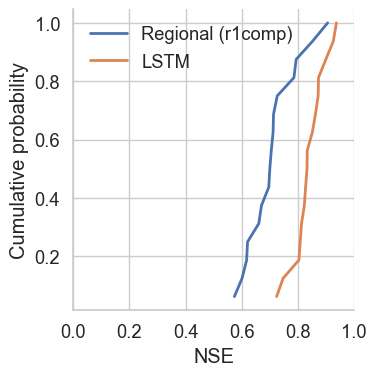

In [495]:
import numpy as np
import matplotlib.pyplot as plt

# Extract data and drop NaNs
nse_r1comp = (
    data_diff_timeval_complete_dict_plot
    .loc[exact_matches.estreams_id.tolist(), "kge_r1comp"]
    .dropna()
    .values
)

nse_lstm = (
    df_metrics_and_signatures["KGE_lstm"]
    .dropna()
    .values
)

# Sort values
nse_r1comp_sorted = np.sort(nse_r1comp)
nse_lstm_sorted = np.sort(nse_lstm)

# Empirical CDF
cdf_r1comp = np.arange(1, len(nse_r1comp_sorted) + 1) / len(nse_r1comp_sorted)
cdf_lstm = np.arange(1, len(nse_lstm_sorted) + 1) / len(nse_lstm_sorted)

# Plot
fig, ax = plt.subplots(figsize=(4, 4))

ax.plot(
    nse_r1comp_sorted,
    cdf_r1comp,
    label="Regional (r1comp)",
    linewidth=2
)

ax.plot(
    nse_lstm_sorted,
    cdf_lstm,
    label="LSTM",
    linewidth=2
)

ax.set_xlabel("NSE")
ax.set_ylabel("Cumulative probability")

ax.legend(frameon=False)
ax.set_xlim(0,1)
# Clean style
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()


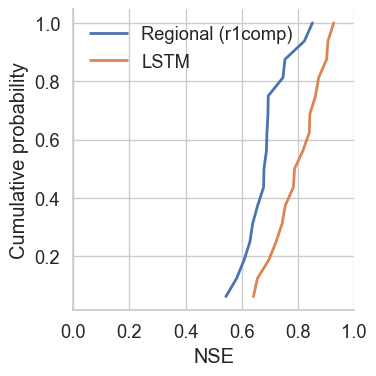

In [639]:
import numpy as np
import matplotlib.pyplot as plt

# Extract data and drop NaNs
nse_r1comp = (
    data_diff_timeval_complete_dict_plot
    .loc[exact_matches.estreams_id.tolist(), "kge_r1comp"]
    .dropna()
    .values
)

nse_lstm = (
    df_metrics_and_signatures["KGE_lstm"]
    .dropna()
    .values
)

# Sort values
nse_r1comp_sorted = np.sort(nse_r1comp)
nse_lstm_sorted = np.sort(nse_lstm)

# Empirical CDF
cdf_r1comp = np.arange(1, len(nse_r1comp_sorted) + 1) / len(nse_r1comp_sorted)
cdf_lstm = np.arange(1, len(nse_lstm_sorted) + 1) / len(nse_lstm_sorted)

# Plot
fig, ax = plt.subplots(figsize=(4, 4))

ax.plot(
    nse_r1comp_sorted,
    cdf_r1comp,
    label="Regional (r1comp)",
    linewidth=2
)

ax.plot(
    nse_lstm_sorted,
    cdf_lstm,
    label="LSTM",
    linewidth=2
)

ax.set_xlabel("NSE")
ax.set_ylabel("Cumulative probability")

ax.legend(frameon=False)
ax.set_xlim(0,1)
# Clean style
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()


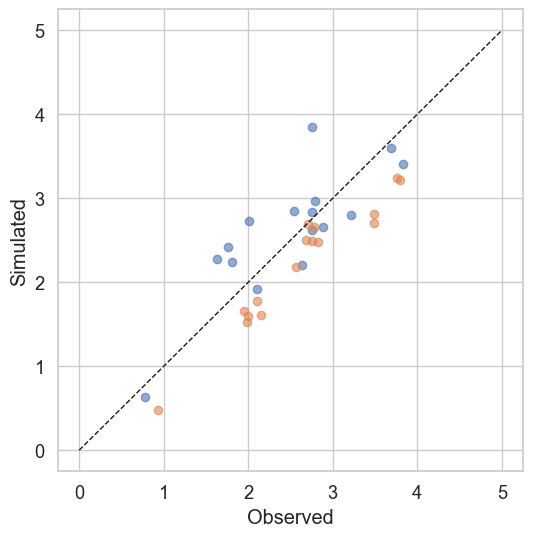

In [496]:
df = df_metrics_and_signatures
df2 = data_diff_timeval_complete_dict_plot.loc[
    exact_matches.estreams_id.tolist()]

plt.figure(figsize=(6, 6))
plt.scatter(df["slope_obs"], df["slope_lstm"], alpha=0.6)
plt.scatter(df2["slope_obs"], df2["slope_r1comp"], alpha=0.6)

# 1:1 line
lims = [0,5]
plt.plot(lims, lims, "k--", linewidth=1)
plt.xlabel("Observed")
plt.ylabel("Simulated")
plt.grid(True)
plt.show()


In [86]:
data_diff_val_complete_dict_plot.loc[exact_matches.estreams_id.tolist()][["nse_nogeo", "nse_r1comp", "bfi_obs", "bfi_r1comp", "bfi_nogeo"]]

,nse_nogeo,nse_r1comp,bfi_obs,bfi_r1comp,bfi_nogeo
DERP2013,0.579722,0.544453,0.815621,0.860716,0.852098
DERP2036,0.801759,0.835257,0.466863,0.571751,0.613097
DERP2005,0.799174,0.796452,0.446366,0.510476,0.519360
DERP2006,0.821049,0.821781,0.440146,0.485001,0.499168
DERP2007,0.827341,0.824661,0.498234,0.568604,0.583552
DERP2008,0.775513,0.821603,0.473465,0.525055,0.521355
DERP2010,0.842391,0.859205,0.574114,0.656742,0.645232
DERP2011,0.863369,0.871503,0.558243,0.650300,0.646389
DERP2017,0.900380,0.893593,0.625862,0.638772,0.624692
DERP2018,0.908871,0.926198,0.583362,0.635943,0.646819


In [91]:
df_metrics_and_signatures[["NSE_lstm", "bfi_obs", "bfi_lstm"]]

,NSE_lstm,bfi_obs,bfi_lstm
basin_id,,,
DEB10130,0.751104,0.815618,0.861286
DEB10340,0.902305,0.466658,0.543620
DEB10900,0.891866,0.446361,0.512913
DEB10910,0.896680,0.439976,0.478172
DEB10940,0.891963,0.498208,0.558440
DEB10950,0.870942,0.473617,0.481817
DEB10970,0.925893,0.573982,0.608946
DEB10980,0.910317,0.558289,0.617852
DEB11010,0.937411,0.626141,0.640879


In [141]:
data_diff_val_complete_dict_plot_garonne = data_diff_val_complete_dict_plot.loc[is_garonne, :]
data_diff_val_complete_dict_plot_moselle = data_diff_val_complete_dict_plot.loc[is_moselle, :]



In [394]:
data_diff_val_complete_dict_plot_garonne

,nse_nogeo,nse_ran,nse_g1comp,nse_c1comp,nse_r1comp,kge_nogeo,kge_ran,kge_g1comp,kge_c1comp,kge_r1comp,...,slope_c1comp,slope_g1comp,slope_nogeo,slope_ran,qmean_obs,qmean_r1comp,qmean_c1comp,qmean_g1comp,qmean_nogeo,qmean_ran
FR004136,0.791797,0.807163,0.657238,0.812207,0.800962,0.833702,0.842162,0.628059,0.859150,0.776798,...,2.684104,2.340512,2.734999,3.153616,2.128744,1.923049,2.077411,2.873023,2.332196,1.967844
FR001547,0.744528,0.829095,0.802128,0.766157,0.786226,0.388884,0.690704,0.573368,0.541564,0.476634,...,3.260429,3.307054,1.896857,4.545642,0.829748,0.577587,0.563852,0.596910,0.578856,0.689708
FR004091,0.498752,0.078659,0.441742,0.591021,0.533380,0.352658,0.071063,0.337805,0.418099,0.375965,...,1.816803,2.299248,1.911117,0.980054,2.520212,1.512781,1.621199,1.430649,1.506093,1.121855
FR001592,0.660035,0.672577,0.649436,0.627409,0.681817,0.218846,0.676603,0.281791,0.168883,0.288811,...,4.892544,1.782664,3.197392,5.935422,0.262104,0.172997,0.136424,0.207094,0.164318,0.254936
FR001577,0.814510,0.824497,0.880036,0.837437,0.874655,0.628535,0.652963,0.755806,0.723154,0.738765,...,2.966282,3.599592,2.774088,2.719373,0.967203,0.984683,1.028054,0.990107,0.959758,0.988819
FR004140,0.800633,0.802957,0.762297,0.738847,0.814761,0.618791,0.766581,0.593938,0.597810,0.654082,...,7.129322,4.913071,8.721498,8.197469,0.476253,0.384923,0.339049,0.362991,0.375685,0.403597
FR004149,0.720816,0.643157,0.709187,0.723942,0.745599,0.676866,0.603184,0.673827,0.651396,0.709635,...,2.696735,2.781379,2.483379,2.305314,0.387913,0.449098,0.439597,0.486085,0.453478,0.520118
FR004152,0.570569,0.455332,0.701349,0.757802,0.706070,0.496417,0.393473,0.581141,0.556632,0.606900,...,2.471988,2.153756,1.538527,1.115842,0.352931,0.413445,0.353026,0.388430,0.433310,0.451860
FR001593,0.692235,0.625901,0.715299,0.630010,0.608680,0.610390,0.675380,0.553044,0.595308,0.512112,...,2.694466,2.232085,1.613524,2.999631,0.293235,0.215031,0.336532,0.289153,0.308049,0.354833
FR001545,0.615607,0.766737,0.708483,0.559253,0.718436,0.431409,0.580653,0.515673,0.381859,0.513653,...,1.663107,1.913997,1.811726,2.077106,2.281194,1.647936,1.394502,1.625200,1.461554,1.715387


In [395]:
data_diff_val_complete_dict_plot_garonne["root_dep_mean"] = network_estreams_garonne_22_gauges["root_dep_mean"]

/var/folders/sd/ytjf58757690_xfckxng56q00000gq/T/ipykernel_43714/4129171625.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_diff_val_complete_dict_plot_garonne["root_dep_mean"] = network_estreams_garonne_22_gauges["root_dep_mean"]


In [397]:
data_diff_val_complete_dict_plot_garonne.corr()

,nse_nogeo,nse_ran,nse_g1comp,nse_c1comp,nse_r1comp,kge_nogeo,kge_ran,kge_g1comp,kge_c1comp,kge_r1comp,...,slope_g1comp,slope_nogeo,slope_ran,qmean_obs,qmean_r1comp,qmean_c1comp,qmean_g1comp,qmean_nogeo,qmean_ran,root_dep_mean
nse_nogeo,1.000000,0.804109,0.787706,0.801757,0.847566,0.679652,0.684581,0.693012,0.661526,0.609237,...,-0.041542,0.241987,0.248723,-0.160237,0.011825,0.038579,0.081421,0.048139,0.050624,0.335241
nse_ran,0.804109,1.000000,0.779432,0.519739,0.806172,0.440156,0.845827,0.476056,0.407862,0.476602,...,-0.244057,0.132495,0.261981,-0.064272,0.100758,0.074254,0.168422,0.117017,0.224454,0.189563
nse_g1comp,0.787706,0.779432,1.000000,0.653411,0.745821,0.485901,0.593414,0.659373,0.524036,0.483079,...,-0.296121,0.002628,-0.028860,-0.176547,-0.048797,-0.092144,-0.092612,-0.091883,-0.005582,0.251798
nse_c1comp,0.801757,0.519739,0.653411,1.000000,0.833932,0.658719,0.431537,0.732307,0.775713,0.677866,...,-0.063350,0.032562,-0.026283,-0.123202,0.080345,0.121750,0.127218,0.117438,0.064920,0.224254
nse_r1comp,0.847566,0.806172,0.745821,0.833932,1.000000,0.591307,0.654691,0.671846,0.644464,0.741482,...,-0.119527,0.169616,0.123647,-0.011413,0.210953,0.212117,0.244914,0.219746,0.256193,0.200249
kge_nogeo,0.679652,0.440156,0.485901,0.658719,0.591307,1.000000,0.581298,0.858509,0.937707,0.894952,...,-0.120680,0.086823,-0.078248,-0.005614,0.206162,0.266004,0.295559,0.278956,0.215263,0.172602
kge_ran,0.684581,0.845827,0.593414,0.431537,0.654691,0.581298,1.000000,0.498648,0.528597,0.585731,...,-0.235959,0.236446,0.412612,-0.146585,0.051142,0.078311,0.187561,0.124158,0.176281,0.305991
kge_g1comp,0.693012,0.476056,0.659373,0.732307,0.671846,0.858509,0.498648,1.000000,0.869566,0.813498,...,0.000688,-0.009192,-0.109366,-0.170973,0.015035,0.026570,0.015333,0.018180,0.010478,0.214551
kge_c1comp,0.661526,0.407862,0.524036,0.775713,0.644464,0.937707,0.528597,0.869566,1.000000,0.889982,...,-0.118580,-0.001326,-0.163861,0.038985,0.253518,0.312492,0.314091,0.308326,0.240612,0.129243
kge_r1comp,0.609237,0.476602,0.483079,0.677866,0.741482,0.894952,0.585731,0.813498,0.889982,1.000000,...,-0.162524,0.071344,-0.121959,0.075854,0.333645,0.391737,0.395978,0.389413,0.359598,0.130212


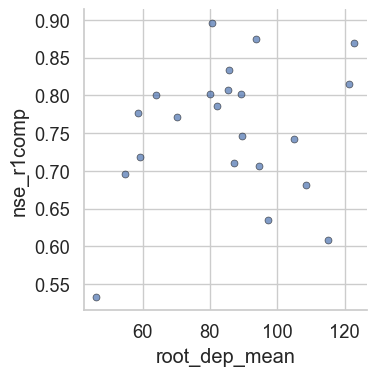

In [398]:
# Example variable names — CHANGE THESE
x_var = "root_dep_mean"
y_var = "nse_r1comp"

fig, ax = plt.subplots(figsize=(4, 4))

ax.scatter(
    data_diff_val_complete_dict_plot_garonne[x_var],
    data_diff_val_complete_dict_plot_garonne[y_var],
    s=25,
    edgecolor="k",
    linewidth=0.5,
    alpha=0.7
)

ax.set_xlabel(x_var)
ax.set_ylabel(y_var)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [402]:
selected_ids = ["FR000144", "FR000185", "FR003250","FR003280"]


In [406]:
data_diff_val_complete_dict_plot_moselle.loc[selected_ids, ["nse_r1comp", "nse_nogeo"]]

,nse_r1comp,nse_nogeo
FR000144,-4.009779,0.003880
FR000185,-1.443874,-0.982576
FR003250,0.255330,0.226463
FR003280,0.050772,0.080444


In [407]:
data_diff_val_complete_dict_plot_moselle[data_diff_val_complete_dict_plot_moselle.nse_r1comp	<0.5
                                         ]

,nse_nogeo,nse_ran,nse_g1comp,nse_c1comp,nse_r1comp,kge_nogeo,kge_ran,kge_g1comp,kge_c1comp,kge_r1comp,...,slope_c1comp,slope_g1comp,slope_nogeo,slope_ran,qmean_obs,qmean_r1comp,qmean_c1comp,qmean_g1comp,qmean_nogeo,qmean_ran
LU000010,0.139887,0.662677,-3.348094,0.058807,-0.087053,0.278436,0.450072,-1.356982,0.278591,0.172998,...,1.205862,2.332592,1.847120,1.812269,0.888896,1.607327,1.491281,2.758666,1.499753,0.662621
FR000185,-0.982576,-0.229102,-1.154297,-0.867087,-1.443874,-0.349765,0.108693,-0.431503,-0.267559,-0.557429,...,NaN,NaN,NaN,NaN,0.748184,1.896837,1.679766,1.796205,1.740608,1.367770
FR000144,0.003880,-0.008453,-0.128026,-0.839542,-4.009779,0.279814,0.258309,0.311356,0.233645,-0.591163,...,1.026024,1.163124,0.950036,1.004856,1.311974,3.227080,2.056430,1.306515,1.025588,1.252472
FR003280,0.080444,0.157396,0.054219,0.038718,0.050772,0.169549,0.245653,0.225547,0.160328,0.158208,...,1.917713,3.446404,2.268434,2.721692,1.277349,0.482898,0.483430,0.508274,0.495095,0.533497
FR000184,-0.440142,-0.540514,-1.340600,-0.741914,-0.676622,0.431829,0.439366,0.237163,0.323041,0.283304,...,1.533180,1.739807,2.254170,2.163336,1.283689,0.545375,0.549425,0.456770,0.627291,0.615484
FR003288,0.382173,0.529743,0.257762,0.317271,0.300956,0.426180,0.491950,0.383881,0.373550,0.363647,...,1.073867,1.585046,1.015839,1.116440,0.479704,0.693427,0.682050,0.746087,0.667003,0.587962
DERP2013,-0.585839,0.083252,-0.011517,0.164664,0.257138,-0.494676,-0.017771,0.147127,0.025818,0.254414,...,1.497385,1.730672,1.933928,1.434439,0.637697,0.601188,0.687546,0.615681,0.692921,0.671836
FR003250,0.226463,0.466944,0.333184,0.422748,0.255330,0.129208,0.318669,0.175846,0.262104,0.184632,...,1.960291,1.881206,1.816326,1.867556,2.183687,3.113163,2.933963,2.945627,3.154295,2.781069
FR003254,0.153975,0.458547,0.401982,0.529733,0.289045,0.338200,0.528674,0.531494,0.595055,0.476466,...,NaN,NaN,NaN,NaN,1.289084,1.925145,1.679488,1.867987,2.128503,1.880406


In [408]:
data_diff_val_complete_dict_plot_moselle.describe()

,nse_nogeo,nse_ran,nse_g1comp,nse_c1comp,nse_r1comp,kge_nogeo,kge_ran,kge_g1comp,kge_c1comp,kge_r1comp,...,slope_c1comp,slope_g1comp,slope_nogeo,slope_ran,qmean_obs,qmean_r1comp,qmean_c1comp,qmean_g1comp,qmean_nogeo,qmean_ran
count,108.000000,108.000000,108.000000,108.000000,108.000000,108.000000,108.000000,108.000000,108.000000,108.000000,...,102.000000,102.000000,102.000000,102.000000,108.000000,108.000000,108.000000,108.000000,108.000000,108.000000
mean,0.724855,0.746739,0.685902,0.724073,0.698153,0.639785,0.659864,0.641171,0.643496,0.646912,...,2.220349,2.139361,2.142166,2.113391,1.088224,1.055521,1.037493,1.044167,1.026681,1.009124
std,0.298367,0.223761,0.511136,0.308179,0.549938,0.215726,0.173362,0.273423,0.193819,0.231923,...,0.755807,0.588751,0.594292,0.572280,0.541739,0.636134,0.572966,0.594945,0.606629,0.578118
min,-0.982576,-0.540514,-3.348094,-0.867087,-4.009779,-0.494676,-0.017771,-1.356982,-0.267559,-0.591163,...,0.632381,0.695410,0.950036,0.882601,0.446308,0.361161,0.377456,0.390437,0.366686,0.438161
25%,0.728419,0.731569,0.717265,0.729463,0.744047,0.572007,0.578388,0.572673,0.572789,0.581368,...,1.759924,1.787336,1.852481,1.778707,0.786971,0.699870,0.701428,0.706979,0.693448,0.671374
50%,0.810292,0.801497,0.810581,0.812167,0.822008,0.684554,0.676940,0.706665,0.695238,0.704259,...,2.147157,2.018779,2.082792,2.109403,0.949175,0.853998,0.863019,0.852875,0.838540,0.848954
75%,0.862117,0.865213,0.872231,0.874805,0.870385,0.781883,0.789478,0.799021,0.772006,0.778307,...,2.602936,2.410236,2.321558,2.316812,1.193828,1.115533,1.131235,1.096072,1.049442,1.086022
max,0.933677,0.937376,0.936008,0.940521,0.936531,0.925716,0.918646,0.922882,0.908377,0.912003,...,5.981355,4.023768,5.526507,4.614766,3.597879,3.714245,3.477162,3.702544,3.746849,3.884222


In [451]:
moselle=gpd.read_file(path_data+"/gis/paper_moselle/gis/moselle_delienation.shp")
rivers_moselle=gpd.read_file(path_data+"/gis/paper_moselle_superflexpy/shps/rivers_moselle.shp")
catchment_boundaries = gpd.read_file(path_data+'//EStreams/shapefiles/estreams_catchments.shp')
catchment_boundaries.set_index("basin_id", inplace=True)

rivers_garonne=gpd.read_file(path_data+"/gis/paper_moselle_superflexpy/shps/garonne/rivers_garonne.shp")

garonne=gpd.read_file(path_data+"/gis/paper_moselle_superflexpy/shps/garonne/garonne.shp")

In [452]:
##################################################################################################################
# Global geology clipped to the Moselle catchment
GLiM_moselle = gpd.read_file(path_data+"/gis/paper_moselle//raster/glim_moselle_wgs.shp")

attribute_field = 'xx'
GLiM_moselle_dissolved = GLiM_moselle.dissolve(by=attribute_field)

# Now we create a new feature with the geology class:
GLiM_moselle_dissolved["class"] = GLiM_moselle_dissolved.index

# Define the permeability columns dictionary
permeability_columns_glim = {
    "very low": ['ev', 'ig', 'pa', 'pb', 'va', 'vb', "wb"],
    "low": ['mt', 'pi', 'py', 'vi'],
    "medium": ['sc', 'sm'],
    "high": ['su', 'ss']
}

# Create a new column for reclassified permeability
def reclassify_glim_class(class_name):
    for permeability, classes in permeability_columns_glim.items():
        if class_name in classes:
            return permeability
    return None

GLiM_moselle_dissolved['permeability'] = GLiM_moselle_dissolved['class'].apply(reclassify_glim_class)

##################################################################################################################
# Continental geology clipped to the Moselle catchment
geology_median_moselle = gpd.read_file(path_data+"/gis/paper_moselle//raster/geology_median_moselle_wgs.shp")

attribute_field = 'LEVEL3'
geology_median_moselle_dissolved = geology_median_moselle.dissolve(by=attribute_field)

# Now we create a new feature with the geology class:
geology_median_moselle_dissolved["class"] = geology_median_moselle_dissolved.index

# Define the permeability columns dictionary
permeability_columns_geology = {
    "high": ["Conglomerates", "Conglomerates and sands", "Gravels", 
             "Sands", "Sandstones", "Sandstones and sands"],
    "medium": ["Conglomerates and clays", "Gneisses", "Limestones", 
               "Limestones and sands", "Sandstones and clays", "Sandstones and marls",
               "Limestones and clays", "Limestones and marls", "Marlstones and sands"],
    "low": ["Claystones and clays", "Marbles",
              "Marls", "Marlstones", "Marlstones and clays", 
              "Marlstones and marls", "Phyllites", "Schists",
              "Silts"],
    "very low": ["Plutonic rocks", "Volcanic rocks", 
                    "Inland water", "Snow field / ice field",
                    "Clays",  'Quartzites', "Shales"]
}

# Create a new column for reclassified permeability
def reclassify_geology_class(class_name):
    for permeability, classes in permeability_columns_geology.items():
        if class_name in classes:
            return permeability
    return None

geology_median_moselle_dissolved['permeability'] = geology_median_moselle_dissolved['class'].apply(reclassify_geology_class)

##################################################################################################################
# Regional geology clipped to the Moselle catchment
geology_high_moselle = gpd.read_file(path_data+'/gis/lithology/moselle_hr_ff.shp')

attribute_field = 'Labels01'
geology_high_moselle_dissolved = geology_high_moselle.dissolve(by=attribute_field)

# Now we create a new feature with the geology class:
geology_high_moselle_dissolved["class"] = geology_high_moselle_dissolved.index

# Set the CRS to WGS84
geology_high_moselle_dissolved = geology_high_moselle_dissolved.to_crs(epsg=4326)


# Define the permeability columns dictionary
permeability_columns_geology = {
    "high": ["Alluvium", 'Coal', 'Conglomerate', 'Gravel and sand',
             'Sand', 'Sand and gravel', 'Sandstone and conglomerate', 'Sandstone'
        ],
    
    "medium": ['Limestone', 'Sandstone and marl', 'Sandstone and schist',
              'Sandstone, conglomerate and marl'],
    
    "low": ['Arkose', 'Dolomite rock', 'Limestone and marl', 'Marl', 
             'Marl and dolomite', 'Marl and limestone', 'Marl and sandstone',
             'Sandstone and siltstone', 'Sandstone, siltstone and schist', 
              'Schist and sandstone', 'Silt',  'Silt and schist', 'Siltstone, sandstone and schist'
              ,"Siltstone"
             ],
    
    "very low": ['Cristallin basement', 'Plutonic rock',  'Quarzite',
                    'Schist','Volcanic rock' 
                   ]
}

# Create a new column for reclassified permeability
def reclassify_geology_class(class_name):
    for permeability, classes in permeability_columns_geology.items():
        if class_name in classes:
            return permeability
    return None

geology_high_moselle_dissolved['permeability'] = geology_high_moselle_dissolved['class'].apply(reclassify_geology_class)

In [453]:
##################################################################################################################
# Global geology clipped to the Moselle catchment
GLiM_garonne = gpd.read_file(path_data+"/gis/paper_moselle_superflexpy/shps/garonne/garonne_lr.shp")
attribute_field = 'xx'
GLiM_garonne_dissolved = GLiM_garonne.dissolve(by=attribute_field)

# Now we create a new feature with the geology class:
GLiM_garonne_dissolved["class"] = GLiM_garonne_dissolved.index

# Define the permeability columns dictionary
permeability_columns_glim = {
    "very low": ['ev', 'ig', 'pa', 'pb', 'va', 'vb', "wb"],
    "low": ['mt', 'pi', 'py', 'vi'],
    "medium": ['sc', 'sm'],
    "high": ['su', 'ss']
}

# Create a new column for reclassified permeability
def reclassify_glim_class(class_name):
    for permeability, classes in permeability_columns_glim.items():
        if class_name in classes:
            return permeability
    return None

GLiM_garonne_dissolved['permeability'] = GLiM_garonne_dissolved['class'].apply(reclassify_glim_class)

##################################################################################################################
# Continental geology clipped to the Moselle catchment
geology_median_garonne = gpd.read_file(path_data+"/gis/paper_moselle_superflexpy/shps/garonne/garonne_mr.shp")

attribute_field = 'LEVEL3'
geology_median_garonne_dissolved = geology_median_garonne.dissolve(by=attribute_field)

# Now we create a new feature with the geology class:
geology_median_garonne_dissolved["class"] = geology_median_garonne_dissolved.index

# Define the permeability columns dictionary
permeability_columns_geology = {
    "high": ["Conglomerates", "Conglomerates and sands", "Gravels", 
             "Sands", "Sandstones", "Sandstones and sands"],
    "medium": ["Conglomerates and clays", "Gneisses", "Limestones", 
               "Limestones and sands", "Sandstones and clays", "Sandstones and marls",
               "Limestones and clays", "Limestones and marls", "Marlstones and sands"],
    "low": ["Claystones and clays", "Marbles",
              "Marls", "Marlstones", "Marlstones and clays", 
              "Marlstones and marls", "Phyllites", "Schists",
              "Silts"],
    "very low": ["Plutonic rocks", "Volcanic rocks", 
                    "Inland water", "Snow field / ice field",
                    "Clays",  'Quartzites', "Shales"]
}

# Create a new column for reclassified permeability
def reclassify_geology_class(class_name):
    for permeability, classes in permeability_columns_geology.items():
        if class_name in classes:
            return permeability
    return None

geology_median_garonne_dissolved['permeability'] = geology_median_garonne_dissolved['class'].apply(reclassify_geology_class)

##################################################################################################################
# Regional geology clipped to the Moselle catchment
geology_high_garonne = gpd.read_file(path_data+'/gis/paper_moselle_superflexpy/shps/garonne/garonne_hr_nodissol.shp')

attribute_field = 'class'
geology_high_garonne_dissolved = geology_high_garonne.dissolve(by=attribute_field)

# Now we create a new feature with the geology class:
geology_high_garonne_dissolved["class"] = geology_high_garonne_dissolved.index

# Set the CRS to WGS84
geology_high_garonne_dissolved = geology_high_garonne_dissolved.to_crs(epsg=4326)


# Define the permeability columns dictionary
permeability_columns_geology = {
    "high": [ "Alluvium",
             'Sand, gravel and pebbles'    
        ],
    
    "medium": ['Carbonate rocks', 
               'Limestones', 
               'Limestones, sandstones and gravels', 
               'Limestones, sandstones and marls', 
               'Molasses and clays',  
               'Sands and clays',
                'Sedimentary rocks',
               'Sediments mesosoics',
            'Schists, gneisses, granites', 
             ],
    
    "low": ['Impermeable', 
            'Inland water', 
            'Magmatic rocks', 
            'Massif', 
            'Plutonic rocks',
            'Shales',
            'Granitoids',
                   ]
}

# Create a new column for reclassified permeability
def reclassify_geology_class(class_name):
    for permeability, classes in permeability_columns_geology.items():
        if class_name in classes:
            return permeability
    return None

geology_high_garonne_dissolved['permeability'] = geology_high_garonne_dissolved['class'].apply(reclassify_geology_class)

In [454]:
network_estreams_gdf = network_estreams_moselle_108_gauges.loc[~network_estreams_moselle_108_gauges.index.duplicated(keep='first')]


In [455]:
from shapely.geometry import Point
from shapely.geometry import box


/var/folders/sd/ytjf58757690_xfckxng56q00000gq/T/ipykernel_10241/2889056111.py:58: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  combined_geometry = FR_selected_gdf.unary_union
/var/folders/sd/ytjf58757690_xfckxng56q00000gq/T/ipykernel_10241/2889056111.py:64: UserWarning: Only specify one of 'column' or 'color'. Using 'color'.
  GLiM_moselle_dissolved.plot(column='permeability', ax=ax1, legend=True,
/var/folders/sd/ytjf58757690_xfckxng56q00000gq/T/ipykernel_10241/2889056111.py:91: UserWarning: Only specify one of 'column' or 'color'. Using 'color'.
  geology_median_moselle_dissolved.plot(column='permeability', ax=ax2, legend=True,
/var/folders/sd/ytjf58757690_xfckxng56q00000gq/T/ipykernel_10241/2889056111.py:114: UserWarning: Only specify one of 'column' or 'color'. Using 'color'.
  geology_high_moselle_dissolved.plot(column='permeability', ax=ax3, legend=True,


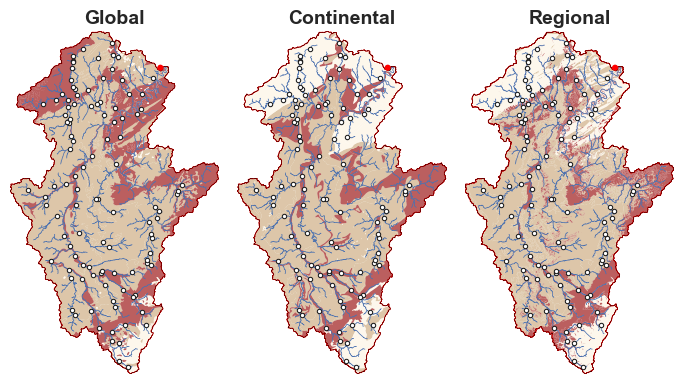

In [464]:
network_estreams_gdf = network_estreams_moselle_108_gauges.loc[~network_estreams_moselle_108_gauges.index.duplicated(keep='first')]

# Create a GeoDataFrame from network_estreams_filtered
geometry = [Point(xy) for xy in zip(network_estreams_gdf['lon'], network_estreams_gdf['lat'])]
network_estreams_gdf = gpd.GeoDataFrame(network_estreams_gdf, geometry=geometry, crs='EPSG:4326')
network_estreams_gdf["basin_id"] = network_estreams_gdf.index
# Create the figure with two main columns: one for the first figure, one for the second figure (which will have 3 subplots)
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(7, 4))  # Two subplots side by side

# Select multiple geometries
FR_selected_gdf = moselle.copy()

# Define the first color mapping for GLiM_dissolved
color_mapping_glim = {
    'very low': "oldlace",  
    'low': "tan",  
    'medium': "tan",  
    'high': "brown"
}

# Define the second color mapping for geology_median_dissolved
color_mapping_geology = {
    'very low': "oldlace",  
    'low': "tan",  
    'medium': "tan",  
    'high': "brown"
}

# Define the second color mapping for geology_median_dissolved
color_mapping_geology2 = {
    'very low': "oldlace",  
    'low': "tan",  
    'medium': "tan",  
    'high': "brown"
}

color_dict_legend = {
    'very low': 'oldlace',
    'low': 'tan',
    'medium': 'tan',
    'high': 'brown'
}

# Add a column for colors based on the class
GLiM_moselle_dissolved['color'] = GLiM_moselle_dissolved['permeability'].map(color_mapping_glim)
geology_median_moselle_dissolved['color'] = geology_median_moselle_dissolved['permeability'].map(color_mapping_geology)
geology_high_moselle_dissolved['color'] = geology_high_moselle_dissolved['permeability'].map(color_mapping_geology2)

# Set plot limits to the bounding box of the selected study areas
bounds = FR_selected_gdf.total_bounds
x_min, y_min, x_max, y_max = bounds[0], bounds[1], bounds[2], bounds[3]

# Create a mask that covers the entire plotting area
plot_extent = box(x_min - 1, y_min - 1, x_max + 1, y_max + 1)
mask = gpd.GeoDataFrame({'geometry': [plot_extent]}, crs='EPSG:4326')

# Combine the selected geometries into one
combined_geometry = FR_selected_gdf.unary_union

# Create the mask by subtracting the combined geometry from the plot extent
mask['geometry'] = mask.difference(combined_geometry)

# Plot the first geology shapefile with different colors for each class
GLiM_moselle_dissolved.plot(column='permeability', ax=ax1, legend=True, 
                    categorical=True, color=GLiM_moselle_dissolved['color'], edgecolor='none', linewidth=0, alpha=0.75)

# Overlay the study area boundaries
FR_selected_gdf.plot(ax=ax1, facecolor='none', edgecolor='red', linewidth=0.5, label='')

# Plot the points from network_estreams_filtered
network_estreams_gdf.plot(ax=ax1, color='white', markersize=10, edgecolor='k', linewidth=0.75, 
                          label='Measurement Points', zorder=100)

network_estreams_gdf.loc[["DEBU1959"]].plot(ax=ax1, color='red', markersize=20, edgecolor='none', linewidth=0.5, 
                          label='Measurement Points', zorder=100)

# Plot the mask to cover everything outside the study area
#mask.plot(ax=ax1, facecolor='white', edgecolor='red', linewidth=0.5, label='Basins')

# Set plot limits to the bounding box of the study area
ax1.set_xlim(x_min, x_max)
ax1.set_ylim(y_min, y_max)

# Set plot title and labels
ax1.set_xlabel('')
ax1.set_ylabel('')



# Plot the second geology shapefile with different colors for each class
geology_median_moselle_dissolved.plot(column='permeability', ax=ax2, legend=True, 
                    categorical=True, color=geology_median_moselle_dissolved['color'], edgecolor='none', linewidth=0, alpha=0.75)

# Overlay the study area boundaries
FR_selected_gdf.plot(ax=ax2, facecolor='none', edgecolor='red', linewidth=0.5, label='')

# Plot the points from network_estreams_filtered
network_estreams_gdf.plot(ax=ax2, color='white', markersize=10, edgecolor='k', linewidth=0.75, 
                          label='Measurement Points', zorder=100)

network_estreams_gdf.loc[["DEBU1959"]].plot(ax=ax2, color='red', markersize=20, edgecolor='none', linewidth=0.5, 
                          label='Measurement Points', zorder=100)
# Set plot limits to the bounding box of the study area
ax2.set_xlim(x_min, x_max)
ax2.set_ylim(y_min, y_max)

# Set plot title and labels
#ax2.set_title('(c)', loc="left")
ax2.set_xlabel('')
ax2.set_ylabel('')
custom_label = ["Low", "Medium-low", "Medium-high", "High"]

# Plot the third geology shapefile with different colors for each class
geology_high_moselle_dissolved.plot(column='permeability', ax=ax3, legend=True, 
                    categorical=True, color=geology_high_moselle_dissolved['color'], edgecolor='none', linewidth=0, alpha=0.75)

# Overlay the study area boundaries
FR_selected_gdf.plot(ax=ax3, facecolor='none', edgecolor='red', linewidth=0.5, label='')

# Plot the points from network_estreams_filtered
network_estreams_gdf.plot(ax=ax3, color='white', markersize=10, edgecolor='k', linewidth=0.75, 
                          label='Measurement Points', zorder=100)

network_estreams_gdf.loc[["DEBU1959"]].plot(ax=ax3, color='red', markersize=20, edgecolor='none', linewidth=0.5, 
                          label='Measurement Points', zorder=100)


# Plot the river
rivers_moselle.plot(ax=ax1, linewidth=0.5, label='River network')
rivers_moselle.plot(ax=ax2, linewidth=0.5, label='River network')
rivers_moselle.plot(ax=ax3, linewidth=0.5, label='River network')

# Plot the mask to cover everything outside the study area
mask.plot(ax=ax3, facecolor='white', edgecolor='red', linewidth=0.5, label='Basins')

# Set plot limits to the bounding box of the study area
ax3.set_xlim(x_min, x_max)
ax3.set_ylim(y_min, y_max)

# Set plot title and labels
#ax3.set_title('(d)', loc="left")

text_to_subplots = ["Global", "Continental", "Regional"]
i = 0 
for ax in [ax1, ax2, ax3]:

    # Overlay the study area boundaries
    FR_selected_gdf.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=0.25, label='Sub-catchments')

    # Hide spines for main plot
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.spines['left'].set_visible(False)
    # Add text below the plot
    #ax.text(0.45, 1.075, text_to_subplots[i], transform=ax.transAxes, 
    #        fontsize=10, ha='center', va='top', color='black', fontweight='bold')
    ax.set_title(text_to_subplots[i], loc="center", fontsize=14, fontweight="bold")
    i = i + 1

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.colors import to_rgba

# Define the color dictionary with alpha transparency (0.5 for 50% opacity)
color_dict_legend = {
    'Low': to_rgba('oldlace', 0.75),
    'Medium': to_rgba('tan', 0.75),
    'High': to_rgba('brown', 0.75)
}

# Create custom legend elements with alpha applied to markerfacecolor
legend_elements = [Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=10, label=label)
                   for label, color in color_dict_legend.items()]

# Add the legend outside the plot area with minimal space
#legend = fig.legend(handles=legend_elements, title='Permeability', loc='center', frameon=False, 
#                   bbox_to_anchor=(0.5, -0.01), ncol=5)
## Make the legend title bold
#legend.get_title().set_fontweight('bold')


# Adjust the layout to remove extra space
plt.tight_layout()


/var/folders/sd/ytjf58757690_xfckxng56q00000gq/T/ipykernel_10241/1802628556.py:92: UserWarning: Only specify one of 'column' or 'color'. Using 'color'.
  GLiM_moselle_dissolved.plot(column='permeability', ax=ax, color=GLiM_moselle_dissolved['color'], edgecolor='none', linewidth=0, alpha=0.5)
/var/folders/sd/ytjf58757690_xfckxng56q00000gq/T/ipykernel_10241/1802628556.py:96: UserWarning: Only specify one of 'column' or 'color'. Using 'color'.
  geology_high_moselle_dissolved.plot(column='permeability', ax=ax, color=geology_high_moselle_dissolved['color'], edgecolor='none', linewidth=0, alpha=0.5)
/var/folders/sd/ytjf58757690_xfckxng56q00000gq/T/ipykernel_10241/1802628556.py:182: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


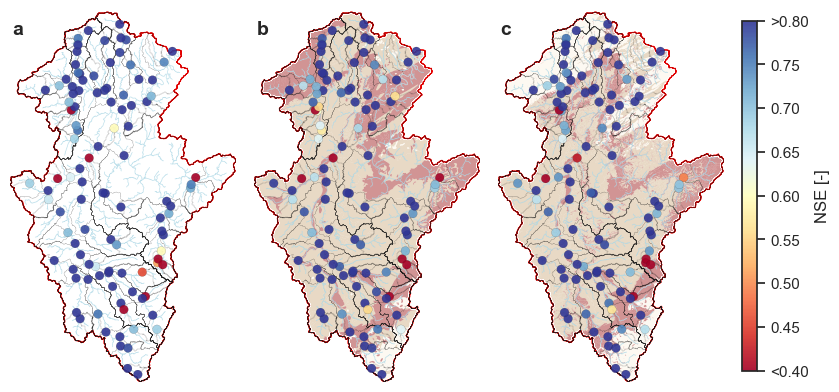

In [465]:
catchment_boundaries_moselle = catchment_boundaries.loc[network_estreams_gdf.index.tolist(), :]

selected_ids = ["FR000144", "FR000185", "FR003250","FR003280"]


import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.lines as mlines
from shapely.geometry import box


network_estreams_gdf = network_estreams_moselle_108_gauges.loc[~network_estreams_moselle_108_gauges.index.duplicated(keep='first')]

# Create a GeoDataFrame from network_estreams_filtered
geometry = [Point(xy) for xy in zip(network_estreams_gdf['lon'], network_estreams_gdf['lat'])]
network_estreams_gdf = gpd.GeoDataFrame(network_estreams_gdf, geometry=geometry, crs='EPSG:4326')
network_estreams_gdf["basin_id"] = network_estreams_gdf.index

# Define the first color mapping for GLiM_dissolved
color_mapping_glim = {
    'very low': "oldlace",  
    'low': "tan",  
    'medium': "tan",  
    'high': "brown"
}

# Define the second color mapping for geology_median_dissolved
color_mapping_geology = {
    'very low': "oldlace",  
    'low': "tan",  
    'medium': "tan",  
    'high': "brown"
}

# Define the second color mapping for geology_median_dissolved
color_mapping_geology2 = {
    'very low': "oldlace",  
    'low': "tan",  
    'medium': "tan",  
    'high': "brown"
}

color_dict_legend = {
    'very low': 'oldlace',
    'low': 'tan',
    'medium': 'tan',
    'high': 'brown'
}

# Add a column for colors based on the class
GLiM_moselle_dissolved['color'] = GLiM_moselle_dissolved['permeability'].map(color_mapping_glim)
geology_median_moselle_dissolved['color'] = geology_median_moselle_dissolved['permeability'].map(color_mapping_geology)
geology_high_moselle_dissolved['color'] = geology_high_moselle_dissolved['permeability'].map(color_mapping_geology2)

# Set style
sns.set_theme(style="ticks")

# Copy and add coordinates
df = data_diff_val_complete_dict_plot.copy()
df[["lat", "lon"]] = network_estreams_moselle_108_gauges[["lat", "lon"]]

# Create figure
fig, axes = plt.subplots(1, 3, figsize=(7.5, 5), sharex=True, sharey=True)

# NSE columns and titles
nse_cols = ['nse_nogeo', 'nse_g1comp', 'nse_r1comp']
titles = ['a', 'b', 'c']
main_titles = [r"$\mathbf{B_{\mathrm{ben}}}$", r"$\mathbf{B_{\mathrm{glo}}}$", 
                r"$\mathbf{B_{\mathrm{reg}}}$"]

background_maps = ['none', 'GLiM', 'high']

# Set plot limits to the bounding box of the selected study areas
FR_selected_gdf = moselle.copy()
bounds = FR_selected_gdf.total_bounds
x_min, y_min, x_max, y_max = bounds[0], bounds[1], bounds[2], bounds[3]+ 0.02

## Create a mask that covers the entire plotting area
#plot_extent = box(x_min - 1, y_min - 1, x_max + 1, y_max + 1)
#mask = gpd.GeoDataFrame({'geometry': [plot_extent]}, crs='EPSG:4326')

# Color setup
vmin, vmax = 0.4, 0.8
cmap_nse = plt.cm.RdYlBu

# Plot loop
for ax, col, subtitle, maintitle, bg_type in zip(axes, nse_cols, titles, main_titles, background_maps):

    # Add background geology map where appropriate
    if bg_type == 'GLiM':
        GLiM_moselle_dissolved.plot(column='permeability', ax=ax, color=GLiM_moselle_dissolved['color'], edgecolor='none', linewidth=0, alpha=0.5)
    elif bg_type == 'median':
        geology_median_moselle_dissolved.plot(column='permeability', ax=ax, color=geology_median_moselle_dissolved['color'], edgecolor='none', linewidth=0, alpha=0.5)
    elif bg_type == 'high':
        geology_high_moselle_dissolved.plot(column='permeability', ax=ax, color=geology_high_moselle_dissolved['color'], edgecolor='none', linewidth=0, alpha=0.5)

    # Add rivers and boundary for all
    moselle.plot(ax=ax, color='none', linewidth=2, alpha=1)
    rivers_moselle.plot(ax=ax, color='lightblue', linewidth=0.5, alpha=0.75)

#   if bg_type != 'none':
    FR_selected_gdf.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=0.25)


    mask.plot(ax=ax, facecolor='white', edgecolor='red', linewidth=0.75)

    # Scatter NSE values
    sc = ax.scatter(
        df['lon'], df['lat'],
        c=df[col],
        cmap=cmap_nse,
        vmin=vmin,
        vmax=vmax,
        s=40,
        edgecolor='k',
        linewidth=0.1,
        alpha=0.9,
        zorder=10000
    )

    # Subplot letter
    ax.text(0.01, 0.97, subtitle, transform=ax.transAxes, fontsize=14, fontweight='bold', va='top', ha='left')

    # Set plot limits to the bounding box of the study area
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)

    # Clean look
    ax.set_xticks([])
    ax.set_yticks([])
    #ax.set_xlabel(maintitle, fontsize=14, fontweight='bold')
    ax.set_ylabel("")
    ax.grid(False)
    for spine in ax.spines.values():
        spine.set_visible(False)


    catchment_boundaries_moselle.plot(ax=ax, facecolor='none', edgecolor='k', linewidth=0.1, label='Sub-catchments')



# Colorbar setup
fig.subplots_adjust(right=0.85)
cbar_ax = fig.add_axes([1.0, 0.15, 0.02, 0.7])
cbar = fig.colorbar(sc, cax=cbar_ax)
cbar.set_label('NSE [-]')
ticks = np.linspace(0.4, 0.8, num=9)
tick_labels = [f"<0.40"] + [f"{t:.2f}" for t in ticks[1:-1]] + [f">0.80"]
#cbar.set_ticks(ticks)
cbar.set_ticks(np.arange(vmin, vmax + 0.05, 0.05))

cbar.set_ticklabels(tick_labels)

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.colors import to_rgba

# Define the color dictionary with alpha transparency (0.5 for 50% opacity)
color_dict_legend = {
    'Low': to_rgba('oldlace', 0.5),
    'Medium': to_rgba('tan', 0.5),
    'High': to_rgba('brown', 0.5)
}

# Create custom legend elements with alpha applied to markerfacecolor
legend_elements = [Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=10, label=label, linewidth=0.5)
                   for label, color in color_dict_legend.items()]

## Add the legend outside the plot area with minimal space
#legend = fig.legend(handles=legend_elements, title='Permeability', loc='center', frameon=False, 
#                   bbox_to_anchor=(0.5, -0.01), ncol=5)
## Make the legend title bold
#legend.get_title().set_fontweight('bold')


#axes[0].text(7.38,48.7, "FR000185", fontsize=8, ha='center', va='bottom', zorder=20, color='black')
#axes[0].text(7.2,48.38, "FR000144", fontsize=8, ha='center', va='bottom', zorder=20, color='black')
#axes[0].text(7.35,48.15, "FR003250", fontsize=8, ha='center', va='bottom', zorder=20, color='black')
#axes[0].text(5.7,49.28, "FR003280", fontsize=8, ha='center', va='bottom', zorder=20, color='black')
# Save and show
plt.tight_layout()
# Save including everything (colorbar + legend)
plt.savefig(
    "../results/figs/figures/FigSX_geomapsa_lstm.png",
    dpi=300,
    bbox_inches='tight')


plt.show()

In [461]:
data_diff_val_complete_dict_plot_moselle

,nse_nogeo,nse_ran,nse_g1comp,nse_c1comp,nse_r1comp,kge_nogeo,kge_ran,kge_g1comp,kge_c1comp,kge_r1comp,...,slope_c1comp,slope_g1comp,slope_nogeo,slope_ran,qmean_obs,qmean_r1comp,qmean_c1comp,qmean_g1comp,qmean_nogeo,qmean_ran
LU000018,0.708004,0.645161,0.613311,0.564327,0.728759,0.519452,0.425042,0.556437,0.309184,0.573954,...,0.812070,2.956945,1.575416,1.495972,0.875516,0.771046,0.767733,0.671032,0.740483,0.628584
LU000010,-0.253810,0.531080,-0.141319,0.598281,0.182699,0.045395,0.377272,0.039598,0.584577,0.328865,...,1.222602,4.223004,1.987243,1.656020,0.905003,1.472660,1.096171,1.471469,1.709276,0.553534
LU000001,0.887131,0.794342,0.844241,0.891292,0.883199,0.796192,0.792088,0.723189,0.756901,0.805964,...,3.244158,3.184234,2.927708,5.261025,1.182612,0.985025,0.967843,0.950618,0.989606,0.951205
DERP2028,0.761699,0.811432,0.744347,0.789432,0.794572,0.622202,0.631550,0.660630,0.541673,0.555633,...,1.460397,2.494703,2.226240,1.695546,0.955301,0.758786,0.746694,0.730590,0.726114,0.744433
FR000183,0.513281,0.150104,0.616502,0.267067,0.081775,0.644688,0.561833,0.776562,0.649062,0.608901,...,3.206024,2.438878,2.461757,3.284795,1.099655,0.698047,0.742405,0.926833,0.790545,0.663257
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
DERP2007,0.796881,0.826878,0.802622,0.821837,0.808305,0.515870,0.592797,0.518329,0.548724,0.524168,...,2.332885,2.308954,1.782600,1.914561,1.040731,0.774757,0.769958,0.727615,0.769210,0.858933
FR003271,0.787464,0.782418,0.821171,0.798304,0.821013,0.539043,0.580716,0.553413,0.543808,0.578753,...,2.248059,2.192323,2.637527,2.370765,0.624199,0.479710,0.447601,0.497038,0.441947,0.438349
FR003301,0.905110,0.896444,0.900515,0.908468,0.893708,0.721253,0.686253,0.709992,0.743164,0.710545,...,2.093468,1.845995,2.106055,2.003049,0.788065,0.662018,0.679025,0.702483,0.695920,0.667897
DERP2003,0.839509,0.851834,0.767786,0.895105,0.890449,0.569379,0.621412,0.472140,0.727987,0.781115,...,2.217808,1.297436,1.752440,1.797834,0.931310,0.788044,0.780283,0.741589,0.742219,0.745398


/var/folders/sd/ytjf58757690_xfckxng56q00000gq/T/ipykernel_10241/2515196404.py:58: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  combined_geometry = FR_selected_gdf.unary_union
/var/folders/sd/ytjf58757690_xfckxng56q00000gq/T/ipykernel_10241/2515196404.py:64: UserWarning: Only specify one of 'column' or 'color'. Using 'color'.
  GLiM_garonne_dissolved.plot(column='permeability', ax=ax1, legend=True,
/var/folders/sd/ytjf58757690_xfckxng56q00000gq/T/ipykernel_10241/2515196404.py:91: UserWarning: Only specify one of 'column' or 'color'. Using 'color'.
  geology_median_garonne_dissolved.plot(column='permeability', ax=ax2, legend=True,
/var/folders/sd/ytjf58757690_xfckxng56q00000gq/T/ipykernel_10241/2515196404.py:114: UserWarning: Only specify one of 'column' or 'color'. Using 'color'.
  geology_high_garonne_dissolved.plot(column='permeability', ax=ax3, legend=True,


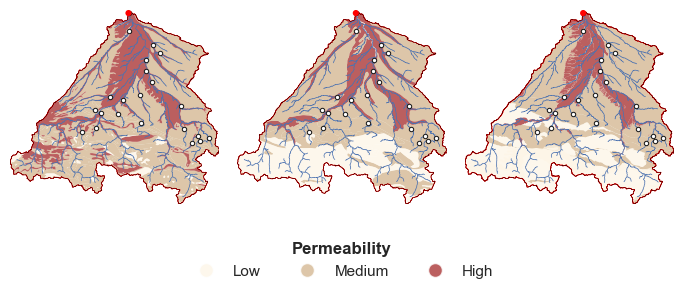

In [458]:
network_estreams_gdf = network_estreams_garonne_22_gauges.loc[~network_estreams_garonne_22_gauges.index.duplicated(keep='first')]

# Create a GeoDataFrame from network_estreams_filtered
geometry = [Point(xy) for xy in zip(network_estreams_gdf['lon'], network_estreams_gdf['lat'])]
network_estreams_gdf = gpd.GeoDataFrame(network_estreams_gdf, geometry=geometry, crs='EPSG:4326')
network_estreams_gdf["basin_id"] = network_estreams_gdf.index
# Create the figure with two main columns: one for the first figure, one for the second figure (which will have 3 subplots)
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(7, 3))  # Two subplots side by side

# Select multiple geometries
FR_selected_gdf = garonne.copy()

# Define the first color mapping for GLiM_dissolved
color_mapping_glim = {
    'very low': "oldlace",  
    'low': "tan",  
    'medium': "tan",  
    'high': "brown"
}

# Define the second color mapping for geology_median_dissolved
color_mapping_geology = {
    'very low': "oldlace",  
    'low': "tan",  
    'medium': "tan",  
    'high': "brown"
}

# Define the second color mapping for geology_median_dissolved
color_mapping_geology2 = {
    'very low': "oldlace",  
    'low': "oldlace",  
    'medium': "tan",  
    'high': "brown"
}

color_dict_legend = {
    'very low': 'oldlace',
    'low': 'tan',
    'medium': 'tan',
    'high': 'brown'
}

# Add a column for colors based on the class
GLiM_garonne_dissolved['color'] = GLiM_garonne_dissolved['permeability'].map(color_mapping_glim)
geology_median_garonne_dissolved['color'] = geology_median_garonne_dissolved['permeability'].map(color_mapping_geology)
geology_high_garonne_dissolved['color'] = geology_high_garonne_dissolved['permeability'].map(color_mapping_geology2)

# Set plot limits to the bounding box of the selected study areas
bounds = FR_selected_gdf.total_bounds
x_min, y_min, x_max, y_max = bounds[0], bounds[1], bounds[2], bounds[3] + 0.02

# Create a mask that covers the entire plotting area
plot_extent = box(x_min - 1, y_min - 1, x_max + 1, y_max + 1.0)
mask = gpd.GeoDataFrame({'geometry': [plot_extent]}, crs='EPSG:4326')

# Combine the selected geometries into one
combined_geometry = FR_selected_gdf.unary_union

# Create the mask by subtracting the combined geometry from the plot extent
mask['geometry'] = mask.difference(combined_geometry)

# Plot the first geology shapefile with different colors for each class
GLiM_garonne_dissolved.plot(column='permeability', ax=ax1, legend=True, 
                    categorical=True, color=GLiM_garonne_dissolved['color'], edgecolor='none', linewidth=0, alpha=0.75)

# Overlay the study area boundaries
FR_selected_gdf.plot(ax=ax1, facecolor='none', edgecolor='red', linewidth=0.5, label='')

# Plot the points from network_estreams_filtered
network_estreams_gdf.plot(ax=ax1, color='white', markersize=10, edgecolor='k', linewidth=0.75, 
                          label='Measurement Points', zorder=100)

network_estreams_gdf.loc[["FR001604"]].plot(ax=ax1, color='red', markersize=20, edgecolor='none', linewidth=0.5, 
                          label='Measurement Points', zorder=100)

# Plot the mask to cover everything outside the study area
#mask.plot(ax=ax1, facecolor='white', edgecolor='red', linewidth=0.5, label='Basins')

# Set plot limits to the bounding box of the study area
ax1.set_xlim(x_min, x_max)
ax1.set_ylim(y_min, y_max)

# Set plot title and labels
ax1.set_xlabel('')
ax1.set_ylabel('')



# Plot the second geology shapefile with different colors for each class
geology_median_garonne_dissolved.plot(column='permeability', ax=ax2, legend=True, 
                    categorical=True, color=geology_median_garonne_dissolved['color'], edgecolor='none', linewidth=0, alpha=0.75)

# Overlay the study area boundaries
FR_selected_gdf.plot(ax=ax2, facecolor='none', edgecolor='red', linewidth=0.5, label='')

# Plot the points from network_estreams_filtered
network_estreams_gdf.plot(ax=ax2, color='white', markersize=10, edgecolor='k', linewidth=0.75, 
                          label='Measurement Points', zorder=100)

network_estreams_gdf.loc[["FR001604"]].plot(ax=ax2, color='red', markersize=20, edgecolor='none', linewidth=0.5, 
                          label='Measurement Points', zorder=100)
# Set plot limits to the bounding box of the study area
ax2.set_xlim(x_min, x_max)
ax2.set_ylim(y_min, y_max)

# Set plot title and labels
#ax2.set_title('(c)', loc="left")
ax2.set_xlabel('')
ax2.set_ylabel('')
custom_label = ["Low", "Medium-low", "Medium-high", "High"]

# Plot the third geology shapefile with different colors for each class
geology_high_garonne_dissolved.plot(column='permeability', ax=ax3, legend=True, 
                    categorical=True, color=geology_high_garonne_dissolved['color'], edgecolor='none', linewidth=0, alpha=0.75)

# Overlay the study area boundaries
FR_selected_gdf.plot(ax=ax3, facecolor='none', edgecolor='red', linewidth=0.5, label='')

# Plot the points from network_estreams_filtered
network_estreams_gdf.plot(ax=ax3, color='white', markersize=10, edgecolor='k', linewidth=0.75, 
                          label='Measurement Points', zorder=100)

network_estreams_gdf.loc[["FR001604"]].plot(ax=ax3, color='red', markersize=20, edgecolor='none', linewidth=0.5, 
                          label='Measurement Points', zorder=100)


# Plot the river
rivers_garonne.plot(ax=ax1, linewidth=0.5, label='River network')
rivers_garonne.plot(ax=ax2, linewidth=0.5, label='River network')
rivers_garonne.plot(ax=ax3, linewidth=0.5, label='River network')

# Plot the mask to cover everything outside the study area
mask.plot(ax=ax3, facecolor='white', edgecolor='red', linewidth=0.5, label='Basins')

# Set plot limits to the bounding box of the study area
ax3.set_xlim(x_min, x_max)
ax3.set_ylim(y_min, y_max)

# Set plot title and labels
#ax3.set_title('(d)', loc="left")

#text_to_subplots = ["Global", "Continental", "Regional"]
i = 0 
for ax in [ax1, ax2, ax3]:

    # Overlay the study area boundaries
    FR_selected_gdf.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=0.25, label='Sub-catchments')

    # Hide spines for main plot
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.spines['left'].set_visible(False)
    # Add text below the plot
    #ax.text(0.45, 1.075, text_to_subplots[i], transform=ax.transAxes, 
    #        fontsize=10, ha='center', va='top', color='black', fontweight='bold')
    #ax.set_title(text_to_subplots[i], loc="center", fontsize=14, fontweight="bold")
    i = i + 1

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.colors import to_rgba

# Define the color dictionary with alpha transparency (0.5 for 50% opacity)
color_dict_legend = {
    'Low': to_rgba('oldlace', 0.75),
    'Medium': to_rgba('tan', 0.75),
    'High': to_rgba('brown', 0.75)
}

# Create custom legend elements with alpha applied to markerfacecolor
legend_elements = [Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=10, label=label)
                   for label, color in color_dict_legend.items()]

# Add the legend outside the plot area with minimal space
legend = fig.legend(handles=legend_elements, title='Permeability', loc='center', frameon=False, 
                   bbox_to_anchor=(0.5, -0.01), ncol=5)
# Make the legend title bold
legend.get_title().set_fontweight('bold')
# Adjust the layout to remove extra space
plt.tight_layout()

/var/folders/sd/ytjf58757690_xfckxng56q00000gq/T/ipykernel_10241/3679330178.py:84: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  combined_geometry = FR_selected_gdf.unary_union
/var/folders/sd/ytjf58757690_xfckxng56q00000gq/T/ipykernel_10241/3679330178.py:99: UserWarning: Only specify one of 'column' or 'color'. Using 'color'.
  GLiM_garonne_dissolved.plot(column='permeability', ax=ax, color=GLiM_garonne_dissolved['color'], edgecolor='none', linewidth=0, alpha=0.5)
/var/folders/sd/ytjf58757690_xfckxng56q00000gq/T/ipykernel_10241/3679330178.py:103: UserWarning: Only specify one of 'column' or 'color'. Using 'color'.
  geology_high_garonne_dissolved.plot(column='permeability', ax=ax, color=geology_high_garonne_dissolved['color'], edgecolor='none', linewidth=0, alpha=0.5)
/var/folders/sd/ytjf58757690_xfckxng56q00000gq/T/ipykernel_10241/3679330178.py:192: UserWarning: This figure includes Axes that are not compatible with tight_layou

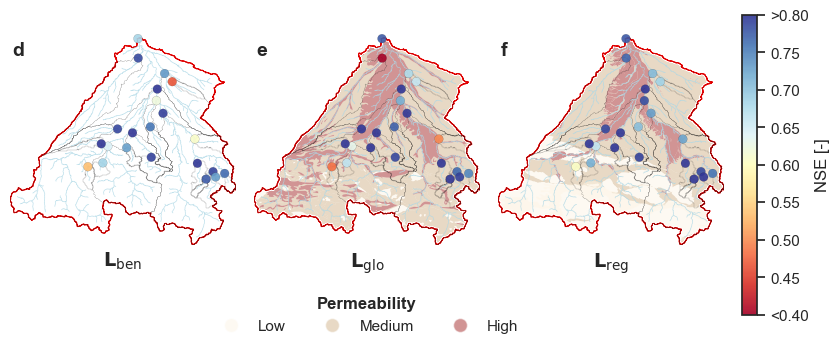

In [459]:
network_estreams_gdf = network_estreams_garonne_22_gauges.loc[~network_estreams_garonne_22_gauges.index.duplicated(keep='first')]

catchment_boundaries_garonne = catchment_boundaries.loc[network_estreams_gdf.index.tolist(), :]

#selected_ids = ["DERP2013", "FR000144", "FR000183", "FR000185", "FR003250", "FR003259","FR003280"]


import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.lines as mlines


# Create a GeoDataFrame from network_estreams_filtered
geometry = [Point(xy) for xy in zip(network_estreams_gdf['lon'], network_estreams_gdf['lat'])]
network_estreams_gdf = gpd.GeoDataFrame(network_estreams_gdf, geometry=geometry, crs='EPSG:4326')
network_estreams_gdf["basin_id"] = network_estreams_gdf.index

# Define the first color mapping for GLiM_dissolved
color_mapping_glim = {
    'very low': "oldlace",  
    'low': "tan",  
    'medium': "tan",  
    'high': "brown"
}

# Define the second color mapping for geology_median_dissolved
color_mapping_geology = {
    'very low': "oldlace",  
    'low': "tan",  
    'medium': "tan",  
    'high': "brown"
}

# Define the second color mapping for geology_median_dissolved
color_mapping_geology2 = {
    'very low': "oldlace",  
    'low': "oldlace",  
    'medium': "tan",  
    'high': "brown"
}

color_dict_legend = {
    'very low': 'oldlace',
    'low': 'tan',
    'medium': 'tan',
    'high': 'brown'
}

# Add a column for colors based on the class
GLiM_garonne_dissolved['color'] = GLiM_garonne_dissolved['permeability'].map(color_mapping_glim)
geology_median_garonne_dissolved['color'] = geology_median_garonne_dissolved['permeability'].map(color_mapping_geology)
geology_high_garonne_dissolved['color'] = geology_high_garonne_dissolved['permeability'].map(color_mapping_geology2)

# Set style
sns.set_theme(style="ticks")

# Copy and add coordinates
df = data_diff_val_complete_dict_plot_garonne.copy()
df[["lat", "lon"]] = network_estreams_garonne_22_gauges[["lat", "lon"]]

# Create figure
fig, axes = plt.subplots(1, 3, figsize=(7.5, 5), sharex=True, sharey=True)

# NSE columns and titles
nse_cols = ['nse_nogeo', 'nse_g1comp', 'nse_r1comp']
titles = ['d', 'e', 'f']
main_titles = [r"$\mathbf{L_{\mathrm{ben}}}$", r"$\mathbf{L_{\mathrm{glo}}}$", 
                r"$\mathbf{L_{\mathrm{reg}}}$"]

background_maps = ['none', 'GLiM','high']

# Set plot limits to the bounding box of the selected study areas
FR_selected_gdf = garonne.copy()
bounds = FR_selected_gdf.total_bounds
x_min, y_min, x_max, y_max = bounds[0], bounds[1], bounds[2], bounds[3]+ 0.02

## Create a mask that covers the entire plotting area
plot_extent = box(x_min - 1, y_min - 1, x_max + 1, y_max + 1)
#mask = gpd.GeoDataFrame({'geometry': [plot_extent]}, crs='EPSG:4326')
mask = gpd.GeoDataFrame({'geometry': [plot_extent]}, crs='EPSG:4326')

# Combine the selected geometries into one
combined_geometry = FR_selected_gdf.unary_union

# Create the mask by subtracting the combined geometry from the plot extent
mask['geometry'] = mask.difference(combined_geometry)


# Color setup
vmin, vmax = 0.4, 0.8
cmap_nse = plt.cm.RdYlBu

# Plot loop
for ax, col, subtitle, maintitle, bg_type in zip(axes, nse_cols, titles, main_titles, background_maps):

    # Add background geology map where appropriate
    if bg_type == 'GLiM':
        GLiM_garonne_dissolved.plot(column='permeability', ax=ax, color=GLiM_garonne_dissolved['color'], edgecolor='none', linewidth=0, alpha=0.5)
    elif bg_type == 'median':
        geology_median_garonne_dissolved.plot(column='permeability', ax=ax, color=geology_median_garonne_dissolved['color'], edgecolor='none', linewidth=0, alpha=0.5)
    elif bg_type == 'high':
        geology_high_garonne_dissolved.plot(column='permeability', ax=ax, color=geology_high_garonne_dissolved['color'], edgecolor='none', linewidth=0, alpha=0.5)

    # Add rivers and boundary for all
    garonne.plot(ax=ax, color='none', linewidth=2, alpha=1)
    rivers_garonne.plot(ax=ax, color='lightblue', linewidth=0.5, alpha=0.75)

#   if bg_type != 'none':
    FR_selected_gdf.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=0.25)
    mask.plot(ax=ax, facecolor='white', edgecolor='red', linewidth=0.75)

    # Scatter NSE values
    sc = ax.scatter(
        df['lon'], df['lat'],
        c=df[col],
        cmap=cmap_nse,
        vmin=vmin,
        vmax=vmax,
        s=40,
        edgecolor='k',
        linewidth=0.1,
        alpha=0.9,
        zorder=10
    )

    # Subplot letter
    ax.text(0.01, 0.97, subtitle, transform=ax.transAxes, fontsize=14, fontweight='bold', va='top', ha='left')

    # Set plot limits to the bounding box of the study area
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)

    # Clean look
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel(maintitle, fontsize=14, fontweight='bold')
    ax.set_ylabel("")
    ax.grid(False)
    for spine in ax.spines.values():
        spine.set_visible(False)


    catchment_boundaries_garonne.plot(ax=ax, facecolor='none', edgecolor='k', linewidth=0.1, label='Sub-catchments')



# Colorbar setup
fig.subplots_adjust(right=0.85)
cbar_ax = fig.add_axes([1.0, 0.15, 0.02, 0.6])
cbar = fig.colorbar(sc, cax=cbar_ax)
cbar.set_label('NSE [-]')
ticks = np.linspace(0.4, 0.8, num=9
                    )
tick_labels = [f"<0.40"] + [f"{t:.2f}" for t in ticks[1:-1]] + [f">0.80"]
#cbar.set_ticks(ticks)
cbar.set_ticks(np.arange(vmin, vmax + 0.05, 0.05))

cbar.set_ticklabels(tick_labels)

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.colors import to_rgba

# Define the color dictionary with alpha transparency (0.5 for 50% opacity)
color_dict_legend = {
    'Low': to_rgba('oldlace', 0.5),
    'Medium': to_rgba('tan', 0.5),
    'High': to_rgba('brown', 0.5)
}

# Create custom legend elements with alpha applied to markerfacecolor
legend_elements = [Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=10, label=label, linewidth=0.5)
                   for label, color in color_dict_legend.items()]

# Add the legend outside the plot area with minimal space
legend = fig.legend(handles=legend_elements, title='Permeability', loc='center', frameon=False, 
                   bbox_to_anchor=(0.5, 0.15), ncol=5)
# Make the legend title bold
legend.get_title().set_fontweight('bold')


#axes[0].text(7.419000,49.27, "DERP2013", fontsize=8, ha='center', va='bottom', zorder=20, color='black')
#axes[0].text(7.014472,48.7, "FR00185", fontsize=8, ha='center', va='bottom', zorder=20, color='black')
#axes[0].text(7.18,48.5, "FR00183", fontsize=8, ha='center', va='bottom', zorder=20, color='black')
#axes[0].text(7.2,48.38, "FR00144", fontsize=8, ha='center', va='bottom', zorder=20, color='black')
#axes[0].text(7.35,48.15, "FR03250", fontsize=8, ha='center', va='bottom', zorder=20, color='black')
#axes[0].text(6.645964,48.21, "FR03259", fontsize=8, ha='center', va='bottom', zorder=20, color='black')
#axes[0].text(5.9,49.28, "FR03280", fontsize=8, ha='center', va='bottom', zorder=20, color='black')
	
# Save and show
plt.tight_layout()

# Save including everything (colorbar + legend)
plt.savefig(
    "../results/figs/figures/fig_3geomapsb_lstm.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [460]:
data_diff_val_complete_dict_plot[["nse_nogeo", "nse_ran", "nse_g1comp", "nse_c1comp", "nse_r1comp"]].describe()

,nse_nogeo,nse_ran,nse_g1comp,nse_c1comp,nse_r1comp
count,130.000000,130.000000,130.000000,130.000000,130.000000
mean,0.735740,0.727730,0.725089,0.740572,0.752530
std,0.261293,0.257590,0.335802,0.379741,0.307688
min,-0.912504,-0.944766,-1.964885,-3.024324,-1.737815
25%,0.719926,0.711212,0.714869,0.725486,0.734278
50%,0.800096,0.794157,0.804084,0.815191,0.818618
75%,0.872127,0.855701,0.865288,0.871543,0.876763
max,0.933095,0.932881,0.936910,0.935497,0.933503


In [824]:
data_diff_cal_complete_dict_plot[["nse_nogeo", "nse_ran", "nse_g1comp", "nse_c1comp", "nse_r1comp"]].describe()

,nse_nogeo,nse_ran,nse_g1comp,nse_c1comp,nse_r1comp
count,114.000000,114.000000,114.000000,114.000000,114.000000
mean,0.785175,0.761744,0.776203,0.786260,0.799919
std,0.227108,0.288493,0.277601,0.232701,0.212060
min,-0.279542,-1.238447,-0.715894,-0.441786,-0.337290
25%,0.749258,0.731230,0.767717,0.745685,0.774611
50%,0.855320,0.844823,0.863095,0.849437,0.859129
75%,0.912321,0.902092,0.905963,0.914225,0.908052
max,0.966848,0.963912,0.970580,0.958988,0.967047


In [548]:
data_diff_timeval_complete_dict_plot[["nse_nogeo", "nse_ran", "nse_g1comp", "nse_c1comp", "nse_r1comp"]].describe()

,nse_nogeo,nse_ran,nse_g1comp,nse_c1comp,nse_r1comp
count,130.000000,130.000000,130.000000,130.000000,130.000000
mean,0.801027,0.800764,0.790785,0.806682,0.806846
std,0.178930,0.152317,0.186662,0.168741,0.175372
min,-0.906440,-0.431971,-0.708575,-0.662583,-0.840050
25%,0.784886,0.781122,0.780434,0.786003,0.782007
50%,0.831153,0.829592,0.831138,0.842444,0.836022
75%,0.872039,0.876517,0.879070,0.879634,0.878251
max,0.941193,0.945044,0.943191,0.945724,0.943645


In [549]:
data_diff_cal_complete_dict_plot[["nse_nogeo", "nse_ran", "nse_g1comp", "nse_c1comp", "nse_r1comp"]].describe()

,nse_nogeo,nse_ran,nse_g1comp,nse_c1comp,nse_r1comp
count,130.000000,130.000000,130.000000,130.000000,130.000000
mean,0.808560,0.797679,0.812873,0.812334,0.812458
std,0.261293,0.229956,0.234798,0.223042,0.248110
min,-1.445463,-0.973377,-0.730582,-0.575392,-0.883414
25%,0.801674,0.793225,0.813922,0.796945,0.795318
50%,0.869177,0.860454,0.871175,0.871879,0.879355
75%,0.914754,0.902163,0.914408,0.918743,0.920419
max,0.963366,0.960506,0.963869,0.964942,0.965451


In [ ]:
data_diff_cal_complete_dict_plot

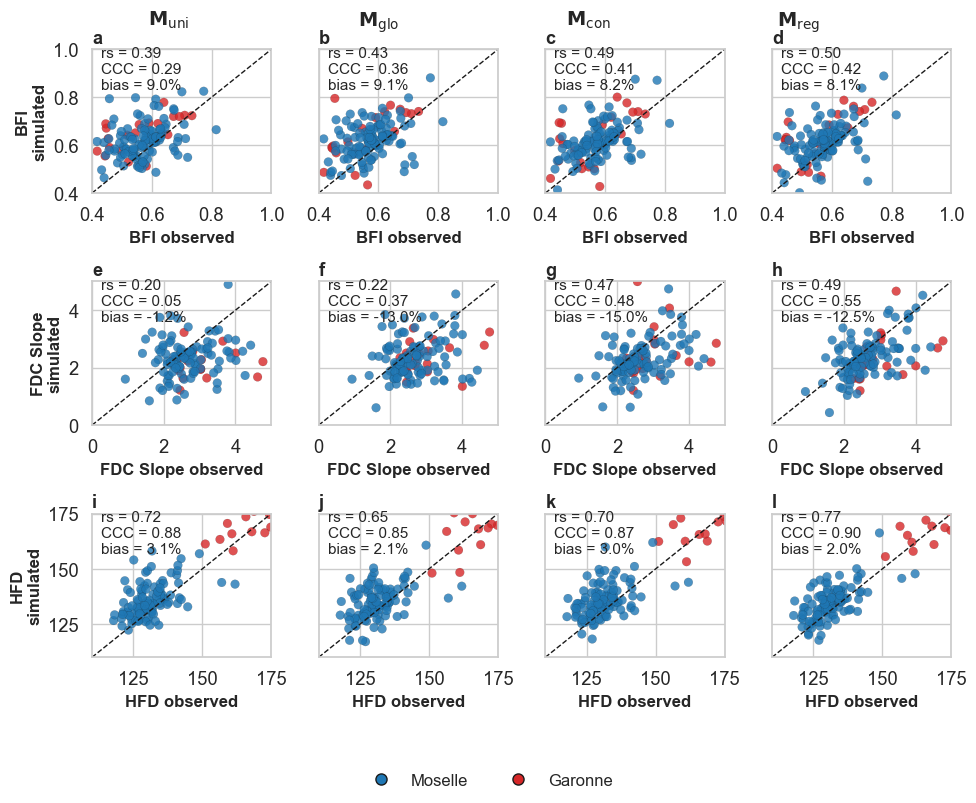

In [111]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import string

# Seaborn style
sns.set(style="whitegrid", font_scale=1.2)

# Define variables and pretty titles
metrics = ['bfi', 'slope', 'hfd']
metric_titles = ['BFI', 'FDC Slope', 'HFD']

# Define suffixes and scales
suffixes = ['nogeo', 'g1comp','c1comp', 'r1comp']
scale_titles = [
    r"$\mathbf{M_{\mathrm{uni}}}$",
    r"$\mathbf{M_{\mathrm{glo}}}$",
    r"$\mathbf{M_{\mathrm{con}}}$",
    r"$\mathbf{M_{\mathrm{reg}}}$"
]

# -------------------------------
# DEFINE BASIN COLORS
# -------------------------------
basin_colors = {
    "moselle": "#1f77b4",   # blue
    "garonne": "#d62728",  # red
}

def get_basin_color(gauge_id):
    if gauge_id in network_estreams_moselle_108_gauges.index.tolist():
        return basin_colors["moselle"]
    elif gauge_id in network_estreams_garonne_22_gauges.index.tolist():
        return basin_colors["garonne"]
    else:
        return "grey"  # fallback (should not happen)

# Precompute colors in dataframe order
point_colors = data_diff_val_complete_dict_plot.index.map(get_basin_color)

# -------------------------------
# CREATE SUBPLOTS
# -------------------------------
fig, axs = plt.subplots(3, 4, figsize=(10, 8), sharex=False, sharey=False)
letters = list(string.ascii_lowercase)

for row, (metric, row_title) in enumerate(zip(metrics, metric_titles)):
    for col, (suffix, scale_title) in enumerate(zip(suffixes, scale_titles)):
        ax = axs[row, col]

        var_obs  = f"{metric}_obs"
        var_pred = f"{metric}_{suffix}"

        ax.scatter(
            data_diff_val_complete_dict_plot[var_obs],
            data_diff_val_complete_dict_plot[var_pred],
            c=point_colors,
            s=40,
            edgecolor='k',
            linewidth=0.1,
            alpha=0.8
        )

        # Labels
        if col == 0:
            ax.set_ylabel(f"{row_title}\nsimulated", fontsize=12, fontweight='bold')
        else:
            ax.set_ylabel("")
            ax.set_yticklabels([])

        ax.set_xlabel(f"{row_title} observed", fontsize=12, fontweight='bold')

        # Correlation & bias
        p = data_diff_val_complete_dict_plot[[var_obs, var_pred]].corr(method="spearman").iloc[0, 1]
        bias_rel = (
            100
            * (data_diff_val_complete_dict_plot[var_pred].mean()
               - data_diff_val_complete_dict_plot[var_obs].mean())
            / data_diff_val_complete_dict_plot[var_obs].mean()
        )
        x = data_diff_val_complete_dict_plot[var_obs].values
        y = data_diff_val_complete_dict_plot[var_pred].values

        R = np.corrcoef(x, y)[0, 1]
        CCC = compute_ccc(x, y)

        bias_rel = 100 * (np.nanmean(y) - np.nanmean(x)) / np.nanmean(x)

        ax.text(
            0.05, 0.72,
            f"rs = {p:.2f}\nCCC = {CCC:.2f}\nbias = {bias_rel:.1f}%",
            transform=ax.transAxes,
            fontsize=11,
            bbox=dict(facecolor='none', alpha=0.6, edgecolor='none')
        )


        # Subplot letter
        subplot_idx = row * 4 + col
        ax.text(
            0.00, 1.14, letters[subplot_idx],
            transform=ax.transAxes,
            fontsize=13,
            fontweight='bold',
            va='top',
            ha='left'
        )

        # Axis limits
        if metric == 'bfi':
            ax.set_xlim(0.4, 1)
            ax.set_ylim(0.4, 1)
            ax.plot([0.4, 1], [0.4, 1], 'k--', lw=1)
        elif metric == 'slope':
            ax.set_xlim(0, 5)
            ax.set_ylim(0, 5)
            ax.plot([0, 5], [0, 5], 'k--', lw=1)
        elif metric == 'hfd':
            ax.set_xlim(110, 175)
            ax.set_ylim(110, 175)
            ax.plot([110, 175], [110, 175], 'k--', lw=1)

# -------------------------------
# LEGEND (INSTEAD OF COLORBAR)
# -------------------------------
from matplotlib.lines import Line2D

legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Moselle',
           markerfacecolor=basin_colors["moselle"], markersize=8, markeredgecolor='k'),
    Line2D([0], [0], marker='o', color='w', label='Garonne',
           markerfacecolor=basin_colors["garonne"], markersize=8, markeredgecolor='k'),
]

fig.legend(
    handles=legend_elements,
    loc="lower center",
    ncol=2,
    frameon=False,
    fontsize=12
)

# Column titles
col_positions = [0.18, 0.39, 0.6, 0.81]
for x, title in zip(col_positions, scale_titles):
    fig.text(x, 0.99, title, ha='center', va='top',
             fontsize=14, fontweight='bold')

# Layout
plt.tight_layout()
plt.subplots_adjust(top=0.94, bottom=0.18)

# Save
#plt.savefig("../results/figs/signatures_by_basin.png", dpi=300)
plt.show()

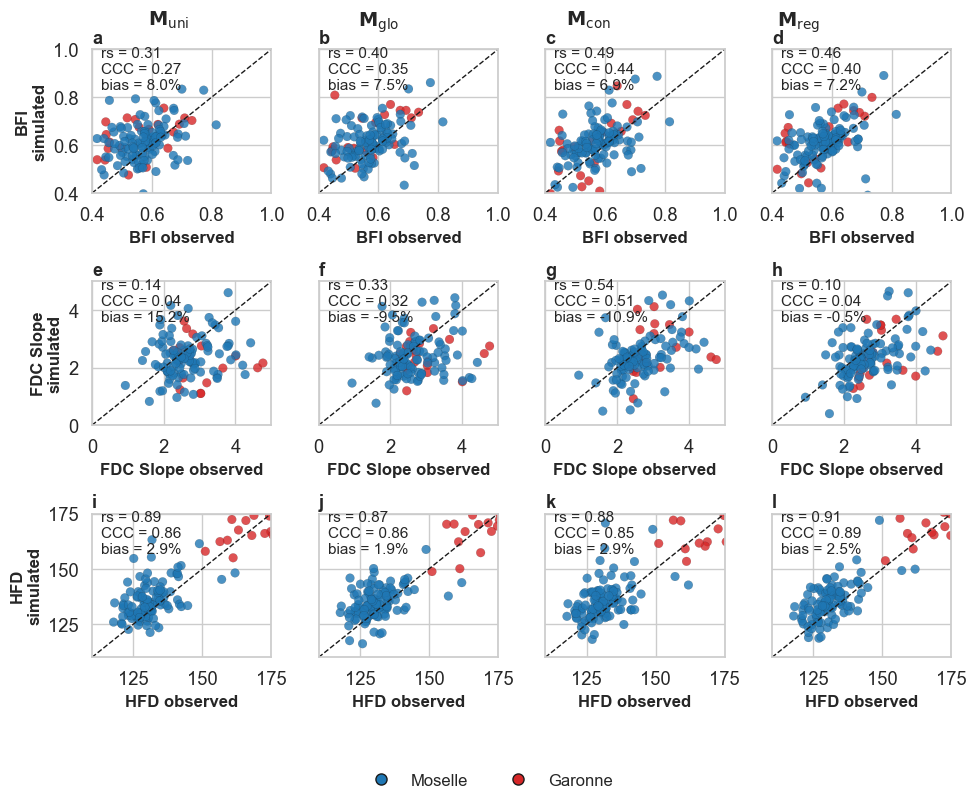

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import string

# Seaborn style
sns.set(style="whitegrid", font_scale=1.2)

# Define variables and pretty titles
metrics = ['bfi', 'slope', 'hfd']
metric_titles = ['BFI', 'FDC Slope', 'HFD']

# Define suffixes and scales
suffixes = ['nogeo', 'g1comp','c1comp', 'r1comp']
scale_titles = [
    r"$\mathbf{M_{\mathrm{uni}}}$",
    r"$\mathbf{M_{\mathrm{glo}}}$",
    r"$\mathbf{M_{\mathrm{con}}}$",
    r"$\mathbf{M_{\mathrm{reg}}}$"
]

# -------------------------------
# DEFINE BASIN COLORS
# -------------------------------
basin_colors = {
    "moselle": "#1f77b4",   # blue
    "garonne": "#d62728",  # red
}

def get_basin_color(gauge_id):
    if gauge_id in network_estreams_moselle_108_gauges.index.tolist():
        return basin_colors["moselle"]
    elif gauge_id in network_estreams_garonne_22_gauges.index.tolist():
        return basin_colors["garonne"]
    else:
        return "grey"  # fallback (should not happen)

# Precompute colors in dataframe order
point_colors = data_diff_val_complete_dict_plot.index.map(get_basin_color)

# -------------------------------
# CREATE SUBPLOTS
# -------------------------------
fig, axs = plt.subplots(3, 4, figsize=(10, 8), sharex=False, sharey=False)
letters = list(string.ascii_lowercase)

for row, (metric, row_title) in enumerate(zip(metrics, metric_titles)):
    for col, (suffix, scale_title) in enumerate(zip(suffixes, scale_titles)):
        ax = axs[row, col]

        var_obs  = f"{metric}_obs"
        var_pred = f"{metric}_{suffix}"

        ax.scatter(
            data_diff_val_complete_dict_plot[var_obs],
            data_diff_val_complete_dict_plot[var_pred],
            c=point_colors,
            s=40,
            edgecolor='k',
            linewidth=0.1,
            alpha=0.8
        )

        # Labels
        if col == 0:
            ax.set_ylabel(f"{row_title}\nsimulated", fontsize=12, fontweight='bold')
        else:
            ax.set_ylabel("")
            ax.set_yticklabels([])

        ax.set_xlabel(f"{row_title} observed", fontsize=12, fontweight='bold')

        # Correlation & bias
        p = data_diff_val_complete_dict_plot[[var_obs, var_pred]].corr(method="pearson").iloc[0, 1]
        bias_rel = (
            100
            * (data_diff_val_complete_dict_plot[var_pred].mean()
               - data_diff_val_complete_dict_plot[var_obs].mean())
            / data_diff_val_complete_dict_plot[var_obs].mean()
        )
        x = data_diff_val_complete_dict_plot[var_obs].values
        y = data_diff_val_complete_dict_plot[var_pred].values

        R = np.corrcoef(x, y)[0, 1]
        CCC = compute_ccc(x, y)

        bias_rel = 100 * (np.nanmean(y) - np.nanmean(x)) / np.nanmean(x)

        ax.text(
            0.05, 0.72,
            f"rs = {p:.2f}\nCCC = {CCC:.2f}\nbias = {bias_rel:.1f}%",
            transform=ax.transAxes,
            fontsize=11,
            bbox=dict(facecolor='none', alpha=0.6, edgecolor='none')
        )


        # Subplot letter
        subplot_idx = row * 4 + col
        ax.text(
            0.00, 1.14, letters[subplot_idx],
            transform=ax.transAxes,
            fontsize=13,
            fontweight='bold',
            va='top',
            ha='left'
        )

        # Axis limits
        if metric == 'bfi':
            ax.set_xlim(0.4, 1)
            ax.set_ylim(0.4, 1)
            ax.plot([0.4, 1], [0.4, 1], 'k--', lw=1)
        elif metric == 'slope':
            ax.set_xlim(0, 5)
            ax.set_ylim(0, 5)
            ax.plot([0, 5], [0, 5], 'k--', lw=1)
        elif metric == 'hfd':
            ax.set_xlim(110, 175)
            ax.set_ylim(110, 175)
            ax.plot([110, 175], [110, 175], 'k--', lw=1)

# -------------------------------
# LEGEND (INSTEAD OF COLORBAR)
# -------------------------------
from matplotlib.lines import Line2D

legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Moselle',
           markerfacecolor=basin_colors["moselle"], markersize=8, markeredgecolor='k'),
    Line2D([0], [0], marker='o', color='w', label='Garonne',
           markerfacecolor=basin_colors["garonne"], markersize=8, markeredgecolor='k'),
]

fig.legend(
    handles=legend_elements,
    loc="lower center",
    ncol=2,
    frameon=False,
    fontsize=12
)

# Column titles
col_positions = [0.18, 0.39, 0.6, 0.81]
for x, title in zip(col_positions, scale_titles):
    fig.text(x, 0.99, title, ha='center', va='top',
             fontsize=14, fontweight='bold')

# Layout
plt.tight_layout()
plt.subplots_adjust(top=0.94, bottom=0.18)

# Save
#plt.savefig("../results/figs/signatures_by_basin.png", dpi=300)
plt.show()

/var/folders/sd/ytjf58757690_xfckxng56q00000gq/T/ipykernel_3333/2415018449.py:5: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  data_diff_val_complete_dict_plot_above = data_diff_val_complete_dict_plot[data_diff_val_complete_dict_plot["nse_r1comp"] >= 0.5][data_diff_val_complete_dict_plot["nse_nogeo"] >= 0.5][data_diff_val_complete_dict_plot["nse_g1comp"] >= 0.5][data_diff_val_complete_dict_plot["nse_c1comp"] >= 0.5]
/var/folders/sd/ytjf58757690_xfckxng56q00000gq/T/ipykernel_3333/2415018449.py:5: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  data_diff_val_complete_dict_plot_above = data_diff_val_complete_dict_plot[data_diff_val_complete_dict_plot["nse_r1comp"] >= 0.5][data_diff_val_complete_dict_plot["nse_nogeo"] >= 0.5][data_diff_val_complete_dict_plot["nse_g1comp"] >= 0.5][data_diff_val_complete_dict_plot["nse_c1comp"] >= 0.5]
/var/folders/sd/ytjf58757690_xfckxng56q00000gq/T/ipykernel_3333/2415018449.py:5: UserWarning: Bo

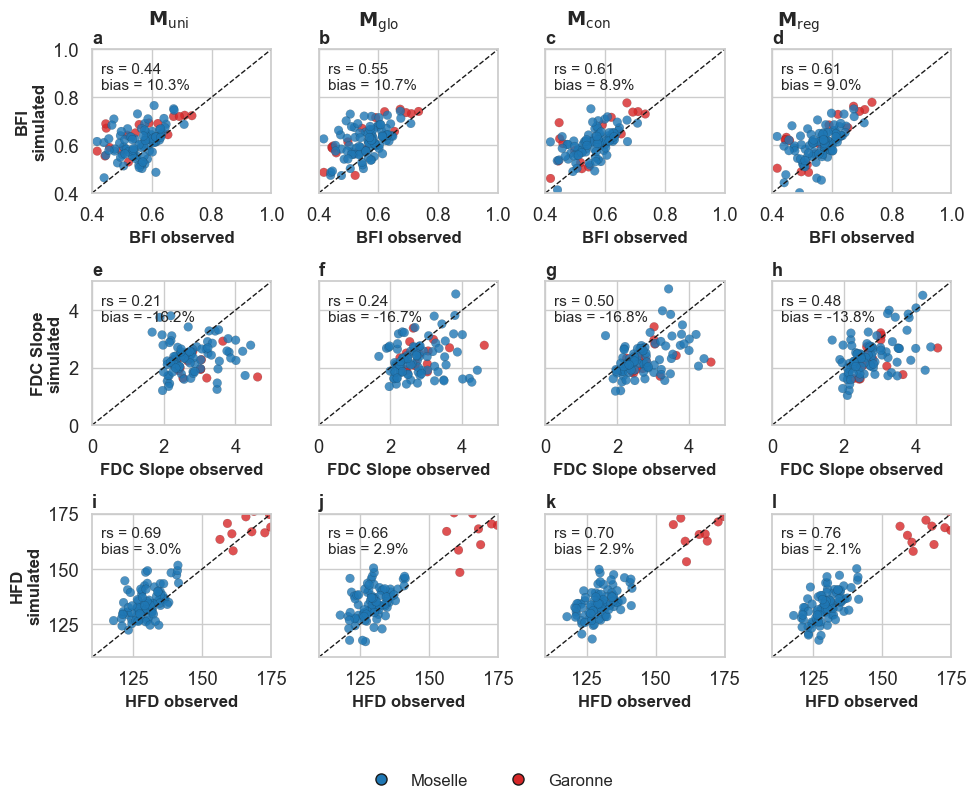

In [119]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import string
data_diff_val_complete_dict_plot_above = data_diff_val_complete_dict_plot[data_diff_val_complete_dict_plot["nse_r1comp"] >= 0.5][data_diff_val_complete_dict_plot["nse_nogeo"] >= 0.5][data_diff_val_complete_dict_plot["nse_g1comp"] >= 0.5][data_diff_val_complete_dict_plot["nse_c1comp"] >= 0.5]
# Seaborn style
sns.set(style="whitegrid", font_scale=1.2)

# Define variables and pretty titles
metrics = ['bfi', 'slope', 'hfd']
metric_titles = ['BFI', 'FDC Slope', 'HFD']

# Define suffixes and scales
suffixes = ['nogeo', 'g1comp', 'c1comp', 'r1comp']
scale_titles = [
    r"$\mathbf{M_{\mathrm{uni}}}$",
    r"$\mathbf{M_{\mathrm{glo}}}$",
    r"$\mathbf{M_{\mathrm{con}}}$",
    r"$\mathbf{M_{\mathrm{reg}}}$"
]

# -------------------------------
# DEFINE BASIN COLORS
# -------------------------------
basin_colors = {
    "moselle": "#1f77b4",   # blue
    "garonne": "#d62728",  # red
}

def get_basin_color(gauge_id):
    if gauge_id in network_estreams_moselle_108_gauges.index.tolist():
        return basin_colors["moselle"]
    elif gauge_id in network_estreams_garonne_22_gauges.index.tolist():
        return basin_colors["garonne"]
    else:
        return "grey"  # fallback (should not happen)

# Precompute colors in dataframe order
point_colors = data_diff_val_complete_dict_plot_above.index.map(get_basin_color)

# -------------------------------
# CREATE SUBPLOTS
# -------------------------------
fig, axs = plt.subplots(3, 4, figsize=(10, 8), sharex=False, sharey=False)
letters = list(string.ascii_lowercase)

for row, (metric, row_title) in enumerate(zip(metrics, metric_titles)):
    for col, (suffix, scale_title) in enumerate(zip(suffixes, scale_titles)):
        ax = axs[row, col]

        var_obs  = f"{metric}_obs"
        var_pred = f"{metric}_{suffix}"

        ax.scatter(
            data_diff_val_complete_dict_plot_above[var_obs],
            data_diff_val_complete_dict_plot_above[var_pred],
            c=point_colors,
            s=40,
            edgecolor='k',
            linewidth=0.1,
            alpha=0.8
        )

        # Labels
        if col == 0:
            ax.set_ylabel(f"{row_title}\nsimulated", fontsize=12, fontweight='bold')
        else:
            ax.set_ylabel("")
            ax.set_yticklabels([])

        ax.set_xlabel(f"{row_title} observed", fontsize=12, fontweight='bold')

        # Correlation & bias
        p = data_diff_val_complete_dict_plot_above[[var_obs, var_pred]].corr(method="spearman").iloc[0, 1]
        bias_rel = (
            100
            * (data_diff_val_complete_dict_plot_above[var_pred].mean()
               - data_diff_val_complete_dict_plot_above[var_obs].mean())
            / data_diff_val_complete_dict_plot_above[var_obs].mean()
        )
        x = data_diff_val_complete_dict_plot_above[var_obs].values
        y = data_diff_val_complete_dict_plot_above[var_pred].values

        R = np.corrcoef(x, y)[0, 1]
        CCC = compute_ccc(x, y)

        bias_rel = 100 * (np.nanmean(y) - np.nanmean(x)) / np.nanmean(x)

        ax.text(
            0.05, 0.72,
            f"rs = {p:.2f}\nbias = {bias_rel:.1f}%",
            transform=ax.transAxes,
            fontsize=11,
            bbox=dict(facecolor='none', alpha=0.6, edgecolor='none')
        )


        # Subplot letter
        subplot_idx = row * 4 + col
        ax.text(
            0.00, 1.14, letters[subplot_idx],
            transform=ax.transAxes,
            fontsize=13,
            fontweight='bold',
            va='top',
            ha='left'
        )

        # Axis limits
        if metric == 'bfi':
            ax.set_xlim(0.4, 1)
            ax.set_ylim(0.4, 1)
            ax.plot([0.4, 1], [0.4, 1], 'k--', lw=1)
        elif metric == 'slope':
            ax.set_xlim(0, 5)
            ax.set_ylim(0, 5)
            ax.plot([0, 5], [0, 5], 'k--', lw=1)
        elif metric == 'hfd':
            ax.set_xlim(110, 175)
            ax.set_ylim(110, 175)
            ax.plot([110, 175], [110, 175], 'k--', lw=1)

# -------------------------------
# LEGEND (INSTEAD OF COLORBAR)
# -------------------------------
from matplotlib.lines import Line2D

legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Moselle',
           markerfacecolor=basin_colors["moselle"], markersize=8, markeredgecolor='k'),
    Line2D([0], [0], marker='o', color='w', label='Garonne',
           markerfacecolor=basin_colors["garonne"], markersize=8, markeredgecolor='k'),
]

fig.legend(
    handles=legend_elements,
    loc="lower center",
    ncol=2,
    frameon=False,
    fontsize=12
)

# Column titles
col_positions = [0.18, 0.39, 0.6, 0.81]
for x, title in zip(col_positions, scale_titles):
    fig.text(x, 0.99, title, ha='center', va='top',
             fontsize=14, fontweight='bold')

# Layout
plt.tight_layout()
plt.subplots_adjust(top=0.94, bottom=0.18)

# Save
#plt.savefig("../results/figs/signatures_by_basin.png", dpi=300)
plt.show()

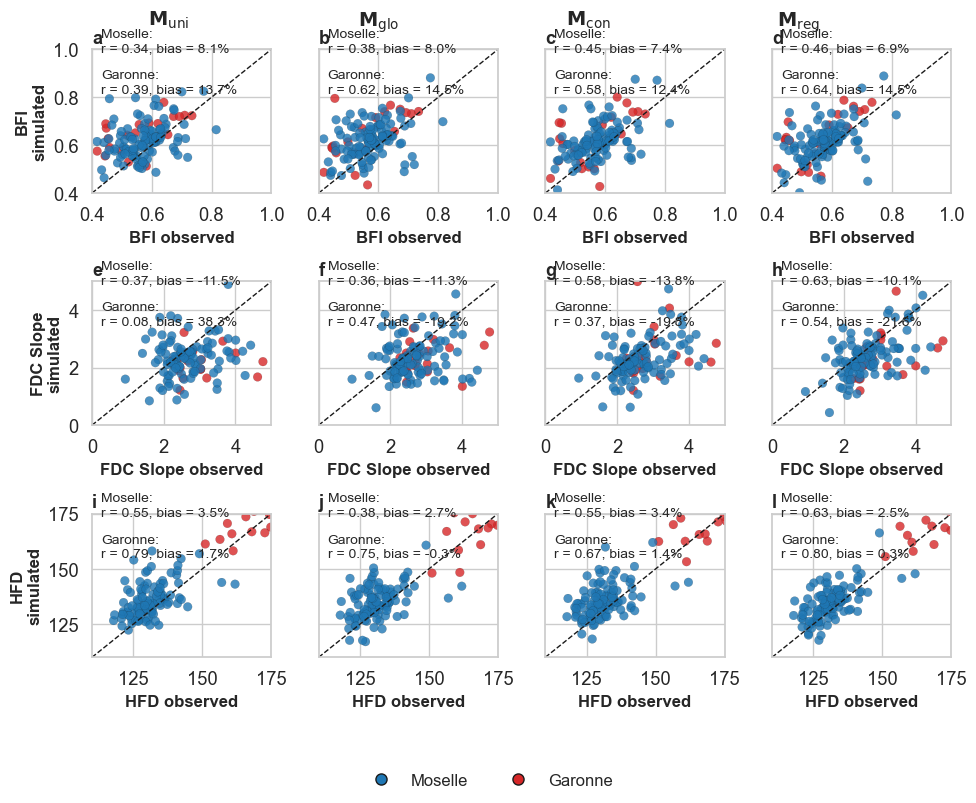

In [100]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import string
from matplotlib.lines import Line2D

# =========================================================
# SEABORN STYLE
# =========================================================
sns.set(style="whitegrid", font_scale=1.2)

# =========================================================
# METRICS AND TITLES
# =========================================================
metrics = ['bfi', 'slope', 'hfd']
metric_titles = ['BFI', 'FDC Slope', 'HFD']

suffixes = ['nogeo',  'g1comp', 'c1comp','r1comp']
scale_titles = [
    r"$\mathbf{M_{\mathrm{uni}}}$",
    r"$\mathbf{M_{\mathrm{glo}}}$",
    r"$\mathbf{M_{\mathrm{con}}}$",
    r"$\mathbf{M_{\mathrm{reg}}}$"
]

# =========================================================
# BASIN COLORS
# =========================================================
basin_colors = {
    "moselle": "#1f77b4",
    "garonne": "#d62728",
}

moselle_ids = network_estreams_moselle_108_gauges.index.tolist()
garonne_ids = network_estreams_garonne_22_gauges.index.tolist()

def get_basin_color(gauge_id):
    if gauge_id in moselle_ids:
        return basin_colors["moselle"]
    elif gauge_id in garonne_ids:
        return basin_colors["garonne"]
    else:
        return "grey"

point_colors = data_diff_val_complete_dict_plot.index.map(get_basin_color)

# Boolean masks (USED FOR STATS)
is_moselle = data_diff_val_complete_dict_plot.index.isin(moselle_ids)
is_garonne = data_diff_val_complete_dict_plot.index.isin(garonne_ids)

# =========================================================
# CREATE FIGURE
# =========================================================
fig, axs = plt.subplots(3, 4, figsize=(10, 8), sharex=False, sharey=False)
letters = list(string.ascii_lowercase)

# =========================================================
# LOOP OVER METRICS AND MODELS
# =========================================================
for row, (metric, row_title) in enumerate(zip(metrics, metric_titles)):
    for col, suffix in enumerate(suffixes):
        ax = axs[row, col]

        var_obs  = f"{metric}_obs"
        var_pred = f"{metric}_{suffix}"

        # Scatter
        ax.scatter(
            data_diff_val_complete_dict_plot[var_obs],
            data_diff_val_complete_dict_plot[var_pred],
            c=point_colors,
            s=40,
            edgecolor='k',
            linewidth=0.1,
            alpha=0.8
        )

        # Labels
        if col == 0:
            ax.set_ylabel(f"{row_title}\nsimulated", fontsize=12, fontweight='bold')
        else:
            ax.set_ylabel("")
            ax.set_yticklabels([])

        ax.set_xlabel(f"{row_title} observed", fontsize=12, fontweight='bold')

        # -------------------------------
        # PER-BASIN STATS
        # -------------------------------
        # Moselle
        x_m = data_diff_val_complete_dict_plot.loc[is_moselle, var_obs].values
        y_m = data_diff_val_complete_dict_plot.loc[is_moselle, var_pred].values
        mask_m = ~np.isnan(x_m) & ~np.isnan(y_m)
        x_m, y_m = x_m[mask_m], y_m[mask_m]

        from scipy.stats import spearmanr
        from scipy.stats import pearsonr

        r_m = pearsonr(x_m, y_m)[0] if len(x_m) > 1 else np.nan
        bias_m = 100 * (np.mean(y_m) - np.mean(x_m)) / np.mean(x_m)

        # Garonne
        x_g = data_diff_val_complete_dict_plot.loc[is_garonne, var_obs].values
        y_g = data_diff_val_complete_dict_plot.loc[is_garonne, var_pred].values
        mask_g = ~np.isnan(x_g) & ~np.isnan(y_g)
        x_g, y_g = x_g[mask_g], y_g[mask_g]

        r_g = pearsonr(x_g, y_g)[0] if len(x_g) > 1 else np.nan
        bias_g = 100 * (np.mean(y_g) - np.mean(x_g)) / np.mean(x_g)

        # Annotation
        ax.text(
            0.05, 0.70,
            f"Moselle:\n"
            f"r = {r_m:.2f}, bias = {bias_m:.1f}%\n\n"
            f"Garonne:\n"
            f"r = {r_g:.2f}, bias = {bias_g:.1f}%",
            transform=ax.transAxes,
            fontsize=10,
            bbox=dict(facecolor='none', alpha=0.6, edgecolor='none')
        )

        # Subplot letter
        subplot_idx = row * 4 + col
        ax.text(
            0.00, 1.14, letters[subplot_idx],
            transform=ax.transAxes,
            fontsize=13,
            fontweight='bold',
            va='top',
            ha='left'
        )

        # Axis limits and 1:1 line
        if metric == 'bfi':
            ax.set_xlim(0.4, 1)
            ax.set_ylim(0.4, 1)
            ax.plot([0.4, 1], [0.4, 1], 'k--', lw=1)
        elif metric == 'slope':
            ax.set_xlim(0, 5)
            ax.set_ylim(0, 5)
            ax.plot([0, 5], [0, 5], 'k--', lw=1)
        elif metric == 'hfd':
            ax.set_xlim(110, 175)
            ax.set_ylim(110, 175)
            ax.plot([110, 175], [110, 175], 'k--', lw=1)

# =========================================================
# LEGEND
# =========================================================
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Moselle',
           markerfacecolor=basin_colors["moselle"], markersize=8, markeredgecolor='k'),
    Line2D([0], [0], marker='o', color='w', label='Garonne',
           markerfacecolor=basin_colors["garonne"], markersize=8, markeredgecolor='k'),
]

fig.legend(
    handles=legend_elements,
    loc="lower center",
    ncol=2,
    frameon=False,
    fontsize=12
)

# Column titles
col_positions = [0.18, 0.39, 0.6, 0.81]
for x, title in zip(col_positions, scale_titles):
    fig.text(x, 0.99, title, ha='center', va='top',
             fontsize=14, fontweight='bold')

# =========================================================
# FINAL LAYOUT
# =========================================================
plt.tight_layout()
plt.subplots_adjust(top=0.94, bottom=0.18)

# plt.savefig("../results/figs/signatures_by_basin.png", dpi=300)
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import string
from matplotlib.lines import Line2D

# =========================================================
# SEABORN STYLE
# =========================================================
sns.set(style="whitegrid", font_scale=1.2)

# =========================================================
# METRICS AND TITLES
# =========================================================
metrics = ['bfi', 'slope', 'hfd']
metric_titles = ['BFI', 'FDC Slope', 'HFD']

suffixes = ['nogeo', 'c1comp', 'g1comp', 'r1comp']
scale_titles = [
    r"$\mathbf{M_{\mathrm{uni}}}$",
    r"$\mathbf{M_{\mathrm{glo}}}$",
    r"$\mathbf{M_{\mathrm{con}}}$",
    r"$\mathbf{M_{\mathrm{reg}}}$"
]

# =========================================================
# BASIN COLORS
# =========================================================
basin_colors = {
    "moselle": "#1f77b4",
    "garonne": "#d62728",
}

moselle_ids = network_estreams_moselle_108_gauges.index.tolist()
garonne_ids = network_estreams_garonne_22_gauges.index.tolist()

def get_basin_color(gauge_id):
    if gauge_id in moselle_ids:
        return basin_colors["moselle"]
    elif gauge_id in garonne_ids:
        return basin_colors["garonne"]
    else:
        return "grey"

point_colors = data_diff_val_complete_dict_plot.index.map(get_basin_color)

# Boolean masks (USED FOR STATS)
is_moselle = data_diff_val_complete_dict_plot.index.isin(moselle_ids)
is_garonne = data_diff_val_complete_dict_plot.index.isin(garonne_ids)

# =========================================================
# CREATE FIGURE
# =========================================================
fig, axs = plt.subplots(3, 4, figsize=(10, 8), sharex=False, sharey=False)
letters = list(string.ascii_lowercase)

# =========================================================
# LOOP OVER METRICS AND MODELS
# =========================================================
for row, (metric, row_title) in enumerate(zip(metrics, metric_titles)):
    for col, suffix in enumerate(suffixes):
        ax = axs[row, col]

        var_obs  = f"{metric}_obs"
        var_pred = f"{metric}_{suffix}"

        # Scatter
        ax.scatter(
            data_diff_val_complete_dict_plot[var_obs],
            data_diff_val_complete_dict_plot[var_pred],
            c=point_colors,
            s=40,
            edgecolor='k',
            linewidth=0.1,
            alpha=0.8
        )

        # Labels
        if col == 0:
            ax.set_ylabel(f"{row_title}\nsimulated", fontsize=12, fontweight='bold')
        else:
            ax.set_ylabel("")
            ax.set_yticklabels([])

        ax.set_xlabel(f"{row_title} observed", fontsize=12, fontweight='bold')

        # -------------------------------
        # PER-BASIN STATS
        # -------------------------------
        # Moselle
        x_m = data_diff_val_complete_dict_plot.loc[is_moselle, var_obs].values
        y_m = data_diff_val_complete_dict_plot.loc[is_moselle, var_pred].values
        mask_m = ~np.isnan(x_m) & ~np.isnan(y_m)
        x_m, y_m = x_m[mask_m], y_m[mask_m]

        r_m = np.corrcoef(x_m, y_m)[0, 1] if len(x_m) > 1 else np.nan
        bias_m = 100 * (np.mean(y_m) - np.mean(x_m)) / np.mean(x_m)

        # Garonne
        x_g = data_diff_val_complete_dict_plot.loc[is_garonne, var_obs].values
        y_g = data_diff_val_complete_dict_plot.loc[is_garonne, var_pred].values
        mask_g = ~np.isnan(x_g) & ~np.isnan(y_g)
        x_g, y_g = x_g[mask_g], y_g[mask_g]

        r_g = np.corrcoef(x_g, y_g)[0, 1] if len(x_g) > 1 else np.nan
        bias_g = 100 * (np.mean(y_g) - np.mean(x_g)) / np.mean(x_g)

        # Annotation
        ax.text(
            0.05, 0.70,
            f"Moselle:\n"
            f"r = {r_m:.2f}, bias = {bias_m:.1f}%\n\n"
            f"Garonne:\n"
            f"r = {r_g:.2f}, bias = {bias_g:.1f}%",
            transform=ax.transAxes,
            fontsize=10,
            bbox=dict(facecolor='none', alpha=0.6, edgecolor='none')
        )

        # Subplot letter
        subplot_idx = row * 4 + col
        ax.text(
            0.00, 1.14, letters[subplot_idx],
            transform=ax.transAxes,
            fontsize=13,
            fontweight='bold',
            va='top',
            ha='left'
        )

        # Axis limits and 1:1 line
        if metric == 'bfi':
            ax.set_xlim(0.4, 1)
            ax.set_ylim(0.4, 1)
            ax.plot([0.4, 1], [0.4, 1], 'k--', lw=1)
        elif metric == 'slope':
            ax.set_xlim(0, 5)
            ax.set_ylim(0, 5)
            ax.plot([0, 5], [0, 5], 'k--', lw=1)
        elif metric == 'hfd':
            ax.set_xlim(110, 175)
            ax.set_ylim(110, 175)
            ax.plot([110, 175], [110, 175], 'k--', lw=1)

# =========================================================
# LEGEND
# =========================================================
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Moselle',
           markerfacecolor=basin_colors["moselle"], markersize=8, markeredgecolor='k'),
    Line2D([0], [0], marker='o', color='w', label='Garonne',
           markerfacecolor=basin_colors["garonne"], markersize=8, markeredgecolor='k'),
]

fig.legend(
    handles=legend_elements,
    loc="lower center",
    ncol=2,
    frameon=False,
    fontsize=12
)

# Column titles
col_positions = [0.18, 0.39, 0.6, 0.81]
for x, title in zip(col_positions, scale_titles):
    fig.text(x, 0.99, title, ha='center', va='top',
             fontsize=14, fontweight='bold')

# =========================================================
# FINAL LAYOUT
# =========================================================
plt.tight_layout()
plt.subplots_adjust(top=0.94, bottom=0.18)

# plt.savefig("../results/figs/signatures_by_basin.png", dpi=300)
plt.show()


<Axes: >

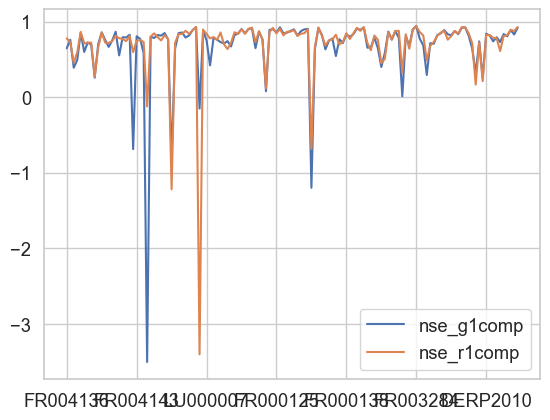

In [163]:
data_diff_val_complete_dict_plot[["nse_g1comp", "nse_r1comp"]].plot()

<Axes: >

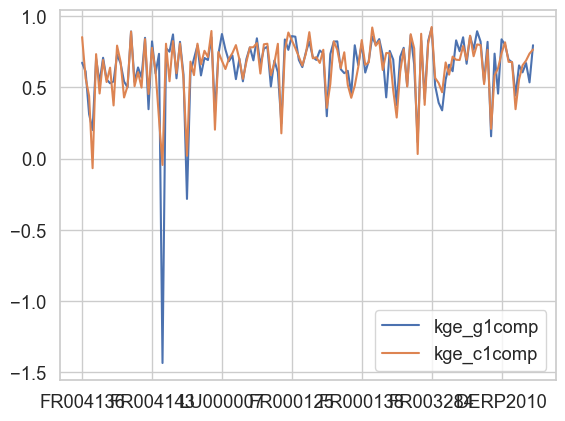

In [162]:
data_diff_val_complete_dict_plot[["kge_g1comp", "kge_c1comp"]].plot()

<Axes: >

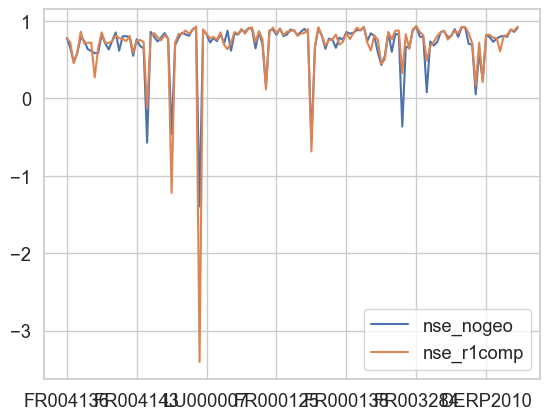

In [165]:
data_diff_val_complete_dict_plot[["nse_nogeo", "nse_r1comp"]].plot()

In [48]:
import numpy as np
import pandas as pd
import xarray as xr
import tqdm

from neuralhydrology.evaluation.signatures import (
    baseflow_index,
    hfd_mean,
    slope_fdc,
    q_mean,
)

# =========================================================
# CONFIG
# =========================================================
MIN_VALID_POINTS = 365
start_date = "1989-10-01"
end_date   = "2015-09-30"

# =========================================================
# LOAD DATA
# =========================================================
ds = xr.open_dataset("../results/sim/lstm/simu_lstm.nc")

selected_gauge_ids = network_estreams_garonne_and_moselle.index.unique().tolist()

ds_clipped = ds.sel(
    sample=ds.gauge_id.isin(selected_gauge_ids),
    date=slice(start_date, end_date)
)

# =========================================================
# NSE
# =========================================================
nse_results = {}

for i in range(ds_clipped.dims["sample"]):
    gauge = ds_clipped.gauge_id.values[i]
    ts = ds_clipped.isel(sample=i)

    obs = ts["observation"].values

    if np.sum(~np.isnan(obs)) < MIN_VALID_POINTS:
        continue

    nse_results.setdefault(gauge, []).append({
        "nse_nogeo": compute_nse(obs, ts["nogeo"].values),
        "nse_g1comp": compute_nse(obs, ts["global"].values),
        "nse_r1comp": compute_nse(obs, ts["regional"].values),
    })

nse_final = {
    g: pd.DataFrame(v).mean().to_dict()
    for g, v in nse_results.items()
}

nse_df = pd.DataFrame.from_dict(nse_final, orient="index")

# =========================================================
# SIGNATURE FUNCTIONS (NH-CORRECT)
# =========================================================
def common_mask(sim, obs):
    mask = (~np.isnan(obs)) & (~np.isnan(sim))
    sim_m = sim[mask]
    obs_m = obs[mask]
    return sim_m, obs_m, mask

def to_da(values, dates):
    return xr.DataArray(values, coords={"date": dates}, dims=("date",))

def safe_bfi(sim, obs):
    masked_sim = sim[~np.isnan(obs)]
    masked_sim = masked_sim[~np.isnan(masked_sim)]
    if len(masked_sim) < MIN_VALID_POINTS:
        return np.nan
    return baseflow_index(masked_sim, alpha=0.925, warmup=365, n_passes=3)[0]

def safe_hfd(sim, obs):
    masked_sim = sim[~np.isnan(obs)]
    masked_sim = masked_sim[~np.isnan(masked_sim)]
    if len(masked_sim) < MIN_VALID_POINTS:
        return np.nan
    return hfd_mean(masked_sim, datetime_coord="date")

def safe_slope(sim, obs):
    masked_sim = sim[~np.isnan(obs)]
    masked_sim = masked_sim[~np.isnan(masked_sim)]
    if len(masked_sim) < MIN_VALID_POINTS:
        return np.nan
    return slope_fdc(masked_sim)

def safe_qmean(sim, obs):
    masked_sim = sim[~np.isnan(obs)]
    masked_sim = masked_sim[~np.isnan(masked_sim)]
    if len(masked_sim) < MIN_VALID_POINTS:
        return np.nan
    return q_mean(masked_sim)

# =========================================================
# SIGNATURES
# =========================================================
signature_results = {}

for i in tqdm.tqdm(range(ds_clipped.dims["sample"])):
    gauge = ds_clipped.gauge_id.values[i]
    ts = ds_clipped.isel(sample=i)

    obs = ts["observation"].values
    dates = ts["date"].values

    if np.sum(~np.isnan(obs)) < MIN_VALID_POINTS:
        continue

    row = {
        "bfi_obs":   safe_bfi(obs, obs),
        "hfd_obs":   safe_hfd(obs, obs, dates),
        "slope_obs": safe_slope(obs, obs, dates),
        "qmean_obs": safe_qmean(obs, obs),
    }

    for tag in ["nogeo", "global", "regional"]:
        sim = ts[tag].values
        row[f"bfi_{tag}"]   = safe_bfi(sim, obs, dates)
        row[f"hfd_{tag}"]   = safe_hfd(sim, obs, dates)
        row[f"slope_{tag}"] = safe_slope(sim, obs, dates)
        row[f"qmean_{tag}"] = safe_qmean(sim, obs)

    signature_results.setdefault(gauge, []).append(row)

signature_final = {
    g: pd.DataFrame(v).mean().to_dict()
    for g, v in signature_results.items()
}

signature_df = pd.DataFrame.from_dict(signature_final, orient="index")

# =========================================================
# MERGE + FINAL TABLE
# =========================================================
data_diff_cal_complete_dict_plot = nse_df.join(signature_df, how="left")
data_diff_cal_complete_dict_plot

/var/folders/sd/ytjf58757690_xfckxng56q00000gq/T/ipykernel_39117/3121282421.py:37: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  for i in range(ds_clipped.dims["sample"]):
/var/folders/sd/ytjf58757690_xfckxng56q00000gq/T/ipykernel_39117/1818970985.py:27: RuntimeWarning: invalid value encountered in sqrt
  metric = 1 - np.sum((sim**expo - obs**expo)**2) / np.sum((obs**expo - np.mean(obs**expo))**2)
/var/folders/sd/ytjf58757690_xfckxng56q00000gq/T/ipykernel_39117/3121282421.py:104: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  for i in tqdm.tqdm(range(ds_clipped.dims["sample"])):
  0%|      

AttributeError: 'numpy.ndarray' object has no attribute 'coords'

In [ ]:
import pickle
import pandas as pd
from tqdm import tqdm
from pathlib import Path
import re
from neuralhydrology.evaluation.signatures import (
    baseflow_index, slope_fdc, q95, q5, q_mean, hfd_mean,
    low_q_freq, low_q_dur, high_q_freq, high_q_dur, zero_q_freq
)

# === Paths ===
test_folder = Path("/Users/nascimth/Library/CloudStorage/OneDrive-Eawag/Eawag/Papers/Moselle_superflexpy/GitHub/estreams_superflexpy/results/LSTM/")
test_basin_files = {
    1: "../data/test1.txt",
    2: "../data/test2.txt",
    3: "../data/test3.txt",
    4: "../data/test4.txt",
    5: "../data/test5.txt",
}

# === Helper: find model files ===
model_files = {}

for subfolder in test_folder.iterdir():
    if not subfolder.is_dir():
        continue

    match = re.search(r"moselle_(?:glo|reg|nog)_(\d+)_", subfolder.name)
    if not match:
        continue

    group_number = int(match.group(1))

    if "glo" in subfolder.name:
        model_type = "glo"
    elif "reg" in subfolder.name:
        model_type = "reg"
    elif "nog" in subfolder.name:
        model_type = "nog"
    else:
        continue

    for model_epoch_folder in subfolder.glob("test/model_epoch*/"):
        test_result_file = model_epoch_folder / "test_results.p"
        if test_result_file.exists():
            model_files.setdefault(group_number, {})[model_type] = test_result_file
            break

# === Collect results ===
all_results = []

for model_idx in range(1, 6):
    with open(test_basin_files[model_idx], "r") as f:
        val_basins = [line.strip() for line in f if line.strip()]

    try:
        with open(model_files[model_idx]["glo"], "rb") as fp:
            sim_glob = pickle.load(fp)
        with open(model_files[model_idx]["reg"], "rb") as fp:
            sim_earls = pickle.load(fp)
        with open(model_files[model_idx]["nog"], "rb") as fp:
            sim_nog = pickle.load(fp)
    except FileNotFoundError:
        print(f"Missing model files for model {model_idx}")
        continue

    for basin_id in tqdm(val_basins, desc=f"Model {model_idx}"):
        if basin_id not in sim_glob:
            continue

        row = {
            "basin_id": basin_id,
            "model": model_idx,
        }

        def compute_all_signatures(q_series):
            # Convert to numpy / pandas-friendly array
            q_series = q_series.squeeze()

            # --- CLIP NEGATIVE VALUES ---
            q_series = q_series.where(q_series >= 0, 0)

            results = {
                "q_mean": q_mean(q_series),
                "q5": q5(q_series),
                "q95": q95(q_series),
                "hfd_mean": hfd_mean(q_series),
                "low_q_freq": low_q_freq(q_series),
                "low_q_dur": low_q_dur(q_series),
                "high_q_freq": high_q_freq(q_series),
                "high_q_dur": high_q_dur(q_series),
                "zero_q_freq": zero_q_freq(q_series),
                "slopeFDC": slope_fdc(q_series),
                "bfi": baseflow_index(
                    q_series, alpha=0.925, warmup=365, n_passes=3
                )[0],
            }

            return {k: round(float(v), 3) for k, v in results.items()}


        # === Observed ===
        qobs_da = sim_glob[basin_id]["1D"]["xr"]["q_mean_obs"]
        row.update({f"{k}_obs": v for k, v in compute_all_signatures(qobs_da).items()})
        
        #  Sim NOG
        qsim_nog = sim_nog[basin_id]["1D"]["xr"]["q_mean_sim"]
        row.update({f"{k}_sim_nog": v for k, v in compute_all_signatures(qsim_nog).items()})
        nse_nog = sim_nog[basin_id]["1D"].get("NSE")
        if nse_nog is not None:
            row["NSE_nog"] = round(float(nse_nog), 3)

        #  Sim GLO
        qsim_glob = sim_glob[basin_id]["1D"]["xr"]["q_mean_sim"]
        row.update({f"{k}_sim_glo": v for k, v in compute_all_signatures(qsim_glob).items()})
        nse_glob = sim_glob[basin_id]["1D"].get("NSE")
        if nse_glob is not None:
            row["NSE_glo"] = round(float(nse_glob), 3)

        #  Sim REG
        if basin_id in sim_earls:
            qsim_earls = sim_earls[basin_id]["1D"]["xr"]["q_mean_sim"]
            row.update({f"{k}_sim_reg": v for k, v in compute_all_signatures(qsim_earls).items()})
            nse_earls = sim_earls[basin_id]["1D"].get("NSE")
            if nse_earls is not None:
                row["NSE_reg"] = round(float(nse_earls), 3)

        all_results.append(row)

# === Save result ===
if all_results:
    df_all = pd.DataFrame(all_results)
    df_all = df_all.groupby("basin_id", as_index=False).mean(numeric_only=True)
    df_all.to_csv("../results/LSTM_signatures.csv", index=False)

Model 5: 100%|██████████| 26/26 [00:01<00:00, 14.51it/s]


In [112]:
import pickle
import numpy as np
import pandas as pd
from tqdm import tqdm
from pathlib import Path
import re
import xarray as xr

from neuralhydrology.evaluation.signatures import (
    baseflow_index, slope_fdc, q95, q5, q_mean, hfd_mean,
    low_q_freq, low_q_dur, high_q_freq, high_q_dur, zero_q_freq
)

# =========================================================
# CONFIG
# =========================================================
MIN_VALID_POINTS = 365
TIME_DIM_CANDIDATES = ["date", "time"]
WARMUP_DAYS = 365

# =========================================================
# PATHS
# =========================================================
test_folder = Path(
    "/Users/nascimth/Library/CloudStorage/OneDrive-Eawag/"
    "Eawag/Papers/Moselle_superflexpy/GitHub/"
    "estreams_superflexpy/results/LSTM/"
)

test_basin_files = {
    1: "../data/test1.txt",
    2: "../data/test2.txt",
    3: "../data/test3.txt",
    4: "../data/test4.txt",
    5: "../data/test5.txt",
}

# =========================================================
# FIND MODEL FILES
# =========================================================
model_files = {}

for subfolder in test_folder.iterdir():
    if not subfolder.is_dir():
        continue

    match = re.search(r"moselle_(?:glo|reg|nog)_(\d+)_", subfolder.name)
    if not match:
        continue

    group_number = int(match.group(1))

    if "glo" in subfolder.name:
        model_type = "glo"
    elif "reg" in subfolder.name:
        model_type = "reg"
    elif "nog" in subfolder.name:
        model_type = "nog"
    else:
        continue

    for model_epoch_folder in subfolder.glob("test/model_epoch*/"):
        test_result_file = model_epoch_folder / "test_results.p"
        if test_result_file.exists():
            model_files.setdefault(group_number, {})[model_type] = test_result_file
            break

# =========================================================
# HELPERS
# =========================================================
def to_1d_timeseries(da):
    """
    Convert to 1-D time series and apply global warm-up.
    """
    # Select time dimension
    for dim in ["date", "time"]:
        if dim in da.dims:
            da = da.isel({dim: slice(WARMUP_DAYS, None)})
            return da.squeeze()

    raise ValueError(f"No time dimension found in DataArray dims: {da.dims}")



def safe_mask(sim, obs):
    sim = sim.where(sim >= 0, 0)
    sim = sim.where(~np.isnan(obs))
    if sim.count() < MIN_VALID_POINTS:
        return None
    return sim


SIG_NAMES = [
    "q_mean", "q5", "q95", "hfd_mean",
    "low_q_freq", "low_q_dur",
    "high_q_freq", "high_q_dur",
    "zero_q_freq", "slopeFDC", "bfi"
]

# =========================================================
# SIGNATURE COMPUTATION
# =========================================================
def compute_obs_signatures(q):
    q = to_1d_timeseries(q)
    q = q.where(q >= 0, 0)

    if q.count() < MIN_VALID_POINTS:
        return {k: np.nan for k in SIG_NAMES}

    return {
        "q_mean": q_mean(q),
        "q5": q5(q),
        "q95": q95(q),
        "hfd_mean": hfd_mean(q, datetime_coord="date"),
        "low_q_freq": low_q_freq(q),
        "low_q_dur": low_q_dur(q),
        "high_q_freq": high_q_freq(q),
        "high_q_dur": high_q_dur(q),
        "zero_q_freq": zero_q_freq(q),
        "slopeFDC": slope_fdc(q),
        "bfi": baseflow_index(q, alpha=0.925, warmup=365, n_passes=3)[0],
    }


def compute_sim_signatures(q_sim, q_obs):
    q_sim = to_1d_timeseries(q_sim)
    q_obs = to_1d_timeseries(q_obs)

    q = safe_mask(q_sim, q_obs)
    if q is None:
        return {k: np.nan for k in SIG_NAMES}

    return {
        "q_mean": q_mean(q),
        "q5": q5(q),
        "q95": q95(q),
        "hfd_mean": hfd_mean(q, datetime_coord="date"),
        "low_q_freq": low_q_freq(q),
        "low_q_dur": low_q_dur(q),
        "high_q_freq": high_q_freq(q),
        "high_q_dur": high_q_dur(q),
        "zero_q_freq": zero_q_freq(q),
        "slopeFDC": slope_fdc(q),
        "bfi": baseflow_index(q, alpha=0.925, warmup=365, n_passes=3)[0],
    }

# =========================================================
# COLLECT RESULTS
# =========================================================
all_results = []

for model_idx in range(1, 6):
    with open(test_basin_files[model_idx], "r") as f:
        val_basins = [l.strip() for l in f if l.strip()]

    try:
        sim_glo = pickle.load(open(model_files[model_idx]["glo"], "rb"))
        sim_reg = pickle.load(open(model_files[model_idx]["reg"], "rb"))
        sim_nog = pickle.load(open(model_files[model_idx]["nog"], "rb"))
    except Exception:
        print(f"Missing model files for model {model_idx}")
        continue

    for basin_id in tqdm(val_basins, desc=f"Model {model_idx}"):
        if basin_id not in sim_glo:
            continue

        row = {"basin_id": basin_id, "model": model_idx}

        qobs = sim_glo[basin_id]["1D"]["xr"]["q_mean_obs"]

        row.update({
            f"{k}_obs": round(v, 3)
            for k, v in compute_obs_signatures(qobs).items()
        })

        for tag, sim_dict in {
            "nog": sim_nog,
            "glo": sim_glo,
            "reg": sim_reg,
        }.items():
            if basin_id not in sim_dict:
                continue

            qsim = sim_dict[basin_id]["1D"]["xr"]["q_mean_sim"]

            row.update({
                f"{k}_sim_{tag}": round(v, 3)
                for k, v in compute_sim_signatures(qsim, qobs).items()
            })

            nse = sim_dict[basin_id]["1D"].get("NSE")
            if nse is not None:
                row[f"NSE_{tag}"] = round(float(nse), 3)

        all_results.append(row)

# =========================================================
# FINAL DATAFRAME
# =========================================================
df_all = pd.DataFrame(all_results)
df_all = df_all.groupby("basin_id", as_index=False).mean(numeric_only=True)
df_all.to_csv("../results/LSTM_signatures.csv", index=False)


Model 5: 100%|██████████| 26/26 [00:01<00:00, 15.37it/s]


In [18]:
import pickle
import numpy as np
import pandas as pd
from tqdm import tqdm
from pathlib import Path
import re
import xarray as xr

from neuralhydrology.evaluation.signatures import (
    baseflow_index, slope_fdc, q95, q5, q_mean, hfd_mean,
    low_q_freq, low_q_dur, high_q_freq, high_q_dur, zero_q_freq
)

# =========================================================
# CONFIG
# =========================================================
MIN_VALID_POINTS = 365
TIME_DIM_CANDIDATES = ["date", "time"]
WARMUP_DAYS = 365

# =========================================================
# PATHS
# =========================================================
test_folder = Path(
    "/Users/nascimth/Library/CloudStorage/OneDrive-Eawag/"
    "Eawag/Papers/Moselle_superflexpy/GitHub/"
    "estreams_superflexpy/results/LSTM/"
)

test_basin_files = {
    1: "../data/test1.txt",
    2: "../data/test2.txt",
    3: "../data/test3.txt",
    4: "../data/test4.txt",
    5: "../data/test5.txt",
}

# =========================================================
# FIND MODEL FILES
# =========================================================
model_files = {}

for subfolder in test_folder.iterdir():
    if not subfolder.is_dir():
        continue

    match = re.search(r"moselle_(?:glo|reg|nog)_(\d+)_", subfolder.name)
    if not match:
        continue

    group_number = int(match.group(1))

    if "glo" in subfolder.name:
        model_type = "glo"
    elif "reg" in subfolder.name:
        model_type = "reg"
    elif "nog" in subfolder.name:
        model_type = "nog"
    else:
        continue

    for model_epoch_folder in subfolder.glob("test/model_epoch*/"):
        test_result_file = model_epoch_folder / "test_results.p"
        if test_result_file.exists():
            model_files.setdefault(group_number, {})[model_type] = test_result_file
            break

# =========================================================
# HELPERS
# =========================================================
def to_1d_timeseries(da):
    """
    Convert to 1-D time series and apply global warm-up.
    """
    for dim in ["date", "time"]:
        if dim in da.dims:
            da = da.isel({dim: slice(WARMUP_DAYS, None)})

            # explicitly ensure 1D
            if da.ndim != 1:
                da = da.squeeze(drop=True)

            if da.ndim != 1:
                raise ValueError(
                    f"Expected 1D time series, got dims={da.dims}"
                )

            return da

    raise ValueError(f"No time dimension found in DataArray dims: {da.dims}")



def safe_mask(sim, obs):
    sim = sim.where(sim >= 0, 0)
    sim = sim.where(~np.isnan(obs))
    if sim.count() < MIN_VALID_POINTS:
        return None
    return sim


def prepare_sim_obs(q_sim, q_obs):
    q_sim = to_1d_timeseries(q_sim)
    q_obs = to_1d_timeseries(q_obs)

    q_sim = q_sim.where(q_sim >= 0, 0)
    q_obs = q_obs.where(q_obs >= 0, 0)

    q_sim = q_sim.where(~np.isnan(q_obs))

    if q_sim.count() < MIN_VALID_POINTS:
        return None, None

    return q_obs.values, q_sim.values


# =========================================================
# OBJECTIVE FUNCTIONS
# =========================================================
def obj_fun_nsee(observations, simulation, expo=1):
    observations = np.asarray(observations)
    simulation = np.asarray(simulation)

    mask = ~np.isnan(observations)
    obs = observations[mask]
    sim = simulation[mask]

    if np.isnan(sim).any():
        return 10.0

    return float(
        np.sum((sim**expo - obs**expo)**2)
        / np.sum((obs**expo - np.mean(obs**expo))**2)
    )


def obj_fun_kge(observations, simulation):
    observations = np.asarray(observations)
    simulation = np.asarray(simulation)

    mask = ~np.isnan(observations)
    obs = observations[mask]
    sim = simulation[mask]

    if np.isnan(sim).any():
        return 10.0

    r = np.corrcoef(obs, sim)[0, 1]
    alpha = np.std(sim) / np.std(obs)
    beta = np.mean(sim) / np.mean(obs)

    return float(np.sqrt((r - 1)**2 + (alpha - 1)**2 + (beta - 1)**2))


# =========================================================
# SIGNATURES
# =========================================================
SIG_NAMES = [
    "q_mean", "q5", "q95", "hfd_mean",
    "low_q_freq", "low_q_dur",
    "high_q_freq", "high_q_dur",
    "zero_q_freq", "slopeFDC", "bfi"
]


def compute_obs_signatures(q):
    q = to_1d_timeseries(q)
    q = q.where(q >= 0, 0)
    print(q.count())

    if q.count() < MIN_VALID_POINTS:
        return {k: np.nan for k in SIG_NAMES}

    return {
        "q_mean": q_mean(q),
        "q5": q5(q),
        "q95": q95(q),
        "hfd_mean": hfd_mean(q, datetime_coord="date"),
        "low_q_freq": low_q_freq(q),
        "low_q_dur": low_q_dur(q),
        "high_q_freq": high_q_freq(q),
        "high_q_dur": high_q_dur(q),
        "zero_q_freq": zero_q_freq(q),
        "slopeFDC": slope_fdc(q),
        "bfi": baseflow_index(q, alpha=0.925, warmup=365, n_passes=3)[0],
    }


def compute_sim_signatures(q_sim, q_obs):
    q_sim = to_1d_timeseries(q_sim)
    q_obs = to_1d_timeseries(q_obs)

    q = safe_mask(q_sim, q_obs)
    if q is None:
        return {k: np.nan for k in SIG_NAMES}

    return {
        "q_mean": q_mean(q),
        "q5": q5(q),
        "q95": q95(q),
        "hfd_mean": hfd_mean(q, datetime_coord="date"),
        "low_q_freq": low_q_freq(q),
        "low_q_dur": low_q_dur(q),
        "high_q_freq": high_q_freq(q),
        "high_q_dur": high_q_dur(q),
        "zero_q_freq": zero_q_freq(q),
        "slopeFDC": slope_fdc(q),
        "bfi": baseflow_index(q, alpha=0.925, warmup=365, n_passes=3)[0],
    }


# =========================================================
# COLLECT RESULTS
# =========================================================
all_results = []

for model_idx in range(1, 6):
    with open(test_basin_files[model_idx], "r") as f:
        val_basins = [l.strip() for l in f if l.strip()]

    try:
        sim_glo = pickle.load(open(model_files[model_idx]["glo"], "rb"))
        sim_reg = pickle.load(open(model_files[model_idx]["reg"], "rb"))
        sim_nog = pickle.load(open(model_files[model_idx]["nog"], "rb"))
    except Exception:
        print(f"Missing model files for model {model_idx}")
        continue

    for basin_id in tqdm(val_basins, desc=f"Model {model_idx}"):
        if basin_id not in sim_glo:
            continue

        row = {"basin_id": basin_id, "model": model_idx}

        qobs = sim_glo[basin_id]["1D"]["xr"]["q_mean_obs"]

        row.update({
            f"{k}_obs": round(v, 3)
            for k, v in compute_obs_signatures(qobs).items()
        })

        for tag, sim_dict in {
            "nog": sim_nog,
            "glo": sim_glo,
            "reg": sim_reg,
        }.items():
            if basin_id not in sim_dict:
                continue

            qsim = sim_dict[basin_id]["1D"]["xr"]["q_mean_sim"]

            row.update({
                f"{k}_sim_{tag}": round(v, 3)
                for k, v in compute_sim_signatures(qsim, qobs).items()
            })

            obs_arr, sim_arr = prepare_sim_obs(qsim, qobs)

            if obs_arr is None:
                row[f"NSE_{tag}"] = np.nan
                row[f"KGE_{tag}"] = np.nan
            else:
                row[f"NSE_{tag}"] = round(
                    1-obj_fun_nsee(obs_arr, sim_arr, expo=0.5), 3
                )
                row[f"KGE_{tag}"] = round(
                    1-obj_fun_kge(obs_arr, sim_arr), 3
                )

        all_results.append(row)

# =========================================================
# FINAL DATAFRAME
# =========================================================
df_all = pd.DataFrame(all_results)
df_all = df_all.groupby("basin_id", as_index=False).mean(numeric_only=True)
df_all.to_csv("../results/LSTM_signatures.csv", index=False)


Model 1:   8%|▊         | 2/26 [00:00<00:01, 12.85it/s]

<xarray.DataArray 'q_mean_obs' ()> Size: 8B
array(5113)
<xarray.DataArray 'q_mean_obs' ()> Size: 8B
array(5113)
<xarray.DataArray 'q_mean_obs' ()> Size: 8B
array(5113)


Model 1:  23%|██▎       | 6/26 [00:00<00:01, 15.46it/s]

<xarray.DataArray 'q_mean_obs' ()> Size: 8B
array(5113)
<xarray.DataArray 'q_mean_obs' ()> Size: 8B
array(5113)
<xarray.DataArray 'q_mean_obs' ()> Size: 8B
array(5113)
<xarray.DataArray 'q_mean_obs' ()> Size: 8B
array(5113)


Model 1:  38%|███▊      | 10/26 [00:00<00:00, 16.12it/s]

...

<xarray.DataArray 'q_mean_obs' ()> Size: 8B
array(5113)
<xarray.DataArray 'q_mean_obs' ()> Size: 8B
array(5113)
<xarray.DataArray 'q_mean_obs' ()> Size: 8B
array(5113)
<xarray.DataArray 'q_mean_obs' ()> Size: 8B
array(5113)


Model 5:  85%|████████▍ | 22/26 [00:01<00:00, 15.25it/s]

<xarray.DataArray 'q_mean_obs' ()> Size: 8B
array(5113)
<xarray.DataArray 'q_mean_obs' ()> Size: 8B
array(5113)
<xarray.DataArray 'q_mean_obs' ()> Size: 8B
array(5113)
<xarray.DataArray 'q_mean_obs' ()> Size: 8B
array(5113)


Model 5: 100%|██████████| 26/26 [00:01<00:00, 14.79it/s]

<xarray.DataArray 'q_mean_obs' ()> Size: 8B
array(5113)
<xarray.DataArray 'q_mean_obs' ()> Size: 8B
array(5113)


In [ ]:
import pickle
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm import tqdm
import re
import xarray as xr

from neuralhydrology.evaluation.signatures import (
    baseflow_index,
    slope_fdc,
    q_mean,
    hfd_mean,
)

# =========================================================
# CONFIG
# =========================================================
MIN_VALID_POINTS = 365

test_folder = Path(
    "/Users/nascimth/Library/CloudStorage/OneDrive-Eawag/"
    "Eawag/Papers/Moselle_superflexpy/GitHub/"
    "estreams_superflexpy/results/LSTM/"
)

test_basin_files = {
    1: "../data/test1.txt",
    2: "../data/test2.txt",
    3: "../data/test3.txt",
    4: "../data/test4.txt",
    5: "../data/test5.txt",
}

# =========================================================
# FIND MODEL FILES
# =========================================================
model_files = {}

for subfolder in test_folder.iterdir():
    if not subfolder.is_dir():
        continue

    match = re.search(r"moselle_(?:glo|reg|nog)_(\d+)_", subfolder.name)
    if not match:
        continue

    group_number = int(match.group(1))

    if "glo" in subfolder.name:
        model_type = "glo"
    elif "reg" in subfolder.name:
        model_type = "reg"
    elif "nog" in subfolder.name:
        model_type = "nog"
    else:
        continue

    for model_epoch_folder in subfolder.glob("test/model_epoch*/"):
        test_result_file = model_epoch_folder / "test_results.p"
        if test_result_file.exists():
            model_files.setdefault(group_number, {})[model_type] = test_result_file
            break

# =========================================================
# HELPER: numpy → xarray (MINIMAL)
# =========================================================
def to_da(masked_sim, masked_dates):
    return xr.DataArray(
        masked_sim,
        coords={"date": masked_dates},
        dims=("date",),
    )

# =========================================================
# SIGNATURES (CORRECT FOR NH)
# =========================================================
def safe_bfi(sim, obs, dates):
    mask = (~np.isnan(obs)) & (~np.isnan(sim))
    sim_m = sim[mask]
    dates_m = dates[mask]

    if len(sim_m) < MIN_VALID_POINTS:
        return np.nan

    da = to_da(sim_m, dates_m)

    return baseflow_index(
        da,
        alpha=0.925,
        warmup=365,
        n_passes=3,
        datetime_coord="date",
    )[0]


def safe_hfd(sim, obs, dates):
    mask = (~np.isnan(obs)) & (~np.isnan(sim))
    sim_m = sim[mask]
    dates_m = dates[mask]

    if len(sim_m) < MIN_VALID_POINTS:
        return np.nan

    da = to_da(sim_m, dates_m)

    return hfd_mean(da, datetime_coord="date")


def safe_slope(sim, obs, dates, min_q=1e-6):
    # common mask
    mask = (~np.isnan(obs)) & (~np.isnan(sim))
    sim_m = sim[mask]
    dates_m = dates[mask]
    
    # enforce strictly positive flows (CRITICAL)
    pos = sim_m > min_q
    sim_m = sim_m[pos]
    dates_m = dates_m[pos]

    if len(sim_m) < MIN_VALID_POINTS:
        return np.nan
    if np.std(sim_m) == 0:
        return np.nan

    da = xr.DataArray(
        sim_m,
        coords={"date": dates_m},
        dims=("date",),
    )

    return slope_fdc(da)


def safe_qmean(sim, obs):
    mask = (~np.isnan(obs)) & (~np.isnan(sim))
    sim_m = sim[mask]

    if len(sim_m) < MIN_VALID_POINTS:
        return np.nan

    return q_mean(sim_m)

# =========================================================
# MAIN LOOP
# =========================================================
all_results = []

for model_idx in range(1, 6):
    with open(test_basin_files[model_idx], "r") as f:
        basins = [l.strip() for l in f if l.strip()]

    try:
        sim_glo = pickle.load(open(model_files[model_idx]["glo"], "rb"))
        sim_reg = pickle.load(open(model_files[model_idx]["reg"], "rb"))
        sim_nog = pickle.load(open(model_files[model_idx]["nog"], "rb"))
    except Exception:
        print(f"Missing files for model {model_idx}")
        continue

    for basin_id in tqdm(basins, desc=f"Model {model_idx}"):

        if basin_id not in sim_glo:
            continue

        qobs_da = sim_glo[basin_id]["1D"]["xr"]["q_mean_obs"]
        dates = qobs_da["date"].values
        qobs = qobs_da.squeeze("time_step").values

        row = {
            "basin_id": basin_id,
            "model": model_idx,
        }

        for tag, sim_dict in {
            "nog": sim_nog,
            "glo": sim_glo,
            "reg": sim_reg,
        }.items():

            if basin_id not in sim_dict:
                continue

            qsim_da = sim_dict[basin_id]["1D"]["xr"]["q_mean_sim"]
            qsim = qsim_da.squeeze("time_step").values

            # NSE / KGE (UNCHANGED)
            if len(qobs) >= MIN_VALID_POINTS:
                row[f"NSE_{tag}"] = 1 - obj_fun_nsee(qobs, qsim, expo=0.5)
                row[f"KGE_{tag}"] = 1 - obj_fun_kge(qobs, qsim)
            else:
                row[f"NSE_{tag}"] = np.nan
                row[f"KGE_{tag}"] = np.nan

            # SIGNATURES
            row[f"bfi_{tag}"]   = safe_bfi(qsim, qobs, dates)
            row[f"hfd_{tag}"]   = safe_hfd(qsim, qobs, dates)
            row[f"slope_{tag}"] = safe_slope(qsim, qobs, dates)
            row[f"qmean_{tag}"] = safe_qmean(qsim, qobs)

        all_results.append(row)

# =========================================================
# SAVE
# =========================================================
df = pd.DataFrame(all_results)
df = df.groupby("basin_id", as_index=False).mean(numeric_only=True)
df.to_csv("../results/LSTM_signatures_simple.csv", index=False)


Model 1:   0%|          | 0/26 [00:00<?, ?it/s]/var/folders/sd/ytjf58757690_xfckxng56q00000gq/T/ipykernel_39117/2419305426.py:132: RuntimeWarning: invalid value encountered in sqrt
  np.sum((sim**expo - obs**expo)**2)
/var/folders/sd/ytjf58757690_xfckxng56q00000gq/T/ipykernel_39117/2419305426.py:132: RuntimeWarning: invalid value encountered in sqrt
  np.sum((sim**expo - obs**expo)**2)
/var/folders/sd/ytjf58757690_xfckxng56q00000gq/T/ipykernel_39117/2419305426.py:132: RuntimeWarning: invalid value encountered in sqrt
  np.sum((sim**expo - obs**expo)**2)
/var/folders/sd/ytjf58757690_xfckxng56q00000gq/T/ipykernel_39117/2419305426.py:132: RuntimeWarning: invalid value encountered in sqrt
  np.sum((sim**expo - obs**expo)**2)
Model 1:  12%|█▏        | 3/26 [00:00<00:00, 27.47it/s]/var/folders/sd/ytjf58757690_xfckxng56q00000gq/T/ipykernel_39117/2419305426.py:132: RuntimeWarning: invalid value encountered in sqrt
  np.sum((sim**expo - obs**expo)**2)
/var/folders/sd/ytjf58757690_xfckxng56q0000

In [34]:
basin_id = "FR000169"
model_idx = 4
tag = "glo"

sim_glo = pickle.load(open(model_files[model_idx]["glo"], "rb"))

qobs_da = sim_glo[basin_id]["1D"]["xr"]["q_mean_obs"]
qsim_da = sim_glo[basin_id]["1D"]["xr"]["q_mean_sim"]

qobs = qobs_da.squeeze("time_step").values
qsim = qsim_da.squeeze("time_step").values
dates = qobs_da["date"].values

mask = (~np.isnan(qobs)) & (~np.isnan(qsim))
qobs_m = qobs[mask]
qsim_m = qsim[mask]

print("valid points obs/sim:", len(qobs_m), len(qsim_m))
print("obs min, q1%, q5%, q95%, max:",
      np.nanmin(qobs_m),
      np.nanquantile(qobs_m, 0.01),
      np.nanquantile(qobs_m, 0.05),
      np.nanquantile(qobs_m, 0.95),
      np.nanmax(qobs_m))
print("sim min, q1%, q5%, q95%, max:",
      np.nanmin(qsim_m),
      np.nanquantile(qsim_m, 0.01),
      np.nanquantile(qsim_m, 0.05),
      np.nanquantile(qsim_m, 0.95),
      np.nanmax(qsim_m))

print("obs zeros fraction:", np.mean(qobs_m <= 0))
print("sim zeros fraction:", np.mean(qsim_m <= 0))


valid points obs/sim: 2994 2994
obs min, q1%, q5%, q95%, max: 0.110000014 0.13 0.15650006 2.246997 18.81
sim min, q1%, q5%, q95%, max: -0.07075417 0.059862696 0.09535694 2.6189637 7.858661
obs zeros fraction: 0.0
sim zeros fraction: 0.0016700066800267202


In [39]:
df_all[df_all.slopeFDC_obs>4][["basin_id", "slopeFDC_obs", "slopeFDC_sim_glo", "slopeFDC_sim_reg", "slopeFDC_sim_nog"]]

,basin_id,slopeFDC_obs,slopeFDC_sim_glo,slopeFDC_sim_reg,slopeFDC_sim_nog
2,BEWA0106,4.013000,2.009,8.793000,2.447
47,FR000169,51.963001,NaN,NaN,NaN
52,FR000185,52.367001,NaN,NaN,NaN
60,FR001577,4.535000,3.318,2.689000,1.998
62,FR001592,4.005000,1.690,2.399000,2.410
74,FR003252,56.591999,NaN,NaN,NaN
76,FR003254,54.867001,NaN,NaN,NaN
79,FR003259,53.659000,NaN,NaN,NaN
83,FR003266,4.201000,2.276,1.884000,1.762
87,FR003272,4.079000,6.022,6.406000,5.884


In [126]:
df_all[["basin_id", "KGE_nog", "KGE_glo", "KGE_reg"]]

,basin_id,KGE_nog,KGE_glo,KGE_reg
0,BEWA0066,0.733,0.753,0.656
1,BEWA0067,0.728,0.687,0.849
2,BEWA0106,0.679,0.470,0.742
3,BEWA0107,0.650,0.524,0.657
4,BEWA0119,0.836,0.590,0.832
...,...,...,...,...
125,LU000015,0.574,0.402,0.498
126,LU000016,0.704,0.549,0.712
127,LU000017,0.664,0.530,0.688
128,LU000018,0.735,0.721,0.358


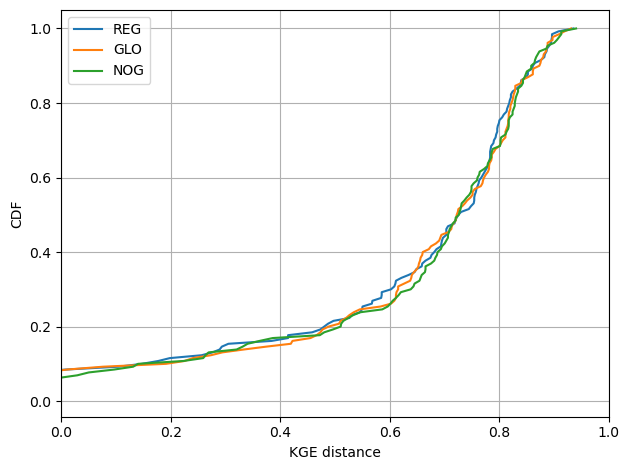

In [130]:
import numpy as np
import matplotlib.pyplot as plt

# Select data
cols = ["NSE_reg", "NSE_glo","NSE_nog"]

labels = ["REG", "GLO", "NOG"]

plt.figure()

for col, label in zip(cols, labels):
    data = df_all[col].dropna().values
    data = np.sort(data)
    cdf = np.arange(1, len(data) + 1) / len(data)

    plt.plot(data, cdf, label=label)

plt.xlabel("KGE distance")
plt.ylabel("CDF")
plt.legend()
plt.grid(True)
plt.xlim(0, 1)
plt.tight_layout()
plt.show()


Exported time series for basin BEWA0066


In [131]:
df_all[["basin_id", "KGE_nog", "NSE_glo", "NSE_reg"]]

,basin_id,KGE_nog,NSE_glo,NSE_reg
0,BEWA0066,0.733,0.875,0.813
1,BEWA0067,0.728,0.721,0.852
2,BEWA0106,0.679,0.707,0.585
3,BEWA0107,0.650,0.545,0.276
4,BEWA0119,0.836,0.741,0.837
...,...,...,...,...
125,LU000015,0.574,0.422,0.497
126,LU000016,0.704,0.225,0.611
127,LU000017,0.664,0.716,0.782
128,LU000018,0.735,0.273,0.177


In [113]:
df_all[["basin_id", "NSE_nog", "NSE_glo", "NSE_reg"]]

,basin_id,NSE_nog,NSE_glo,NSE_reg
0,BEWA0066,0.834,0.846,0.802
1,BEWA0067,0.801,0.758,0.854
2,BEWA0106,0.800,0.644,0.702
3,BEWA0107,0.597,0.606,0.588
4,BEWA0119,0.811,0.709,0.776
...,...,...,...,...
125,LU000015,0.742,0.552,0.658
126,LU000016,0.680,0.596,0.689
127,LU000017,0.793,0.693,0.810
128,LU000018,0.503,0.491,0.484


In [127]:
import pickle
import matplotlib.pyplot as plt

# =========================================================
# USER SETTINGS
# =========================================================
BASIN_ID = "BEWA0066"
WARMUP_DAYS = 365
MODEL_IDXS = range(1, 6)  # five files

# =========================================================
# HELPERS
# =========================================================
def to_1d_timeseries(da):
    for dim in ["date", "time"]:
        if dim in da.dims:
            return da.isel({dim: slice(WARMUP_DAYS, None)}).squeeze()
    raise ValueError(f"No time dimension found in {da.dims}")

# =========================================================
# READ ALL MODELS INTO ONE CONTAINER
# =========================================================
data = {
    "obs": [],
    "glo": [],
    "reg": [],
    #"con": [],
    "nog": [],
}

for model_idx in MODEL_IDXS:
    sim_glo = pickle.load(open(model_files[model_idx]["glo"], "rb"))
    sim_reg = pickle.load(open(model_files[model_idx]["reg"], "rb"))
    #sim_con = pickle.load(open(model_files[model_idx]["con"], "rb"))
    sim_nog = pickle.load(open(model_files[model_idx]["nog"], "rb"))

    if BASIN_ID not in sim_glo:
        continue

    # observations (same for all, but stored once per file)
    data["obs"].append(
        to_1d_timeseries(sim_glo[BASIN_ID]["1D"]["xr"]["q_mean_obs"])
    )

    data["glo"].append(
        to_1d_timeseries(sim_glo[BASIN_ID]["1D"]["xr"]["q_mean_sim"])
    )
    data["reg"].append(
        to_1d_timeseries(sim_reg[BASIN_ID]["1D"]["xr"]["q_mean_sim"])
    )
    #data["con"].append(
    #    to_1d_timeseries(sim_con[BASIN_ID]["1D"]["xr"]["q_mean_sim"])
    #)
    data["nog"].append(
        to_1d_timeseries(sim_nog[BASIN_ID]["1D"]["xr"]["q_mean_sim"])
    )

# =========================================================
# PLOT (ALL 5 REALIZATIONS)
# =========================================================
START_DATE = "2002-10-01"
END_DATE   = "2002-12-31"

plt.figure(figsize=(15, 5))

# ---- OBS ----
obs = data["obs"][0].sel(date=slice(START_DATE, END_DATE))

plt.plot(
    obs["date"],
    obs,
    color="black",
    linewidth=2.5,
    label="Observed"
)

# ---- SIMULATIONS ----
for i in range(len(data["glo"])):
    plt.plot(
        data["glo"][i].sel(date=slice(START_DATE, END_DATE))["date"],
        data["glo"][i].sel(date=slice(START_DATE, END_DATE)),
        color="C1", alpha=0.4
    )
    plt.plot(
        data["reg"][i].sel(date=slice(START_DATE, END_DATE))["date"],
        data["reg"][i].sel(date=slice(START_DATE, END_DATE)),
        color="C0", alpha=0.4
    )
    #plt.plot(
    #    data["con"][i].sel(date=slice(START_DATE, END_DATE))["date"],
    #    data["con"][i].sel(date=slice(START_DATE, END_DATE)),
    #    color="C2", alpha=0.4
    #)
    plt.plot(
        data["nog"][i].sel(date=slice(START_DATE, END_DATE))["date"],
        data["nog"][i].sel(date=slice(START_DATE, END_DATE)),
        color="C3", alpha=0.4
    )

# ---- LEGEND ----
plt.plot([], [], color="C1", label="Global")
plt.plot([], [], color="C0", label="Regional")
plt.plot([], [], color="C2", label="Continental")
plt.plot([], [], color="C3", label="No-Geo")

plt.title(f"Discharge – Basin {BASIN_ID} (5 models)")
plt.xlabel("Date")
plt.ylabel("Discharge")
plt.legend()
plt.tight_layout()
plt.show()


KeyError: 'glo'

In [92]:
df.columns

Index(['basin_id', 'model', 'q_mean_obs', 'q5_obs', 'q95_obs', 'hfd_mean_obs',
       'low_q_freq_obs', 'low_q_dur_obs', 'high_q_freq_obs', 'high_q_dur_obs',
       'zero_q_freq_obs', 'slopeFDC_obs', 'bfi_obs', 'q_mean_sim_nog',
       'q5_sim_nog', 'q95_sim_nog', 'hfd_mean_sim_nog', 'low_q_freq_sim_nog',
       'low_q_dur_sim_nog', 'high_q_freq_sim_nog', 'high_q_dur_sim_nog',
       'zero_q_freq_sim_nog', 'slopeFDC_sim_nog', 'bfi_sim_nog', 'NSEE_nog',
       'KGE_nog', 'q_mean_sim_glo', 'q5_sim_glo', 'q95_sim_glo',
       'hfd_mean_sim_glo', 'low_q_freq_sim_glo', 'low_q_dur_sim_glo',
       'high_q_freq_sim_glo', 'high_q_dur_sim_glo', 'zero_q_freq_sim_glo',
       'slopeFDC_sim_glo', 'bfi_sim_glo', 'NSEE_glo', 'KGE_glo',
       'q_mean_sim_reg', 'q5_sim_reg', 'q95_sim_reg', 'hfd_mean_sim_reg',
       'low_q_freq_sim_reg', 'low_q_dur_sim_reg', 'high_q_freq_sim_reg',
       'high_q_dur_sim_reg', 'zero_q_freq_sim_reg', 'slopeFDC_sim_reg',
       'bfi_sim_reg', 'NSEE_reg', 'KGE_reg'],
   

In [135]:
df_all[["basin_id", "NSEE_glo", "NSEE_glo", "NSEE_con", "NSEE_reg"]]

KeyError: "['NSEE_glo', 'NSEE_con', 'NSEE_reg'] not in index"

In [ ]:
import pickle
import matplotlib.pyplot as plt
from pathlib import Path

# =========================================================
# USER SETTINGS
# =========================================================
MODEL_IDX = 1
BASIN_ID = "LU000018"
WARMUP_DAYS = 365

# =========================================================
# HELPERS
# =========================================================
def to_1d_timeseries(da):
    for dim in ["date", "time"]:
        if dim in da.dims:
            return da.isel({dim: slice(WARMUP_DAYS, None)}).squeeze()
    raise ValueError(f"No time dimension found in {da.dims}")

# =========================================================
# LOAD MODEL FILES
# =========================================================
sim_glo = pickle.load(open(model_files[MODEL_IDX]["glo"], "rb"))
sim_reg = pickle.load(open(model_files[MODEL_IDX]["reg"], "rb"))
sim_con = pickle.load(open(model_files[MODEL_IDX]["con"], "rb"))
sim_nog = pickle.load(open(model_files[MODEL_IDX]["nog"], "rb"))

# =========================================================
# EXTRACT TIME SERIES
# =========================================================
q_obs = to_1d_timeseries(
    sim_glo[BASIN_ID]["1D"]["xr"]["q_mean_obs"]
)

q_glo = to_1d_timeseries(
    sim_glo[BASIN_ID]["1D"]["xr"]["q_mean_sim"]
)

q_reg = to_1d_timeseries(
    sim_reg[BASIN_ID]["1D"]["xr"]["q_mean_sim"]
)

q_con = to_1d_timeseries(
    sim_con[BASIN_ID]["1D"]["xr"]["q_mean_sim"]
)

q_nog = to_1d_timeseries(
    sim_nog[BASIN_ID]["1D"]["xr"]["q_mean_sim"]
)

# =========================================================
# PLOT
# =========================================================
plt.figure(figsize=(15, 5))

plt.plot(q_obs["date"], q_obs, label="Observed", color="black", linewidth=2)
plt.plot(q_glo["date"], q_glo, label="Global", alpha=0.8)
plt.plot(q_reg["date"], q_reg, label="Regional", alpha=0.8)
plt.plot(q_con["date"], q_con, label="Continental", alpha=0.8)
plt.plot(q_nog["date"], q_nog, label="No-Geo", alpha=0.8)

plt.title(f"Discharge time series – Basin {BASIN_ID}")
plt.xlabel("Date")
plt.ylabel("Discharge")
plt.legend()
plt.tight_layout()
plt.show()


KeyError: 'LU000018'

In [67]:
sim_glo.keys()

dict_keys(['BEWA0106', 'BEWA0119', 'DERP2005', 'DERP2016', 'DERP2018', 'FR000153', 'FR000159', 'FR000185', 'FR001545', 'FR001551', 'FR001604', 'FR003234', 'FR003241', 'FR003246', 'FR003251', 'FR003262', 'FR003268', 'FR003271', 'FR003272', 'FR003293', 'FR003295', 'FR003302', 'FR003307', 'FR004091', 'FR004114', 'FR004152'])

In [40]:
df_all[["basin_id", "bfi_obs"]].iloc[-10:]

,basin_id,bfi_obs
120,LU000009,0.541
121,LU000010,0.619
122,LU000011,0.562
123,LU000013,0.562
124,LU000014,0.591
125,LU000015,0.516
126,LU000016,0.565
127,LU000017,0.572
128,LU000018,0.548
129,LU000019,0.492


In [47]:
df_all.columns

Index(['basin_id', 'model', 'q_mean_obs', 'q5_obs', 'q95_obs', 'hfd_mean_obs',
       'low_q_freq_obs', 'low_q_dur_obs', 'high_q_freq_obs', 'high_q_dur_obs',
       'zero_q_freq_obs', 'slopeFDC_obs', 'bfi_obs', 'q_mean_sim_con',
       'q5_sim_con', 'q95_sim_con', 'hfd_mean_sim_con', 'low_q_freq_sim_con',
       'low_q_dur_sim_con', 'high_q_freq_sim_con', 'high_q_dur_sim_con',
       'zero_q_freq_sim_con', 'slopeFDC_sim_con', 'bfi_sim_con', 'NSE_con',
       'q_mean_sim_nog', 'q5_sim_nog', 'q95_sim_nog', 'hfd_mean_sim_nog',
       'low_q_freq_sim_nog', 'low_q_dur_sim_nog', 'high_q_freq_sim_nog',
       'high_q_dur_sim_nog', 'zero_q_freq_sim_nog', 'slopeFDC_sim_nog',
       'bfi_sim_nog', 'NSE_nog', 'q_mean_sim_glo', 'q5_sim_glo', 'q95_sim_glo',
       'hfd_mean_sim_glo', 'low_q_freq_sim_glo', 'low_q_dur_sim_glo',
       'high_q_freq_sim_glo', 'high_q_dur_sim_glo', 'zero_q_freq_sim_glo',
       'slopeFDC_sim_glo', 'bfi_sim_glo', 'NSE_glo', 'q_mean_sim_reg',
       'q5_sim_reg', 'q95_sim

In [136]:
df_all[["basin_id", "q_mean_obs"]].iloc[-10:]

,basin_id,q_mean_obs
120,LU000009,0.750
121,LU000010,0.910
122,LU000011,0.969
123,LU000013,0.597
124,LU000014,0.792
125,LU000015,1.055
126,LU000016,0.804
127,LU000017,0.936
128,LU000018,0.879
129,LU000019,1.157


In [48]:
df_all[["bfi_obs", "bfi_sim_nog", "bfi_sim_glo", "bfi_sim_con", "bfi_sim_reg"]].corr(method="spearman")["bfi_obs"]

bfi_obs        1.000000
bfi_sim_nog    0.329177
bfi_sim_glo    0.494375
bfi_sim_con    0.482206
bfi_sim_reg    0.470805
Name: bfi_obs, dtype: float64

In [36]:
df_all[["slopeFDC_obs", "slopeFDC_sim_nog", "slopeFDC_sim_glo", "slopeFDC_sim_reg"]].corr(method="spearman")["slopeFDC_obs"]

slopeFDC_obs        1.000000
slopeFDC_sim_nog    0.125612
slopeFDC_sim_glo    0.253211
slopeFDC_sim_reg    0.482258
Name: slopeFDC_obs, dtype: float64

In [37]:
df_all[["slopeFDC_obs", "slopeFDC_sim_nog", "slopeFDC_sim_glo", "slopeFDC_sim_reg"]]

,slopeFDC_obs,slopeFDC_sim_nog,slopeFDC_sim_glo,slopeFDC_sim_reg
0,3.356,3.560,2.642,4.017
1,3.436,3.489,4.234,4.224
2,4.013,2.447,2.009,8.793
3,3.302,53.855,1.388,8.747
4,3.558,2.485,1.686,2.774
...,...,...,...,...
125,4.336,2.866,5.539,4.329
126,1.964,2.468,4.059,3.107
127,2.543,2.136,1.540,2.473
128,2.315,3.815,4.640,3.875


In [49]:
import pandas as pd
from scipy.stats import spearmanr

# --- identify observed signature names ---
obs_cols = [c for c in df_all.columns if c.endswith("_obs")]

rows = []

for obs_col in obs_cols:
    base = obs_col.replace("_obs", "")  # e.g. bfi, q_mean, slopeFDC

    row = {"signature": base}

    for sim_type in ["nog", "glo", "con", "reg"]:
        sim_col = f"{base}_sim_{sim_type}"

        if sim_col in df_all.columns:
            rho, _ = spearmanr(df_all[obs_col], df_all[sim_col], nan_policy="omit")
            row[f"spearman_{sim_type}"] = rho
        else:
            row[f"spearman_{sim_type}"] = None

    rows.append(row)

df_spearman = pd.DataFrame(rows).set_index("signature")
df_spearman

,spearman_nog,spearman_glo,spearman_con,spearman_reg
signature,,,,
q_mean,0.808308,0.783876,0.835705,0.794821
q5,0.344028,0.399684,0.479166,0.476521
q95,0.777209,0.733845,0.835677,0.841732
hfd_mean,0.688089,0.682693,0.702871,0.731910
low_q_freq,0.110119,0.153427,0.398016,0.397003
low_q_dur,0.160258,0.165938,0.213899,0.325179
high_q_freq,0.378264,0.540906,0.541628,0.538756
high_q_dur,0.342732,0.433009,0.439100,0.461403
zero_q_freq,0.054978,0.112408,0.074860,0.132782


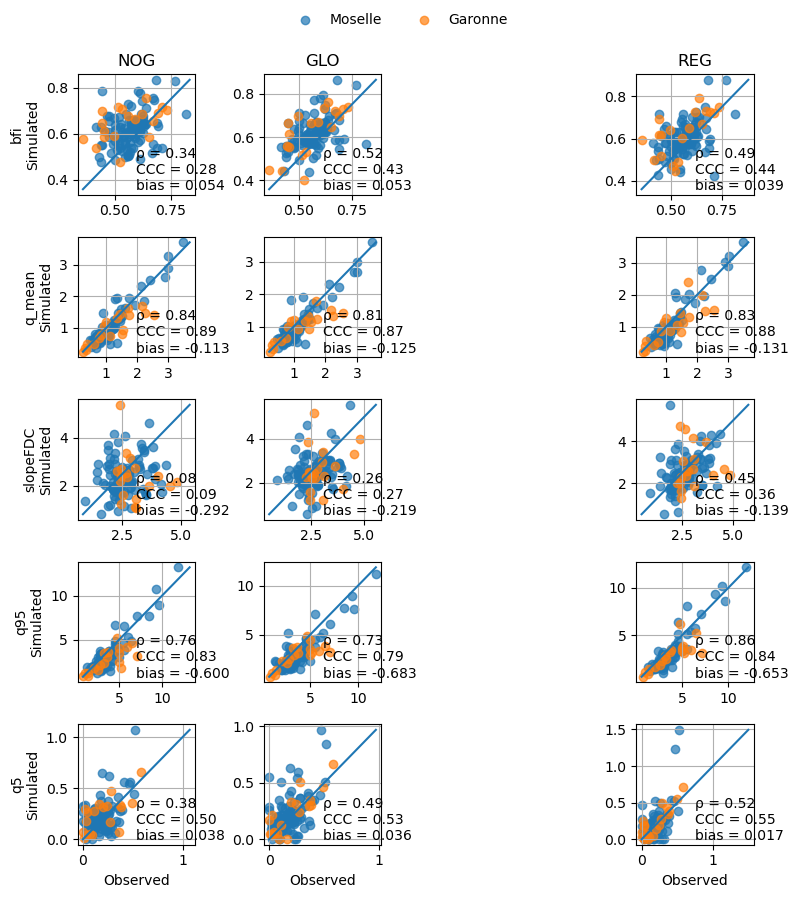

In [137]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

# =========================================================
# USER INPUT
# =========================================================

# Signatures to plot (base names, without _obs / _sim_*)
signatures = [
    "bfi",
    "q_mean",
    "slopeFDC",
    "q95",
    "q5"

]

# Basin groups
moselle_basins = set(network_estreams_moselle_108_gauges.index)
garonne_basins = set(network_estreams_garonne_22_gauges.index)

sim_types = ["nog", "glo", "con", "reg"]

colors = {
    "Moselle": "tab:blue",
    "Garonne": "tab:orange",
}

# =========================================================
# METRICS
# =========================================================
def ccc(obs, sim):
    obs = np.asarray(obs)
    sim = np.asarray(sim)

    mask = ~np.isnan(obs) & ~np.isnan(sim)
    obs = obs[mask]
    sim = sim[mask]

    if len(obs) < 2:
        return np.nan

    mean_obs = obs.mean()
    mean_sim = sim.mean()

    var_obs = obs.var(ddof=1)
    var_sim = sim.var(ddof=1)

    cov = np.cov(obs, sim, ddof=1)[0, 1]

    return (2 * cov) / (var_obs + var_sim + (mean_obs - mean_sim) ** 2)


def bias(obs, sim):
    return np.nanmean(sim - obs)

# =========================================================
# PLOTTING GRID
# =========================================================
n_rows = len(signatures)
n_cols = len(sim_types)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(8, 9),
    squeeze=False
)

# =========================================================
# MAIN LOOP
# =========================================================
df_signatures_del = df_all[df_all["slopeFDC_obs"] < 6]
df_signatures_del = df_signatures_del[df_signatures_del["slopeFDC_sim_nog"] < 6]
df_signatures_del = df_signatures_del[df_signatures_del["slopeFDC_sim_reg"] < 6]

for i, sig in enumerate(signatures):
    obs_col = f"{sig}_obs"

    for j, sim_type in enumerate(sim_types):
        ax = axes[i, j]
        sim_col = f"{sig}_sim_{sim_type}"

        if obs_col not in df_signatures_del.columns or sim_col not in df_signatures_del.columns:
            ax.axis("off")
            continue

        # --- Moselle ---
        obs_m = df_signatures_del.loc[df_signatures_del["basin_id"].isin(moselle_basins), obs_col]
        sim_m = df_signatures_del.loc[df_signatures_del["basin_id"].isin(moselle_basins), sim_col]

        ax.scatter(
            obs_m,
            sim_m,
            color=colors["Moselle"],
            alpha=0.7,
            label="Moselle"
        )

        # --- Garonne ---
        obs_g = df_signatures_del.loc[df_signatures_del["basin_id"].isin(garonne_basins), obs_col]
        sim_g = df_signatures_del.loc[df_signatures_del["basin_id"].isin(garonne_basins), sim_col]

        ax.scatter(
            obs_g,
            sim_g,
            color=colors["Garonne"],
            alpha=0.7,
            label="Garonne"
        )

        # --- 1:1 line ---
        all_obs = pd.concat([obs_m, obs_g])
        all_sim = pd.concat([sim_m, sim_g])

        lims = [
            min(all_obs.min(), all_sim.min()),
            max(all_obs.max(), all_sim.max())
        ]
        ax.plot(lims, lims)

        # --- Metrics (combined Moselle + Garonne) ---
        rho, _ = spearmanr(all_obs, all_sim, nan_policy="omit")
        ccc_val = ccc(all_obs, all_sim)
        bias_val = bias(all_obs, all_sim)

        ax.text(
            0.5,
            0.4,
            f"ρ = {rho:.2f}\nCCC = {ccc_val:.2f}\nbias = {bias_val:.3f}",
            transform=ax.transAxes,
            va="top",
            #bbox=dict(boxstyle="round", alpha=0.85)
        )

        # --- Titles & labels ---
        if i == 0:
            ax.set_title(sim_type.upper())
        if j == 0:
            ax.set_ylabel(f"{sig}\nSimulated")
        if i == n_rows - 1:
            ax.set_xlabel("Observed")

        ax.grid(True)

# =========================================================
# LEGEND & FINAL LAYOUT
# =========================================================

#ax.set_xlim(lims)
#ax.set_ylim(lims)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2, frameon=False)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


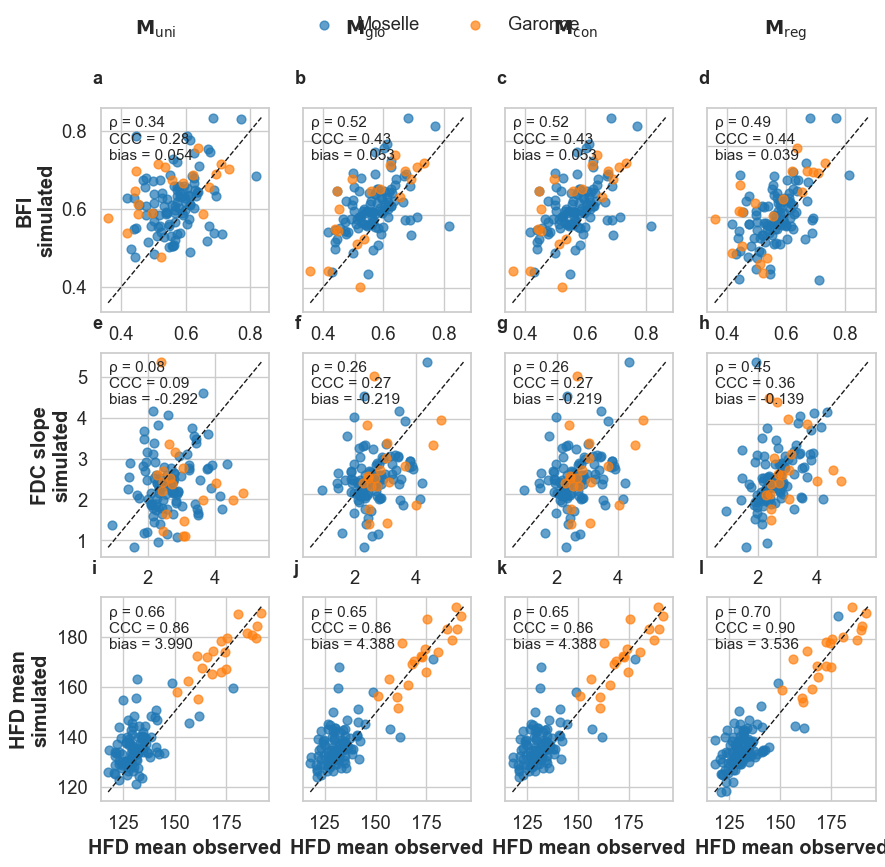

In [139]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import string
from scipy.stats import spearmanr

# =========================================================
# STYLE
# =========================================================
sns.set(style="whitegrid", font_scale=1.2)

# =========================================================
# USER INPUT
# =========================================================
signatures = ["bfi", "slopeFDC", "hfd_mean"]
signature_titles = ["BFI", "FDC slope", "HFD mean"]

sim_types = ["nog", "glo", "con", "reg"]  # con = placeholder
sim_titles = [
    r"$\mathbf{M_{\mathrm{uni}}}$",
    r"$\mathbf{M_{\mathrm{glo}}}$",
    r"$\mathbf{M_{\mathrm{con}}}$",
    r"$\mathbf{M_{\mathrm{reg}}}$",
]

colors = {
    "Moselle": "tab:blue",
    "Garonne": "tab:orange",
}

moselle_basins = set(network_estreams_moselle_108_gauges.index)
garonne_basins = set(network_estreams_garonne_22_gauges.index)

# =========================================================
# METRICS
# =========================================================
def ccc(obs, sim):
    obs = np.asarray(obs)
    sim = np.asarray(sim)

    mask = ~np.isnan(obs) & ~np.isnan(sim)
    obs = obs[mask]
    sim = sim[mask]

    if len(obs) < 2:
        return np.nan

    mean_obs = obs.mean()
    mean_sim = sim.mean()
    var_obs = obs.var(ddof=1)
    var_sim = sim.var(ddof=1)
    cov = np.cov(obs, sim, ddof=1)[0, 1]

    return (2 * cov) / (var_obs + var_sim + (mean_obs - mean_sim) ** 2)


def bias(obs, sim):
    return np.nanmean(sim - obs)

# =========================================================
# FILTER DATA (same logic as before)
# =========================================================
dfp = df_all.copy()
dfp = dfp[dfp["slopeFDC_obs"] < 6]
dfp = dfp[dfp["slopeFDC_sim_nog"] < 6]
dfp = dfp[dfp["slopeFDC_sim_reg"] < 6]

# =========================================================
# PLOTTING GRID
# =========================================================
n_rows = len(signatures)
n_cols = len(sim_types)

fig, axs = plt.subplots(n_rows, n_cols, figsize=(10, 9), squeeze=False)
letters = list(string.ascii_lowercase)

# =========================================================
# MAIN LOOP
# =========================================================
for i, (sig, sig_title) in enumerate(zip(signatures, signature_titles)):
    obs_col = f"{sig}_obs"

    for j, sim_type in enumerate(sim_types):
        ax = axs[i, j]

        # --- handle CON placeholder ---
        if sim_type == "con":
            sim_col = f"{sig}_sim_glo"  # repeat GLO
        else:
            sim_col = f"{sig}_sim_{sim_type}"

        if obs_col not in dfp.columns or sim_col not in dfp.columns:
            ax.axis("off")
            continue

        # Moselle
        obs_m = dfp.loc[dfp["basin_id"].isin(moselle_basins), obs_col]
        sim_m = dfp.loc[dfp["basin_id"].isin(moselle_basins), sim_col]

        ax.scatter(
            obs_m, sim_m,
            color=colors["Moselle"],
            alpha=0.7,
            s=40,
            label="Moselle" if (i == 0 and j == 0) else None
        )

        # Garonne
        obs_g = dfp.loc[dfp["basin_id"].isin(garonne_basins), obs_col]
        sim_g = dfp.loc[dfp["basin_id"].isin(garonne_basins), sim_col]

        ax.scatter(
            obs_g, sim_g,
            color=colors["Garonne"],
            alpha=0.7,
            s=40,
            label="Garonne" if (i == 0 and j == 0) else None
        )

        # 1:1 line
        all_obs = pd.concat([obs_m, obs_g])
        all_sim = pd.concat([sim_m, sim_g])

        lims = [
            min(all_obs.min(), all_sim.min()),
            max(all_obs.max(), all_sim.max())
        ]
        ax.plot(lims, lims, "k--", lw=1)

        # Metrics
        rho, _ = spearmanr(all_obs, all_sim, nan_policy="omit")
        ccc_val = ccc(all_obs, all_sim)
        bias_val = bias(all_obs, all_sim)

        ax.text(
            0.05, 0.75,
            f"ρ = {rho:.2f}\nCCC = {ccc_val:.2f}\nbias = {bias_val:.3f}",
            transform=ax.transAxes,
            fontsize=11
        )

        # Labels
        if j == 0:
            ax.set_ylabel(f"{sig_title}\nsimulated", fontweight="bold")
        else:
            ax.set_ylabel("")
            ax.set_yticklabels([])

        if i == n_rows - 1:
            ax.set_xlabel(f"{sig_title} observed", fontweight="bold")

        # Subplot letter
        subplot_idx = i * n_cols + j
        ax.text(
            -0.05, 1.12, letters[subplot_idx],
            transform=ax.transAxes,
            fontsize=13, fontweight="bold"
        )

        ax.grid(True)

# =========================================================
# COLUMN TITLES
# =========================================================
col_positions = [0.18, 0.39, 0.60, 0.81]
for x, title in zip(col_positions, sim_titles):
    fig.text(x, 0.98, title, ha="center", va="top", fontsize=14, fontweight="bold")

# =========================================================
# LEGEND & LAYOUT
# =========================================================
handles, labels = axs[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2, frameon=False)




<Axes: >

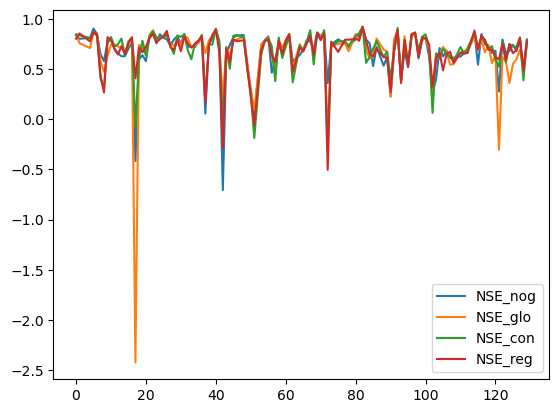

In [61]:
df_signatures_del[["NSE_nog", "NSE_glo", "NSE_con", "NSE_reg"]].plot()

In [138]:
import numpy as np
import pandas as pd

# =========================================================
# Lin's Concordance Correlation Coefficient
# =========================================================
def ccc(obs, sim):
    obs = np.asarray(obs)
    sim = np.asarray(sim)

    # Remove NaNs pairwise
    mask = ~np.isnan(obs) & ~np.isnan(sim)
    obs = obs[mask]
    sim = sim[mask]

    if len(obs) < 2:
        return np.nan

    mean_obs = obs.mean()
    mean_sim = sim.mean()

    var_obs = obs.var(ddof=1)
    var_sim = sim.var(ddof=1)

    cov = np.cov(obs, sim, ddof=1)[0, 1]

    return (2 * cov) / (var_obs + var_sim + (mean_obs - mean_sim) ** 2)


# =========================================================
# Build CCC DataFrame
# =========================================================

# --- identify observed signature columns ---
obs_cols = [c for c in df_all.columns if c.endswith("_obs")]

rows = []

for obs_col in obs_cols:
    base = obs_col.replace("_obs", "")  # e.g. bfi, q_mean, slopeFDC

    row = {"signature": base}

    for sim_type in ["nog", "glo", "reg"]:
        sim_col = f"{base}_sim_{sim_type}"

        if sim_col in df_all.columns:
            row[f"ccc_{sim_type}"] = ccc(df_all[obs_col], df_all[sim_col])
        else:
            row[f"ccc_{sim_type}"] = np.nan

    rows.append(row)

df_ccc = pd.DataFrame(rows).set_index("signature")

# =========================================================
# Optional formatting
# =========================================================
df_ccc = df_ccc.round(2)

# =========================================================
# Result
# =========================================================
df_ccc


,ccc_nog,ccc_glo,ccc_reg
signature,,,
q_mean,0.90,0.88,0.89
q5,0.46,0.45,0.55
q95,0.85,0.81,0.85
hfd_mean,0.86,0.84,0.90
low_q_freq,0.09,0.18,0.38
low_q_dur,0.00,0.01,0.00
high_q_freq,0.04,0.34,0.33
high_q_dur,0.09,0.32,0.34
zero_q_freq,0.09,-0.02,0.08


In [142]:
moselle_basins

{'Unnamed: 0',
 'area_estreams',
 'area_flag',
 'area_official',
 'area_rel',
 'aridity',
 'baseflow_index',
 'bedrk_dep',
 'dam_num',
 'duplicated_suspect',
 'ele_mt_max',
 'ele_mt_mean',
 'ele_mt_min',
 'elevation',
 'elon_ratio',
 'end_date',
 'flat_area_fra',
 'frac_snow',
 'gauge_country',
 'gauge_flag',
 'gauge_id',
 'gauge_name',
 'gauge_provider',
 'gauges_upstream',
 'group',
 'hfd_mean',
 'hfd_std',
 'hp_dur',
 'hp_freq',
 'hp_time',
 'hq_dur',
 'hq_freq',
 'irri_1990',
 'irri_2005',
 'lai_mean',
 'lakes_num',
 'lakes_tot_area',
 'lakes_tot_vol',
 'lat',
 'lat_snap',
 'lit_dom',
 'lit_fra_Conglomerates',
 'lit_fra_Conglomerates and sands',
 'lit_fra_Gravels',
 'lit_fra_Sands',
 'lit_fra_Sandstones',
 'lit_fra_Sandstones and sands',
 'lit_fra_ev',
 'lit_fra_ig',
 'lit_fra_mt',
 'lit_fra_pa',
 'lit_fra_pb',
 'lit_fra_pi',
 'lit_fra_py',
 'lit_fra_sc',
 'lit_fra_sm',
 'lit_fra_ss',
 'lit_fra_su',
 'lit_fra_va',
 'lit_fra_vb',
 'lit_fra_vi',
 'lon',
 'lon_snap',
 'lp_dur',
 'lp_f

In [143]:
import numpy as np
import pandas as pd
from scipy.stats import spearmanr

# =========================================================
# 1. Prepare signatures DataFrame
# =========================================================
df_signatures = df_all.copy()
df_signatures.set_index("basin_id", inplace=True)

# =========================================================
# 2. Basin selections
#    (these must already exist in your environment)
# =========================================================
moselle_basins = network_estreams_moselle_108_gauges.index.tolist()
garonne_basins = network_estreams_garonne_22_gauges.index.tolist()

# =========================================================
# 3. Helper function: Spearman table
# =========================================================
def spearman_table(df):
    """
    Compute Spearman correlations between *_obs and *_sim_[nog,glo,reg]
    for all signatures in the given DataFrame.
    """
    obs_cols = [c for c in df.columns if c.endswith("_obs")]
    rows = []

    for obs_col in obs_cols:
        base = obs_col.replace("_obs", "")  # e.g. bfi, q_mean, slopeFDC
        row = {"signature": base}

        for sim_type in ["nog", "glo", "reg"]:
            sim_col = f"{base}_sim_{sim_type}"

            if sim_col in df.columns:
                rho, _ = spearmanr(
                    df[obs_col],
                    df[sim_col],
                    nan_policy="omit"
                )
                row[f"spearman_{sim_type}"] = rho
            else:
                row[f"spearman_{sim_type}"] = np.nan

        rows.append(row)

    return (
        pd.DataFrame(rows)
        .set_index("signature")
        .round(2)
    )

# =========================================================
# 4. Compute Spearman correlations
# =========================================================

# (optional) All basins
df_spearman_all = spearman_table(df_signatures)

# Moselle – 108 gauges
df_spearman_moselle = spearman_table(
    df_signatures.loc[df_signatures.index.isin(moselle_basins)]
)

# Garonne
df_spearman_garonne = spearman_table(
    df_signatures.loc[df_signatures.index.isin(garonne_basins)]
)

# =========================================================
# 5. Inspect results
# =========================================================
print("=== Spearman – ALL basins ===")
print(df_spearman_all)

print("\n=== Spearman – Moselle (108 gauges) ===")
print(df_spearman_moselle)

print("\n=== Spearman – Garonne ===")
print(df_spearman_garonne)


=== Spearman – ALL basins ===
             spearman_nog  spearman_glo  spearman_reg
signature                                            
q_mean               0.82          0.79          0.81
q5                   0.39          0.41          0.55
q95                  0.76          0.73          0.84
hfd_mean             0.69          0.66          0.72
low_q_freq           0.13          0.22          0.45
low_q_dur            0.10          0.12          0.28
high_q_freq          0.40          0.56          0.54
high_q_dur           0.39          0.47          0.45
zero_q_freq          0.01          0.12          0.15
slopeFDC             0.03          0.17          0.42
bfi                  0.33          0.51          0.46

=== Spearman – Moselle (108 gauges) ===
             spearman_nog  spearman_glo  spearman_reg
signature                                            
q_mean               0.78          0.73          0.75
q5                   0.30          0.30          0.49
q95        

In [144]:
import numpy as np
import pandas as pd

# =========================================================
# 1. Prepare signatures DataFrame
# =========================================================
df_signatures = df_all.copy()
df_signatures.set_index("basin_id", inplace=True)

# =========================================================
# 2. Basin selections
# =========================================================
moselle_basins = network_estreams_moselle_108_gauges.index.tolist()
garonne_basins = network_estreams_garonne_22_gauges.index.tolist()

# =========================================================
# 3. Helper: Lin's Concordance Correlation Coefficient
# =========================================================
def ccc(obs, sim):
    obs = np.asarray(obs)
    sim = np.asarray(sim)

    mask = ~np.isnan(obs) & ~np.isnan(sim)
    obs = obs[mask]
    sim = sim[mask]

    if len(obs) < 2:
        return np.nan

    mean_obs = obs.mean()
    mean_sim = sim.mean()

    var_obs = obs.var(ddof=1)
    var_sim = sim.var(ddof=1)

    cov = np.cov(obs, sim, ddof=1)[0, 1]

    return (2 * cov) / (var_obs + var_sim + (mean_obs - mean_sim) ** 2)


# =========================================================
# 4. Helper function: CCC table
# =========================================================
def ccc_table(df):
    """
    Compute CCC between *_obs and *_sim_[nog,glo,reg]
    for all signatures in the given DataFrame.
    """
    obs_cols = [c for c in df.columns if c.endswith("_obs")]
    rows = []

    for obs_col in obs_cols:
        base = obs_col.replace("_obs", "")  # e.g. bfi, q_mean, slopeFDC
        row = {"signature": base}

        for sim_type in ["nog", "glo", "reg"]:
            sim_col = f"{base}_sim_{sim_type}"

            if sim_col in df.columns:
                row[f"ccc_{sim_type}"] = ccc(
                    df[obs_col],
                    df[sim_col]
                )
            else:
                row[f"ccc_{sim_type}"] = np.nan

        rows.append(row)

    return (
        pd.DataFrame(rows)
        .set_index("signature")
        .round(2)
    )

# =========================================================
# 5. Compute CCC correlations
# =========================================================

# (optional) All basins
df_ccc_all = ccc_table(df_signatures)

# Moselle – 108 gauges
df_ccc_moselle = ccc_table(
    df_signatures.loc[df_signatures.index.isin(moselle_basins)]
)

# Garonne – 22 gauges
df_ccc_garonne = ccc_table(
    df_signatures.loc[df_signatures.index.isin(garonne_basins)]
)

# =========================================================
# 6. Inspect results
# =========================================================
print("=== CCC – ALL basins ===")
print(df_ccc_all)

print("\n=== CCC – Moselle (108 gauges) ===")
print(df_ccc_moselle)

print("\n=== CCC – Garonne (22 gauges) ===")
print(df_ccc_garonne)


=== CCC – ALL basins ===
             ccc_nog  ccc_glo  ccc_reg
signature                             
q_mean          0.90     0.88     0.89
q5              0.46     0.45     0.55
q95             0.85     0.81     0.85
hfd_mean        0.86     0.84     0.90
low_q_freq      0.09     0.18     0.38
low_q_dur       0.00     0.01     0.00
high_q_freq     0.04     0.34     0.33
high_q_dur      0.09     0.32     0.34
zero_q_freq     0.09    -0.02     0.08
slopeFDC       -0.03    -0.01     0.01
bfi             0.26     0.41     0.43

=== CCC – Moselle (108 gauges) ===
             ccc_nog  ccc_glo  ccc_reg
signature                             
q_mean          0.92     0.90     0.90
q5              0.40     0.34     0.48
q95             0.88     0.83     0.88
hfd_mean        0.45     0.41     0.61
low_q_freq      0.06     0.12     0.38
low_q_dur       0.00     0.01     0.00
high_q_freq     0.04     0.26     0.17
high_q_dur      0.06     0.26     0.23
zero_q_freq    -0.03     0.00     0.05
slo

In [130]:
df_signatures = df_all.copy()
df_signatures.set_index("basin_id", inplace=True)

In [131]:
df_signatures = df_signatures.loc[network_estreams_moselle_108_gauges.index.tolist()]
df_signatures

,model,q_mean_obs,q5_obs,q95_obs,hfd_mean_obs,low_q_freq_obs,low_q_dur_obs,high_q_freq_obs,high_q_dur_obs,zero_q_freq_obs,...,q95_sim_reg,hfd_mean_sim_reg,low_q_freq_sim_reg,low_q_dur_sim_reg,high_q_freq_sim_reg,high_q_dur_sim_reg,zero_q_freq_sim_reg,slopeFDC_sim_reg,bfi_sim_reg,NSE_reg
basin_id,,,,,,,,,,,,,,,,,,,,,
LU000018,3.0,0.821,0.00,2.692,128.846,26.071,457.000,11.714,1.878,0.083,...,2.367,133.357,127.357,11.987,26.714,5.887,0.072,3.831,0.464,0.484
LU000010,3.0,0.849,0.00,2.670,132.154,26.071,457.000,5.071,1.587,0.083,...,2.792,140.500,92.000,16.655,3.714,4.000,0.119,3.065,0.593,0.597
LU000001,3.0,1.093,0.00,4.013,123.231,100.357,18.558,15.143,4.531,0.083,...,4.137,118.071,123.357,13.406,21.214,4.465,0.072,4.124,0.463,0.884
DERP2028,5.0,1.044,0.27,3.340,133.357,0.786,3.667,6.714,1.923,0.000,...,2.193,132.000,3.786,1.581,4.071,2.269,0.000,2.131,0.649,0.690
FR000183,2.0,1.125,0.33,2.920,143.214,4.786,8.875,0.357,1.667,0.006,...,2.724,137.429,189.714,15.754,72.786,14.635,0.167,6.063,0.438,0.220
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
DERP2007,4.0,1.134,0.13,4.121,126.500,60.214,9.541,11.214,2.763,0.000,...,2.592,133.929,9.357,2.938,5.786,2.929,0.000,2.276,0.614,0.728
FR003271,1.0,0.690,0.10,2.780,126.500,61.429,14.348,13.643,6.161,0.009,...,1.781,135.214,33.500,3.017,12.857,3.800,0.001,2.310,0.564,0.705
FR003301,3.0,0.844,0.14,2.963,130.714,39.286,6.019,13.929,2.843,0.011,...,2.412,130.786,11.143,2.833,9.857,2.939,0.002,2.103,0.563,0.808


In [121]:
df_signatures[["slopeFDC_obs", "slopeFDC_sim_glo", "slopeFDC_sim_reg"]].corr(method="spearman")["slopeFDC_obs"] 

slopeFDC_obs        1.000000
slopeFDC_sim_glo    0.140608
slopeFDC_sim_reg    0.422294
Name: slopeFDC_obs, dtype: float64

In [122]:
df_signatures

,model,q_mean_obs,q5_obs,q95_obs,hfd_mean_obs,low_q_freq_obs,low_q_dur_obs,high_q_freq_obs,high_q_dur_obs,zero_q_freq_obs,...,q95_sim_reg,hfd_mean_sim_reg,low_q_freq_sim_reg,low_q_dur_sim_reg,high_q_freq_sim_reg,high_q_dur_sim_reg,zero_q_freq_sim_reg,slopeFDC_sim_reg,bfi_sim_reg,NSE_reg
basin_id,,,,,,,,,,,,,,,,,,,,,
LU000018,3.0,0.821,0.00,2.692,128.846,26.071,457.000,11.714,1.878,0.083,...,2.367,133.357,127.357,11.987,26.714,5.887,0.072,3.831,0.464,0.484
LU000010,3.0,0.849,0.00,2.670,132.154,26.071,457.000,5.071,1.587,0.083,...,2.792,140.500,92.000,16.655,3.714,4.000,0.119,3.065,0.593,0.597
LU000001,3.0,1.093,0.00,4.013,123.231,100.357,18.558,15.143,4.531,0.083,...,4.137,118.071,123.357,13.406,21.214,4.465,0.072,4.124,0.463,0.884
DERP2028,5.0,1.044,0.27,3.340,133.357,0.786,3.667,6.714,1.923,0.000,...,2.193,132.000,3.786,1.581,4.071,2.269,0.000,2.131,0.649,0.690
FR000183,2.0,1.125,0.33,2.920,143.214,4.786,8.875,0.357,1.667,0.006,...,2.724,137.429,189.714,15.754,72.786,14.635,0.167,6.063,0.438,0.220
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
DERP2007,4.0,1.134,0.13,4.121,126.500,60.214,9.541,11.214,2.763,0.000,...,2.592,133.929,9.357,2.938,5.786,2.929,0.000,2.276,0.614,0.728
FR003271,1.0,0.690,0.10,2.780,126.500,61.429,14.348,13.643,6.161,0.009,...,1.781,135.214,33.500,3.017,12.857,3.800,0.001,2.310,0.564,0.705
FR003301,3.0,0.844,0.14,2.963,130.714,39.286,6.019,13.929,2.843,0.011,...,2.412,130.786,11.143,2.833,9.857,2.939,0.002,2.103,0.563,0.808


In [123]:
df_signatures[["hfd_mean_obs", "hfd_mean_sim_glo", "hfd_mean_sim_reg"]].corr(method="spearman")["hfd_mean_obs"] 

hfd_mean_obs        1.000000
hfd_mean_sim_glo    0.423171
hfd_mean_sim_reg    0.509687
Name: hfd_mean_obs, dtype: float64

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))

plt.scatter(df_signatures["bfi_obs"], df_signatures["bfi_sim_glo"], alpha=0.7, label="GLO")
plt.scatter(df_signatures["bfi_obs"], df_signatures["bfi_sim_reg"], alpha=0.7, label="REG")

# 1:1 line
lims = [
    min(df_all["bfi_obs"].min(),
        df_all["bfi_sim_glo"].min(),
        df_all["bfi_sim_reg"].min()),
    max(df_all["bfi_obs"].max(),
        df_all["bfi_sim_glo"].max(),
        df_all["bfi_sim_reg"].max())
]
plt.plot(lims, lims)

plt.xlabel("Observed BFI")
plt.ylabel("Simulated BFI")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


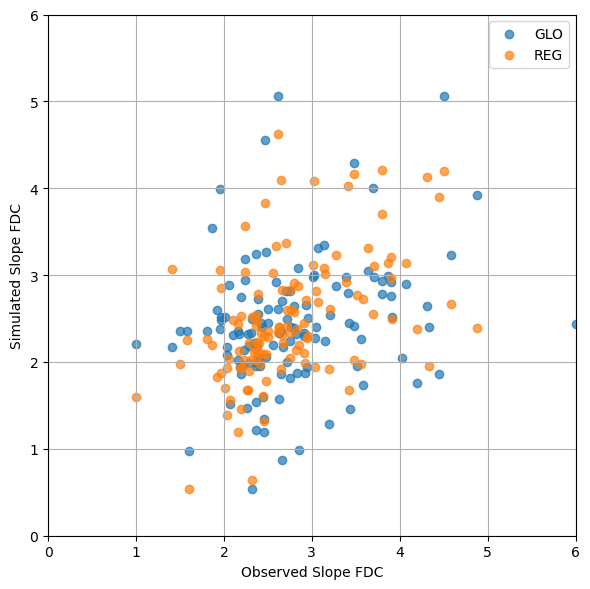

In [148]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))

plt.scatter(df_signatures["slopeFDC_obs"], df_signatures["slopeFDC_sim_glo"], alpha=0.7, label="GLO")
plt.scatter(df_signatures["slopeFDC_obs"], df_signatures["slopeFDC_sim_reg"], alpha=0.7, label="REG")

# 1:1 line
lims = [
    min(df_all["slopeFDC_obs"].min(),
        df_all["slopeFDC_sim_glo"].min(),
        df_all["slopeFDC_sim_reg"].min()),
    max(df_all["slopeFDC_obs"].max(),
        df_all["slopeFDC_sim_glo"].max(),
        df_all["slopeFDC_sim_reg"].max())
]

plt.xlim(0,6)
plt.ylim(0,6)
plt.xlabel("Observed Slope FDC")
plt.ylabel("Simulated Slope FDC")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


In [149]:
df_signatures_del = df_signatures[df_signatures["slopeFDC_obs"] < 6]
df_signatures_del.corr(method="spearman")["slopeFDC_obs"]

model                 -0.038388
q_mean_obs            -0.098991
q5_obs                -0.531576
q95_obs                0.192526
hfd_mean_obs          -0.418207
low_q_freq_obs         0.878537
low_q_dur_obs          0.356915
high_q_freq_obs        0.667949
high_q_dur_obs         0.698527
zero_q_freq_obs        0.151065
slopeFDC_obs           1.000000
bfi_obs               -0.668531
q_mean_sim_nog        -0.097338
q5_sim_nog            -0.125906
q95_sim_nog           -0.071909
hfd_mean_sim_nog      -0.094433
low_q_freq_sim_nog     0.080827
low_q_dur_sim_nog     -0.061183
high_q_freq_sim_nog    0.133968
high_q_dur_sim_nog     0.159243
zero_q_freq_sim_nog   -0.009087
slopeFDC_sim_nog       0.084014
bfi_sim_nog           -0.085159
NSE_nog                0.149707
q_mean_sim_glo        -0.070510
q5_sim_glo            -0.249454
q95_sim_glo           -0.001356
hfd_mean_sim_glo      -0.038943
low_q_freq_sim_glo     0.192492
low_q_dur_sim_glo      0.034125
high_q_freq_sim_glo    0.196007
high_q_d

In [150]:
df_all[["basin_id", "NSE_glo", "NSE_reg", "bfi_obs", "bfi_sim_glo", "bfi_sim_reg"]][0:30]

,basin_id,NSE_glo,NSE_reg,bfi_obs,bfi_sim_glo,bfi_sim_reg
0,BEWA0066,0.846,0.802,0.431,0.484,0.407
1,BEWA0067,0.758,0.854,0.376,0.395,0.353
2,BEWA0106,0.644,0.702,0.400,0.600,0.283
3,BEWA0107,0.606,0.588,0.475,0.679,0.421
4,BEWA0119,0.709,0.776,0.425,0.596,0.474
5,DEBU1956,0.864,0.866,0.532,0.549,0.561
6,DEBU1957,0.829,0.840,0.540,0.541,0.467
7,DEBU1958,0.583,0.443,0.544,0.677,0.572
8,DEBU1959,0.473,0.265,0.535,0.761,0.546
9,DERP2003,0.627,0.817,0.498,0.560,0.477


In [151]:
df_all[["bfi_obs", "bfi_sim_glo", "bfi_sim_reg"]][0:30].corr()

,bfi_obs,bfi_sim_glo,bfi_sim_reg
bfi_obs,1.000000,0.198674,0.70422
bfi_sim_glo,0.198674,1.000000,0.13389
bfi_sim_reg,0.704220,0.133890,1.00000


In [152]:
df_signatures_del = df_signatures[df_signatures.index != "FR000183"]


In [153]:
df_signatures_del[["bfi_obs", "bfi_sim_glo", "bfi_sim_reg"]].corr()

,bfi_obs,bfi_sim_glo,bfi_sim_reg
bfi_obs,1.000000,0.519858,0.509546
bfi_sim_glo,0.519858,1.000000,0.667501
bfi_sim_reg,0.509546,0.667501,1.000000


In [154]:
import numpy as np
from scipy.stats import spearmanr

def ccc(obs, sim):
    obs = np.asarray(obs)
    sim = np.asarray(sim)

    mean_obs = obs.mean()
    mean_sim = sim.mean()

    var_obs = obs.var(ddof=1)
    var_sim = sim.var(ddof=1)

    cov = np.cov(obs, sim, ddof=1)[0, 1]

    return (2 * cov) / (var_obs + var_sim + (mean_obs - mean_sim) ** 2)


obs = df_signatures["bfi_obs"]

# GLO
sim_glo = df_signatures["bfi_sim_glo"]
ccc_glo = ccc(obs, sim_glo)
rho_glo, _ = spearmanr(obs, sim_glo)
bias_glo = (sim_glo - obs).mean()

# REG
sim_reg = df_signatures["bfi_sim_reg"]
ccc_reg = ccc(obs, sim_reg)
rho_reg, _ = spearmanr(obs, sim_reg)
bias_reg = (sim_reg - obs).mean()


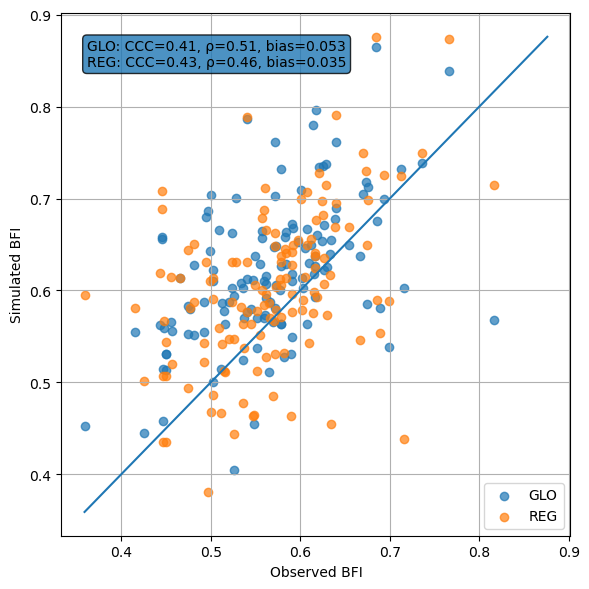

In [155]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))

plt.scatter(obs, sim_glo, alpha=0.7, label="GLO")
plt.scatter(obs, sim_reg, alpha=0.7, label="REG")

lims = [
    min(obs.min(), sim_glo.min(), sim_reg.min()),
    max(obs.max(), sim_glo.max(), sim_reg.max())
]
plt.plot(lims, lims)

plt.xlabel("Observed BFI")
plt.ylabel("Simulated BFI")
plt.legend()
plt.grid(True)

# --- BFI metrics annotation ---
plt.text(
    0.05, 0.95,
    (
        f"GLO: CCC={ccc_glo:.2f}, ρ={rho_glo:.2f}, bias={bias_glo:.3f}\n"
        f"REG: CCC={ccc_reg:.2f}, ρ={rho_reg:.2f}, bias={bias_reg:.3f}"
    ),
    transform=plt.gca().transAxes,
    verticalalignment="top",
    bbox=dict(boxstyle="round", alpha=0.8)
)

plt.tight_layout()
plt.show()


In [110]:
df_signatures[df_signatures.bfi_obs>0.7][["bfi_obs", "bfi_sim_glo", "bfi_sim_reg"]]

,bfi_obs,bfi_sim_glo,bfi_sim_reg
basin_id,,,
FR000183,0.716,0.603,0.438
FR000184,0.766,0.839,0.874
DERP2013,0.816,0.568,0.715


In [3]:
# Read the dataset network
network_estreams = pd.read_csv(path_estreams+'/streamflow_gauges/estreams_gauging_stations.csv', encoding='utf-8')
network_estreams.set_index("basin_id", inplace = True)

# Convert 'date_column' and 'time_column' to datetime
network_estreams['start_date'] = pd.to_datetime(network_estreams['start_date'])
network_estreams['end_date'] = pd.to_datetime(network_estreams['end_date'])

# Convert to list both the nested_catchments and the duplicated_suspect columns
network_estreams['nested_catchments'] = network_estreams['nested_catchments'].apply(lambda x: x.strip("[]").replace("'", "").split(", "))

# Remove the brackets and handle NaN values
network_estreams['duplicated_suspect'] = network_estreams['duplicated_suspect'].apply(
    lambda x: x.strip("[]").replace("'", "").split(", ") if isinstance(x, str) else x)

# Set the nested catchments as a dataframe
nested_catchments = pd.DataFrame(network_estreams['nested_catchments'])

# Now we add the outlet to the list (IF it was not before):
# Ensure that the basin_id is in the nested_catchments
for basin_id in nested_catchments.index:
    if basin_id not in nested_catchments.at[basin_id, 'nested_catchments']:
        nested_catchments.at[basin_id, 'nested_catchments'].append(basin_id)



# Attributes already filtered previously:
#estreams_attributes = pd.read_csv('data/exploration/estreams_attributes_filtered_moselle_sm_su_tog.csv', encoding='utf-8')
estreams_attributes = pd.read_csv('../data/estreams_attributes_filtered_quality_geology_v01.csv', encoding='utf-8')

estreams_attributes.set_index("basin_id", inplace = True)

# Convert to list both the nested_catchments and the duplicated_suspect columns
estreams_attributes['nested_catchments'] = estreams_attributes['nested_catchments'].apply(lambda x: x.strip("[]").replace("'", "").split(", "))

# Remove the brackets and handle NaN values
estreams_attributes['duplicated_suspect'] = estreams_attributes['duplicated_suspect'].apply(
    lambda x: x.strip("[]").replace("'", "").split(", ") if isinstance(x, str) else x)

estreams_attributes.sort_index(inplace = True) 

In [4]:
# Geological attributes (regional scale)
geology_regional_31_classes_moselle = pd.read_csv("../data/estreams_geology_moselle_regional_attributes.csv", encoding='utf-8')

geology_regional_31_classes_moselle.set_index("basin_id", inplace = True)

# Create a dictionary to map permeability classes to corresponding columns
permeability_columns = {
    "high": ["lit_fra_Alluvium", 'lit_fra_Coal', 'lit_fra_Conglomerate', 'lit_fra_Gravel and sand',
             'lit_fra_Sand', 'lit_fra_Sand and gravel', 'lit_fra_Sandstone and conglomerate', 'lit_fra_Sandstone'
        ],
    
    "medium": ['lit_fra_Limestone', 'lit_fra_Sandstone and marl', 'lit_fra_Sandstone and schist',
              'lit_fra_Sandstone, conglomerate and marl',

              'lit_fra_Arkose', 'lit_fra_Dolomite rock', 'lit_fra_Limestone and marl', 'lit_fra_Marl', 
             'lit_fra_Marl and dolomite', 'lit_fra_Marl and limestone', 'lit_fra_Marl and sandstone',
               'lit_fra_Sandstone and siltstone', 'lit_fra_Sandstone, siltstone and schist', 
              'lit_fra_Schist and sandstone', 'lit_fra_Silt',  'lit_fra_Silt and schist', 'lit_fra_Siltstone, sandstone and schist'
              
             ],
    
    "low": ['lit_fra_Cristallin basement', 'lit_fra_Plutonic rock',  'lit_fra_Quarzite',
                    'lit_fra_Schist','lit_fra_Volcanic rock' 
                   ]
}

# Iterate over the permeability columns and calculate the area for each class
for permeability_class, columns in permeability_columns.items():
    geology_regional_31_classes_moselle[f'area_perm_{permeability_class}'] = geology_regional_31_classes_moselle[columns].sum(axis=1)

# Drop unnecessary columns
geology_regional_31_classes_moselle = geology_regional_31_classes_moselle[["area_perm_high", "area_perm_medium", "area_perm_low"]]

# Rename the columns
geology_regional_31_classes_moselle.columns = ["perm_high_regi", "perm_medium_regi", "perm_low_regi"]

# Display the updated DataFrame
geology_regional_31_classes_moselle

geology_regional_31_classes_moselle["baseflow_index"] = estreams_attributes["baseflow_index"]
geology_regional_31_classes_moselle.corr(method="pearson")

# Concatenation
estreams_attributes[["perm_high_regi", "perm_medium_regi", "perm_low_regi"]] = geology_regional_31_classes_moselle[["perm_high_regi", "perm_medium_regi", "perm_low_regi"]]

# Adjust the three categories for also global dataset
estreams_attributes["perm_high_glob2"] = estreams_attributes["perm_high_glob"]
estreams_attributes["perm_medium_glob2"] = estreams_attributes["perm_medium_glob"] + estreams_attributes["perm_low_glob"]
estreams_attributes["perm_low_glob2"] = estreams_attributes["perm_verylow_glob"]

###########################################################################################################################
# Adjust the columns of the dataset:
for basin_id in estreams_attributes.index.tolist():

    # Extract and divide by 100
    v1 = estreams_attributes.loc[basin_id, "perm_high_regi"] / 100
    v2 = estreams_attributes.loc[basin_id, "perm_medium_regi"] / 100
    v3 = estreams_attributes.loc[basin_id, "perm_low_regi"] / 100

    # Round all values to one decimal place
    v1 = round(v1, 2)
    v2 = round(v2, 2)
    v3 = round(v3, 2)

    # Ensure the sum is exactly 1 by adjusting the largest value
    diff = 1 - (v1 + v2 + v3)

    if diff != 0:
        # Adjust the value that was the largest before rounding
        if max(v1, v2, v3) == v1:
            v1 += diff
        elif max(v1, v2, v3) == v2:
            v2 += diff
        else:
            v3 += diff

    # Assign back
    estreams_attributes.loc[basin_id, "perm_high_regi"] = v1 * 100
    estreams_attributes.loc[basin_id, "perm_medium_regi"] = v2 * 100
    estreams_attributes.loc[basin_id, "perm_low_regi"] = v3 * 100


for basin_id in estreams_attributes.index.tolist():

    # Extract and divide by 100
    v1 = estreams_attributes.loc[basin_id, "perm_high_glob2"] / 100
    v2 = estreams_attributes.loc[basin_id, "perm_medium_glob2"] / 100
    v3 = estreams_attributes.loc[basin_id, "perm_low_glob2"] / 100

    # Round all values to one decimal place
    v1 = round(v1, 2)
    v2 = round(v2, 2)
    v3 = round(v3, 2)

    # Ensure the sum is exactly 1 by adjusting the largest value
    diff = 1 - (v1 + v2 + v3)

    if diff != 0:
        # Adjust the value that was the largest before rounding
        if max(v1, v2, v3) == v1:
            v1 += diff
        elif max(v1, v2, v3) == v2:
            v2 += diff
        else:
            v3 += diff

    # Assign back
    estreams_attributes.loc[basin_id, "perm_high_glob2"] = v1 * 100
    estreams_attributes.loc[basin_id, "perm_medium_glob2"] = v2 * 100
    estreams_attributes.loc[basin_id, "perm_low_glob2"] = v3 * 100

In [5]:
# Define the functions
def obj_fun_nsee(observations, simulation, expo=0.5):
    """
    Calculate the Normalized Squared Error Efficiency (NSEE) while ensuring that
    NaNs in simulation are NOT masked (only NaNs in observations are masked).

    Parameters:
        observations (array-like): Observed values (with fixed NaNs).
        simulation (array-like): Simulated values (can contain NaNs).
        expo (float, optional): Exponent applied to observations and simulations. Default is 1.0.

    Returns:
        float: NSEE score (higher values indicate worse performance).
    """
    observations = np.asarray(observations)
    simulation = np.asarray(simulation)

    # Mask only NaNs in observations
    mask = ~np.isnan(observations)
    obs = observations[mask]
    sim = simulation[mask]  # Keep all simulated values, even NaNs

    # If simulation contains NaNs after masking observations, return penalty
    if np.isnan(sim).any():
        return 10.0  # Large penalty if NaNs appear in the simulation

    metric = np.sum((sim**expo - obs**expo)**2) / np.sum((obs**expo - np.mean(obs**expo))**2)
    
    return float(metric)


def obj_fun_kge(observations, simulation):
    """
    Calculate the KGE-2012 objective function, ensuring that NaNs in simulation are NOT masked.
    
    Parameters:
        observations (array-like): Observed values (with fixed NaNs).
        simulation (array-like): Simulated values (can contain NaNs).

    Returns:
        float: KGE-2012 score (higher values indicate worse performance).
    """
    observations = np.asarray(observations)
    simulation = np.asarray(simulation)

    # Mask only NaNs in observations
    mask = ~np.isnan(observations)
    obs = observations[mask]
    sim = simulation[mask]  # Keep all simulated values, even NaNs

    # Check if there are NaNs in the simulation after masking obs
    if np.isnan(sim).any():
        return 10.0  # Large penalty if the simulation contains NaNs
    
    obs_mean = np.mean(obs)
    sim_mean = np.mean(sim)

    r = np.corrcoef(obs, sim)[0, 1]
    alpha = np.std(sim) / np.std(obs)
    beta = sim_mean / obs_mean

    kge = np.sqrt((r - 1)**2 + (alpha - 1)**2 + (beta - 1)**2)  # KGE-2012

    return float(kge)

In [6]:
# First we define the outlet of the Moselle to be used
outlets = ["DEBU1959"]
nested_cats_df = nested_catchments.loc[outlets, :]

# Now we save our dataframes in a dictionary of dataframes. One dataframe for each watershed. 

nested_cats_filtered = find_max_unique_rows(nested_cats_df)                                  # Filter only the catchemnts using the function stated before
nested_cats_filtered_df = nested_catchments.loc[nested_cats_filtered, :]                     # Here we filter the catchemnts for the list (again, after we apply our function):

# Store the variables for the selected catchments in a list of dataframes now for only the ones above 20 cats:
estreams_attributes_dfs = {}
for catchment in tqdm.tqdm(nested_cats_filtered):
    # Retrieve the nested list of catchments for the current catchment
    nested_clip = nested_cats_filtered_df.loc[catchment, 'nested_catchments']
    
    # Filter values to include only those that exist in the index of estreams_attributes
    nested_clip = [value for value in nested_clip if value in estreams_attributes.index]
    
    # Filter the estreams_attributes DataFrame based on the filtered nested_clip
    cat_clip = estreams_attributes.loc[nested_clip, :]
    
    # Store the resulting DataFrame in the dictionary
    estreams_attributes_dfs[catchment] = cat_clip

# Here we can save the length of each watershed (number of nested catchemnts)
catchment_lens = pd.DataFrame(index = estreams_attributes_dfs.keys())
for catchment, data in estreams_attributes_dfs.items():
    catchment_lens.loc[catchment, "len"] = len(data)

# Now we can filter it properly:
nested_cats_filtered_abovevalue = catchment_lens[catchment_lens.len >= 10]

# # Here we filter the catchemnts for the list (again, after we apply our function):
nested_cats_filtered_abovevalue_df = nested_catchments.loc[nested_cats_filtered_abovevalue.index, :]

# Store the variables for the selected catchments in a list of dataframes now for only the ones above 20 cats:
estreams_attributes_dfs = {}

for catchment in tqdm.tqdm(nested_cats_filtered_abovevalue_df.index):
    # Retrieve the nested list of catchments for the current catchment
    nested_clip = nested_cats_filtered_abovevalue_df.loc[catchment, 'nested_catchments']
    
    # Filter values to include only those that exist in the index of estreams_attributes
    nested_clip = [value for value in nested_clip if value in estreams_attributes.index]
    
    # Filter the estreams_attributes DataFrame based on the filtered nested_clip
    cat_clip = estreams_attributes.loc[nested_clip, :]
    
    # Store the resulting DataFrame in the dictionary
    estreams_attributes_dfs[catchment] = cat_clip

# Adjust and clip it:
estreams_attributes_clipped = estreams_attributes_dfs["DEBU1959"]

# Convert 'date_column' and 'time_column' to datetime
estreams_attributes_clipped['start_date'] = pd.to_datetime(estreams_attributes_clipped['start_date'])
estreams_attributes_clipped['end_date'] = pd.to_datetime(estreams_attributes_clipped['end_date'])


#estreams_attributes_clipped_filters = estreams_attributes_clipped[estreams_attributes_clipped.end_date >= "2010"]
#estreams_attributes_clipped_filters = estreams_attributes_clipped_filters[estreams_attributes_clipped_filters.start_date <= "2002"]

# Here we retrieve the conectivity (from EStreams computation)
# Load the nested catchments CSV file
df = pd.read_excel("../data/nested_catchments.xlsx")

# Rename columns for clarity
df = df.rename(columns={df.columns[1]: "basin_id", df.columns[2]: "connected_basin_id"})
df = df.drop(columns=[df.columns[0]])  # Drop the unnamed index column

100%|██████████| 1/1 [00:00<00:00, 1228.20it/s]


In [7]:
# Read the dataset network
estreams_attributes_clipped_filters = pd.read_csv(R'../data/network_estreams_moselle_108_gauges.csv', encoding='utf-8')
estreams_attributes_clipped_filters.set_index("basin_id", inplace = True)
estreams_attributes_clipped_filters

,Unnamed: 0,gauge_id,gauge_name,gauge_country,gauge_provider,river,lon_snap,lat_snap,lon,lat,...,irri_1990,irri_2005,stations_num_p_mean,perm_high_regi,perm_medium_regi,perm_low_regi,perm_high_glob2,perm_medium_glob2,perm_low_glob2,group
basin_id,,,,,,,,,,,,,,,,,,,,,
LU000018,0,5,Schoenfels,LU,LU_CONTACTFORM,Mamer,6.100795,49.723112,6.100795,49.723112,...,0.015,0.015,17.0,39.0,61.0,0.0,0.0,100.0,0.0,Group_1
LU000010,1,6,Hunnebuer,LU,LU_CONTACTFORM,Eisch,6.079524,49.729184,6.079524,49.729184,...,0.026,0.026,16.0,42.0,58.0,0.0,1.0,99.0,0.0,Group_1
LU000001,2,17,Bigonville,LU,LU_CONTACTFORM,Sure,5.801399,49.869821,5.801399,49.869821,...,0.000,0.000,9.0,1.0,0.0,99.0,100.0,0.0,0.0,Group_1
DERP2028,3,2674030900,Eisenschmitt,DE,DE_RP,Salm,6.718000,50.048000,6.718000,50.048000,...,0.000,0.000,10.0,80.0,7.0,13.0,79.0,20.0,1.0,Group_1
FR000183,4,A900105050,A9001050,FR,FR_EAUFRANCE,La Sarre à Laneuveville-lès-Lorquin,7.008689,48.654579,7.008689,48.654579,...,0.000,0.000,4.0,66.0,29.0,5.0,64.0,30.0,6.0,Group_1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
FR003271,107,A782101001,La Seille Ã Nomeny,FR,FR_EAUFRANCE,La Seille à Nomeny,6.227788,48.888271,6.227788,48.888271,...,0.429,0.436,5.0,8.0,92.0,0.0,0.0,100.0,0.0,Group_7
FR003301,108,A930108040,La Sarre Ã Wittring,FR,FR_EAUFRANCE,La Sarre à Wittring,7.150066,49.053225,7.150066,49.053225,...,0.436,2.205,16.0,17.0,83.0,0.0,15.0,85.0,0.0,Group_7
DERP2003,109,2620050500,Bollendorf,DE,DE_RP,Sauer,6.359000,49.851000,6.359000,49.851000,...,1.627,4.160,65.0,17.0,30.0,53.0,50.0,50.0,0.0,Group_7


In [8]:
# Python implementation
from superflexpy.framework.unit import Unit
from superflexpy.framework.node import Node
from superflexpy.framework.network import Network

from superflexpy.implementation.elements.hbv import UnsaturatedReservoir, PowerReservoir

from superflexpy.implementation.numerical_approximators.implicit_euler import ImplicitEulerPython
from superflexpy.implementation.root_finders.pegasus import PegasusPython

# Numba implementation:
from superflexpy.implementation.root_finders.pegasus import PegasusNumba
from superflexpy.implementation.numerical_approximators.implicit_euler import ImplicitEulerNumba

from superflexpy.implementation.elements.hbv import PowerReservoir
from superflexpy.framework.unit import Unit
from superflexpy.implementation.elements.thur_model_hess import SnowReservoir, UnsaturatedReservoir, PowerReservoir, HalfTriangularLag

from superflexpy.implementation.elements.structure_elements import Transparent, Junction, Splitter
from superflexpy.framework.element import ParameterizedElement

In [9]:
root_finder = PegasusNumba()
num_app = ImplicitEulerNumba(root_finder=root_finder)

class ParameterizedSingleFluxSplitter(ParameterizedElement):
    _num_downstream = 2
    _num_upstream = 1
    
    def set_input(self, input):

        self.input = {'Q_in': input[0]}

    def get_output(self, solve=True):

        split_par = self._parameters[self._prefix_parameters + 'splitpar']

        output1 = [self.input['Q_in'] * split_par]
        output2 = [self.input['Q_in'] * (1 - split_par)]
        
        return [output1, output2]   
    
    
lower_splitter = ParameterizedSingleFluxSplitter(
    parameters={'splitpar': 0.5},
    id='lowersplitter'
)

lower_splitter_medium = ParameterizedSingleFluxSplitter(
    parameters={'splitpar': 0.6},
    id='lowersplitter'
)

lower_splitter_high = ParameterizedSingleFluxSplitter(
    parameters={'splitpar': 0.7},
    id='lowersplitter'
)

# Fluxes in the order P, T, PET
upper_splitter = Splitter(
    direction=[
        [0, 1, None],    # P and T go to the snow reservoir
        [2, None, None]  # PET goes to the transparent element
    ],
    weight=[
        [1.0, 1.0, 0.0],
        [0.0, 0.0, 1.0]
    ],
    id='upper-splitter'
)

snow = SnowReservoir(
    parameters={'t0': 0.0, 'k': 0.01, 'm': 2.0},
    states={'S0': 0.0},
    approximation=num_app,
    id='snow'
)

upper_transparent = Transparent(
    id='upper-transparent'
)

upper_junction = Junction(
    direction=[
        [0, None],
        [None, 0]
    ],
    id='upper-junction'
)


unsaturated = UnsaturatedReservoir(
    parameters={'Smax': 150.0, 'Ce': 1.0, 'm': 0.01, 'beta': 2.0},
    states={'S0': 10.0},
    approximation=num_app,
    id='unsaturated'
)

fast = PowerReservoir(
    parameters={'k': 0.01, 'alpha': 2.0},
    states={'S0': 0.0},
    approximation=num_app,
    id='fast'
)

slow = PowerReservoir(
    parameters={'k': 1e-4, 'alpha': 1.0},
    states={'S0': 0.0},
    approximation=num_app,
    id='slow'
)

slowhigh = PowerReservoir(
    parameters={'k': 1e-4, 'alpha': 2.0},
    states={'S0': 0.0},
    approximation=num_app,
    id='slowhigh'
)


lower_junction = Junction(
    direction=[
        [0, 0]
    ],
    id='lower-junction'
)

lag_fun = HalfTriangularLag(
    parameters={'lag-time': 4.0},
    states={'lag': None},
    id='lag-fun'
)

lower_transparent = Transparent(
    id='lower-transparent'
)

lower_transparent2 = Transparent(
    id='lower-transparent2'
)

general = Unit(
    layers=[
        [upper_splitter],
        [snow, upper_transparent],
        [upper_junction],
        [unsaturated],
        [lower_splitter],
        [slow, lag_fun],
        [lower_transparent, fast],
        [lower_junction],
    ],
    id='general'
)

low = Unit(
    layers=[
        [upper_splitter],
        [snow, upper_transparent],
        [upper_junction],
        [unsaturated],
        [fast],
    ],
    id='low'
)

high = Unit(
    layers=[
        [upper_splitter],
        [snow, upper_transparent],
        [upper_junction],
        [unsaturated],
        [slowhigh],
    ],
    id='high'
)

In [10]:
import os
import glob

# Dictionary to store all parameter dicts
all_param_dicts = {}

# Loop through all CSVs in the current directory
for filepath in glob.glob("../results/groups/*moselle*.csv"):
    file_key = os.path.splitext(os.path.basename(filepath))[0]  # Strip .csv
    
    param_dict = {}

    # Read file and parse lines
    with open(filepath, 'r') as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith(","):  # Skip empty or malformed lines
                continue
            parts = line.split(",")
            if len(parts) == 2:
                key, value = parts
                try:
                    param_dict[key] = float(value)
                except ValueError:
                    pass  # Skip lines where value is not a float
            else:
                pass  # Skip malformed lines

    # Store the parsed dictionary
    all_param_dicts[file_key] = param_dict


In [11]:
catchments_ids = estreams_attributes_clipped_filters.index.tolist()

def calculate_hydro_year(date, first_month=10):
    """
    This function calculates the hydrological year from a date. The
    hydrological year starts on the month defined by the parameter first_month.

    Parameters
    ----------
    date : pandas.core.indexes.datetimes.DatetimeIndex
        Date series
    first_month : int
        Number of the first month of the hydrological year

    Returns
    -------
    numpy.ndarray
        Hydrological year time series
    """

    hydrological_year = date.year.values.copy()
    hydrological_year[date.month >= first_month] += 1

    return hydrological_year

def run_model_superflexpy(catchments_ids, best_params_dict_model, perm_areas_model):
    # Run the iterative function
    iterative_immediate_downstream = find_iterative_immediate_downstream(df, catchments_ids)

    # Convert results to a DataFrame for display
    iterative_downstream_df = pd.DataFrame(iterative_immediate_downstream.items(), 
                                        columns=['basin_id', 'immediate_downstream_basin'])


    # Assuming the DataFrame has columns 'basin_id' and 'downstream_id'
    topology_list = {basin: None for basin in catchments_ids}  # Default to None

    # Filter DataFrame for relevant basin_ids and update topology
    for _, row in iterative_downstream_df.iterrows():
        if row['basin_id'] in topology_list:
            topology_list[row['basin_id']] = row['immediate_downstream_basin']

    # Generate Nodes dynamically and assign them as global variables
    catchments = [] # Dictionary to store nodes
    
    general = Unit(
    layers=[
        [upper_splitter],
        [snow, upper_transparent],
        [upper_junction],
        [unsaturated],
        [lower_splitter],
        [slow, lag_fun],
        [lower_transparent, fast],
        [lower_junction],
    ],
    id='general')

    low = Unit(
        layers=[
        [upper_splitter],
        [snow, upper_transparent],
        [upper_junction],
        [unsaturated],
        [lower_splitter],
        [slow, lag_fun],
        [lower_transparent, fast],
        [lower_junction],
    ],
        id='low')

    high = Unit(
        layers=[
        [upper_splitter],
        [snow, upper_transparent],
        [upper_junction],
        [unsaturated],
        [lower_splitter],
        [slow, lag_fun],
        [lower_transparent, fast],
        [lower_junction],
    ],
        id='high')

    for cat_id in catchments_ids:
        node = Node(
            units=[high, general, low],  # Use unit from dictionary or default
            weights=perm_areas_model[cat_id],
            area=areas.get(cat_id),  # Use predefined area or default
            id=cat_id
        )
        catchments.append(node)  # Store in the list

        # Assign the node as a global variable
        globals()[cat_id] = node


    # Ensure topology only includes nodes that exist in `catchments_ids`
    topology = {
        cat_id: upstream if upstream in catchments_ids else None
        for cat_id, upstream in topology_list.items() if cat_id in catchments_ids
    }

    # Create the Network
    model = Network(
        nodes=catchments,  # Pass list of Node objects
        topology=topology  
    )

    model.reset_states()

    # Set inputs for each node using the manually defined dictionary
    for cat in catchments:
        cat.set_input(inputs[cat.id])  # Correct way to set inputs

    model.set_timestep(1.0)
    model.set_parameters(best_params_dict_model)

    output = model.get_output()

    return output

def run_model_superflexpy_nogeo(catchments_ids, best_params_dict_model, perm_areas_model):
    # Run the iterative function
    iterative_immediate_downstream = find_iterative_immediate_downstream(df, catchments_ids)

    # Convert results to a DataFrame for display
    iterative_downstream_df = pd.DataFrame(iterative_immediate_downstream.items(), 
                                        columns=['basin_id', 'immediate_downstream_basin'])


    # Assuming the DataFrame has columns 'basin_id' and 'downstream_id'
    topology_list = {basin: None for basin in catchments_ids}  # Default to None

    # Filter DataFrame for relevant basin_ids and update topology
    for _, row in iterative_downstream_df.iterrows():
        if row['basin_id'] in topology_list:
            topology_list[row['basin_id']] = row['immediate_downstream_basin']

    # Generate Nodes dynamically and assign them as global variables
    catchments = [] # Dictionary to store nodes
    
    general = Unit(
    layers=[
        [upper_splitter],
        [snow, upper_transparent],
        [upper_junction],
        [unsaturated],
        [lower_splitter],
        [slow, lag_fun],
        [lower_transparent, fast],
        [lower_junction],
    ],
    id='general')

    for cat_id in catchments_ids:
        node = Node(
            units=[general],  # Use unit from dictionary or default
            weights=[1.0],
            area=areas.get(cat_id),  # Use predefined area or default
            id=cat_id
        )
        catchments.append(node)  # Store in the list

        # Assign the node as a global variable
        globals()[cat_id] = node


    # Ensure topology only includes nodes that exist in `catchments_ids`
    topology = {
        cat_id: upstream if upstream in catchments_ids else None
        for cat_id, upstream in topology_list.items() if cat_id in catchments_ids
    }

    # Create the Network
    model = Network(
        nodes=catchments,  # Pass list of Node objects
        topology=topology  
    )

    model.reset_states()

    # Set inputs for each node using the manually defined dictionary
    for cat in catchments:
        cat.set_input(inputs[cat.id])  # Correct way to set inputs

    model.set_timestep(1.0)
    model.set_parameters(best_params_dict_model)

    output = model.get_output()

    return output

def generate_nse_results(catchments_ids, daterange, output, observations, quality_masks):


    # Create an empty list to store results
    nse_results_cal = []

    for basin in catchments_ids:
        Qtimeseries = pd.DataFrame(index=daterange)
        Qtimeseries["Qobs"] = observations[basin]
        Qtimeseries["Qcalc"] = output[basin][0]

        hydro_year = calculate_hydro_year(date=Qtimeseries.index, first_month=10)

        nse_value = 1 - obj_fun_nsee(observations=Qtimeseries.iloc[365:, 0].values, 
                                    simulation=Qtimeseries.iloc[365:, 1].values, 
                                    expo=0.5)
                
        bfi_obs = hydroanalysis.streamflow_signatures.calculate_baseflow_index(Qtimeseries.iloc[365:, 0].values, quality_masks[basin][365:], alpha=0.925, num_filters=3, num_reflect=30, returnBF=False)
        bfi_sim = hydroanalysis.streamflow_signatures.calculate_baseflow_index(Qtimeseries.iloc[365:, 1].values, quality_masks[basin][365:], alpha=0.925, num_filters=3, num_reflect=30, returnBF=False)
        
        qmean_obs = hydroanalysis.streamflow_signatures.calculate_q_mean(Qtimeseries.iloc[365:, 0].values, quality_masks[basin][365:])
        qmean_sim = hydroanalysis.streamflow_signatures.calculate_q_mean(Qtimeseries.iloc[365:, 1].values, quality_masks[basin][365:])
        
        try:

            slope_obs = hydroanalysis.streamflow_signatures.calculate_slope_fdc(Qtimeseries.iloc[365:, 0].values, quality_masks[basin][365:])["Sawicz"]
            slope_sim = hydroanalysis.streamflow_signatures.calculate_slope_fdc(Qtimeseries.iloc[365:, 1].values, quality_masks[basin][365:])["Sawicz"]
        except: 
            slope_obs = np.nan
            slope_sim = np.nan
        
        try:
            hfd_obs = hydroanalysis.streamflow_signatures.calculate_hfd_mean(Qtimeseries.iloc[365:, 0].values, quality_masks[basin][365:], hydro_year[365:])["hfd_mean"]
            hfd_sim = hydroanalysis.streamflow_signatures.calculate_hfd_mean(Qtimeseries.iloc[365:, 1].values, quality_masks[basin][365:], hydro_year[365:])["hfd_mean"]

        except:
            hfd_obs = np.nan
            hfd_sim = np.nan

        try:            
            nse_value_bfi = 1 - obj_fun_nsee(observations=hydroanalysis.streamflow_signatures.calculate_baseflow_index(Qtimeseries.iloc[365:, 0].values, quality_masks[basin][365:], alpha=0.925, num_filters=3, num_reflect=30, returnBF=True)[1], 
                                    simulation=hydroanalysis.streamflow_signatures.calculate_baseflow_index(Qtimeseries.iloc[365:, 1].values, quality_masks[basin][365:], alpha=0.925, num_filters=3, num_reflect=30, returnBF=True)[1], 
                                    expo=0.5)
        except:
            nse_value_bfi = np.nan


        nse_results_cal.append({
            "gauge_name": network_estreams.loc[basin, "gauge_name"],
            "basin": basin,
            "nse": nse_value,
            "bfi_obs": bfi_obs,
            "bfi_sim":bfi_sim,
            "nse_value_bfi": nse_value_bfi,
            "qmean_obs": qmean_obs,
            "qmean_sim": qmean_sim,
            "slope_obs": slope_obs,
            "slope_sim": slope_sim,
            "hfd_obs": hfd_obs,
            "hfd_sim": hfd_sim
            })

    # Convert results to DataFrame
    nse_results_df = pd.DataFrame(nse_results_cal)

    return nse_results_df

import re

def is_valid_key(k):
    # Exclude keys that end in Group_X_2
    return not re.search(r'Group_\d+_2$', k)

def is_valid_key_2(k):
    # Include only keys that end in Group_X_2
    return re.search(r'Group_\d+_2$', k)

## Model all time-series using all possible combinations of params

In [12]:
path_inputs = '../data/models/input/subset_2001_2015'

inputs = np.load(path_inputs+'//inputs.npy', allow_pickle=True).item()
observations = np.load(path_inputs+'//observations.npy', allow_pickle=True).item()
areas = np.load(path_inputs+'//areas.npy', allow_pickle=True).item()
perm_areas = np.load(path_inputs+'//perm_areas.npy', allow_pickle=True).item()
perm_areascontinental = np.load(path_inputs+'//perm_areascontinental.npy', allow_pickle=True).item()
perm_areasglobal = np.load(path_inputs+'//perm_areasglobal.npy', allow_pickle=True).item()
quality_masks = np.load(path_inputs+'//quality_masks.npy', allow_pickle=True).item()
rootdepth_mean = np.load(path_inputs+'//rootdepth_mean.npy', allow_pickle=True).item()
waterdeficit_mean= np.load(path_inputs+'//waterdeficit_mean.npy', allow_pickle=True).item()

# Added for random permeabilities:
perm_areas_random = {}

for j in range(1, 8):
    perm_areas_random[f"perm_areas_random{j:02d}"] = np.load(
        os.path.join(path_inputs, f"perm_areas_random{j:02d}.npy"),
        allow_pickle=True
    ).item()

# Filter keys
regional_keys = [k for k in all_param_dicts if "regi" in k and is_valid_key(k)]
continental_keys = [k for k in all_param_dicts if "cont" in k and is_valid_key(k)]
global_keys = [k for k in all_param_dicts if "glob" in k and is_valid_key(k)]
nogeo_keys = [k for k in all_param_dicts if "nogeo" in k and is_valid_key(k)]
random_keys = [k for k in all_param_dicts if "rand" in k and is_valid_key(k)]

output_nogeo_dict = {}
output_regional_dict = {}
output_continental_dict = {}
output_global_dict = {}
output_random_dict = {}

for key in tqdm.tqdm(regional_keys):
        
    catchments_ids = estreams_attributes_clipped_filters[
    (estreams_attributes_clipped_filters.group == key[-7:]) &
    (~estreams_attributes_clipped_filters.index.str.contains("LU"))].index.tolist()

    output = run_model_superflexpy(
        catchments_ids=catchments_ids,
        best_params_dict_model=all_param_dicts[key],
        perm_areas_model=perm_areas
    )
    output_regional_dict[key] = output

for key in tqdm.tqdm(continental_keys):

    catchments_ids = estreams_attributes_clipped_filters[
    (estreams_attributes_clipped_filters.group == key[-7:]) &
    (~estreams_attributes_clipped_filters.index.str.contains("LU"))].index.tolist()
        
    output = run_model_superflexpy(
        catchments_ids=catchments_ids,
        best_params_dict_model=all_param_dicts[key],
        perm_areas_model=perm_areascontinental
    )
    output_continental_dict[key] = output

for key in tqdm.tqdm(global_keys):
    
    catchments_ids = estreams_attributes_clipped_filters[
    (estreams_attributes_clipped_filters.group == key[-7:]) &
    (~estreams_attributes_clipped_filters.index.str.contains("LU"))].index.tolist()
        
    output = run_model_superflexpy(
        catchments_ids=catchments_ids,
        best_params_dict_model=all_param_dicts[key],
        perm_areas_model=perm_areasglobal
    )
    output_global_dict[key] = output


for key in tqdm.tqdm(nogeo_keys):

    catchments_ids = estreams_attributes_clipped_filters[
    (estreams_attributes_clipped_filters.group == key[-7:]) &
    (~estreams_attributes_clipped_filters.index.str.contains("LU"))].index.tolist()
        
    output = run_model_superflexpy_nogeo(
        catchments_ids=catchments_ids,
        best_params_dict_model=all_param_dicts[key],
        perm_areas_model=perm_areas
    )
    output_nogeo_dict[key] = output


for key in tqdm.tqdm(random_keys):

    catchments_ids = estreams_attributes_clipped_filters[
        (estreams_attributes_clipped_filters.group == key[-7:]) &
        (~estreams_attributes_clipped_filters.index.str.contains("LU"))].index.tolist()

    output = run_model_superflexpy(
        catchments_ids=catchments_ids,
        best_params_dict_model=all_param_dicts[key],
        perm_areas_model=perm_areas_random[f"perm_areas_random{int(key[-1:]):02d}"]
    )
    output_random_dict[key] = output

100%|██████████| 7/7 [00:34<00:00,  4.90s/it]


In [13]:
path_inputs = '../data/models/input/subset_1988_2001'

inputs = np.load(path_inputs+'//inputs.npy', allow_pickle=True).item()
observations = np.load(path_inputs+'//observations.npy', allow_pickle=True).item()
areas = np.load(path_inputs+'//areas.npy', allow_pickle=True).item()
perm_areas = np.load(path_inputs+'//perm_areas.npy', allow_pickle=True).item()
perm_areascontinental = np.load(path_inputs+'//perm_areascontinental.npy', allow_pickle=True).item()
perm_areasglobal = np.load(path_inputs+'//perm_areasglobal.npy', allow_pickle=True).item()
quality_masks = np.load(path_inputs+'//quality_masks.npy', allow_pickle=True).item()
rootdepth_mean = np.load(path_inputs+'//rootdepth_mean.npy', allow_pickle=True).item()
waterdeficit_mean= np.load(path_inputs+'//waterdeficit_mean.npy', allow_pickle=True).item()

# Added for random permeabilities:
perm_areas_random = {}

for j in range(1, 8):
    perm_areas_random[f"perm_areas_random{j:02d}"] = np.load(
        os.path.join(path_inputs, f"perm_areas_random{j:02d}.npy"),
        allow_pickle=True
    ).item()


# Filter keys
regional_keys_2 = [k for k in all_param_dicts if "regi" in k and is_valid_key_2(k)]
continental_keys_2 = [k for k in all_param_dicts if "cont" in k and is_valid_key_2(k)]
global_keys_2 = [k for k in all_param_dicts if "glob" in k and is_valid_key_2(k)]
nogeo_keys_2 = [k for k in all_param_dicts if "nogeo" in k and is_valid_key_2(k)]
random_keys_2 = [k for k in all_param_dicts if "rand" in k and is_valid_key_2(k)]


output_nogeo_dict_8801 = {}
output_regional_dict_8801 = {}
output_continental_dict_8801 = {}
output_global_dict_8801 = {}
output_random_dict_8801 = {}

for key in tqdm.tqdm(regional_keys_2):

    catchments_ids = estreams_attributes_clipped_filters[
    (estreams_attributes_clipped_filters.group == key[-9:-2]) &
    (~estreams_attributes_clipped_filters.index.str.contains("LU"))].index.tolist()
        
    output = run_model_superflexpy(
        catchments_ids=catchments_ids,
        best_params_dict_model=all_param_dicts[key],
        perm_areas_model=perm_areas
    )
    output_regional_dict_8801[key] = output

for key in tqdm.tqdm(continental_keys_2):
    catchments_ids = estreams_attributes_clipped_filters[
    (estreams_attributes_clipped_filters.group == key[-9:-2]) &
    (~estreams_attributes_clipped_filters.index.str.contains("LU"))].index.tolist()
    
    output = run_model_superflexpy(
        catchments_ids=catchments_ids,
        best_params_dict_model=all_param_dicts[key],
        perm_areas_model=perm_areascontinental
    )
    output_continental_dict_8801[key] = output

for key in tqdm.tqdm(global_keys_2):
    catchments_ids = estreams_attributes_clipped_filters[
    (estreams_attributes_clipped_filters.group == key[-9:-2]) &
    (~estreams_attributes_clipped_filters.index.str.contains("LU"))].index.tolist()
        
    output = run_model_superflexpy(
        catchments_ids=catchments_ids,
        best_params_dict_model=all_param_dicts[key],
        perm_areas_model=perm_areasglobal
    )
    output_global_dict_8801[key] = output

for key in tqdm.tqdm(nogeo_keys_2):

    catchments_ids = estreams_attributes_clipped_filters[
    (estreams_attributes_clipped_filters.group == key[-9:-2]) &
    (~estreams_attributes_clipped_filters.index.str.contains("LU"))].index.tolist()
        
    output = run_model_superflexpy_nogeo(
        catchments_ids=catchments_ids,
        best_params_dict_model=all_param_dicts[key],
        perm_areas_model=perm_areas
    )
    
    output_nogeo_dict_8801[key] = output

for key in tqdm.tqdm(random_keys_2):

    catchments_ids = estreams_attributes_clipped_filters[
        (estreams_attributes_clipped_filters.group == key[-9:-2]) &
        (~estreams_attributes_clipped_filters.index.str.contains("LU"))].index.tolist()

    output = run_model_superflexpy(
        catchments_ids=catchments_ids,
        best_params_dict_model=all_param_dicts[key],
        perm_areas_model=perm_areas_random[f"perm_areas_random{int(key[-1:]):02d}"]
    )
    
    output_random_dict_8801[key] = output

100%|██████████| 7/7 [00:38<00:00,  5.50s/it]


In [14]:
# Create the concatenated data for the complete series analysis 
path_inputs = '../data/models/input/subset_1988_2001'
observations1 = np.load(path_inputs + '//observations.npy', allow_pickle=True).item()
quality_masks1 = np.load(path_inputs + '//quality_masks.npy', allow_pickle=True).item()

path_inputs = '../data/models/input/subset_2001_2015'
observations2 = np.load(path_inputs + '//observations.npy', allow_pickle=True).item()
quality_masks2 = np.load(path_inputs + '//quality_masks.npy', allow_pickle=True).item()

observations_cal = {}
quality_masks_cal = {}

for key in observations1.keys():
    arr1 = np.atleast_1d(observations1[key])
    arr2 = np.atleast_1d(observations2.get(key, np.array([])))

    # Remove the first 365 days from the second dataset
    arr2_trimmed = arr2[365:] if arr2.size > 365 else np.array([])

    observations_cal[key] = np.concatenate([arr1, arr2_trimmed])

for key in quality_masks1.keys():
    arr1 = np.atleast_1d(quality_masks1[key])
    arr2 = np.atleast_1d(quality_masks2.get(key, np.array([])))

    # Remove the first 365 days from the second dataset
    arr2_trimmed = arr2[365:] if arr2.size > 365 else np.array([])

    quality_masks_cal[key] = np.concatenate([arr1, arr2_trimmed])

In [15]:
# Load both input files
path_inputs_1 = '../data/models/input/subset_1988_2001/inputs.npy'
path_inputs_2 = '../data/models/input/subset_2001_2015/inputs.npy'

inputs1 = np.load(path_inputs_1, allow_pickle=True).item()
inputs2 = np.load(path_inputs_2, allow_pickle=True).item()

# Initialize new dictionaries
precipitation_cal = {}
temperature_cal = {}
evaporation_cal = {}

for key in inputs1.keys():
    # Get (P, T, PET) tuples from each period
    p1, t1, pet1 = map(np.atleast_1d, inputs1[key])
    p2, t2, pet2 = map(np.atleast_1d, inputs2.get(key, ([], [], [])))

    # Concatenate and assign
    precipitation_cal[key] = np.concatenate([p1, p2])
    temperature_cal[key] = np.concatenate([t1, t2])
    evaporation_cal[key] = np.concatenate([pet1, pet2])

In [16]:
output_global_dict_cal = {}

for param_key in output_global_dict:
    param_key_8801 = param_key + "_2"

    if param_key_8801 in output_global_dict_8801:
        merged_outputs = {}

        for gauge_id in output_global_dict[param_key]:
            if gauge_id in output_global_dict_8801[param_key_8801]:
                # Ensure both arrays are flat (1D)
                series_8801 = np.ravel(output_global_dict_8801[param_key_8801][gauge_id])
                series_recent = np.ravel(output_global_dict[param_key][gauge_id])
                #concatenated = np.concatenate([series_8801, series_recent])
                
                # Remove first 365 days from recent series
                series_recent_trimmed = series_recent[365:] if series_recent.size > 365 else np.array([])
                concatenated = np.concatenate([series_8801, series_recent_trimmed])

                merged_outputs[gauge_id] = [concatenated]

        output_global_dict_cal[param_key] = merged_outputs

In [17]:
output_continental_dict_cal = {}

for param_key in output_continental_dict:
    param_key_8801 = param_key + "_2"

    if param_key_8801 in output_continental_dict_8801:
        merged_outputs = {}

        for gauge_id in output_continental_dict[param_key]:
            if gauge_id in output_continental_dict_8801[param_key_8801]:
                # Ensure both arrays are flat (1D)
                series_8801 = np.ravel(output_continental_dict_8801[param_key_8801][gauge_id])
                series_recent = np.ravel(output_continental_dict[param_key][gauge_id])
                #concatenated = np.concatenate([series_8801, series_recent])
                
                # Remove first 365 days from recent series
                series_recent_trimmed = series_recent[365:] if series_recent.size > 365 else np.array([])
                concatenated = np.concatenate([series_8801, series_recent_trimmed])

                merged_outputs[gauge_id] = [concatenated]

        output_continental_dict_cal[param_key] = merged_outputs

In [18]:
output_regional_dict_cal = {}

for param_key in output_regional_dict:
    param_key_8801 = param_key + "_2"

    if param_key_8801 in output_regional_dict_8801:
        merged_outputs = {}

        for gauge_id in output_regional_dict[param_key]:
            if gauge_id in output_regional_dict_8801[param_key_8801]:
                # Ensure both arrays are flat (1D)
                series_8801 = np.ravel(output_regional_dict_8801[param_key_8801][gauge_id])
                series_recent = np.ravel(output_regional_dict[param_key][gauge_id])
                #concatenated = np.concatenate([series_8801, series_recent])

                # Remove first 365 days from recent series
                series_recent_trimmed = series_recent[365:] if series_recent.size > 365 else np.array([])
                concatenated = np.concatenate([series_8801, series_recent_trimmed])

                merged_outputs[gauge_id] = [concatenated]

        output_regional_dict_cal[param_key] = merged_outputs

In [19]:
output_nogeo_dict_cal = {}

for param_key in output_nogeo_dict:
    param_key_8801 = param_key + "_2"

    if param_key_8801 in output_nogeo_dict_8801:
        merged_outputs = {}

        for gauge_id in output_nogeo_dict[param_key]:
            if gauge_id in output_nogeo_dict_8801[param_key_8801]:
                # Ensure both arrays are flat (1D)
                series_8801 = np.ravel(output_nogeo_dict_8801[param_key_8801][gauge_id])
                series_recent = np.ravel(output_nogeo_dict[param_key][gauge_id])
                #concatenated = np.concatenate([series_8801, series_recent])

                # Remove first 365 days from recent series
                series_recent_trimmed = series_recent[365:] if series_recent.size > 365 else np.array([])
                concatenated = np.concatenate([series_8801, series_recent_trimmed])

                merged_outputs[gauge_id] = [concatenated]

        output_nogeo_dict_cal[param_key] = merged_outputs

In [20]:
output_random_dict_cal = {}

for param_key in output_random_dict:
    param_key_8801 = param_key + "_2"

    if param_key_8801 in output_random_dict_8801:
        merged_outputs = {}

        for gauge_id in output_random_dict[param_key]:
            if gauge_id in output_random_dict_8801[param_key_8801]:
                # Ensure both arrays are flat (1D)
                series_8801 = np.ravel(output_random_dict_8801[param_key_8801][gauge_id])
                series_recent = np.ravel(output_random_dict[param_key][gauge_id])
                #concatenated = np.concatenate([series_8801, series_recent])

                # Remove first 365 days from recent series
                series_recent_trimmed = series_recent[365:] if series_recent.size > 365 else np.array([])
                concatenated = np.concatenate([series_8801, series_recent_trimmed])

                merged_outputs[gauge_id] = [concatenated]

        output_random_dict_cal[param_key] = merged_outputs

## Save the time-series in netcdfs

In [21]:
import xarray as xr
import numpy as np

# Adjust these according to your data
group_suffixes = ["Group_1", "Group_2", "Group_3", "Group_4", "Group_5", "Group_6", "Group_7"]

gauge_ids = list(observations_cal.keys())  # Your observations dict should be preloaded
time_index = pd.date_range(start="1988-10-01", end="2015-09-30", freq='D')

In [22]:
# Build datasets
datasets = {}

for suffix in group_suffixes:
    reg_key = f"moselle_best_params_regicomp_{suffix}"
    cont_key = f"moselle_best_params_contcomp_{suffix}"
    glob_key = f"moselle_best_params_globcomp_{suffix}"
    nogeo_key = f"moselle_best_params_nogeo_{suffix}"
    random_key = f"moselle_best_params_randomcomp_{suffix}"

    reg_data = []
    cont_data = []
    glob_data = []
    nogeo_data = []
    random_data = []

    group_gauge_ids = []

    for gauge in gauge_ids:
        if gauge in output_regional_dict_cal[reg_key] and \
           gauge in output_continental_dict_cal[cont_key] and \
           gauge in output_nogeo_dict_cal[nogeo_key] and \
            gauge in output_random_dict_cal[random_key] and \
           gauge in output_global_dict_cal[glob_key]:

            reg_data.append(output_regional_dict_cal[reg_key][gauge][0])
            cont_data.append(output_continental_dict_cal[cont_key][gauge][0])
            glob_data.append(output_global_dict_cal[glob_key][gauge][0])
            nogeo_data.append(output_nogeo_dict_cal[nogeo_key][gauge][0])
            random_data.append(output_random_dict_cal[random_key][gauge][0])

            group_gauge_ids.append(gauge)

    if group_gauge_ids:
        ds = xr.Dataset(
            data_vars={
                "regional": (["gauge_id", "date"], reg_data),
                "continental": (["gauge_id", "date"], cont_data),
                "global": (["gauge_id", "date"], glob_data),
                "nogeo": (["gauge_id", "date"], nogeo_data),
                "random": (["gauge_id", "date"], random_data)

            },
            coords={
                "gauge_id": group_gauge_ids,
                "date": time_index
            }
        )
        datasets[suffix] = ds

# Save each group to a separate NetCDF file using scipy (no need for netCDF4)
for suffix, ds in datasets.items():
    ds.to_netcdf(rf"../results/sim/calibration/simu_cal_r_{suffix}.nc", engine="scipy")

# End